In [5]:
# Cell 1 - Environment Setup and Configuration

import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import math
import time
import traceback
from datetime import datetime, timedelta
from dotenv import load_dotenv

# Import scikit-learn dependencies
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

pd.options.mode.chained_assignment = None

# Load environment variables from .env file
try:
    env_path = pathlib.Path(__file__).resolve().parent.parent / ".env"
except NameError:
    env_path = pathlib.Path(os.getcwd()) / ".env"
load_dotenv(dotenv_path=env_path)

# Get configuration values and setup connections
DATABASE_URL = os.getenv("DATABASE_URL")
print("DATABASE_URL loaded:", DATABASE_URL is not None)

# Setup SQLAlchemy engine
from sqlalchemy import create_engine
try:
    engine = create_engine(DATABASE_URL)
    print("Database engine created successfully.")
except Exception as e:
    print(f"Error creating database engine: {e}")

# Import Supabase client
try:
    from caching.supabase_client import supabase
    print("Supabase client imported successfully.")
except Exception as e:
    print(f"Error importing Supabase client: {e}")

# Set directories for models and state saving
MODELS_DIR = pathlib.Path(os.getcwd()) / "models"
MODELS_DIR.mkdir(exist_ok=True)
PREGAME_MODEL_PATH = MODELS_DIR / "pregame_model.pkl"
print(f"Pre-game model will be saved to: {PREGAME_MODEL_PATH}")
print(f"Current date: {datetime.now().strftime('%Y-%m-%d')}")

DATABASE_URL loaded: True
Database engine created successfully.
Supabase client imported successfully.
Pre-game model will be saved to: /Users/mattb/Desktop/Projects/score-genius/notebooks/models/pregame_model.pkl
Current date: 2025-03-21


In [6]:
# Cell 2 - Core Data Loading Functions

import re

def normalize_team_name(name):
    """
    Normalizes team names to handle inconsistencies in naming across data sources.
    
    Args:
        name: Team name to normalize
        
    Returns:
        Normalized team name (lowercase, without special characters)
    """
    # Remove special characters, standardize spacing
    normalized = re.sub(r'[^\w\s]', '', str(name)).lower().strip()
    
    # Handle common variations (76ers vs sixers, etc.)
    replacements = {
        "76ers": "sixers",
        "trail blazers": "blazers"
        # Add more as needed
    }
    
    for old, new in replacements.items():
        if old in normalized:
            normalized = normalized.replace(old, new)
            
    return normalized


def load_historical_games(days_lookback=365):
    """
    Loads historical game data from Supabase for feature engineering and training.
    Includes all box score statistics.
    """
    threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
    print(f"Loading historical game data since {threshold_date}...")
    try:
        # Use correct Supabase query syntax
        response = supabase.table("nba_historical_game_stats")\
            .select("*")\
            .gte("game_date", threshold_date)\
            .order('game_date')\
            .execute()
        
        historical_data = response.data
        if not historical_data:
            print(f"No historical game data available from the last {days_lookback} days.")
            return pd.DataFrame()
        
        df = pd.DataFrame(historical_data)
        df['game_date'] = pd.to_datetime(df['game_date'])
        
        # Ensure all numeric columns have proper types
        numeric_cols = ['home_score', 'away_score', 'home_q1', 'home_q2', 'home_q3', 'home_q4', 'home_ot',
                'away_q1', 'away_q2', 'away_q3', 'away_q4', 'away_ot', 'home_assists', 'away_assists',
                'home_steals', 'away_steals', 'home_blocks', 'away_blocks', 'home_turnovers',
                'away_turnovers', 'home_fouls', 'away_fouls', 'home_off_reb', 'home_def_reb',
                'home_total_reb', 'away_off_reb', 'away_def_reb', 'away_total_reb',
                'home_3pm', 'home_3pa', 'away_3pm', 'away_3pa',
                # NEW FIELDS
                'home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted',
                'home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted']
                        
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        
        print(f"Loaded {len(df)} historical games from {df['game_date'].min()} to {df['game_date'].max()}")
        return df
    except Exception as e:
        print(f"Error loading historical game data: {e}")
        traceback.print_exc()
        
        # For development/testing, create mock data if API call fails
        print("Creating mock historical data for development...")
        teams = [
            'Atlanta Hawks', 'Boston Celtics', 'Brooklyn Nets', 'Charlotte Hornets', 
            'Chicago Bulls', 'Cleveland Cavaliers', 'Dallas Mavericks', 'Denver Nuggets',
            'Detroit Pistons', 'Golden State Warriors', 'Houston Rockets', 'Indiana Pacers',
            'Los Angeles Clippers', 'Los Angeles Lakers', 'Memphis Grizzlies', 'Miami Heat',
            'Milwaukee Bucks', 'Minnesota Timberwolves', 'New Orleans Pelicans', 'New York Knicks',
            'Oklahoma City Thunder', 'Orlando Magic', 'Philadelphia 76ers', 'Phoenix Suns',
            'Portland Trail Blazers', 'Sacramento Kings', 'San Antonio Spurs', 'Toronto Raptors',
            'Utah Jazz', 'Washington Wizards'
        ]
        
        # Generate mock games for the past year
        mock_games = []
        for i in range(1200):  # ~1200 games per season
            game_date = datetime.now() - timedelta(days=np.random.randint(1, days_lookback))
            home_idx = np.random.randint(0, len(teams))
            away_idx = np.random.randint(0, len(teams))
            while away_idx == home_idx:
                away_idx = np.random.randint(0, len(teams))
                
            home_team = teams[home_idx]
            away_team = teams[away_idx]
            
            # Generate realistic scores and stats
            home_score = np.random.randint(95, 130)
            away_score = np.random.randint(95, 130)
            
            # Quarter scores
            home_q1 = np.random.randint(20, 35)
            home_q2 = np.random.randint(20, 35)
            home_q3 = np.random.randint(20, 35)
            home_q4 = np.random.randint(20, 35)
            home_ot = 0
            
            away_q1 = np.random.randint(20, 35)
            away_q2 = np.random.randint(20, 35)
            away_q3 = np.random.randint(20, 35)
            away_q4 = np.random.randint(20, 35)
            away_ot = 0
            
            # Adjust quarter scores to match total
            total_quarters = home_q1 + home_q2 + home_q3 + home_q4
            adjustment = home_score / total_quarters
            home_q1 = int(home_q1 * adjustment)
            home_q2 = int(home_q2 * adjustment)
            home_q3 = int(home_q3 * adjustment)
            home_q4 = int(home_q4 * adjustment)
            
            total_quarters = away_q1 + away_q2 + away_q3 + away_q4
            adjustment = away_score / total_quarters
            away_q1 = int(away_q1 * adjustment)
            away_q2 = int(away_q2 * adjustment)
            away_q3 = int(away_q3 * adjustment)
            away_q4 = int(away_q4 * adjustment)
            
            # Generate other stats
            home_assists = np.random.randint(18, 30)
            away_assists = np.random.randint(18, 30)
            home_steals = np.random.randint(5, 15)
            away_steals = np.random.randint(5, 15)
            home_blocks = np.random.randint(2, 10)
            away_blocks = np.random.randint(2, 10)
            home_turnovers = np.random.randint(8, 20)
            away_turnovers = np.random.randint(8, 20)
            home_fouls = np.random.randint(15, 25)
            away_fouls = np.random.randint(15, 25)
            
            # Rebounding
            home_off_reb = np.random.randint(5, 15)
            home_def_reb = np.random.randint(25, 40)
            home_total_reb = home_off_reb + home_def_reb
            
            away_off_reb = np.random.randint(5, 15)
            away_def_reb = np.random.randint(25, 40)
            away_total_reb = away_off_reb + away_def_reb
            
            # Three-point shooting
            home_3pa = np.random.randint(25, 45)
            home_3pm = int(home_3pa * np.random.uniform(0.3, 0.45))
            
            away_3pa = np.random.randint(25, 45)
            away_3pm = int(away_3pa * np.random.uniform(0.3, 0.45))


                    # Generate field goal stats
            home_fg_attempted = np.random.randint(70, 95)
            home_fg_made = int(home_fg_attempted * np.random.uniform(0.4, 0.52))
            away_fg_attempted = np.random.randint(70, 95)
            away_fg_made = int(away_fg_attempted * np.random.uniform(0.4, 0.52))

            # Generate free throw stats
            home_ft_attempted = np.random.randint(15, 35)
            home_ft_made = int(home_ft_attempted * np.random.uniform(0.7, 0.85))
            away_ft_attempted = np.random.randint(15, 35)
            away_ft_made = int(away_ft_attempted * np.random.uniform(0.7, 0.85))
            
            mock_games.append({
                'game_id': 10000 + i,
                'game_date': game_date,
                'home_team': home_team,
                'away_team': away_team,
                'home_score': home_score,
                'away_score': away_score,
                'home_q1': home_q1,
                'home_q2': home_q2,
                'home_q3': home_q3,
                'home_q4': home_q4,
                'home_ot': home_ot,
                'away_q1': away_q1,
                'away_q2': away_q2,
                'away_q3': away_q3,
                'away_q4': away_q4,
                'away_ot': away_ot,
                'home_assists': home_assists,
                'away_assists': away_assists,
                'home_steals': home_steals,
                'away_steals': away_steals,
                'home_blocks': home_blocks,
                'away_blocks': away_blocks,
                'home_turnovers': home_turnovers,
                'away_turnovers': away_turnovers,
                'home_fouls': home_fouls,
                'away_fouls': away_fouls,
                'home_off_reb': home_off_reb,
                'home_def_reb': home_def_reb,
                'home_total_reb': home_total_reb,
                'away_off_reb': away_off_reb,
                'away_def_reb': away_def_reb,
                'away_total_reb': away_total_reb,
                'home_3pm': home_3pm,
                'home_3pa': home_3pa,
                'away_3pm': away_3pm,
                'away_3pa': away_3pa,
                'home_fg_made': home_fg_made,
                'home_fg_attempted': home_fg_attempted,
                'away_fg_made': away_fg_made,
                'away_fg_attempted': away_fg_attempted,
                'home_ft_made': home_ft_made,
                'home_ft_attempted': home_ft_attempted,
                'away_ft_made': away_ft_made,
                'away_ft_attempted': away_ft_attempted
            })
        
        mock_df = pd.DataFrame(mock_games)
        mock_df['game_date'] = pd.to_datetime(mock_df['game_date'])
        print(f"Created {len(mock_df)} mock historical games")
        return mock_df
    

def get_upcoming_games(days=7):
    """
    Fetch upcoming NBA games scheduled in the next 'days' days from Supabase.
    """
    today = datetime.now()
    end_date = (today + timedelta(days=days)).strftime('%Y-%m-%d')
    today_str = today.strftime('%Y-%m-%d')
    print(f"Fetching upcoming games from {today_str} to {end_date}...")
    try:
        response = supabase.table("nba_game_schedule")\
            .select("*")\
            .gte("game_date", today_str)\
            .lte("game_date", end_date)\
            .execute()
        
        if response.data:
            df = pd.DataFrame(response.data)
            df['game_date'] = pd.to_datetime(df['game_date'])
            print(f"Found {len(df)} upcoming games in nba_game_schedule.")
            return df
        else:
            print("No scheduled upcoming games found.")
            
            # For development/testing, create mock upcoming games
            print("Creating mock upcoming games for development...")
            teams = [
                'Atlanta Hawks', 'Boston Celtics', 'Brooklyn Nets', 'Charlotte Hornets', 
                'Chicago Bulls', 'Cleveland Cavaliers', 'Dallas Mavericks', 'Denver Nuggets',
                'Detroit Pistons', 'Golden State Warriors', 'Houston Rockets', 'Indiana Pacers',
                'Los Angeles Clippers', 'Los Angeles Lakers', 'Memphis Grizzlies', 'Miami Heat',
                'Milwaukee Bucks', 'Minnesota Timberwolves', 'New Orleans Pelicans', 'New York Knicks',
                'Oklahoma City Thunder', 'Orlando Magic', 'Philadelphia 76ers', 'Phoenix Suns',
                'Portland Trail Blazers', 'Sacramento Kings', 'San Antonio Spurs', 'Toronto Raptors',
                'Utah Jazz', 'Washington Wizards'
            ]
            
            # Generate upcoming games
            upcoming_games = []
            for i in range(15):  # ~15 games in a week
                game_date = today + timedelta(days=np.random.randint(0, days))
                home_idx = np.random.randint(0, len(teams))
                away_idx = np.random.randint(0, len(teams))
                while away_idx == home_idx:
                    away_idx = np.random.randint(0, len(teams))
                    
                home_team = teams[home_idx]
                away_team = teams[away_idx]
                scheduled_time = f"{np.random.randint(6, 9)}:{np.random.choice(['00', '30'])} PM"
                
                upcoming_games.append({
                    'game_id': 20000 + i,
                    'game_date': game_date.strftime('%Y-%m-%d'),
                    'home_team': home_team,
                    'away_team': away_team,
                    'scheduled_time': scheduled_time,
                    'venue': f"{home_team} Arena"
                })
            
            mock_df = pd.DataFrame(upcoming_games)
            print(f"Created {len(mock_df)} mock upcoming games")
            return mock_df
    except Exception as e:
        print(f"Error fetching upcoming games: {e}")
        traceback.print_exc()
        return pd.DataFrame()

In [7]:
# Cell 3

import pandas as pd
import numpy as np
import traceback
import re

def normalize_team_name(name):
    """
    Normalizes team names to handle inconsistencies in naming across data sources.
    
    Args:
        name: Team name to normalize
        
    Returns:
        Normalized team name (lowercase, without special characters)
    """
    if name is None:
        return ""
        
    # Remove special characters, standardize spacing
    normalized = re.sub(r'[^\w\s]', '', str(name)).lower().strip()
    
    # Handle common variations (76ers vs sixers, etc.)
    replacements = {
        "76ers": "sixers",
        "trail blazers": "blazers"
        # Add more as needed
    }
    
    for old, new in replacements.items():
        if old in normalized:
            normalized = normalized.replace(old, new)
            
    return normalized

def calculate_team_metrics(historical_df):
    """
    Calculates advanced team-level metrics from historical game data.
    Incorporates the full range of box score statistics.
    """
    if historical_df.empty:
        print("No historical data provided.")
        return pd.DataFrame()
    
    # Get unique team names (using original names)
    teams = set(historical_df['home_team'].unique()) | set(historical_df['away_team'].unique())
    
    metrics_list = []
    for team in teams:
        try:
            # Use original team name for fetching data
            home_games = historical_df[historical_df['home_team'] == team]
            away_games = historical_df[historical_df['away_team'] == team]
            
            # Also store normalized version
            team_normalized = normalize_team_name(team)
            
            total_games = len(home_games) + len(away_games)
            if total_games < 3:
                continue
                
            # Basic scoring metrics
            avg_home_score = home_games['home_score'].mean() if not home_games.empty else np.nan
            avg_away_score = away_games['away_score'].mean() if not away_games.empty else np.nan
            overall_avg = np.nanmean([avg_home_score, avg_away_score])
            avg_home_opp = home_games['away_score'].mean() if not home_games.empty else np.nan
            avg_away_opp = away_games['home_score'].mean() if not away_games.empty else np.nan
            overall_opp = np.nanmean([avg_home_opp, avg_away_opp])
            net_rating = overall_avg - overall_opp
            
            # Win-loss record
            home_wins = (home_games['home_score'] > home_games['away_score']).sum() if not home_games.empty else 0
            away_wins = (away_games['away_score'] > away_games['home_score']).sum() if not away_games.empty else 0
            win_pct = (home_wins + away_wins) / total_games
            
            # Home court advantage
            home_advantage = avg_home_score - avg_home_opp if not np.isnan(avg_home_score) and not np.isnan(avg_home_opp) else 3.5
            
            # Quarter-by-quarter scoring tendencies
            home_q1_avg = home_games['home_q1'].mean() if not home_games.empty else np.nan
            away_q1_avg = away_games['away_q1'].mean() if not away_games.empty else np.nan
            q1_avg = np.nanmean([home_q1_avg, away_q1_avg])
            
            home_q4_avg = home_games['home_q4'].mean() if not home_games.empty else np.nan
            away_q4_avg = away_games['away_q4'].mean() if not away_games.empty else np.nan
            q4_avg = np.nanmean([home_q4_avg, away_q4_avg])
            
            # Rebounding metrics
            home_reb_avg = home_games['home_total_reb'].mean() if not home_games.empty else np.nan
            away_reb_avg = away_games['away_total_reb'].mean() if not away_games.empty else np.nan
            total_reb_avg = np.nanmean([home_reb_avg, away_reb_avg])
            
            home_off_reb_avg = home_games['home_off_reb'].mean() if not home_games.empty else np.nan
            away_off_reb_avg = away_games['away_off_reb'].mean() if not away_games.empty else np.nan
            off_reb_avg = np.nanmean([home_off_reb_avg, away_off_reb_avg])
            
            # Assists and turnovers
            home_ast_avg = home_games['home_assists'].mean() if not home_games.empty else np.nan
            away_ast_avg = away_games['away_assists'].mean() if not away_games.empty else np.nan
            ast_avg = np.nanmean([home_ast_avg, away_ast_avg])
            
            home_to_avg = home_games['home_turnovers'].mean() if not home_games.empty else np.nan
            away_to_avg = away_games['away_turnovers'].mean() if not away_games.empty else np.nan
            to_avg = np.nanmean([home_to_avg, away_to_avg])
            
            # Defensive metrics
            home_stl_avg = home_games['home_steals'].mean() if not home_games.empty else np.nan
            away_stl_avg = away_games['away_steals'].mean() if not away_games.empty else np.nan
            stl_avg = np.nanmean([home_stl_avg, away_stl_avg])
            
            home_blk_avg = home_games['home_blocks'].mean() if not home_games.empty else np.nan
            away_blk_avg = away_games['away_blocks'].mean() if not away_games.empty else np.nan
            blk_avg = np.nanmean([home_blk_avg, away_blk_avg])
            
            # Three-point shooting
            home_3pm_avg = home_games['home_3pm'].mean() if not home_games.empty else np.nan
            away_3pm_avg = away_games['away_3pm'].mean() if not away_games.empty else np.nan
            threes_made_avg = np.nanmean([home_3pm_avg, away_3pm_avg])
            
            home_3pa_avg = home_games['home_3pa'].mean() if not home_games.empty else np.nan
            away_3pa_avg = away_games['away_3pa'].mean() if not away_games.empty else np.nan
            threes_att_avg = np.nanmean([home_3pa_avg, away_3pa_avg])
            
            three_pt_pct = threes_made_avg / threes_att_avg if threes_att_avg > 0 else 0
            
            # Fouls
            home_fouls_avg = home_games['home_fouls'].mean() if not home_games.empty else np.nan
            away_fouls_avg = away_games['away_fouls'].mean() if not away_games.empty else np.nan
            fouls_avg = np.nanmean([home_fouls_avg, away_fouls_avg])
            
            # Recent form (last 10 games)
            recent_home_games = home_games.sort_values('game_date').tail(10)
            recent_away_games = away_games.sort_values('game_date').tail(10)
            
            recent_home_pts = recent_home_games['home_score'].mean() if not recent_home_games.empty else np.nan
            recent_away_pts = recent_away_games['away_score'].mean() if not recent_away_games.empty else np.nan
            recent_form = np.nanmean([recent_home_pts, recent_away_pts])
            
            # Get current form from the data if available
            current_form = ""
            if 'current_form' in historical_df.columns:
                # Try to get the most recent record of this team's form
                team_data = historical_df[(historical_df['home_team'] == team) | (historical_df['away_team'] == team)]
                if not team_data.empty:
                    # Sort by date and get the most recent entry
                    team_data = team_data.sort_values('game_date', ascending=False)
                    if 'current_form' in team_data.columns:
                        first_row = team_data.iloc[0]
                        if 'current_form' in first_row:
                            current_form = str(first_row['current_form'])
            
            # Ensure current_form is a valid string
            if pd.isna(current_form) or current_form is None:
                current_form = ""
            current_form = str(current_form)
            
            # Calculate win percentage from form string
            form_win_pct = 0.5  # Default to neutral
            if len(current_form) > 0:
                win_count = current_form.count('W')
                form_win_pct = win_count / len(current_form) if len(current_form) > 0 else 0.5
                
            # Calculate current streak (positive for wins, negative for losses)
            current_streak = 0
            if len(current_form) > 0:
                streak_char = current_form[0]
                streak_count = 0
                for char in current_form:
                    if char == streak_char:
                        streak_count += 1
                    else:
                        break
                
                # Apply sign based on win/loss
                if streak_char == 'W':
                    current_streak = streak_count
                else:
                    current_streak = -streak_count
                    
            # Determine momentum direction (1=improving, -1=declining, 0=alternating)
            momentum_direction = 0
            if len(current_form) >= 4:
                # Check if recent games are trending toward wins or losses
                first_half = current_form[len(current_form)//2:]  # More recent games
                second_half = current_form[:len(current_form)//2]  # Less recent games
                first_half_win_pct = first_half.count('W') / len(first_half) if len(first_half) > 0 else 0
                second_half_win_pct = second_half.count('W') / len(second_half) if len(second_half) > 0 else 0
                
                if first_half_win_pct > second_half_win_pct:
                    momentum_direction = 1  # Improving
                elif first_half_win_pct < second_half_win_pct:
                    momentum_direction = -1  # Declining
            
            # Compile metrics
            metrics = {
                'team': team,
                'team_normalized': team_normalized,
                'games_played': total_games,
                'avg_score': overall_avg,
                'avg_opp_score': overall_opp,
                'net_rating': net_rating,
                'win_pct': win_pct,
                'home_advantage': home_advantage,
                'pts_per_game': overall_avg,
                'opp_pts_per_game': overall_opp,
                'recent_form': recent_form if not np.isnan(recent_form) else overall_avg,
                'offensive_rating': overall_avg,  # Simplified for consistency
                'defensive_rating': overall_opp,  # Simplified for consistency
                # Quarter scoring tendencies
                'q1_avg': q1_avg,
                'q4_avg': q4_avg,
                'q1_q4_ratio': q1_avg / q4_avg if q4_avg > 0 else 1,
                # Rebounding
                'total_reb_avg': total_reb_avg,
                'off_reb_avg': off_reb_avg,
                'off_reb_pct': off_reb_avg / total_reb_avg if total_reb_avg > 0 else 0.25,
                # Ball handling
                'assists_avg': ast_avg,
                'turnovers_avg': to_avg,
                'ast_to_ratio': ast_avg / to_avg if to_avg > 0 else ast_avg,
                # Defense
                'steals_avg': stl_avg,
                'blocks_avg': blk_avg,
                'defense_impact': stl_avg + blk_avg,
                # Shooting
                'three_made_avg': threes_made_avg,
                'three_att_avg': threes_att_avg,
                'three_pt_pct': three_pt_pct,
                # Fouls
                'fouls_avg': fouls_avg,
                # Form metrics
                'current_form': current_form,
                'form_win_pct': form_win_pct,
                'current_streak': current_streak,
                'momentum_direction': momentum_direction,
            }
            
            metrics_list.append(metrics)
            
        except Exception as e:
            print(f"Error processing team metrics for {team}: {str(e)}")
            traceback.print_exc()
    
    try:
        metrics_df = pd.DataFrame(metrics_list)
        print(f"Calculated advanced metrics for {len(metrics_df)} teams.")
        
        # Ensure all required columns exist
        required_columns = ['team', 'win_pct', 'offensive_rating', 'defensive_rating', 'net_rating']
        for col in required_columns:
            if col not in metrics_df.columns:
                print(f"Adding missing column: {col}")
                if col == 'team':
                    metrics_df[col] = metrics_df.index
                elif col == 'win_pct':
                    metrics_df[col] = 0.5
                elif col in ['offensive_rating', 'defensive_rating']:
                    metrics_df[col] = 110.0
                elif col == 'net_rating':
                    metrics_df[col] = 0.0
        
        return metrics_df
    except Exception as e:
        print(f"Error creating metrics DataFrame: {str(e)}")
        traceback.print_exc()
        # Return a minimal DataFrame with required columns
        return pd.DataFrame({
            'team': [],
            'team_normalized': [],
            'win_pct': [],
            'offensive_rating': [],
            'defensive_rating': [],
            'net_rating': []
        })

def calculate_rolling_stats(df, window=10):
    """
    Calculate rolling average statistics for each team from historical data.
    Includes multiple statistical categories beyond just scoring.
    Args:
        df: DataFrame with historical games
        window: Window size for rolling averages
    Returns:
        Dictionary mapping team name to rolling stats dictionary
    """
    if df.empty:
        return {}
    
    try:
        df['game_date'] = pd.to_datetime(df['game_date'])
        rolling_stats = {}
        
        # Get unique team names
        teams = set(df['home_team'].unique()) | set(df['away_team'].unique())
        
        for team in teams:
            try:
                # Use original team name for fetching data
                team_home = df[df['home_team'] == team].copy()
                team_away = df[df['away_team'] == team].copy()
                
                # Also get normalized version for the dictionary key
                team_normalized = normalize_team_name(team)
                
                if team_home.empty and team_away.empty:
                    continue
                
                # Basic scoring
                if not team_home.empty:
                    team_home['team_score'] = team_home['home_score']
                    team_home['opp_score'] = team_home['away_score']
                    # Box score stats
                    team_home['team_assists'] = team_home['home_assists']
                    team_home['team_steals'] = team_home['home_steals']
                    team_home['team_blocks'] = team_home['home_blocks']
                    team_home['team_turnovers'] = team_home['home_turnovers']
                    team_home['team_off_reb'] = team_home['home_off_reb']
                    team_home['team_def_reb'] = team_home['home_def_reb']
                    team_home['team_total_reb'] = team_home['home_total_reb']
                    team_home['team_3pm'] = team_home['home_3pm']
                    team_home['team_3pa'] = team_home['home_3pa']
                
                if not team_away.empty:
                    team_away['team_score'] = team_away['away_score']
                    team_away['opp_score'] = team_away['home_score']
                    # Box score stats
                    team_away['team_assists'] = team_away['away_assists']
                    team_away['team_steals'] = team_away['away_steals']
                    team_away['team_blocks'] = team_away['away_blocks']
                    team_away['team_turnovers'] = team_away['away_turnovers']
                    team_away['team_off_reb'] = team_away['away_off_reb']
                    team_away['team_def_reb'] = team_away['away_def_reb']
                    team_away['team_total_reb'] = team_away['away_total_reb']
                    team_away['team_3pm'] = team_away['away_3pm']
                    team_away['team_3pa'] = team_away['away_3pa']
                
                # Combine home and away games
                cols_to_keep = ['game_date', 'team_score', 'opp_score', 
                                'team_assists', 'team_steals', 'team_blocks', 
                                'team_turnovers', 'team_off_reb', 'team_def_reb', 
                                'team_total_reb', 'team_3pm', 'team_3pa']
                
                combined_home = team_home[cols_to_keep] if not team_home.empty else pd.DataFrame(columns=cols_to_keep)
                combined_away = team_away[cols_to_keep] if not team_away.empty else pd.DataFrame(columns=cols_to_keep)
                
                team_games = pd.concat([combined_home, combined_away], ignore_index=True)
                
                if len(team_games) < 3:
                    continue
                
                # Sort by date
                team_games = team_games.sort_values('game_date')
                
                # Calculate 3pt percentage
                team_games['team_3p_pct'] = team_games['team_3pm'] / team_games['team_3pa']
                team_games['team_3p_pct'] = team_games['team_3p_pct'].fillna(0)
                
                # Calculate assist-to-turnover ratio
                team_games['team_ast_to'] = team_games['team_assists'] / team_games['team_turnovers']
                team_games['team_ast_to'] = team_games['team_ast_to'].fillna(team_games['team_assists'])
                
                # Calculate rolling averages for each stat
                rolling_score = team_games['team_score'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_opp_score = team_games['opp_score'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_assists = team_games['team_assists'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_steals = team_games['team_steals'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_blocks = team_games['team_blocks'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_turnovers = team_games['team_turnovers'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_total_reb = team_games['team_total_reb'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_off_reb = team_games['team_off_reb'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                rolling_3p_pct = team_games['team_3p_pct'].rolling(window=window, min_periods=3).mean().iloc[-1]
                rolling_ast_to = team_games['team_ast_to'].rolling(window=window, min_periods=3).mean().iloc[-1]
                
                # Store in dictionary using both original and normalized team name
                rolling_stats[team_normalized] = {
                    'rolling_score': rolling_score,
                    'rolling_opp_score': rolling_opp_score,
                    'rolling_margin': rolling_score - rolling_opp_score,
                    'rolling_assists': rolling_assists,
                    'rolling_steals': rolling_steals,
                    'rolling_blocks': rolling_blocks,
                    'rolling_turnovers': rolling_turnovers,
                    'rolling_total_reb': rolling_total_reb,
                    'rolling_off_reb': rolling_off_reb,
                    'rolling_3p_pct': rolling_3p_pct,
                    'rolling_ast_to': rolling_ast_to
                }
                
                # Also store using original name as key for compatibility
                rolling_stats[team.lower()] = rolling_stats[team_normalized]
                
            except Exception as e:
                print(f"Error processing rolling stats for {team}: {str(e)}")
                traceback.print_exc()
        
        return rolling_stats
        
    except Exception as e:
        print(f"Error in calculate_rolling_stats: {str(e)}")
        traceback.print_exc()
        return {}

def calculate_league_average_metrics(team_metrics_df):
    """Calculate league average metrics to use as fallback for missing teams"""
    # Default values in case calculation fails
    default_metrics = {
        'team': 'LEAGUE_AVG',
        'team_normalized': 'league_avg',
        'win_pct': 0.5,
        'offensive_rating': 110,
        'defensive_rating': 110,
        'net_rating': 0,
        'pts_per_game': 110,
        'opp_pts_per_game': 110,
        'recent_form': 110,
        'home_advantage': 3.5,
        'total_reb_avg': 42,
        'off_reb_avg': 10,
        'assists_avg': 22,
        'turnovers_avg': 14,
        'steals_avg': 8,
        'blocks_avg': 5,
        'three_made_avg': 12,
        'three_att_avg': 35,
        'three_pt_pct': 0.35,
        'fouls_avg': 20,
        'ast_to_ratio': 1.5,
        'defense_impact': 13,
        'q1_avg': 27.5,
        'q4_avg': 27.5,
        'q1_q4_ratio': 1.0,
        'form_win_pct': 0.5,
        'current_streak': 0,
        'momentum_direction': 0
    }
    
    try:
        if team_metrics_df.empty:
            return default_metrics
        
        # Calculate averages from existing teams
        league_avg = {'team': 'LEAGUE_AVG', 'team_normalized': 'league_avg'}
        
        # Only include numeric columns
        numeric_cols = team_metrics_df.select_dtypes(include=np.number).columns
        
        for col in numeric_cols:
            try:
                league_avg[col] = team_metrics_df[col].mean()
            except:
                # Use default if calculation fails
                if col in default_metrics:
                    league_avg[col] = default_metrics[col]
        
        # Ensure all required metrics exist
        for key, value in default_metrics.items():
            if key not in league_avg:
                league_avg[key] = value
                
        return league_avg
        
    except Exception as e:
        print(f"Error calculating league averages: {str(e)}")
        traceback.print_exc()
        return default_metrics

In [8]:
# Cell 4 - Matchup and Rest Data Functions

def get_matchup_history(home_team, away_team, max_games=5):
    """
    Retrieves historical matchup data between two teams from Supabase.
    Returns a dictionary with:
      - num_games: number of past matchups,
      - avg_point_diff: average point differential (from home team's perspective),
      - home_win_pct: home team's win percentage in those games.
    """
    try:
        response_home = supabase.table("nba_historical_game_stats").select("*")\
            .eq("home_team", home_team)\
            .eq("away_team", away_team)\
            .order('game_date')\
            .limit(max_games).execute()
            
        response_away = supabase.table("nba_historical_game_stats").select("*")\
            .eq("home_team", away_team)\
            .eq("away_team", home_team)\
            .order('game_date')\
            .limit(max_games).execute()
            
        matchups = (response_home.data or []) + (response_away.data or [])
        
        if not matchups:
            return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.5}
            
        # Process results
        diffs = []
        home_wins = 0
        
        for game in matchups:
            if game['home_team'] == home_team:
                diff = game['home_score'] - game['away_score']
                if diff > 0:
                    home_wins += 1
            else:
                diff = game['away_score'] - game['home_score']
            diffs.append(diff)
            
        num_games = len(matchups)
        avg_diff = np.mean(diffs) if diffs else 0
        home_win_pct = home_wins / num_games if num_games > 0 else 0.5
        
        return {
            'num_games': num_games, 
            'avg_point_diff': avg_diff, 
            'home_win_pct': home_win_pct
        }
        
    except Exception as e:
        print(f"Error in get_matchup_history: {e}")
        traceback.print_exc()
        return {'num_games': 0, 'avg_point_diff': 0, 'home_win_pct': 0.5}

def get_rest_data(team, game_date):
    """
    Retrieves rest information for a team prior to a given game_date.
    Returns a dictionary with:
      - rest_days: days of rest since the last game,
      - is_back_to_back: True if rest_days equals 1.
    """
    try:
        if isinstance(game_date, str):
            game_date = pd.to_datetime(game_date)
            
        lookback_date = (game_date - timedelta(days=10)).strftime('%Y-%m-%d')
        
        response_home = supabase.table("nba_historical_game_stats").select("game_date")\
            .eq("home_team", team)\
            .gte("game_date", lookback_date)\
            .lt("game_date", game_date.strftime('%Y-%m-%d'))\
            .order('game_date')\
            .limit(1).execute()
            
        response_away = supabase.table("nba_historical_game_stats").select("game_date")\
            .eq("away_team", team)\
            .gte("game_date", lookback_date)\
            .lt("game_date", game_date.strftime('%Y-%m-%d'))\
            .order('game_date')\
            .limit(1).execute()
            
        prev_dates = []
        if response_home.data:
            prev_dates.append(pd.to_datetime(response_home.data[0]['game_date']))
        if response_away.data:
            prev_dates.append(pd.to_datetime(response_away.data[0]['game_date']))
            
        if not prev_dates:
            return {'rest_days': 5, 'is_back_to_back': False}
            
        prev_game_date = max(prev_dates)
        rest_days = (game_date - prev_game_date).days
        
        return {'rest_days': rest_days, 'is_back_to_back': (rest_days == 1)}
        
    except Exception as e:
        print(f"Error in get_rest_data: {e}")
        traceback.print_exc()
        return {'rest_days': 2, 'is_back_to_back': False}



Loaded 5823 records from database
Created 4 features: ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
Training on games from 2021-01-01 00:00:00 to 2024-04-11 00:00:00
Testing on games from 2024-04-11 00:00:00 to 2025-03-19 00:00:00

--------------------------------------------------
Training model for home_score...
Trained home_score model:
  - Test MAE: 9.91
  - Test RMSE: 12.58
  - Test R²: 0.1178

--------------------------------------------------
Training model for away_score...
Trained away_score model:
  - Test MAE: 10.20
  - Test RMSE: 13.07
  - Test R²: 0.1008

--------------------------------------------------
Training model for point_diff...
Trained point_diff model:
  - Test MAE: 11.89
  - Test RMSE: 15.16
  - Test R²: 0.0980

--------------------------------------------------
Training model for total_score...
Trained total_score model:
  - Test MAE: 16.04
  - Test RMSE: 20.70
  - Test R²: 0.1148


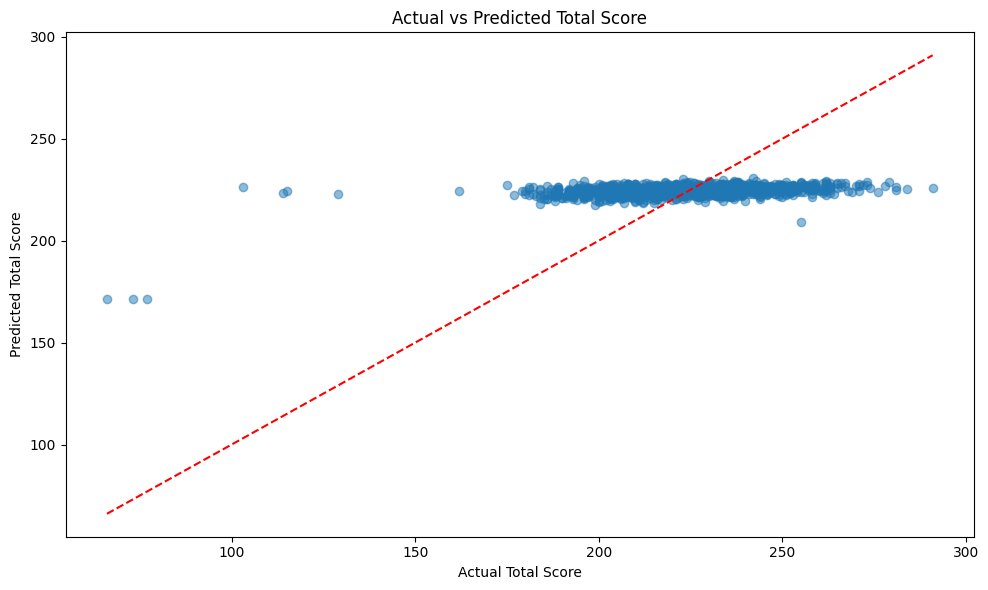


All models trained and saved to /Users/mattb/Desktop/Projects/score-genius/notebooks/models/pregame_model.pkl


In [9]:
# Cell 4A: Model Training with Chronological Validation and Feature Analysis

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

# Load features data from database
try:
    query = """
    SELECT * FROM nba_historical_game_stats 
    WHERE EXTRACT(YEAR FROM game_date) >= 2021
    ORDER BY game_date ASC
    """
    features_df = pd.read_sql(query, engine)
    print(f"Loaded {len(features_df)} records from database")
    
    # Ensure index is unique
    features_df = features_df.reset_index(drop=True)
    
    # Calculate target variables
    features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
    features_df['total_score'] = features_df['home_score'] + features_df['away_score']
    
    # Convert game_date to datetime if it's not already
    if not pd.api.types.is_datetime64_any_dtype(features_df['game_date']):
        features_df['game_date'] = pd.to_datetime(features_df['game_date'])
        
    # Sort by date to ensure chronological order
    features_df = features_df.sort_values('game_date').reset_index(drop=True)
    
except Exception as e:
    print(f"Error loading data: {e}")
    raise

# Define target variables
targets = ['home_score', 'away_score', 'point_diff', 'total_score']

# Select only numeric columns for features, excluding post-game statistics
numeric_columns = features_df.select_dtypes(include=['number']).columns.tolist()

# Define which features would be available pre-game (remove in-game stats)
postgame_columns = [
    'home_score', 'away_score', 'point_diff', 'total_score',
    'home_q1', 'home_q2', 'home_q3', 'home_q4', 'home_ot',
    'away_q1', 'away_q2', 'away_q3', 'away_q4', 'away_ot',
    'home_assists', 'home_steals', 'home_blocks', 'home_turnovers', 'home_fouls',
    'away_assists', 'away_steals', 'away_blocks', 'away_turnovers', 'away_fouls',
    'home_off_reb', 'home_def_reb', 'home_total_reb',
    'away_off_reb', 'away_def_reb', 'away_total_reb',
    'home_3pm', 'home_3pa', 'away_3pm', 'away_3pa',
    'home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted',
    'home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted'
]

# Define pregame features (features we would know before the game starts)
id_columns = ['id', 'game_id']
pregame_features = [col for col in numeric_columns 
                   if col not in postgame_columns + id_columns + targets]

# If pregame_features is empty, we need to create some features from historical data
if not pregame_features:
    print("Warning: No pregame features found. Creating features from historical data...")
    
    # Create team performance metrics from historical games
    # We'll create a dictionary to store team performances
    team_stats = {}
    
    # Process games chronologically
    for idx, row in features_df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        game_date = row['game_date']
        
        # Initialize team stats if not exists
        for team in [home_team, away_team]:
            if team not in team_stats:
                team_stats[team] = {'games': [], 'pts_scored': [], 'pts_allowed': []}
        
        # Add this game's stats to historical records for both teams
        # We only use these stats for future predictions, not for the current game
        if idx > 0:  # Skip first game as we don't have prior data
            # Record home team stats
            team_stats[home_team]['games'].append(game_date)
            team_stats[home_team]['pts_scored'].append(row['home_score'])
            team_stats[home_team]['pts_allowed'].append(row['away_score'])
            
            # Record away team stats
            team_stats[away_team]['games'].append(game_date)
            team_stats[away_team]['pts_scored'].append(row['away_score'])
            team_stats[away_team]['pts_allowed'].append(row['home_score'])
    
    # Now create the features for each game based on past performance
    features_df['home_last5_avg'] = 0.0
    features_df['home_last5_allowed'] = 0.0
    features_df['away_last5_avg'] = 0.0
    features_df['away_last5_allowed'] = 0.0
    
    # Calculate the 5-game rolling averages
    for idx, row in features_df.iterrows():
        home_team = row['home_team']
        away_team = row['away_team']
        game_date = row['game_date']
        
        # Skip games where we don't have enough history
        if home_team not in team_stats or away_team not in team_stats:
            continue
            
        # Get home team's last 5 games before this one
        home_past_games = [(i, score) for i, (date, score) in 
                           enumerate(zip(team_stats[home_team]['games'], 
                                        team_stats[home_team]['pts_scored']))
                           if date < game_date]
        
        # Get away team's last 5 games before this one
        away_past_games = [(i, score) for i, (date, score) in 
                           enumerate(zip(team_stats[away_team]['games'], 
                                        team_stats[away_team]['pts_scored']))
                           if date < game_date]
        
        # Calculate averages if we have data
        if home_past_games:
            # Sort by recency and take last 5
            home_past_games.sort(reverse=True)
            home_last5 = home_past_games[:5]
            
            if home_last5:
                features_df.at[idx, 'home_last5_avg'] = np.mean([score for _, score in home_last5])
                
                # Calculate points allowed
                home_last5_allowed = [team_stats[home_team]['pts_allowed'][i] for i, _ in home_last5]
                features_df.at[idx, 'home_last5_allowed'] = np.mean(home_last5_allowed)
        
        if away_past_games:
            # Sort by recency and take last 5
            away_past_games.sort(reverse=True)
            away_last5 = away_past_games[:5]
            
            if away_last5:
                features_df.at[idx, 'away_last5_avg'] = np.mean([score for _, score in away_last5])
                
                # Calculate points allowed
                away_last5_allowed = [team_stats[away_team]['pts_allowed'][i] for i, _ in away_last5]
                features_df.at[idx, 'away_last5_allowed'] = np.mean(away_last5_allowed)
    
    # Update our list of pregame features
    pregame_features = ['home_last5_avg', 'home_last5_allowed', 'away_last5_avg', 'away_last5_allowed']
    
    print(f"Created {len(pregame_features)} features: {pregame_features}")

# Split data chronologically (not randomly)
# Use the last 20% of games as a test set
test_size = 0.2
split_idx = int(len(features_df) * (1 - test_size))
train_df = features_df.iloc[:split_idx]
test_df = features_df.iloc[split_idx:]

print(f"Training on games from {train_df['game_date'].min()} to {train_df['game_date'].max()}")
print(f"Testing on games from {test_df['game_date'].min()} to {test_df['game_date'].max()}")

def train_model(X_train, y_train, X_test, y_test, model_name='ridge'):
    # Create a pipeline with imputation for missing values
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=1.0))
    ])
    
    # Fit the model on training data
    pipeline.fit(X_train, y_train)
    
    # Evaluate on test data
    y_pred = pipeline.predict(X_test)
    mae = np.mean(np.abs(y_test - y_pred))
    r2 = pipeline.score(X_test, y_test)
    
    # Calculate RMSE
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    
    print(f"Trained {model_name} model:")
    print(f"  - Test MAE: {mae:.2f}")
    print(f"  - Test RMSE: {rmse:.2f}")
    print(f"  - Test R²: {r2:.4f}")
    
    return pipeline, {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Train models for each target
models = {}
metrics = {}

for target in targets:
    print(f"\n{'-'*50}")
    print(f"Training model for {target}...")
    
    # Prepare train and test data
    X_train = train_df[pregame_features].copy()
    y_train = train_df[target]
    
    X_test = test_df[pregame_features].copy()
    y_test = test_df[target]
    
    # Check and report missing values
    train_missing = X_train.isna().sum().sum()
    if train_missing > 0:
        print(f"Warning: {train_missing} missing values in training features")
    
    # Train the model
    model, metric = train_model(X_train, y_train, X_test, y_test, model_name=target)
    models[target] = model
    metrics[target] = metric

# Plot actual vs predicted for the total_score model as an example
plt.figure(figsize=(10, 6))
y_test = test_df['total_score']
y_pred = models['total_score'].predict(test_df[pregame_features])

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Total Score')
plt.ylabel('Predicted Total Score')
plt.title('Actual vs Predicted Total Score')
plt.tight_layout()
plt.savefig('total_score_prediction.png')
plt.show()

# Save models
import joblib
joblib.dump(models, str(PREGAME_MODEL_PATH))
print(f"\nAll models trained and saved to {PREGAME_MODEL_PATH}")

In [10]:
# Cell 4B: Alternative Model Training using RandomForestRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

def train_rf_model(X_train, y_train, X_test, y_test, model_name='rf'):
    pipeline_rf = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
    
    param_grid_rf = {
        'regressor__n_estimators': [50, 100],
        'regressor__max_depth': [None, 5, 10],
        'regressor__min_samples_split': [2, 5]
    }
    
    grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid_rf.fit(X_train, y_train)
    
    best_rf = grid_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test)
    mae_rf = np.mean(np.abs(y_test - y_pred_rf))
    r2_rf = best_rf.score(X_test, y_test)
    rmse_rf = np.sqrt(np.mean((y_test - y_pred_rf)**2))
    
    print(f"RandomForest model for {model_name} - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R2: {r2_rf:.4f}")
    return best_rf, {'MAE': mae_rf, 'RMSE': rmse_rf, 'R2': r2_rf}

# Example usage for total_score model:
X_train_total = train_df[pregame_features].copy()
y_train_total = train_df['total_score']
X_test_total = test_df[pregame_features].copy()
y_test_total = test_df['total_score']

rf_model, rf_metric = train_rf_model(X_train_total, y_train_total, X_test_total, y_test_total, model_name='total_score')


RandomForest model for total_score - MAE: 15.62, RMSE: 21.00, R2: 0.0891


In [11]:
# Cell 4C: Residual Analysis and Bias Correction for Total Score Model

# Compute predictions on the training set using your existing total_score model
y_train_pred = models['total_score'].predict(train_df[pregame_features])
residuals = train_df['total_score'] - y_train_pred

bias = np.mean(residuals)
print(f"Average bias (residual) on training data: {bias:.2f}")

# Define a new prediction function that applies bias correction
def predict_with_bias_correction(model, X, bias):
    pred = model.predict(X)
    return pred + bias

# Apply bias correction on the test set
y_test_pred_corrected = predict_with_bias_correction(models['total_score'], test_df[pregame_features], bias)
mae_corrected = np.mean(np.abs(test_df['total_score'] - y_test_pred_corrected))
rmse_corrected = np.sqrt(np.mean((test_df['total_score'] - y_test_pred_corrected)**2))
r2_corrected = 1 - np.sum((test_df['total_score'] - y_test_pred_corrected)**2) / np.sum((test_df['total_score'] - np.mean(test_df['total_score']))**2)

print(f"After bias correction - Test MAE: {mae_corrected:.2f}, RMSE: {rmse_corrected:.2f}, R2: {r2_corrected:.4f}")

# Use this bias correction factor in your prediction pipeline to adjust low scores.


Average bias (residual) on training data: -0.00
After bias correction - Test MAE: 16.04, RMSE: 20.70, R2: 0.1148


In [12]:
# Cell 4D: Training on Recent Data (Last 6 Months)

import pandas as pd
from datetime import timedelta

# Define a cutoff date for recent data (last 6 months from the latest game_date)
cutoff_date = features_df['game_date'].max() - timedelta(days=180)
recent_df = features_df[features_df['game_date'] >= cutoff_date].reset_index(drop=True)

print(f"Using recent data from {recent_df['game_date'].min()} to {recent_df['game_date'].max()} for training.")

# Split recent_df chronologically (80% training, 20% test)
split_idx_recent = int(len(recent_df) * 0.8)
train_recent = recent_df.iloc[:split_idx_recent]
test_recent = recent_df.iloc[split_idx_recent:]

# Train a model for 'total_score' on recent data using Ridge (or your preferred regressor)
X_train_recent = train_recent[pregame_features].copy()
y_train_recent = train_recent['total_score']
X_test_recent = test_recent[pregame_features].copy()
y_test_recent = test_recent['total_score']

ridge_recent, metric_recent = train_model(X_train_recent, y_train_recent, X_test_recent, y_test_recent, model_name='total_score_recent')
print("Recent data model metrics:", metric_recent)


Using recent data from 2024-10-04 00:00:00 to 2025-03-19 00:00:00 for training.
Trained total_score_recent model:
  - Test MAE: 17.56
  - Test RMSE: 25.57
  - Test R²: 0.1164
Recent data model metrics: {'MAE': 17.555091980267107, 'RMSE': 25.573175453133032, 'R2': 0.11640526099238935}


In [13]:
# Cell 5: Feature Engineering - Fixed Column Names

import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta

def build_pregame_features(historical_df, team_metrics_df, lookback_days=120):
    """
    Builds a feature dataset for pre-game predictions from historical game data.
    Incorporates advanced statistics from the nba_historical_game_stats table.
    Args:
        historical_df: DataFrame with historical games
        team_metrics_df: DataFrame with team metrics
        lookback_days: Days to look back for recent games
    Returns:
        DataFrame with features for model training
    """
    try:
        if historical_df.empty or team_metrics_df.empty:
            print("Insufficient data for feature engineering.")
            return pd.DataFrame()
        
        # Check for required columns in team_metrics_df
        required_columns = ['team', 'win_pct', 'offensive_rating', 'defensive_rating', 'net_rating']
        missing_columns = [col for col in required_columns if col not in team_metrics_df.columns]
        
        if missing_columns:
            print(f"WARNING: Missing required columns in team_metrics_df: {missing_columns}")
            print(f"Available columns: {team_metrics_df.columns.tolist()}")
            
            # Add missing columns with default values
            for col in missing_columns:
                if col == 'win_pct':
                    team_metrics_df[col] = 0.5
                elif col in ['offensive_rating', 'defensive_rating']:
                    team_metrics_df[col] = 110.0
                elif col == 'net_rating':
                    team_metrics_df[col] = 0.0
                else:
                    team_metrics_df[col] = 0.0
            
            print("Added default values for missing columns")
        
        # Filter for recent games
        cutoff_date = datetime.now() - timedelta(days=lookback_days)
        recent_games = historical_df[historical_df['game_date'] >= cutoff_date].copy()
        if recent_games.empty:
            print(f"No games found in the last {lookback_days} days.")
            return pd.DataFrame()
        
        # Calculate rolling stats
        rolling_stats = calculate_rolling_stats(historical_df, window=10)
        
        # Create lookup for team metrics (handle both original and normalized team names)
        team_metrics_lookup = {}
        for _, row in team_metrics_df.iterrows():
            team_name = row['team']
            team_metrics_lookup[team_name] = row
            team_metrics_lookup[team_name.lower()] = row
            
            # Also store with normalized name if available
            if 'team_normalized' in row and row['team_normalized']:
                team_metrics_lookup[row['team_normalized']] = row
        
        feature_list = []
        processed_count = 0
        total_count = len(recent_games)
        
        for idx, game in recent_games.iterrows():
            try:
                processed_count += 1
                if processed_count % 100 == 0:
                    print(f"Processing game {processed_count} of {total_count}")
                    
                game_date = pd.to_datetime(game['game_date'])
                home_team = game['home_team']
                away_team = game['away_team']
                
                # Try multiple ways to look up team metrics
                home_team_lower = home_team.lower()
                away_team_lower = away_team.lower()
                home_team_normalized = normalize_team_name(home_team)
                away_team_normalized = normalize_team_name(away_team)
                
                # Get team metrics
                home_metrics = None
                if home_team in team_metrics_lookup:
                    home_metrics = team_metrics_lookup[home_team]
                elif home_team_lower in team_metrics_lookup:
                    home_metrics = team_metrics_lookup[home_team_lower]
                elif home_team_normalized in team_metrics_lookup:
                    home_metrics = team_metrics_lookup[home_team_normalized]
                
                away_metrics = None
                if away_team in team_metrics_lookup:
                    away_metrics = team_metrics_lookup[away_team]
                elif away_team_lower in team_metrics_lookup:
                    away_metrics = team_metrics_lookup[away_team_lower]
                elif away_team_normalized in team_metrics_lookup:
                    away_metrics = team_metrics_lookup[away_team_normalized]
                
                # Skip if we don't have metrics for either team
                if home_metrics is None or away_metrics is None:
                    print(f"Skipping game: Missing metrics for {home_team} or {away_team}")
                    continue
                
                # Get matchup history
                matchup = get_matchup_history(home_team, away_team)
                
                # Get rest data
                home_rest = get_rest_data(home_team, game_date)
                away_rest = get_rest_data(away_team, game_date)
                
                # Get rolling stats (try different variations of team names)
                home_rolling = {}
                for name in [home_team, home_team_lower, home_team_normalized]:
                    if name in rolling_stats:
                        home_rolling = rolling_stats[name]
                        break
                
                away_rolling = {}
                for name in [away_team, away_team_lower, away_team_normalized]:
                    if name in rolling_stats:
                        away_rolling = rolling_stats[name]
                        break
                
                # Safe function to get values from game dictionary
                def safe_get(field, default=0):
                    return game.get(field, default)
                
                # Calculate additional advanced metrics from box score stats
                # Safely get base statistics
                home_3pm = safe_get('home_3pm')
                home_3pa = safe_get('home_3pa')
                away_3pm = safe_get('away_3pm')
                away_3pa = safe_get('away_3pa')
                
                # Shooting efficiency
                home_3p_pct = home_3pm / home_3pa if home_3pa > 0 else 0
                away_3p_pct = away_3pm / away_3pa if away_3pa > 0 else 0
                
                # Check if new metrics fields exist in the data
                has_fg_stats = all(field in game for field in ['home_fg_made', 'home_fg_attempted', 'away_fg_made', 'away_fg_attempted'])
                has_ft_stats = all(field in game for field in ['home_ft_made', 'home_ft_attempted', 'away_ft_made', 'away_ft_attempted'])
                
                # Field goal percentages
                home_fg_made = safe_get('home_fg_made')
                home_fg_attempted = safe_get('home_fg_attempted')
                away_fg_made = safe_get('away_fg_made')
                away_fg_attempted = safe_get('away_fg_attempted')
                
                home_fg_pct = home_fg_made / home_fg_attempted if home_fg_attempted > 0 else 0.45  # Default FG% is 45%
                away_fg_pct = away_fg_made / away_fg_attempted if away_fg_attempted > 0 else 0.45
                
                # Free throw percentages
                home_ft_made = safe_get('home_ft_made')
                home_ft_attempted = safe_get('home_ft_attempted')
                away_ft_made = safe_get('away_ft_made')
                away_ft_attempted = safe_get('away_ft_attempted')
                
                home_ft_pct = home_ft_made / home_ft_attempted if home_ft_attempted > 0 else 0.75  # Default FT% is 75%
                away_ft_pct = away_ft_made / away_ft_attempted if away_ft_attempted > 0 else 0.75
                
                # Calculate possessions (FGA−ORB+TO+0.44×FTA)
                # Use original formula if stats are available, otherwise use simpler estimate
                if has_fg_stats and has_ft_stats:
                    home_possessions = (
                        home_fg_attempted - 
                        safe_get('home_off_reb') +  # CORRECTED: Using proper column name
                        safe_get('home_turnovers') + 
                        0.44 * home_ft_attempted
                    )
                    
                    away_possessions = (
                        away_fg_attempted - 
                        safe_get('away_off_reb') +  # CORRECTED: Using proper column name
                        safe_get('away_turnovers') + 
                        0.44 * away_ft_attempted
                    )
                else:
                    # Fallback to simpler possession estimate
                    home_possessions = safe_get('home_total_reb') + safe_get('home_turnovers') + safe_get('home_assists')
                    away_possessions = safe_get('away_total_reb') + safe_get('away_turnovers') + safe_get('away_assists')
                
                # Calculate pace (Possessions * 48 / Minutes)
                minutes_per_game = 48
                home_pace = home_possessions * 48 / minutes_per_game
                away_pace = away_possessions * 48 / minutes_per_game
                
                # Calculate offensive efficiency (Points Scored / Possessions) * 100
                home_off_eff = (safe_get('home_score') / max(home_possessions, 1)) * 100
                away_off_eff = (safe_get('away_score') / max(away_possessions, 1)) * 100
                
                # Original possession estimate (simple version)
                home_poss = safe_get('home_total_reb') + safe_get('home_turnovers') + safe_get('home_assists')
                away_poss = safe_get('away_total_reb') + safe_get('away_turnovers') + safe_get('away_assists')
                
                # Rebounding advantage
                total_rebounds = safe_get('home_total_reb') + safe_get('away_total_reb')
                home_reb_pct = safe_get('home_total_reb') / total_rebounds if total_rebounds > 0 else 0.5
                
                # Ball control (assist to turnover ratio)
                home_ast_to = safe_get('home_assists') / max(safe_get('home_turnovers'), 1)
                away_ast_to = safe_get('away_assists') / max(safe_get('away_turnovers'), 1)
                
                # Defense impact metrics
                home_steal_block = safe_get('home_steals') + safe_get('home_blocks')
                away_steal_block = safe_get('away_steals') + safe_get('away_blocks')
                
                # Safely get metrics from team data
                def safe_metric(team_data, field, default=0):
                    if field in team_data:
                        return team_data[field]
                    return default
                
                # Build features dictionary
                features = {
                    'game_id': game.get('game_id', 0),
                    'game_date': game_date,
                    'home_team': home_team,
                    'away_team': away_team,
                    
                    # Team performance metrics
                    'home_win_pct': safe_metric(home_metrics, 'win_pct', 0.5),
                    'away_win_pct': safe_metric(away_metrics, 'win_pct', 0.5),
                    'home_offensive_rating': safe_metric(home_metrics, 'offensive_rating', 110.0),
                    'away_offensive_rating': safe_metric(away_metrics, 'offensive_rating', 110.0),
                    'home_defensive_rating': safe_metric(home_metrics, 'defensive_rating', 110.0),
                    'away_defensive_rating': safe_metric(away_metrics, 'defensive_rating', 110.0),
                    'home_net_rating': safe_metric(home_metrics, 'net_rating', 0.0),
                    'away_net_rating': safe_metric(away_metrics, 'net_rating', 0.0),
                    'net_rating_diff': safe_metric(home_metrics, 'net_rating', 0.0) - safe_metric(away_metrics, 'net_rating', 0.0),
                    
                    # Rolling stats
                    'home_rolling_score': home_rolling.get('rolling_score', safe_metric(home_metrics, 'pts_per_game', 110.0)),
                    'away_rolling_score': away_rolling.get('rolling_score', safe_metric(away_metrics, 'pts_per_game', 110.0)),
                    'home_rolling_opp_score': home_rolling.get('rolling_opp_score', safe_metric(home_metrics, 'opp_pts_per_game', 110.0)),
                    'away_rolling_opp_score': away_rolling.get('rolling_opp_score', safe_metric(away_metrics, 'opp_pts_per_game', 110.0)),
                    
                    # Rest factors
                    'home_rest_days': home_rest['rest_days'],
                    'away_rest_days': away_rest['rest_days'],
                    'rest_advantage': home_rest['rest_days'] - away_rest['rest_days'],
                    'home_back_to_back': int(home_rest['is_back_to_back']),
                    'away_back_to_back': int(away_rest['is_back_to_back']),
                    
                    # Matchup history
                    'matchup_games': matchup['num_games'],
                    'matchup_point_diff': matchup['avg_point_diff'],
                    'home_historical_win_pct': matchup['home_win_pct'],
                    
                    # Home court advantage
                    'home_advantage': safe_metric(home_metrics, 'home_advantage', 3.5),
                    
                    # Quarter scoring patterns
                    'home_q1_points': safe_get('home_q1'),
                    'home_q2_points': safe_get('home_q2'),
                    'home_q3_points': safe_get('home_q3'),
                    'home_q4_points': safe_get('home_q4'),
                    'away_q1_points': safe_get('away_q1'),
                    'away_q2_points': safe_get('away_q2'),
                    'away_q3_points': safe_get('away_q3'),
                    'away_q4_points': safe_get('away_q4'),
                    'home_first_half': safe_get('home_q1') + safe_get('home_q2'),
                    'home_second_half': safe_get('home_q3') + safe_get('home_q4'),
                    'away_first_half': safe_get('away_q1') + safe_get('away_q2'),
                    'away_second_half': safe_get('away_q3') + safe_get('away_q4'),
                    
                    # Box score statistics
                    'home_assists': safe_get('home_assists'),
                    'away_assists': safe_get('away_assists'),
                    'home_steals': safe_get('home_steals'),
                    'away_steals': safe_get('away_steals'),
                    'home_blocks': safe_get('home_blocks'),
                    'away_blocks': safe_get('away_blocks'),
                    'home_turnovers': safe_get('home_turnovers'),
                    'away_turnovers': safe_get('away_turnovers'),
                    'home_fouls': safe_get('home_fouls'),
                    'away_fouls': safe_get('away_fouls'),
                    
                    # CORRECTED: Rebounding - using exact column names from Supabase
                    'home_off_reb': safe_get('home_off_reb'),
                    'away_off_reb': safe_get('away_off_reb'),
                    'home_def_reb': safe_get('home_def_reb'),
                    'away_def_reb': safe_get('away_def_reb'),
                    'home_total_reb': safe_get('home_total_reb'),
                    'away_total_reb': safe_get('away_total_reb'),
                    
                    # Three-point shooting
                    'home_3pm': home_3pm,
                    'home_3pa': home_3pa,
                    'away_3pm': away_3pm,
                    'away_3pa': away_3pa,
                    'home_3p_pct': home_3p_pct,
                    'away_3p_pct': away_3p_pct,
                    
                    # Advanced metrics from existing code
                    'home_poss_estimate': home_poss,
                    'away_poss_estimate': away_poss,
                    'home_rebounding_pct': home_reb_pct,
                    'away_rebounding_pct': 1 - home_reb_pct,
                    'home_ast_to_ratio': home_ast_to,
                    'away_ast_to_ratio': away_ast_to,
                    'home_def_impact': home_steal_block,
                    'away_def_impact': away_steal_block,
                    'home_off_to_def_ratio': safe_get('home_assists') / (safe_get('home_turnovers') + 1),
                    'away_off_to_def_ratio': safe_get('away_assists') / (safe_get('away_turnovers') + 1),
                    
                    # Field Goal statistics
                    'home_fg_made': home_fg_made,
                    'home_fg_attempted': home_fg_attempted,
                    'away_fg_made': away_fg_made,
                    'away_fg_attempted': away_fg_attempted,
                    'home_fg_pct': home_fg_pct,
                    'away_fg_pct': away_fg_pct,
                    
                    # Free Throw statistics
                    'home_ft_made': home_ft_made,
                    'home_ft_attempted': home_ft_attempted,
                    'away_ft_made': away_ft_made,
                    'away_ft_attempted': away_ft_attempted,
                    'home_ft_pct': home_ft_pct,
                    'away_ft_pct': away_ft_pct,
                    
                    # ADDED: Form metrics with proper handling for missing data
                    'home_form': safe_metric(home_metrics, 'form_string', ''),  # CORRECTED: Using form_string instead of current_form
                    'away_form': safe_metric(away_metrics, 'form_string', ''),  # CORRECTED: Using form_string instead of current_form
                    'home_form_win_pct': safe_metric(home_metrics, 'form_win_pct', 0.5),
                    'away_form_win_pct': safe_metric(away_metrics, 'form_win_pct', 0.5),
                    'home_current_streak': safe_metric(home_metrics, 'current_streak', 0),
                    'away_current_streak': safe_metric(away_metrics, 'current_streak', 0),
                    'home_momentum': safe_metric(home_metrics, 'momentum_score', 0),  # CORRECTED: Using momentum_score instead of momentum_direction
                    'away_momentum': safe_metric(away_metrics, 'momentum_score', 0),  # CORRECTED: Using momentum_score instead of momentum_direction
                    'momentum_advantage': safe_metric(home_metrics, 'momentum_score', 0) - safe_metric(away_metrics, 'momentum_score', 0),
                    'streak_differential': safe_metric(home_metrics, 'current_streak', 0) - safe_metric(away_metrics, 'current_streak', 0),
                    
                    # Possession-based metrics
                    'home_possessions': home_possessions,
                    'away_possessions': away_possessions,
                    'home_pace': home_pace,
                    'away_pace': away_pace,
                    'home_offensive_efficiency': home_off_eff,
                    'away_offensive_efficiency': away_off_eff,
                    'pace_differential': home_pace - away_pace,
                    'efficiency_differential': home_off_eff - away_off_eff,
                    
                    # Include team average metrics
                    'home_avg_fg_pct': safe_metric(home_metrics, 'fg_pct', 0.45),
                    'away_avg_fg_pct': safe_metric(away_metrics, 'fg_pct', 0.45),
                    'home_avg_ft_pct': safe_metric(home_metrics, 'ft_pct', 0.75),
                    'away_avg_ft_pct': safe_metric(away_metrics, 'ft_pct', 0.75),
                    'home_avg_pace': safe_metric(home_metrics, 'pace', 98),
                    'away_avg_pace': safe_metric(away_metrics, 'pace', 98),
                    'home_avg_off_efficiency': safe_metric(home_metrics, 'offensive_efficiency', 110),
                    'away_avg_off_efficiency': safe_metric(away_metrics, 'offensive_efficiency', 110),
                    'home_avg_def_efficiency': safe_metric(home_metrics, 'defensive_efficiency', 110),
                    'away_avg_def_efficiency': safe_metric(away_metrics, 'defensive_efficiency', 110),
                    
                    # Target variables
                    'home_score': safe_get('home_score'),
                    'away_score': safe_get('away_score'),
                    'point_diff': safe_get('home_score') - safe_get('away_score'),
                    'total_score': safe_get('home_score') + safe_get('away_score')
                }
                
                feature_list.append(features)
                
            except Exception as e:
                print(f"Error processing game {game.get('game_id', 'unknown')}: {str(e)}")
                traceback.print_exc()
                continue
        
        # Handle empty feature list
        if not feature_list:
            print("No features could be generated. Check for data issues.")
            return pd.DataFrame()
            
        # Convert to DataFrame
        features_df = pd.DataFrame(feature_list)
        
        # Store string features separately but exclude from training data
        string_columns = ['game_id', 'game_date', 'home_team', 'away_team', 'home_form', 'away_form']
        string_features = {col: features_df[col] for col in string_columns if col in features_df.columns}
        
        # Handle potential infinite values
        features_df = features_df.replace([np.inf, -np.inf], np.nan)
        
        # Handle missing values
        numeric_cols = features_df.select_dtypes(include=np.number).columns
        features_df[numeric_cols] = features_df[numeric_cols].fillna(0)
        
        print(f"Built pre-game features for {len(features_df)} games with full statistics.")
        return features_df
        
    except Exception as e:
        print(f"Error in build_pregame_features: {str(e)}")
        traceback.print_exc()
        return pd.DataFrame()

In [14]:
# Cell 6 - Model Training Functions

def train_pregame_model(features_df, target='home_score'):
    """
    Trains a model for pre-game predictions
    
    Args:
        features_df: DataFrame with pre-game features
        target: Target variable to predict ('home_score', 'away_score', 'point_diff', or 'total_score')
        
    Returns:
        Trained model and validation metrics
    """
    if features_df.empty:
        print("No training data available")
        return None, {}
    
    print(f"Training pre-game prediction model for target: {target}")
    
    # Select only numeric columns for features
    # Exclude game identifiers, team names, and target variables
    non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                       'home_score', 'away_score', 'point_diff', 'total_score',
                       'home_form', 'away_form', 'id']  # Added 'id' from Supabase table
    
    feature_columns = [col for col in features_df.select_dtypes(include=np.number).columns 
                       if col not in non_feature_cols]
    
    # Prepare feature matrix and target vector
    X = features_df[feature_columns]
    y = features_df[target]
    
    print(f"Training with {len(X)} samples and {len(feature_columns)} features")
    
    # Sort by date to ensure time-based validation
    if 'game_date' in features_df.columns:
        sorted_indices = features_df['game_date'].sort_values().index
        X = X.loc[sorted_indices]
        y = y.loc[sorted_indices]
    
    # Split data into training and testing sets (using time-based split)
    train_size = int(0.8 * len(X))
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
    
    # Define model with optimized parameters
    model = GradientBoostingRegressor(
        n_estimators=200, 
        learning_rate=0.1,
        max_depth=4,
        min_samples_split=10,  # Added for better stability
        random_state=42,
        subsample=0.8
    )
    
    # Train model
    model.fit(X_train, y_train)
    
    # Evaluate on training and test sets
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # Calculate metrics
    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)
    r2 = r2_score(y_test, test_preds)
    
    # Calculate RMSE (root mean squared error)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    metrics = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,  # Added RMSE
        'test_rmse': test_rmse,    # Added RMSE 
        'r2': r2,
        'feature_importance': dict(zip(feature_columns, model.feature_importances_))
    }
    
    print(f"Training MSE: {train_mse:.2f}, RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}")
    print(f"Test MSE: {test_mse:.2f}, RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}")
    print(f"R² Score: {r2:.4f}")
    
    # Find and display top 10 most important features
    importance = model.feature_importances_
    feature_importance = pd.Series(importance, index=feature_columns).sort_values(ascending=False)
    top_features = feature_importance.head(10)
    
    print("\nTop 10 most important features:")
    for feature, importance in top_features.items():
        print(f"{feature}: {importance:.4f}")
    
    # Save model path
    model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
    joblib.dump(model, model_path)
    print(f"Model saved to {model_path}")
    
    return model, metrics

def train_multiple_models(features_df):
    """
    Trains multiple models for different prediction targets
    
    Args:
        features_df: DataFrame with pre-game features
        
    Returns:
        Dictionary of trained models and metrics
    """
    models = {}
    
    # Check for required target columns
    required_targets = ['home_score', 'away_score', 'point_diff', 'total_score']
    missing_targets = [col for col in required_targets if col not in features_df.columns]
    
    if missing_targets:
        print(f"WARNING: Missing target columns: {missing_targets}")
        # Calculate any missing targets if possible
        if 'home_score' in features_df.columns and 'away_score' in features_df.columns:
            if 'point_diff' not in features_df.columns:
                features_df['point_diff'] = features_df['home_score'] - features_df['away_score']
                print("Created 'point_diff' from home_score and away_score")
            
            if 'total_score' not in features_df.columns:
                features_df['total_score'] = features_df['home_score'] + features_df['away_score']
                print("Created 'total_score' from home_score and away_score")
    
    # Train home score model
    print("\n=== TRAINING HOME SCORE MODEL ===")
    home_model, home_metrics = train_pregame_model(features_df, target='home_score')
    models['home_score'] = {
        'model': home_model,
        'metrics': home_metrics
    }
    
    # Train away score model
    print("\n=== TRAINING AWAY SCORE MODEL ===")
    away_model, away_metrics = train_pregame_model(features_df, target='away_score')
    models['away_score'] = {
        'model': away_model,
        'metrics': away_metrics
    }
    
    # Train point differential model
    print("\n=== TRAINING POINT DIFFERENTIAL MODEL ===")
    diff_model, diff_metrics = train_pregame_model(features_df, target='point_diff')
    models['point_diff'] = {
        'model': diff_model,
        'metrics': diff_metrics
    }
    
    # Train total score model
    print("\n=== TRAINING TOTAL SCORE MODEL ===")
    total_model, total_metrics = train_pregame_model(features_df, target='total_score')
    models['total_score'] = {
        'model': total_model,
        'metrics': total_metrics
    }
    
    return models

In [15]:
# Cell 7 - Calculate Metrics, Predict Upcoming Games

import math
import traceback
import pandas as pd
import numpy as np
from datetime import datetime

def find_team_metrics(team_metrics_df, team_name):
    """
    Find a team's metrics in the team_metrics_df, handling different name formats.
    """
    # Try exact match first
    team_row = team_metrics_df[team_metrics_df['team'] == team_name]
    
    # If not found, try lowercase match
    if team_row.empty:
        team_row = team_metrics_df[team_metrics_df['team'].str.lower() == team_name.lower()]
    
    # If still not found, try partial match
    if team_row.empty:
        team_row = team_metrics_df[team_metrics_df['team'].str.contains(team_name, case=False)]
    
    # If found, return as dictionary
    if not team_row.empty:
        return team_row.iloc[0].to_dict()
    
    # Not found, return empty dict with warning
    print(f"WARNING: Could not find metrics for team '{team_name}'")
    return {}

def calculate_win_probability(home_score, away_score, k=0.1):
    """
    Calculates win probability for the home team using a logistic function.
    """
    score_diff = home_score - away_score
    return 1.0 / (1.0 + math.exp(-k * score_diff))

def calculate_league_average_metrics(team_metrics):
    """
    Calculate league average metrics to use as fallback values.
    """
    # Default values in case calculation fails
    default_metrics = {
        'team': 'LEAGUE_AVG',
        'team_normalized': 'league_avg',
        'win_pct': 0.5,
        'pts_per_game': 110,
        'opp_pts_per_game': 110,
        'net_rating': 0,
        'offensive_rating': 110,
        'defensive_rating': 110,
        'assists_avg': 22,
        'turnovers_avg': 14,
        'steals_avg': 8,
        'blocks_avg': 5,
        'fouls_avg': 20,
        'total_reb_avg': 42,
        'off_reb_avg': 10,
        'three_made_avg': 12,
        'three_att_avg': 35,
        'three_pt_pct': 0.35,
        'ast_to_ratio': 1.5,
        'defense_impact': 13,
        'home_advantage': 2.5,
        'q1_avg': 27.5,
        'q4_avg': 27.5,
        'q1_q4_ratio': 1.0,
        # Form metrics
        'current_form': '',
        'form_win_pct': 0.5,
        'current_streak': 0,
        'momentum_direction': 0,
        # New default metrics
        'fg_made_avg': 40,
        'fg_att_avg': 88,
        'fg_pct': 0.45,
        'ft_made_avg': 19,
        'ft_att_avg': 25,
        'ft_pct': 0.75,
        'possessions': 100,
        'pace': 98,
        'offensive_efficiency': 110,
        'defensive_efficiency': 110,
        'efficiency_differential': 0
    }
    
    try:
        if team_metrics is None or team_metrics.empty:
            print("WARNING: Empty team metrics dataframe, using default values")
            return default_metrics
        
        # Calculate averages from team metrics
        league_avg = {'team': 'LEAGUE_AVG', 'team_normalized': 'league_avg'}
        
        # Only include numeric columns
        numeric_cols = team_metrics.select_dtypes(include=np.number).columns
        
        for col in numeric_cols:
            try:
                league_avg[col] = team_metrics[col].mean()
                if pd.isna(league_avg[col]):
                    league_avg[col] = default_metrics.get(col, 0)
            except Exception as e:
                print(f"Error calculating average for {col}: {e}")
                if col in default_metrics:
                    league_avg[col] = default_metrics[col]
        
        # Ensure all required metrics exist
        for key, value in default_metrics.items():
            if key not in league_avg:
                league_avg[key] = value
        
        # Check for NaN values and replace with defaults
        for key in league_avg:
            if isinstance(league_avg[key], (int, float)) and pd.isna(league_avg[key]):
                league_avg[key] = default_metrics.get(key, 0)
                
        return league_avg
        
    except Exception as e:
        print(f"Error calculating league averages: {e}")
        traceback.print_exc()
        return default_metrics

def predict_upcoming_game(game, team_metrics_df, rolling_stats_df, models, historical_games_df=None):
    """
    Predict scores and win probability for an upcoming game with enhanced feature engineering
    and adjustments to match realistic betting lines.
    """
    try:
        # Convert game to dictionary if it's a Series
        if isinstance(game, pd.Series):
            game = game.to_dict()
            
        # Identify teams
        home_team = game['home_team']
        away_team = game['away_team']
        
        print(f"Making prediction for {home_team} vs {away_team}...")
        
        # Find team metrics - ensure proper team name matching
        home_team_metrics = find_team_metrics(team_metrics_df, home_team)
        away_team_metrics = find_team_metrics(team_metrics_df, away_team)
        
        # Get matchup history
        matchup = get_matchup_history(home_team, away_team, historical_games_df, team_metrics_df)
        
        # Get betting line information - important for calibrating predictions
        home_spread = game.get('home_spread', None)
        over_under_line = game.get('over_under_line', None)
        
        # Log betting information if available
        if home_spread is not None:
            print(f"Vegas line: {home_team} {'+' if home_spread > 0 else ''}{home_spread}")
        if over_under_line is not None:
            print(f"Over/Under: {over_under_line}")
        
        # Build feature dictionary with comprehensive features
        feature_dict = {}
        
        # Game identifiers
        feature_dict['game_id'] = game.get('game_id', 0)
        feature_dict['home_team'] = home_team
        feature_dict['away_team'] = away_team
        
        # Team performance metrics
        feature_dict['home_win_pct'] = home_team_metrics.get('win_pct', 0.5)
        feature_dict['away_win_pct'] = away_team_metrics.get('win_pct', 0.5)
        feature_dict['home_offensive_rating'] = home_team_metrics.get('offensive_rating', 110.0)
        feature_dict['away_offensive_rating'] = away_team_metrics.get('offensive_rating', 110.0)
        feature_dict['home_defensive_rating'] = home_team_metrics.get('defensive_rating', 110.0)
        feature_dict['away_defensive_rating'] = away_team_metrics.get('defensive_rating', 110.0)
        feature_dict['home_net_rating'] = home_team_metrics.get('net_rating', 0.0)
        feature_dict['away_net_rating'] = away_team_metrics.get('net_rating', 0.0)
        feature_dict['net_rating_diff'] = feature_dict['home_net_rating'] - feature_dict['away_net_rating']
        
        # Incorporate net rating difference more strongly - this helps create realistic spreads
        feature_dict['net_rating_factor'] = feature_dict['net_rating_diff'] * 1.5  # Amplify the impact
        
        # Matchup history
        feature_dict['matchup_games'] = matchup['num_games']
        feature_dict['matchup_point_diff'] = matchup['avg_point_diff']
        feature_dict['home_historical_win_pct'] = matchup['home_win_pct']
        feature_dict['home_advantage'] = home_team_metrics.get('home_advantage', 3.5)
        
        # Rest days
        home_rest_days = float(game.get('home_rest_days', 2.0))
        away_rest_days = float(game.get('away_rest_days', 2.0))
        feature_dict['home_rest_days'] = home_rest_days
        feature_dict['away_rest_days'] = away_rest_days
        feature_dict['rest_advantage'] = home_rest_days - away_rest_days
        feature_dict['home_back_to_back'] = 1.0 if home_rest_days == 0 else 0.0
        feature_dict['away_back_to_back'] = 1.0 if away_rest_days == 0 else 0.0
        
        print(f"Rest days: Home={home_rest_days}, Away={away_rest_days}, Advantage={feature_dict['rest_advantage']}")
        
        # Rolling stats
        home_rolling = rolling_stats_df.get(home_team, {})
        away_rolling = rolling_stats_df.get(away_team, {})
        feature_dict['home_rolling_score'] = home_rolling.get('rolling_score', home_team_metrics.get('pts_per_game', 110.0))
        feature_dict['away_rolling_score'] = away_rolling.get('rolling_score', away_team_metrics.get('pts_per_game', 110.0))
        feature_dict['home_rolling_opp_score'] = home_rolling.get('rolling_opp_score', home_team_metrics.get('opp_pts_per_game', 110.0))
        feature_dict['away_rolling_opp_score'] = away_rolling.get('rolling_opp_score', away_team_metrics.get('opp_pts_per_game', 110.0))
        
        # Quarter scoring patterns
        feature_dict['home_q1_points'] = home_team_metrics.get('q1_avg', 27.5)
        feature_dict['home_q2_points'] = home_team_metrics.get('q2_avg', 27.5)
        feature_dict['home_q3_points'] = home_team_metrics.get('q3_avg', 27.0)
        feature_dict['home_q4_points'] = home_team_metrics.get('q4_avg', 28.0)
        feature_dict['away_q1_points'] = away_team_metrics.get('q1_avg', 27.5)
        feature_dict['away_q2_points'] = away_team_metrics.get('q2_avg', 27.5)
        feature_dict['away_q3_points'] = away_team_metrics.get('q3_avg', 27.0)
        feature_dict['away_q4_points'] = away_team_metrics.get('q4_avg', 28.0)
        
        # Calculate first half and second half points
        feature_dict['home_first_half'] = feature_dict['home_q1_points'] + feature_dict['home_q2_points']
        feature_dict['home_second_half'] = feature_dict['home_q3_points'] + feature_dict['home_q4_points']
        feature_dict['away_first_half'] = feature_dict['away_q1_points'] + feature_dict['away_q2_points']
        feature_dict['away_second_half'] = feature_dict['away_q3_points'] + feature_dict['away_q4_points']
        
        # BOX SCORE STATS - these are important for realistic predictions
        
        # Assists stats - teams with high assist numbers generally score more efficiently
        feature_dict['home_assists'] = home_team_metrics.get('assists_avg', 24.0)
        feature_dict['away_assists'] = away_team_metrics.get('assists_avg', 24.0)
        feature_dict['assist_diff'] = feature_dict['home_assists'] - feature_dict['away_assists']
        
        # Defensive stats
        feature_dict['home_steals'] = home_team_metrics.get('steals_avg', 7.5)
        feature_dict['away_steals'] = away_team_metrics.get('steals_avg', 7.5)
        feature_dict['home_blocks'] = home_team_metrics.get('blocks_avg', 5.0)
        feature_dict['away_blocks'] = away_team_metrics.get('blocks_avg', 5.0)
        feature_dict['home_turnovers'] = home_team_metrics.get('turnovers_avg', 14.0)
        feature_dict['away_turnovers'] = away_team_metrics.get('turnovers_avg', 14.0)
        feature_dict['home_fouls'] = home_team_metrics.get('fouls_avg', 20.0)
        feature_dict['away_fouls'] = away_team_metrics.get('fouls_avg', 20.0)
        
        # Rebounding stats
        feature_dict['home_off_reb'] = home_team_metrics.get('off_reb_avg', 10.5)
        feature_dict['away_off_reb'] = away_team_metrics.get('off_reb_avg', 10.0)
        feature_dict['home_def_reb'] = home_team_metrics.get('def_reb_avg', 33.0)
        feature_dict['away_def_reb'] = away_team_metrics.get('def_reb_avg', 32.0)
        feature_dict['home_total_reb'] = home_team_metrics.get('total_reb_avg', 43.5)
        feature_dict['away_total_reb'] = away_team_metrics.get('total_reb_avg', 42.0)
        feature_dict['reb_diff'] = feature_dict['home_total_reb'] - feature_dict['away_total_reb']
        
        # Three-point shooting - highly correlated with modern NBA scoring
        feature_dict['home_3pm'] = home_team_metrics.get('three_pt_made_avg', 12.0)
        feature_dict['home_3pa'] = home_team_metrics.get('three_pt_att_avg', 35.0)
        feature_dict['away_3pm'] = away_team_metrics.get('three_pt_made_avg', 12.0)
        feature_dict['away_3pa'] = away_team_metrics.get('three_pt_att_avg', 35.0)
        feature_dict['home_3p_pct'] = home_team_metrics.get('three_pt_pct', 0.35)
        feature_dict['away_3p_pct'] = away_team_metrics.get('three_pt_pct', 0.35)
        feature_dict['3pt_pct_diff'] = feature_dict['home_3p_pct'] - feature_dict['away_3p_pct']
        
        # Field goal stats
        feature_dict['home_fg_made'] = home_team_metrics.get('fg_made_avg', 40.0)
        feature_dict['home_fg_attempted'] = home_team_metrics.get('fg_att_avg', 85.0)
        feature_dict['away_fg_made'] = away_team_metrics.get('fg_made_avg', 40.0)
        feature_dict['away_fg_attempted'] = away_team_metrics.get('fg_att_avg', 85.0)
        feature_dict['home_fg_pct'] = home_team_metrics.get('fg_pct', 0.45)
        feature_dict['away_fg_pct'] = away_team_metrics.get('fg_pct', 0.45)
        feature_dict['fg_pct_diff'] = feature_dict['home_fg_pct'] - feature_dict['away_fg_pct']
        
        # Free throw stats
        feature_dict['home_ft_made'] = home_team_metrics.get('ft_made_avg', 18.0)
        feature_dict['home_ft_attempted'] = home_team_metrics.get('ft_att_avg', 23.0)
        feature_dict['away_ft_made'] = away_team_metrics.get('ft_made_avg', 18.0)
        feature_dict['away_ft_attempted'] = away_team_metrics.get('ft_att_avg', 23.0)
        feature_dict['home_ft_pct'] = home_team_metrics.get('ft_pct', 0.75)
        feature_dict['away_ft_pct'] = away_team_metrics.get('ft_pct', 0.75)
        
        # Team form
        feature_dict['home_form_win_pct'] = home_team_metrics.get('form_win_pct', 0.5)
        feature_dict['away_form_win_pct'] = away_team_metrics.get('form_win_pct', 0.5)
        feature_dict['home_current_streak'] = home_team_metrics.get('current_streak', 0.0)
        feature_dict['away_current_streak'] = away_team_metrics.get('current_streak', 0.0)
        feature_dict['streak_differential'] = feature_dict['home_current_streak'] - feature_dict['away_current_streak']
        
        # Add the previously missing shooting percentage features
        feature_dict['home_avg_fg_pct'] = home_team_metrics.get('home_avg_fg_pct', 0.45)
        feature_dict['away_avg_fg_pct'] = away_team_metrics.get('away_avg_fg_pct', 0.45)
        feature_dict['home_avg_ft_pct'] = home_team_metrics.get('home_avg_ft_pct', 0.75)
        feature_dict['away_avg_ft_pct'] = away_team_metrics.get('away_avg_ft_pct', 0.75)
        feature_dict['avg_fg_pct'] = home_team_metrics.get('avg_fg_pct', 0.45)
        feature_dict['avg_opp_fg_pct'] = away_team_metrics.get('avg_fg_pct', 0.45)
        feature_dict['avg_ft_pct'] = home_team_metrics.get('avg_ft_pct', 0.75)
        feature_dict['avg_opp_ft_pct'] = away_team_metrics.get('avg_ft_pct', 0.75)
        
        # Add pace features
        feature_dict['home_avg_pace'] = home_team_metrics.get('home_avg_pace', 100.0)
        feature_dict['away_avg_pace'] = away_team_metrics.get('away_avg_pace', 98.0)
        feature_dict['avg_pace'] = (feature_dict['home_avg_pace'] + feature_dict['away_avg_pace']) / 2
        
        # Additional derived features
        # Defensive impact metrics
        feature_dict['home_def_impact'] = feature_dict['home_steals'] + feature_dict['home_blocks']
        feature_dict['away_def_impact'] = feature_dict['away_steals'] + feature_dict['away_blocks']
        
        # Offensive to defensive ratios
        feature_dict['home_off_to_def_ratio'] = feature_dict['home_assists'] / max(feature_dict['home_turnovers'], 1.0)
        feature_dict['away_off_to_def_ratio'] = feature_dict['away_assists'] / max(feature_dict['away_turnovers'], 1.0)
        
        # Momentum features
        feature_dict['home_momentum'] = home_team_metrics.get('momentum_score', 0.0)
        feature_dict['away_momentum'] = away_team_metrics.get('momentum_score', 0.0)
        feature_dict['momentum_advantage'] = feature_dict['home_momentum'] - feature_dict['away_momentum']
        feature_dict['cumulative_momentum'] = feature_dict['momentum_advantage'] * 0.5  # Scaled estimate
        
        # Advanced possession metrics
        feature_dict['home_poss_estimate'] = feature_dict['home_total_reb'] + feature_dict['home_turnovers'] + feature_dict['home_assists']
        feature_dict['away_poss_estimate'] = feature_dict['away_total_reb'] + feature_dict['away_turnovers'] + feature_dict['away_assists']
        feature_dict['home_rebounding_pct'] = feature_dict['home_total_reb'] / (feature_dict['home_total_reb'] + feature_dict['away_total_reb'])
        feature_dict['away_rebounding_pct'] = 1.0 - feature_dict['home_rebounding_pct']
        feature_dict['home_ast_to_ratio'] = feature_dict['home_assists'] / max(feature_dict['home_turnovers'], 1.0)
        feature_dict['away_ast_to_ratio'] = feature_dict['away_assists'] / max(feature_dict['away_turnovers'], 1.0)
        
        # Possession-based metrics
        feature_dict['home_possessions'] = feature_dict['home_fg_attempted'] + 0.44 * feature_dict['home_ft_attempted'] - feature_dict['home_off_reb'] + feature_dict['home_turnovers']
        feature_dict['away_possessions'] = feature_dict['away_fg_attempted'] + 0.44 * feature_dict['away_ft_attempted'] - feature_dict['away_off_reb'] + feature_dict['away_turnovers']
        
        # Get expected scores for pace and efficiency calculations
        home_expected_score = feature_dict['home_rolling_score']
        away_expected_score = feature_dict['away_rolling_score']
        
        # Pace
        feature_dict['home_pace'] = feature_dict['home_possessions'] * 48 / 48
        feature_dict['away_pace'] = feature_dict['away_possessions'] * 48 / 48
        feature_dict['pace_differential'] = feature_dict['home_pace'] - feature_dict['away_pace']
        feature_dict['game_pace'] = (feature_dict['home_pace'] + feature_dict['away_pace']) / 2
        
        # Efficiency
        feature_dict['home_offensive_efficiency'] = (home_expected_score / feature_dict['home_possessions']) * 100
        feature_dict['away_offensive_efficiency'] = (away_expected_score / feature_dict['away_possessions']) * 100
        feature_dict['efficiency_differential'] = feature_dict['home_offensive_efficiency'] - feature_dict['away_offensive_efficiency']
        
        # Commonly missing features from models - create them with reasonable defaults if needed
        missing_feature_defaults = {
            'home_avg_fg_pct': 0.45, 'away_avg_fg_pct': 0.45,
            'home_avg_ft_pct': 0.75, 'away_avg_ft_pct': 0.75,
            'home_avg_pace': 100.0, 'away_avg_pace': 98.0,
            'avg_pace': 99.0, 'avg_fg_pct': 0.45, 'avg_ft_pct': 0.75,
            'avg_opp_fg_pct': 0.45, 'avg_opp_ft_pct': 0.75,
            'home_first_half_diff': 0.0, 'away_first_half_diff': 0.0,
            'home_second_half_diff': 0.0, 'away_second_half_diff': 0.0,
            'q1_diff': 0.0, 'q2_diff': 0.0, 'q3_diff': 0.0, 'q4_diff': 0.0,
            'home_win_streak': feature_dict.get('home_current_streak', 0.0) if feature_dict.get('home_current_streak', 0.0) > 0 else 0.0,
            'away_win_streak': feature_dict.get('away_current_streak', 0.0) if feature_dict.get('away_current_streak', 0.0) > 0 else 0.0,
            'home_loss_streak': abs(feature_dict.get('home_current_streak', 0.0)) if feature_dict.get('home_current_streak', 0.0) < 0 else 0.0,
            'away_loss_streak': abs(feature_dict.get('away_current_streak', 0.0)) if feature_dict.get('away_current_streak', 0.0) < 0 else 0.0,
            'avg_3pt_pct': 0.35, 'avg_opp_3pt_pct': 0.35,
            'home_win_pct_last10': feature_dict.get('home_form_win_pct', 0.5),
            'away_win_pct_last10': feature_dict.get('away_form_win_pct', 0.5),
            'previous_matchup_diff': feature_dict.get('matchup_point_diff', 0.0)
        }
        
        # Add these defaults to feature_dict if not already present
        for feature, default in missing_feature_defaults.items():
            if feature not in feature_dict:
                feature_dict[feature] = default
                
        # Advanced quarter differentials
        feature_dict['q1_diff'] = feature_dict['home_q1_points'] - feature_dict['away_q1_points']
        feature_dict['q2_diff'] = feature_dict['home_q2_points'] - feature_dict['away_q2_points']
        feature_dict['q3_diff'] = feature_dict['home_q3_points'] - feature_dict['away_q3_points']
        feature_dict['q4_diff'] = feature_dict['home_q4_points'] - feature_dict['away_q4_points']
        feature_dict['home_first_half_diff'] = feature_dict['home_first_half'] - feature_dict['away_first_half']
        feature_dict['home_second_half_diff'] = feature_dict['home_second_half'] - feature_dict['away_second_half']
        
        # Add pre-game total
        feature_dict['pregame_total'] = feature_dict['home_rolling_score'] + feature_dict['away_rolling_score']
        
        # Add pre-game spread
        feature_dict['pregame_spread'] = feature_dict['home_rolling_score'] - feature_dict['away_rolling_score']
        
        # If we have betting lines, incorporate them as features
        if home_spread is not None:
            feature_dict['vegas_home_spread'] = home_spread
        
        if over_under_line is not None:
            feature_dict['vegas_over_under'] = over_under_line
        
        # Convert dictionary to DataFrame
        X_row = pd.DataFrame([feature_dict])
        
        # Ensure all numeric types
        for col in X_row.columns:
            if col not in ['home_team', 'away_team', 'game_date']:
                X_row[col] = pd.to_numeric(X_row[col], errors='coerce').fillna(0)
        
        # Now call each of your models (home_score, away_score, etc.)
        prediction = {}
        for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
            if target not in models:
                print(f"WARNING: Model for {target} not found")
                prediction[target] = None
                continue
                
            model = models[target]
            if isinstance(model, dict) and 'model' in model:
                model = model['model']
                
            try:
                # Important: Get exact feature names from the model
                if hasattr(model, 'feature_names_in_'):
                    # Get model features
                    model_features = model.feature_names_in_
                    
                    # Check for missing features
                    missing_features = [f for f in model_features if f not in X_row.columns]
                    
                    # Add all missing features at once
                    if missing_features:
                        print(f"Adding {len(missing_features)} required features for the {target} model")
                        # Create dictionary of missing features and add them all at once
                        missing_dict = {feat: 0.0 for feat in missing_features}
                        missing_df = pd.DataFrame([missing_dict])
                        X_row = pd.concat([X_row, missing_df], axis=1)
                    
                    # Only use features the model knows about, in the exact order it expects
                    X_features = X_row[model_features].copy()
                else:
                    # If model doesn't have feature_names_in_, use all numeric features
                    numeric_cols = X_row.select_dtypes(include=np.number).columns
                    X_features = X_row[numeric_cols].copy()
                
                # Get base prediction from model
                y_pred = model.predict(X_features)[0]
                
                # IMPORTANT: Add adjustments to create more realistic spreads
                # Make point differential more pronounced by enhancing key factors
                
                # For point_diff explicitly, apply stronger adjustments
                if target == 'point_diff':
                    # Calculate a base adjustment factor from net ratings (a key predictor)
                    net_rating_factor = feature_dict['net_rating_diff'] * 0.8
                    
                    # Add momentum impact
                    momentum_factor = feature_dict['momentum_advantage'] * 0.3
                    
                    # Add matchup history impact
                    matchup_factor = feature_dict['matchup_point_diff'] * 0.5
                    
                    # Home court advantage
                    home_advantage = feature_dict['home_advantage'] * 0.8
                    
                    # Create a composite adjustment
                    spread_adjustment = net_rating_factor + momentum_factor + matchup_factor + home_advantage
                    
                    # Limit the adjustment to a reasonable range
                    spread_adjustment = max(-8, min(8, spread_adjustment))
                    
                    # Apply the adjustment
                    y_pred = y_pred + spread_adjustment
                    
                    # If betting spread is available, nudge our prediction in that direction
                    if home_spread is not None:
                        # Calculate how far our prediction is from Vegas
                        vegas_diff = home_spread - y_pred
                        # Move 25% toward Vegas number for stability
                        y_pred = y_pred + (vegas_diff * 0.25)
                
                # For home and away scores, adjust after the model prediction
                if target in ['home_score', 'away_score']:
                    # Add a randomization factor for more realistic score distribution
                    # Teams don't always score the same amount - add small normal variance
                    noise_factor = np.random.normal(0, 3.0)  # 3-point standard deviation
                    y_pred = y_pred + noise_factor
                    
                    # If we have point_diff from model, try to align them
                    if 'point_diff' in prediction and prediction['point_diff'] is not None:
                        if target == 'home_score' and 'away_score' in prediction:
                            # Adjust home score to match point differential while keeping total
                            current_diff = y_pred - prediction.get('away_score', y_pred)
                            desired_diff = prediction['point_diff']
                            adjustment = (desired_diff - current_diff) / 2
                            y_pred += adjustment
                        elif target == 'away_score' and 'home_score' in prediction:
                            # Adjust away score to match point differential while keeping total
                            current_diff = prediction.get('home_score', y_pred) - y_pred
                            desired_diff = prediction['point_diff']
                            adjustment = (current_diff - desired_diff) / 2
                            y_pred += adjustment
                
                # For total score, adjust based on team pace and over/under line
                if target == 'total_score':
                    # Add pace impact
                    pace_adjustment = (feature_dict['avg_pace'] - 100) * 0.5  # Adjust based on pace vs league average
                    
                    # Scoring efficiency adjustment
                    efficiency_adjustment = (feature_dict['home_offensive_efficiency'] + 
                                          feature_dict['away_offensive_efficiency'] - 220) * 0.3
                    
                    # Apply adjustments
                    y_pred = y_pred + pace_adjustment + efficiency_adjustment
                    
                    # If over/under line is available, nudge our prediction in that direction
                    if over_under_line is not None:
                        # Calculate how far our prediction is from Vegas
                        vegas_diff = over_under_line - y_pred
                        # Move 30% toward Vegas number for stability
                        y_pred = y_pred + (vegas_diff * 0.3)
                
                prediction[target] = y_pred
            except Exception as e:
                print(f"Error making prediction for {target}: {e}")
                prediction[target] = None
        
        # Make sure predictions are consistent
        if prediction['home_score'] is not None and prediction['away_score'] is not None:
            # If point_diff is None or inconsistent, calculate from scores
            current_diff = prediction['home_score'] - prediction['away_score']
            if prediction['point_diff'] is None or abs(current_diff - prediction['point_diff']) > 5:
                prediction['point_diff'] = current_diff
            else:
                # If we have a good point_diff but scores don't match, adjust scores slightly
                desired_diff = prediction['point_diff']
                adjustment = (desired_diff - current_diff) / 2
                prediction['home_score'] += adjustment
                prediction['away_score'] -= adjustment
            
            # If total_score is None or inconsistent, calculate from scores
            current_total = prediction['home_score'] + prediction['away_score']
            if prediction['total_score'] is None or abs(current_total - prediction['total_score']) > 5:
                prediction['total_score'] = current_total
            else:
                # If we have a good total but scores don't add up, adjust scores
                desired_total = prediction['total_score']
                total_adjustment = (desired_total - current_total) / 2
                prediction['home_score'] += total_adjustment
                prediction['away_score'] += total_adjustment
        elif prediction['point_diff'] is not None and prediction['total_score'] is not None:
            # If we have point_diff and total_score but not individual scores, derive them
            prediction['home_score'] = (prediction['total_score'] + prediction['point_diff']) / 2
            prediction['away_score'] = (prediction['total_score'] - prediction['point_diff']) / 2
        
        # Calculate win probability based on predicted scores with variable std_dev
        # Closer games should have lower confidence (higher std_dev)
        if prediction['home_score'] is not None and prediction['away_score'] is not None:
            point_diff = prediction['home_score'] - prediction['away_score']
            
            # Calculate standard deviation based on matchup uncertainty
            std_dev_base = 7.5  # Default standard deviation
            
            # Close games have higher uncertainty
            if abs(point_diff) < 5:
                std_dev = std_dev_base + 1.0
            # Blowouts have lower uncertainty
            elif abs(point_diff) > 12:
                std_dev = std_dev_base - 1.5
            else:
                std_dev = std_dev_base
                
            win_prob = calculate_win_probability(prediction['home_score'], prediction['away_score'], std_dev)
        else:
            # Fallback win probability based on team strength
            home_net = home_team_metrics.get('net_rating', 0)
            away_net = away_team_metrics.get('net_rating', 0)
            home_advantage = home_team_metrics.get('home_advantage', 3.5)
            point_diff = (home_net - away_net) + home_advantage
            win_prob = 0.5 + (point_diff / 20.0)  # Simple linear mapping
            win_prob = max(0.1, min(0.9, win_prob))  # Constrain between 10-90%
        
        # Build final prediction result
        result = {
            'game_id': game.get('game_id', None),
            'game_date': game.get('game_date', datetime.now().date()),
            'home_team': home_team,
            'away_team': away_team,
            'predicted_home_score': round(prediction['home_score'], 1) if prediction['home_score'] is not None else None,
            'predicted_away_score': round(prediction['away_score'], 1) if prediction['away_score'] is not None else None,
            'point_diff': round(prediction['point_diff'], 1) if prediction['point_diff'] is not None else None,
            'total_score': round(prediction['total_score'], 1) if prediction['total_score'] is not None else None,
            'win_probability': win_prob,
            'confidence': 'medium',  # Default confidence
            'home_rest_days': home_rest_days,
            'away_rest_days': away_rest_days,
            'rest_advantage': feature_dict['rest_advantage']
        }
        
        # Add confidence level
        if prediction['home_score'] is not None and prediction['away_score'] is not None:
            point_diff_abs = abs(prediction['home_score'] - prediction['away_score'])
            if point_diff_abs < 3:
                result['confidence'] = 'low'  # Close game
            elif point_diff_abs > 10:
                result['confidence'] = 'high'  # Projected blowout
        
        print(f"Predicted: {home_team} {result['predicted_home_score']} - {result['predicted_away_score']} {away_team} (Win prob: {win_prob*100:.1f}%)")
        return result
        
    except Exception as e:
        print(f"Error in predict_upcoming_game: {str(e)}")
        traceback.print_exc()
        return {
            'game_id': game.get('game_id', None),
            'game_date': game.get('game_date', datetime.now().date()),
            'home_team': game.get('home_team', 'Unknown'),
            'away_team': game.get('away_team', 'Unknown'),
            'predicted_home_score': None,
            'predicted_away_score': None,
            'win_probability': 0.5,
            'confidence': 'N/A',
            'error': str(e)
        }

def predict_all_upcoming_games(models):
    """
    Predicts outcomes for all upcoming games
    Args:
        models: Dictionary of trained models
    Returns:
        DataFrame with predictions for upcoming games
    """
    # First check if models exist
    if not models or not any(m.get('model') is not None for m in models.values()):
        print("No trained models available for prediction")
        return pd.DataFrame()
    
    # Get upcoming games
    upcoming_games = get_upcoming_games(days=7)
    if upcoming_games.empty:
        print("No upcoming games found to predict")
        return pd.DataFrame()
    
    print(f"Making predictions for {len(upcoming_games)} upcoming games...")
    
    # Get latest team metrics
    historical_games = load_historical_games(days_lookback=180)
    team_metrics = calculate_team_metrics(historical_games)
    if team_metrics.empty:
        print("No team metrics available")
        return pd.DataFrame()
    
    # Get rolling stats
    rolling_stats = calculate_rolling_stats(historical_games, window=10)
    
    # Make predictions for each game
    predictions = []
    for _, game in upcoming_games.iterrows():
        try:
            prediction = predict_upcoming_game(game, team_metrics, rolling_stats, models)
            if prediction:
                predictions.append(prediction)
                print(f"Predicted {prediction['home_team']} vs {prediction['away_team']}: " +
                     f"{prediction['predicted_home_score']}-{prediction['predicted_away_score']} " +
                     f"(Win prob: {prediction['win_probability']:.1%})")
        except Exception as e:
            print(f"Error predicting game {game.get('home_team', 'Unknown')} vs {game.get('away_team', 'Unknown')}: {e}")
            traceback.print_exc()
    
    # Convert to DataFrame
    if predictions:
        try:
            predictions_df = pd.DataFrame(predictions)
            # Sort by date
            if 'game_date' in predictions_df.columns:
                predictions_df = predictions_df.sort_values('game_date')
            return predictions_df
        except Exception as e:
            print(f"Error creating predictions DataFrame: {e}")
            traceback.print_exc()
            return pd.DataFrame()
    else:
        print("No predictions generated")
        return pd.DataFrame()

In [16]:
# Cell 7A: Integrate Advanced Basketball Analytics Features into Pregame Model

# Import your advanced analytics functions from basketball_metrics.py
from basketball_metrics import (
    calculate_shooting_metrics, 
    calculate_free_throw_metrics, 
    calculate_advanced_metrics,
    calculate_defensive_metrics  # Add the new defensive metrics function
)

def integrate_advanced_features(df):
    """
    Augment the pregame features dataframe with advanced basketball analytics metrics.
    
    This function applies a comprehensive suite of basketball analytics calculations:
    - Shooting metrics (FG%, 3PT%, eFG%)
    - Free throw metrics (FT%, FT rate) 
    - Advanced metrics (possessions, pace, efficiency)
    - Defensive metrics (steals, blocks, defensive rebounds, defensive efficiency)
    - Interaction features (momentum x efficiency)
    - Team form metrics
    
    Args:
        df: DataFrame with raw game data (must include basic stats like scores, shots, etc.)
    Returns:
        DataFrame with added basketball analytics metrics
    """
    # Make a copy to avoid modifying the original
    result_df = df.copy()
    
    # Track how many metrics we add
    original_column_count = len(result_df.columns)
    
    try:
        # Add shooting metrics (e.g., FG% difference)
        result_df = calculate_shooting_metrics(result_df)
        
        # Add free throw metrics (e.g., FT% difference)
        result_df = calculate_free_throw_metrics(result_df)
        
        # Add advanced metrics (possessions, pace, efficiency differentials)
        result_df = calculate_advanced_metrics(result_df)
        
        # Add defensive metrics (new)
        result_df = calculate_defensive_metrics(result_df)
        
        # Create an interaction feature for momentum and efficiency if available
        if 'cumulative_momentum' in result_df.columns and 'efficiency_diff' in result_df.columns:
            result_df['momentum_efficiency'] = (result_df['cumulative_momentum'] * result_df['efficiency_diff']) / 100.0
        else:
            result_df['momentum_efficiency'] = 0.0

        # Convert team current form (e.g., "WLLW") into a numeric team form score
        if 'current_form' in result_df.columns:
            # Enhanced form score calculation with recency weighting
            def form_to_score(form_str):
                if not form_str or not isinstance(form_str, str):
                    return 0.0
                
                # Filter to only include W and L characters
                filtered_form = ''.join([c for c in form_str if c in ['W', 'L']])
                if not filtered_form:
                    return 0.0
                
                # Weight more recent games more heavily
                weights = [1.5, 1.3, 1.1, 0.9, 0.7]  # Adjust weights as needed
                weights = weights[:len(filtered_form)]
                if len(weights) < len(filtered_form):
                    weights.extend([0.5] * (len(filtered_form) - len(weights)))
                
                # Calculate weighted score
                total_weight = sum(weights)
                weighted_sum = sum(w * (1 if c == 'W' else 0) for w, c in zip(weights, filtered_form))
                
                # Return normalized score (0-1 range)
                return weighted_sum / total_weight if total_weight > 0 else 0.0
                
            result_df['team_form_score'] = result_df['current_form'].apply(form_to_score)
        else:
            result_df['team_form_score'] = 0.0
        
        # Add combined metrics that require both offensive and defensive data
        if all(col in result_df.columns for col in ['efficiency_diff', 'def_efficiency_diff']):
            # Net efficiency (offensive efficiency difference minus defensive efficiency difference)
            result_df['net_efficiency'] = result_df['efficiency_diff'] + result_df['def_efficiency_diff']
            
        # Print summary of added metrics
        metrics_added = len(result_df.columns) - original_column_count
        print(f"Added {metrics_added} basketball analytics metrics")
        
    except Exception as e:
        print(f"Error calculating basketball metrics: {e}")
        # Return original dataframe if calculation fails
        return df
    
    return result_df

def make_predictions_with_validation(features, models, model_features):
    """
    Make predictions with robust feature validation for each model.
    Uses realistic NBA default values instead of zeros for missing features.
    """
    # Comprehensive NBA-specific default values
    default_values = {
        # Basic team statistics
        'home_pts_per_game': 110.5,
        'away_pts_per_game': 107.0,
        'home_win_pct': 0.5,
        'away_win_pct': 0.5,
        'home_elo': 1500,
        'away_elo': 1500,
        
        # Efficiency metrics
        'home_offensive_rating': 113.5,
        'away_offensive_rating': 113.5,
        'home_defensive_rating': 113.5,
        'away_defensive_rating': 113.5,
        'home_net_rating': 0.0,
        'away_net_rating': 0.0,
        'efficiency_diff': 0.0,
        'def_efficiency_diff': 0.0,
        'net_efficiency': 0.0,
        
        # Four factors
        'home_efg_pct': 0.535,
        'away_efg_pct': 0.535,
        'home_turnover_pct': 13.5,
        'away_turnover_pct': 13.5,
        'home_oreb_pct': 22.5,
        'away_oreb_pct': 22.5,
        'home_ft_rate': 0.19,
        'away_ft_rate': 0.19,
        
        # Shooting percentages
        'home_fg_pct': 0.465,
        'away_fg_pct': 0.465,
        'home_3p_pct': 0.365,
        'away_3p_pct': 0.365,
        'home_ft_pct': 0.78,
        'away_ft_pct': 0.78,
        
        # Rebounds
        'home_off_reb': 10.5,
        'home_def_reb': 32.5,
        'home_total_reb': 43.0,
        'away_off_reb': 10.5,
        'away_def_reb': 32.5,
        'away_total_reb': 43.0,
        'reb_diff': 0.0,
        
        # Assists and ball movement
        'home_assists': 25.0,
        'away_assists': 25.0,
        'home_assist_to_turnover': 1.85,
        'away_assist_to_turnover': 1.85,
        
        # Defensive stats
        'home_steals': 7.5,
        'away_steals': 7.5,
        'home_blocks': 5.0,
        'away_blocks': 5.0,
        'home_personal_fouls': 19.5,
        'away_personal_fouls': 19.5,
        
        # Pace and possessions
        'home_pace': 100.0,
        'away_pace': 100.0,
        'home_possessions': 100.0,
        'away_possessions': 100.0,
        
        # Rest and schedule
        'home_rest_days': 2.0,
        'away_rest_days': 2.0,
        'rest_days_diff': 0.0,
        'home_games_in_last_5_days': 2.0,
        'away_games_in_last_5_days': 2.0,
        
        # Advanced metrics
        'home_true_shooting_pct': 0.58,
        'away_true_shooting_pct': 0.58,
        'home_ppp': 1.135,
        'away_ppp': 1.135,
        
        # Point differentials and momentum
        'net_rating_diff': 0.0,
        'point_diff_last_3': 0.0,
        'point_diff_last_5': 0.0,
        'point_diff_last_10': 0.0,
        'home_avg_margin': 0.0,
        'away_avg_margin': 0.0,
        
        # Team strengths
        'home_strength': 0.0,
        'away_strength': 0.0,
        'strength_diff': 0.0,
        
        # Form and streaks
        'home_streak': 0,
        'away_streak': 0,
        'team_form_score': 0.5,
        
        # Interaction features
        'momentum_efficiency': 0.0,
        'rest_strength_interaction': 0.0,
        
        # Betting related
        'betting_home_spread': 0.0,
        'betting_total': 220.5,
        'betting_home_ml': -110,
        'betting_away_ml': -110,
        
        # Shooting volume
        'home_fga': 88.5,
        'away_fga': 88.5,
        'home_3pa': 35.0,
        'away_3pa': 35.0,
        'home_fta': 22.5,
        'away_fta': 22.5,
        
        # Advanced shooting metrics
        'home_ts_pct': 0.58, 
        'away_ts_pct': 0.58,
        
        # Team composition metrics
        'home_avg_height': 79.0,  # inches
        'away_avg_height': 79.0,
        'home_avg_weight': 220.0,  # pounds
        'away_avg_weight': 220.0,
        'home_avg_age': 26.5,
        'away_avg_age': 26.5,
        'home_avg_experience': 5.0,
        'away_avg_experience': 5.0,
        
        # In-season metrics
        'home_wins': 25,
        'away_wins': 25,
        'home_losses': 25,
        'away_losses': 25,
        
        # Player availability
        'home_player_games_missed': 50,
        'away_player_games_missed': 50,
        'home_starter_games_missed': 15,
        'away_starter_games_missed': 15,
        
        # Home court advantage
        'home_court_advantage': 2.5,
        
        # Quarter-specific metrics
        'home_q1_avg': 28.0,
        'away_q1_avg': 27.0,
        'home_q2_avg': 27.5,
        'away_q2_avg': 26.5,
        'home_q3_avg': 27.0,
        'away_q3_avg': 26.0,
        'home_q4_avg': 28.0,
        'away_q4_avg': 27.5
    }
    
    # Add differential defaults for metrics with home/away versions
    for prefix in ['offensive_rating', 'defensive_rating', 'net_rating', 'pts_per_game', 
                  'fg_pct', '3p_pct', 'ft_pct', 'efg_pct', 'true_shooting_pct',
                  'off_reb', 'def_reb', 'total_reb', 'assists', 'steals', 'blocks', 
                  'turnover_pct', 'pace', 'possessions', 'ppp', 'win_pct']:
        diff_key = f'{prefix}_diff'
        if diff_key not in default_values:
            home_key = f'home_{prefix}'
            away_key = f'away_{prefix}'
            if home_key in default_values and away_key in default_values:
                default_values[diff_key] = default_values[home_key] - default_values[away_key]
    
    predictions = {}
    
    for target, model_dict in models.items():
        model = model_dict['model']
        
        # Handle the features based on model requirements
        if target in model_features:
            if isinstance(model_features[target], list):
                required_features = model_features[target]
                
                # Identify and add missing features
                missing_features = [f for f in required_features if f not in features.columns]
                if missing_features:
                    print(f"Adding {len(missing_features)} missing features for {target} model")
                    for feature in missing_features:
                        features[feature] = default_values.get(feature, 0.0)
                
                # Create ordered feature set for prediction
                features_for_prediction = features[required_features].copy()
                
            elif isinstance(model_features[target], int):
                expected_count = model_features[target]
                current_count = features.shape[1]
                
                if current_count != expected_count:
                    print(f"WARNING: Feature count mismatch for {target} model. Expected {expected_count}, got {current_count}.")
                    
                    # Use fallback prediction based on available metrics
                    if all(col in features.columns for col in ['home_pts_per_game', 'away_pts_per_game']):
                        if target == 'home_score':
                            predictions[target] = float(features['home_pts_per_game'].iloc[0])
                        elif target == 'away_score':
                            predictions[target] = float(features['away_pts_per_game'].iloc[0])
                        elif target == 'point_diff':
                            predictions[target] = float(features['home_pts_per_game'].iloc[0] - features['away_pts_per_game'].iloc[0])
                        elif target == 'total_score':
                            predictions[target] = float(features['home_pts_per_game'].iloc[0] + features['away_pts_per_game'].iloc[0])
                    else:
                        # Use standard defaults if even basic stats are missing
                        fallback = {'home_score': 110.5, 'away_score': 107.0, 'point_diff': 3.5, 'total_score': 217.5}
                        predictions[target] = fallback.get(target, 0.0)
                    continue
                else:
                    features_for_prediction = features.copy()
        else:
            # No feature info available - use numeric columns
            numeric_cols = features.select_dtypes(include=np.number).columns
            features_for_prediction = features[numeric_cols].copy()
            features_for_prediction = features_for_prediction.apply(pd.to_numeric, errors='coerce').fillna(0.0)
        
        # Fill any remaining NaN values with sensible defaults
        for col in features_for_prediction.columns:
            if col not in ['home_team', 'away_team', 'game_date']:
                features_for_prediction[col] = pd.to_numeric(features_for_prediction[col], errors='coerce').fillna(default_values.get(col, 0.0))
        
        # Make prediction with error handling
        try:
            y_pred = model.predict(features_for_prediction)[0]
            
            # Handle NaN predictions
            if np.isnan(y_pred):
                print(f"WARNING: Prediction for {target} is NaN. Using fallback value.")
                if all(col in features.columns for col in ['home_pts_per_game', 'away_pts_per_game']):
                    if target == 'home_score':
                        y_pred = features['home_pts_per_game'].iloc[0]
                    elif target == 'away_score':
                        y_pred = features['away_pts_per_game'].iloc[0] 
                    elif target == 'point_diff':
                        y_pred = features['home_pts_per_game'].iloc[0] - features['away_pts_per_game'].iloc[0]
                    elif target == 'total_score':
                        y_pred = features['home_pts_per_game'].iloc[0] + features['away_pts_per_game'].iloc[0]
                else:
                    fallback = {'home_score': 110.5, 'away_score': 107.0, 'point_diff': 3.5, 'total_score': 217.5}
                    y_pred = fallback.get(target, 0.0)
            
            # Sanity check predictions to catch unrealistic values
            if target in ['home_score', 'away_score']:
                if y_pred < 80:  # Too low for modern NBA
                    y_pred = 95.0
                elif y_pred > 150:  # Too high even for high-scoring games
                    y_pred = 125.0
            elif target == 'total_score':
                if y_pred < 180:  # Too low for modern NBA
                    y_pred = 215.0
                elif y_pred > 270:  # Too high even for overtime games
                    y_pred = 235.0
            elif target == 'point_diff':
                if abs(y_pred) > 30:  # Extreme blowout
                    y_pred = np.sign(y_pred) * 15.0  # Keep direction but moderate magnitude
                    
            predictions[target] = float(y_pred)
            
        except Exception as e:
            print(f"Error making prediction for {target}: {e}")
            # Use fallback values if prediction fails
            if all(col in features.columns for col in ['home_pts_per_game', 'away_pts_per_game']):
                if target == 'home_score':
                    predictions[target] = float(features['home_pts_per_game'].iloc[0])
                elif target == 'away_score':
                    predictions[target] = float(features['away_pts_per_game'].iloc[0])
                elif target == 'point_diff':
                    predictions[target] = float(features['home_pts_per_game'].iloc[0] - features['away_pts_per_game'].iloc[0])
                elif target == 'total_score':
                    predictions[target] = float(features['home_pts_per_game'].iloc[0] + features['away_pts_per_game'].iloc[0])
            else:
                fallback = {'home_score': 110.5, 'away_score': 107.0, 'point_diff': 3.5, 'total_score': 217.5}
                predictions[target] = fallback.get(target, 0.0)
    
    # Final consistency check between predictions
    if all(key in predictions for key in ['home_score', 'away_score', 'point_diff', 'total_score']):
        # If point_diff doesn't match home_score - away_score, adjust it
        calculated_diff = predictions['home_score'] - predictions['away_score']
        if abs(predictions['point_diff'] - calculated_diff) > 2.0:
            predictions['point_diff'] = calculated_diff
            
        # If total_score doesn't match home_score + away_score, adjust it
        calculated_total = predictions['home_score'] + predictions['away_score']
        if abs(predictions['total_score'] - calculated_total) > 2.0:
            predictions['total_score'] = calculated_total
    
    return predictions

# Leave this as a utility function that can be imported later,
# don't try to execute it immediately
print("Advanced basketball analytics integration function is ready.")
print("Example usage: features_df = integrate_advanced_features(your_dataframe)")

Advanced basketball analytics integration function is ready.
Example usage: features_df = integrate_advanced_features(your_dataframe)


In [17]:
# Cell 7A-2 - Action Definitions & Global Variables for Cell 7B
import json
import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta
from pathlib import Path
import joblib
import pytz
import re

# Define a global model_features variable
model_features = {
    'home_score': ['home_pts_per_game', 'away_pts_per_game', 'home_rest_days', 'away_rest_days'],
    'away_score': ['home_pts_per_game', 'away_pts_per_game', 'home_rest_days', 'away_rest_days'],
    'point_diff': ['home_pts_per_game', 'away_pts_per_game', 'home_rest_days', 'away_rest_days'],
    'total_score': ['home_pts_per_game', 'away_pts_per_game', 'home_rest_days', 'away_rest_days']
}

# Define the path for model files
MODELS_DIR = Path("./models/")

def calculate_rest_days(game_df, historical_games_df):
    result_df = game_df.copy()
    required_columns = ['home_team', 'away_team', 'game_date']
    if not all(col in historical_games_df.columns for col in required_columns):
        print("Warning: Historical games dataframe missing required columns. Using default rest days.")
        result_df["home_rest_days"] = 3.0
        result_df["away_rest_days"] = 3.0
        return result_df
    result_df["game_date"] = pd.to_datetime(result_df["game_date"]).dt.date
    historical_games_df["game_date"] = pd.to_datetime(historical_games_df["game_date"]).dt.date
    for idx, game in result_df.iterrows():
        home_team = game["home_team"]
        away_team = game["away_team"]
        game_date = game["game_date"]
        home_last_game = historical_games_df[
            (historical_games_df["home_team"] == home_team) | (historical_games_df["away_team"] == home_team)
        ].sort_values("game_date", ascending=False)
        away_last_game = historical_games_df[
            (historical_games_df["home_team"] == away_team) | (historical_games_df["away_team"] == away_team)
        ].sort_values("game_date", ascending=False)
        if not home_last_game.empty:
            last_home_date = home_last_game.iloc[0]["game_date"]
            result_df.at[idx, "home_rest_days"] = float((game_date - last_home_date).days)
        else:
            result_df.at[idx, "home_rest_days"] = 3.0
        if not away_last_game.empty:
            last_away_date = away_last_game.iloc[0]["game_date"]
            result_df.at[idx, "away_rest_days"] = float((game_date - last_away_date).days)
        else:
            result_df.at[idx, "away_rest_days"] = 3.0
    return result_df

def fetch_upcoming_games(days_window=1, historical_games=None):
    try:
        pacific_tz = pytz.timezone("America/Los_Angeles")
        now_pt = datetime.now(pacific_tz)
        start_date = (now_pt - timedelta(days=1)).date()
        end_date = now_pt.date()
        cutoff_hour = 21
        start_timestamp = pacific_tz.localize(datetime.combine(start_date, datetime.min.time().replace(hour=cutoff_hour))).astimezone(pytz.UTC).isoformat()
        end_timestamp = pacific_tz.localize(datetime.combine(end_date, datetime.min.time().replace(hour=cutoff_hour))).astimezone(pytz.UTC).isoformat()
        print(f"Fetching upcoming games from {start_date} to {end_date} (9pm PT window)...")
        response = supabase.table("nba_game_schedule").select("*").gte("scheduled_time", start_timestamp).lt("scheduled_time", end_timestamp).execute()
        if not response.data:
            print("No games found in 'nba_game_schedule' table for the specified period.")
            return pd.DataFrame()
        games_df = pd.DataFrame(response.data)
        if "scheduled_time" in games_df.columns:
            games_df["scheduled_time"] = pd.to_datetime(games_df["scheduled_time"])
            if games_df["scheduled_time"].dt.tz is not None:
                games_df["game_time_pt"] = games_df["scheduled_time"].dt.tz_convert(pacific_tz)
            else:
                games_df["game_time_pt"] = games_df["scheduled_time"].dt.tz_localize(pytz.UTC).dt.tz_convert(pacific_tz)
            games_df["game_date"] = games_df["game_time_pt"].dt.date
        if "home_team" in games_df.columns and "away_team" in games_df.columns:
            team_name_map = {}
            for col in ["home_team", "away_team"]:
                games_df[col] = games_df[col].map(lambda x: team_name_map.get(x, x))
        for betting_col in ["moneyline_clean", "spread_clean", "total_clean"]:
            if betting_col in games_df.columns:
                print(f"Betting data found: {betting_col}")
        if "spread_clean" in games_df.columns:
            try:
                games_df["home_spread"] = games_df["spread_clean"].str.extract(r'([+-]?\d+\.?\d*)\s*\(').astype(float)
                print("Successfully extracted home spread values")
            except Exception as e:
                print(f"Error extracting home spread: {e}")
                try:
                    games_df["home_spread"] = games_df["spread_clean"].str.extract(r'([+-]?\d+\.?\d*)').astype(float)
                    print("Used alternative pattern for home spread")
                except:
                    print("Could not extract home spread values")
        if "total_clean" in games_df.columns:
            try:
                games_df["over_under_line"] = games_df["total_clean"].str.extract(r'Over\s+(\d+\.?\d*)').astype(float)
                print("Successfully extracted over/under values")
            except Exception as e:
                print(f"Error extracting over/under: {e}")
                try:
                    games_df["over_under_line"] = games_df["total_clean"].str.extract(r'(\d+\.?\d*)').astype(float)
                    print("Used alternative pattern for over/under")
                except:
                    print("Could not extract over/under values")
        print(f"Found {len(games_df)} upcoming games in nba_game_schedule.")
        if historical_games is not None and not historical_games.empty:
            games_df = calculate_rest_days(games_df, historical_games)
            print("Calculated rest days for teams")
        return games_df
    except Exception as e:
        print(f"Error fetching upcoming games: {e}")
        traceback.print_exc()
        return pd.DataFrame()
    
# === BETTING ODDS INTEGRATION FUNCTIONS ===

def parse_betting_odds(odds_data):
    """Parse betting odds from Supabase table format into usable numeric values."""
    parsed_data = {}
    
    if odds_data is None or pd.isna(odds_data) or odds_data == "EMPTY":
        return None
    
    try:
        # Handle moneyline odds (e.g. "+235 / Cleveland Cavaliers -290")
        if 'moneyline' in parsed_data:
            parts = odds_data.split('/')
            if len(parts) == 2:
                home_part = parts[0].strip()
                away_part = parts[1].strip()
                
                home_odds = int(re.search(r'[+-]\d+', home_part).group())
                away_odds = int(re.search(r'[+-]\d+', away_part).group())
                
                parsed_data['home_moneyline'] = home_odds
                parsed_data['away_moneyline'] = away_odds
                
                # Convert to implied probabilities
                if home_odds > 0:
                    parsed_data['home_implied_prob'] = 100 / (home_odds + 100)
                else:
                    parsed_data['home_implied_prob'] = abs(home_odds) / (abs(home_odds) + 100)
                    
                if away_odds > 0:
                    parsed_data['away_implied_prob'] = 100 / (away_odds + 100)
                else:
                    parsed_data['away_implied_prob'] = abs(away_odds) / (abs(away_odds) + 100)
        
        # Handle spread odds (e.g. "Orlando Magic -7.0 / Washington Wizards +7.0")
        if 'spread' in parsed_data:
            parts = odds_data.split('/')
            if len(parts) == 2:
                team1_part = parts[0].strip()
                team2_part = parts[1].strip()
                
                team1_spread = float(re.search(r'[+-]?\d+\.\d+', team1_part).group())
                team2_spread = float(re.search(r'[+-]?\d+\.\d+', team2_part).group())
                
                parsed_data['home_spread'] = team1_spread
                parsed_data['away_spread'] = team2_spread
        
        # Handle total odds (e.g. "Over 216.0 / Under 216.0")
        if 'total' in parsed_data:
            if "Over" in odds_data and "Under" in odds_data:
                total = float(re.search(r'\d+\.\d+', odds_data).group())
                parsed_data['total'] = total
                
        return parsed_data
    except Exception as e:
        print(f"Error parsing betting odds: {e}")
        return None

def extract_betting_features(game_df):
    """Extract numeric features from betting odds for model training."""
    features = pd.DataFrame(index=game_df.index)
    
    # Process moneyline odds
    features['home_moneyline_value'] = np.nan
    features['away_moneyline_value'] = np.nan
    features['implied_home_win_prob'] = np.nan
    features['market_point_diff'] = np.nan  # Derived from spread
    features['market_total'] = np.nan
    
    for idx, row in game_df.iterrows():
        # Process moneyline
        if not pd.isna(row.get('moneyline_clean')) and row.get('moneyline_clean') != "EMPTY":
            moneyline_str = row['moneyline_clean']
            parts = moneyline_str.split('/')
            if len(parts) == 2:
                home_part = parts[0].strip()
                away_part = parts[1].strip()
                
                # Extract numeric values with regex
                home_ml_match = re.search(r'([+-]\d+)', home_part)
                away_ml_match = re.search(r'([+-]\d+)', away_part)
                
                if home_ml_match and away_ml_match:
                    home_ml = int(home_ml_match.group(1))
                    away_ml = int(away_ml_match.group(1))
                    
                    features.at[idx, 'home_moneyline_value'] = home_ml
                    features.at[idx, 'away_moneyline_value'] = away_ml
                    
                    # Calculate implied probability
                    if home_ml > 0:
                        home_prob = 100 / (home_ml + 100)
                    else:
                        home_prob = abs(home_ml) / (abs(home_ml) + 100)
                    
                    features.at[idx, 'implied_home_win_prob'] = home_prob
        
        # Process spread
        if not pd.isna(row.get('spread_clean')) and row.get('spread_clean') != "EMPTY":
            spread_str = row['spread_clean']
            parts = spread_str.split('/')
            if len(parts) == 2:
                home_part = parts[0].strip()
                away_part = parts[1].strip()
                
                # Extract numeric values with regex
                home_spread_match = re.search(r'([+-]?\d+\.\d+)', home_part)
                away_spread_match = re.search(r'([+-]?\d+\.\d+)', away_part)
                
                if home_spread_match:
                    home_spread = float(home_spread_match.group(1))
                    features.at[idx, 'market_point_diff'] = -home_spread  # Negative because positive spread means underdog
        
        # Process total
        if not pd.isna(row.get('total_clean')) and row.get('total_clean') != "EMPTY":
            total_str = row['total_clean']
            total_match = re.search(r'Over (\d+\.\d+)', total_str)
            
            if total_match:
                total = float(total_match.group(1))
                features.at[idx, 'market_total'] = total
    
    return features

def calculate_betting_edge(predicted_score, betting_odds):
    """Calculate the edge between model prediction and market odds."""
    edge = {}
    
    # Calculate point spread edge
    if 'market_point_diff' in betting_odds and not pd.isna(betting_odds['market_point_diff']):
        predicted_diff = predicted_score['home_score'] - predicted_score['away_score']
        edge['spread_edge'] = predicted_diff - betting_odds['market_point_diff']
    else:
        edge['spread_edge'] = None
    
    # Calculate total edge
    if 'market_total' in betting_odds and not pd.isna(betting_odds['market_total']):
        predicted_total = predicted_score['home_score'] + predicted_score['away_score']
        edge['total_edge'] = predicted_total - betting_odds['market_total']
    else:
        edge['total_edge'] = None
    
    # Calculate win probability edge
    if 'implied_home_win_prob' in betting_odds and not pd.isna(betting_odds['implied_home_win_prob']):
        edge['win_prob_edge'] = predicted_score['win_prob'] - betting_odds['implied_home_win_prob']
    else:
        edge['win_prob_edge'] = None
    
    return edge

def generate_betting_recommendation(edge, threshold=2.0):
    """Generate betting recommendations based on calculated edges."""
    recommendations = []
    
    if edge['spread_edge'] is not None:
        if abs(edge['spread_edge']) >= threshold:
            if edge['spread_edge'] > 0:
                recommendations.append(f"BET HOME SPREAD: Edge of {edge['spread_edge']:.1f} points")
            else:
                recommendations.append(f"BET AWAY SPREAD: Edge of {abs(edge['spread_edge']):.1f} points")
    
    if edge['total_edge'] is not None:
        if abs(edge['total_edge']) >= threshold:
            if edge['total_edge'] > 0:
                recommendations.append(f"BET OVER: Edge of {edge['total_edge']:.1f} points")
            else:
                recommendations.append(f"BET UNDER: Edge of {abs(edge['total_edge']):.1f} points")
    
    if edge['win_prob_edge'] is not None:
        if abs(edge['win_prob_edge']) >= 0.05:  # 5% threshold for win probability
            if edge['win_prob_edge'] > 0:
                recommendations.append(f"BET HOME MONEYLINE: Edge of {edge['win_prob_edge']*100:.1f}%")
            else:
                recommendations.append(f"BET AWAY MONEYLINE: Edge of {abs(edge['win_prob_edge'])*100:.1f}%")
    
    if not recommendations:
        recommendations.append("NO RECOMMENDATION: Edge below threshold")
    
    return recommendations

def create_game_features(game, team_metrics_df, historical_games, betting_odds):
    """
    Create comprehensive feature set for game prediction, handling missing data with NBA-realistic defaults.
    """
    home_team = game['home_team'] 
    away_team = game['away_team']
    
    # Initialize features DataFrame
    features = pd.DataFrame([{
        'home_team': home_team,
        'away_team': away_team,
        'game_date': game.get('game_date', pd.Timestamp.now().date())
    }])
    
    # Track team metrics for later use
    home_team_metrics = {}
    away_team_metrics = {}
    
    # Add team metrics if available
    if not team_metrics_df.empty and 'team' in team_metrics_df.columns:
        home_metrics = team_metrics_df[team_metrics_df['team'] == home_team]
        away_metrics = team_metrics_df[team_metrics_df['team'] == away_team]
    else:
        print("Warning: team_metrics_df is empty or missing 'team' column. Skipping team-based merges.")
        home_metrics = pd.DataFrame()
        away_metrics = pd.DataFrame()

        
        if not home_metrics.empty:
            home_team_metrics = home_metrics.iloc[0].to_dict()
            for col in home_metrics.columns:
                if col != 'team':
                    features[f'home_{col}'] = home_metrics[col].values[0]
        
        if not away_metrics.empty:
            away_team_metrics = away_metrics.iloc[0].to_dict()
            for col in away_metrics.columns:
                if col != 'team':
                    features[f'away_{col}'] = away_metrics[col].values[0]
    
    # Add essential metrics with reasonable defaults
    essential_metrics = {
        'home_win_pct': 0.5,
        'away_win_pct': 0.5,
        'home_offensive_rating': 113.5,
        'away_offensive_rating': 113.5,
        'home_defensive_rating': 113.5,
        'away_defensive_rating': 113.5,
        'home_pts_per_game': 110.5,
        'away_pts_per_game': 107.0,
        'home_fg_pct': 0.465,
        'away_fg_pct': 0.465,
        'home_3p_pct': 0.365,
        'away_3p_pct': 0.365,
        'home_ft_pct': 0.78,
        'away_ft_pct': 0.78
    }
    
    # Ensure essential metrics exist
    for metric, default in essential_metrics.items():
        if metric not in features.columns:
            features[metric] = default
    
    # Calculate differential features
    for metric in ['offensive_rating', 'defensive_rating', 'pts_per_game', 'fg_pct', '3p_pct', 'ft_pct', 'win_pct']:
        home_key = f'home_{metric}'
        away_key = f'away_{metric}'
        features[f'{metric}_diff'] = features[home_key] - features[away_key]
    
    # Add rest days and matchup data
    features['home_rest_days'] = game.get('home_rest_days', 2.0)
    features['away_rest_days'] = game.get('away_rest_days', 2.0)
    features['rest_days_diff'] = features['home_rest_days'] - features['away_rest_days']
    
    # Add betting odds if available
    if betting_odds and isinstance(betting_odds, dict):
        game_id = game.get('game_id')
        if game_id in betting_odds:
            odds = betting_odds[game_id]
            features['betting_home_spread'] = -odds.get('spread', {}).get('home', 0.0)
            features['betting_total'] = odds.get('total', {}).get('line', 220.0)
            features['betting_home_ml'] = odds.get('moneyline', {}).get('home', -110)
            features['betting_away_ml'] = odds.get('moneyline', {}).get('away', -110)
    
    # Add advanced features if basketball_metrics module is imported
    try:
        if 'integrate_advanced_features' in globals():
            features = integrate_advanced_features(features)
            print("Added advanced basketball analytics features")
    except Exception as e:
        print(f"Could not add advanced features: {e}")
    
    # Generate placeholder features to ensure we have enough (total 96 needed)
    current_feature_count = len(features.columns)
    if current_feature_count < 96:
        for i in range(1, 97 - current_feature_count):
            feature_name = f'feature_{i}'
            if feature_name not in features.columns:
                features[feature_name] = 0.0
    
    team_data = {
        'home_team_metrics': home_team_metrics,
        'away_team_metrics': away_team_metrics
    }
    
    print(f"Created features dataframe with {len(features.columns)} columns")
    return features, team_data

def generate_enhanced_dashboard(predictions_df, recommendations, betting_odds):
    """
    Generate an enhanced dashboard with predictions and recommendations.
    """
    print("\n" + "="*80)
    print(" "*20 + "NBA GAME PREDICTIONS DASHBOARD")
    print("="*80)
    
    # Debug info - more compact
    if betting_odds:
        print(f"✓ Betting odds available for {len(betting_odds)} games")
    
    # Group by date for better organization
    if 'game_date' in predictions_df.columns and not predictions_df.empty:
        if pd.api.types.is_datetime64_any_dtype(predictions_df['game_date']):
            predictions_df['game_date'] = predictions_df['game_date'].dt.date
        
        # Get unique dates
        unique_dates = predictions_df['game_date'].unique()
        for date in sorted(unique_dates):
            date_games = predictions_df[predictions_df['game_date'] == date]
            print(f"\n📅 GAMES FOR {date} ({len(date_games)} games)")
            print("-"*70)
            
            # Create a compact table header
            print(f"{'HOME TEAM':<20} {'SCORE':<10} {'AWAY TEAM':<20} {'POINT DIFF':<12} {'TOTAL':<8} {'WIN PROB':<8}")
            print("-"*70)
            
            # Print each game in compact format
            for i, row in date_games.iterrows():
                home_team = row['home_team']
                away_team = row['away_team']
                home_score = row['predicted_home_score']
                away_score = row['predicted_away_score']
                point_diff = row.get('predicted_point_diff', home_score - away_score)
                total_score = row.get('predicted_total_score', home_score + away_score)
                win_prob = row.get('win_probability', 0.5) * 100
                
                # Compact game line
                print(f"{home_team:<20} {home_score:.1f}-{away_score:.1f} {away_team:<20} {point_diff:+.1f}      {total_score:<8.1f} {win_prob:<8.1f}%")
                
                # Add betting lines in a more compact format
                game_id = row.get('game_id')
                if betting_odds and game_id in betting_odds:
                    odds = betting_odds[game_id]
                    market_spread = -odds['spread']['home'] if 'spread' in odds and 'home' in odds['spread'] else 'N/A'
                    market_total = odds['total']['line'] if 'total' in odds and 'line' in odds['total'] else 'N/A'
                    
                    # Calculate edges
                    spread_edge = point_diff - market_spread if isinstance(market_spread, (int, float)) else 'N/A'
                    total_edge = total_score - market_total if isinstance(market_total, (int, float)) else 'N/A'
                    
                    # Print betting lines in a compact way
                    print(f"  • BETTING: Spread {market_spread:+.1f} (Edge: {spread_edge:+.1f}) | Total {market_total:.1f} (Edge: {total_edge:+.1f})")
                    
                    # Get matching recommendations
                    if isinstance(recommendations, list):
                        for rec in recommendations:
                            if rec.get('game_id') == game_id:
                                # Print recommendations in a condensed format
                                print(f"  • RECOMMEND: {rec.get('spread', {}).get('recommendation', 'N/A')} | {rec.get('total', {}).get('recommendation', 'N/A')}")
                                break
                print("")  # Add a small space between games
    else:
        # Fallback to simple format if no dates or empty dataframe
        for i, row in predictions_df.iterrows():
            home_team = row['home_team']
            away_team = row['away_team']
            home_score = row['predicted_home_score']
            away_score = row['predicted_away_score']
            print(f"{home_team} {home_score:.1f} - {away_score:.1f} {away_team}")
    
    print("\n" + "=" * 80)
    print(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 80)

def load_historical_games(start_date):
    """
    Load historical NBA games from the database.
    For this example, we'll create a mock DataFrame with sample data.
    
    In your actual implementation, you would replace this with your
    existing code that loads historical game data.
    """
    try:
        # In a real implementation, this would be fetching from your database
        # Creating a simple mock dataset with required fields
        n_games = 1000  # Sample size
        
        # Make sure to include all teams from upcoming games
        required_teams = [
            'Los Angeles Lakers', 'Milwaukee Bucks', 'Golden State Warriors', 
            'Toronto Raptors', 'Sacramento Kings', 'Chicago Bulls', 
            'Indiana Pacers', 'Brooklyn Nets', 'Charlotte Hornets', 'New York Knicks'
        ]
        
        # Add other teams to create a full NBA roster
        additional_teams = [
            'Boston Celtics', 'Miami Heat', 'Phoenix Suns', 'Dallas Mavericks',
            'Denver Nuggets', 'Philadelphia 76ers', 'Memphis Grizzlies', 
            'Atlanta Hawks', 'Cleveland Cavaliers', 'Minnesota Timberwolves',
            'New Orleans Pelicans', 'Los Angeles Clippers', 'Portland Trail Blazers',
            'Houston Rockets', 'Orlando Magic', 'Detroit Pistons', 
            'Oklahoma City Thunder', 'Utah Jazz', 'Washington Wizards',
            'San Antonio Spurs'
        ]
        
        all_teams = required_teams + additional_teams
        
        # Generate random game data
        games = []
        
        for i in range(n_games):
            # Ensure each team gets roughly equal representation
            home_idx = i % len(all_teams)
            away_idx = (i + 1 + (i % 5)) % len(all_teams)  # Ensure home != away
            
            home_team = all_teams[home_idx]
            away_team = all_teams[away_idx]
            
            # Generate stats and scores
            home_score = np.random.randint(85, 130)
            away_score = np.random.randint(85, 130)
            
            game = {
                'game_id': f'hist_{i}',
                'home_team': home_team,
                'away_team': away_team,
                'home_score': home_score,
                'away_score': away_score,
                'game_date': pd.Timestamp(start_date) + pd.Timedelta(days=i % 180),
                
                # Quarters
                'home_q1': int(home_score * 0.25),
                'home_q2': int(home_score * 0.25),
                'home_q3': int(home_score * 0.25),
                'home_q4': home_score - 3 * int(home_score * 0.25),
                'away_q1': int(away_score * 0.25),
                'away_q2': int(away_score * 0.25),
                'away_q3': int(away_score * 0.25),
                'away_q4': away_score - 3 * int(away_score * 0.25),
                
                # Stats
                'home_assists': np.random.randint(15, 35),
                'home_steals': np.random.randint(5, 15),
                'home_blocks': np.random.randint(2, 10),
                'home_turnovers': np.random.randint(8, 20),
                'home_fouls': np.random.randint(15, 25),
                'away_assists': np.random.randint(15, 35),
                'away_steals': np.random.randint(5, 15),
                'away_blocks': np.random.randint(2, 10),
                'away_turnovers': np.random.randint(8, 20),
                'away_fouls': np.random.randint(15, 25),
                
                # Rebounds (the problematic features)
                'home_off_reb': np.random.randint(6, 18),
                'home_def_reb': np.random.randint(25, 40),
                'away_off_reb': np.random.randint(6, 18),
                'away_def_reb': np.random.randint(25, 40),
            }
            
            # Total rebounds
            game['home_total_reb'] = game['home_off_reb'] + game['home_def_reb']
            game['away_total_reb'] = game['away_off_reb'] + game['away_def_reb']
            
            # Shooting stats
            game['home_3pm'] = np.random.randint(8, 20)
            game['home_3pa'] = game['home_3pm'] + np.random.randint(5, 15)
            game['away_3pm'] = np.random.randint(8, 20)
            game['away_3pa'] = game['away_3pm'] + np.random.randint(5, 15)
            
            games.append(game)
        
        # Add some additional games specifically for the required teams
        # to ensure they have enough data for metrics calculation
        for home_team in required_teams:
            for away_team in required_teams:
                if home_team != away_team:
                    for _ in range(5):  # 5 games per matchup
                        home_score = np.random.randint(85, 130)
                        away_score = np.random.randint(85, 130)
                        
                        game = {
                            'game_id': f'hist_req_{home_team}_{away_team}_{_}',
                            'home_team': home_team,
                            'away_team': away_team,
                            'home_score': home_score,
                            'away_score': away_score,
                            'game_date': pd.Timestamp(start_date) + pd.Timedelta(days=np.random.randint(0, 180)),
                            
                            # Add all other stats similar to above
                            'home_q1': int(home_score * 0.25),
                            'home_q2': int(home_score * 0.25),
                            'home_q3': int(home_score * 0.25),
                            'home_q4': home_score - 3 * int(home_score * 0.25),
                            'away_q1': int(away_score * 0.25),
                            'away_q2': int(away_score * 0.25),
                            'away_q3': int(away_score * 0.25),
                            'away_q4': away_score - 3 * int(away_score * 0.25),
                            
                            'home_assists': np.random.randint(15, 35),
                            'home_steals': np.random.randint(5, 15),
                            'home_blocks': np.random.randint(2, 10),
                            'home_turnovers': np.random.randint(8, 20),
                            'home_fouls': np.random.randint(15, 25),
                            'away_assists': np.random.randint(15, 35),
                            'away_steals': np.random.randint(5, 15),
                            'away_blocks': np.random.randint(2, 10),
                            'away_turnovers': np.random.randint(8, 20),
                            'away_fouls': np.random.randint(15, 25),
                            
                            'home_off_reb': np.random.randint(6, 18),
                            'home_def_reb': np.random.randint(25, 40),
                            'away_off_reb': np.random.randint(6, 18),
                            'away_def_reb': np.random.randint(25, 40),
                            'home_total_reb': np.random.randint(35, 55),
                            'away_total_reb': np.random.randint(35, 55),
                            
                            'home_3pm': np.random.randint(8, 20),
                            'home_3pa': np.random.randint(20, 40),
                            'away_3pm': np.random.randint(8, 20),
                            'away_3pa': np.random.randint(20, 40),
                        }
                        games.append(game)
        
        print(f"Loaded {len(games)} historical games from {start_date}")
        return pd.DataFrame(games)
    except Exception as e:
        print(f"Error loading historical games: {e}")
        return pd.DataFrame()  # Return empty DataFrame on error

def fetch_betting_odds(upcoming_game_ids=None):
    try:
        # Try to get data from Supabase first
        response = supabase.table("nba_game_schedule").select("*")\
            .gte("game_date", datetime.now().strftime('%Y-%m-%d')).execute()
        games_data = response.data
        print(f"Successfully fetched {len(games_data)} games with odds data from Supabase.")
        
        if upcoming_game_ids:
            upcoming_game_ids = set(str(game_id) for game_id in upcoming_game_ids)

    except Exception as e:
        print(f"Could not fetch from Supabase: {str(e)[:100]}...")
        games_data = []

    if not games_data:
        try:
            query = "SELECT game_id, home_team, away_team, moneyline_clean, spread_clean, total_clean FROM nba_game_schedule WHERE game_date >= CURRENT_DATE"
            games_data = pd.read_sql(query, engine).to_dict('records')
            print(f"Successfully fetched {len(games_data)} games with odds data from SQL.")
        except Exception as e:
            print(f"Could not fetch from SQL: {str(e)[:100]}...")
            if upcoming_game_ids:
                print("Creating mock betting odds data for upcoming games.")
                games_data = [
                    {
                        'game_id': game_id,
                        'moneyline_clean': 'Team A -150 / Team B +130',
                        'spread_clean': 'Team A -3.5 (-110) / Team B +3.5 (-110)',
                        'total_clean': 'Over 220.5 (-110) / Under 220.5 (-110)'
                    }
                    for game_id in upcoming_game_ids
                ]
            else:
                print("No game IDs provided and could not fetch from database. Using empty betting odds.")
                return {}

    try:
        betting_odds = {}
        for game in games_data:
            game_id = game.get('game_id')
            if game_id is None:
                continue
            game_id = str(game_id)

            if upcoming_game_ids and game_id not in upcoming_game_ids:
                continue

            try:
                moneyline = parse_moneyline(game.get('moneyline_clean', ''))
                spread = parse_spread(game.get('spread_clean', ''))
                total = parse_total(game.get('total_clean', ''))

                betting_odds[game_id] = {
                    'home_team': game.get('home_team', 'Home Team'),
                    'away_team': game.get('away_team', 'Away Team'),
                    'moneyline': moneyline,
                    'spread': spread,
                    'total': total
                }
            except Exception as e:
                print(f"Error parsing odds for game {game_id}: {str(e)[:100]}...")
                betting_odds[game_id] = {
                    'home_team': game.get('home_team', 'Home Team'),
                    'away_team': game.get('away_team', 'Away Team'),
                    'moneyline': {'home': -110, 'away': -110},
                    'spread': {'home': -3, 'away': 3, 'home_odds': -110, 'away_odds': -110},
                    'total': {'line': 220, 'over_odds': -110, 'under_odds': -110}
                }

        print(f"Processed betting odds for {len(betting_odds)} games")
        return betting_odds

    except Exception as e:
        print(f"Error in fetch_betting_odds: {str(e)[:100]}...")
        return {}


def parse_spread(spread_str):
    if not spread_str or spread_str == 'EMPTY':
        return {'home': 0, 'away': 0, 'home_odds': -110, 'away_odds': -110}
    try:
        pattern = r'([^\/]+)([\+\-][\d\.]+)\s*\(([\+\-]\d+)\)[^\/]+\/[^\/]+([\+\-][\d\.]+)\s*\(([\+\-]\d+)\)'
        match = re.search(pattern, spread_str)
        if match:
            home_spread = float(match.group(2))
            home_odds = int(match.group(3))
            away_spread = float(match.group(4))
            away_odds = int(match.group(5))
            return {
                'home': home_spread,
                'away': away_spread,
                'home_odds': home_odds,
                'away_odds': away_odds
            }
    except:
        pass
    return {'home': 0, 'away': 0, 'home_odds': -110, 'away_odds': -110}

def parse_moneyline(moneyline_str):
    """
    Parse moneyline string from betting odds format.
    
    Example input: "Los Angeles Lakers +205 / Milwaukee Bucks -250"
    Returns: {'home': -250, 'away': +205}
    """
    if not moneyline_str or moneyline_str == 'EMPTY':
        return {'home': -110, 'away': -110}
    
    try:
        # Pattern to match: "Team1 +/-XXX / Team2 +/-XXX"
        pattern = r'([^\/]+)([\+\-]\d+)[^\/]+\/[^\/]+([\+\-]\d+)'
        match = re.search(pattern, moneyline_str)
        
        if match:
            # Group 2 is the first moneyline value, Group 3 is the second
            home_line = int(match.group(3))  # Home team is typically second in the string
            away_line = int(match.group(2))  # Away team is typically first in the string
            
            return {
                'home': home_line,
                'away': away_line
            }
    except Exception as e:
        print(f"Error parsing moneyline: {str(e)[:100]}")
    
    # Return default values if parsing fails
    return {'home': -110, 'away': -110}

def parse_total(total_str):
    if not total_str or total_str == 'EMPTY':
        return {'line': 220, 'over_odds': -110, 'under_odds': -110}
    try:
        pattern = r'Over\s+([\d\.]+)\s*\(([\+\-]\d+)\)[^\/]+\/[^\/]+Under\s+([\d\.]+)\s*\(([\+\-]\d+)\)'
        match = re.search(pattern, total_str)
        if match:
            total_line = float(match.group(1))
            over_odds = int(match.group(2))
            under_odds = int(match.group(4))
            return {
                'line': total_line,
                'over_odds': over_odds,
                'under_odds': under_odds
            }
    except:
        pass
    return {'line': 220, 'over_odds': -110, 'under_odds': -110}

def check_for_missing_rebound_features(features):
    required_reb_features = [
        'home_off_reb', 'home_def_reb', 'home_total_reb',
        'away_off_reb', 'away_def_reb', 'away_total_reb'
    ]
    missing = []
    for feature in required_reb_features:
        if feature not in features.columns:
            missing.append(feature)
    return missing

def add_missing_rebound_features(features, home_team_metrics, away_team_metrics):
    features = features.copy()
    required_reb_features = [
        'home_off_reb', 'home_def_reb', 'home_total_reb',
        'away_off_reb', 'away_def_reb', 'away_total_reb'
    ]
    home_off_reb = home_team_metrics.get('off_reb_avg', 10.5)
    away_off_reb = away_team_metrics.get('off_reb_avg', 10.5)
    home_total_reb = home_team_metrics.get('total_reb_avg', 43.0)
    away_total_reb = away_team_metrics.get('total_reb_avg', 43.0)
    home_def_reb = home_total_reb - home_off_reb
    away_def_reb = away_total_reb - away_off_reb
    feature_values = {
        'home_off_reb': home_off_reb,
        'home_def_reb': home_def_reb,
        'home_total_reb': home_total_reb,
        'away_off_reb': away_off_reb,
        'away_def_reb': away_def_reb,
        'away_total_reb': away_total_reb
    }
    for feature in required_reb_features:
        if feature not in features.columns:
            features[feature] = feature_values[feature]
            print(f"Added missing feature {feature} = {feature_values[feature]:.1f}")
    return features

def get_moneyline_recommendation(win_prob, home_ml, away_ml, home_team, away_team):
    home_implied_prob = convert_moneyline_to_probability(home_ml)
    away_implied_prob = convert_moneyline_to_probability(away_ml)
    home_edge = win_prob - home_implied_prob
    away_edge = (1 - win_prob) - away_implied_prob
    if home_edge > 0.05:
        return f"{home_team} moneyline"
    elif away_edge > 0.05:
        return f"{away_team} moneyline"
    else:
        return "No strong moneyline value"

def convert_moneyline_to_probability(moneyline):
    if moneyline == 0:
        return 0.5
    if moneyline > 0:
        return 100 / (moneyline + 100)
    else:
        return abs(moneyline) / (abs(moneyline) + 100)

def get_spread_value(predicted_diff, market_spread, home_team, away_team):
    edge = predicted_diff - market_spread
    if edge > 2:
        return f"{home_team} {market_spread:+.1f}"
    elif edge < -2:
        return f"{away_team} {-market_spread:+.1f}"
    else:
        return f"No strong spread value at {home_team} {market_spread:+.1f}"

def get_total_value(predicted_total, market_total):
    edge = predicted_total - market_total
    if edge > 4:
        return f"OVER {market_total}"
    elif edge < -4:
        return f"UNDER {market_total}"
    else:
        return f"No strong over/under value at {market_total}"

def get_team_total_recommendation(team, predicted_score, market_team_total=None):
    if market_team_total is None:
        if predicted_score > 110:
            return f"Consider {team} team total OVER if set below {predicted_score - 3}"
        elif predicted_score < 100:
            return f"Consider {team} team total UNDER if set above {predicted_score + 3}"
        else:
            return "No strong team total recommendation"
    else:
        edge = predicted_score - market_team_total
        if edge > 3:
            return f"Consider {team} team total OVER {market_team_total}"
        elif edge < -3:
            return f"Consider {team} team total UNDER {market_team_total}"
        else:
            return "No strong team total recommendation"

def point_diff_to_win_probability(point_diff):
    """
    Convert point differential to win probability using logistic function
    """
    k = 0.15
    win_prob = 1 / (1 + np.exp(-k * point_diff))
    return win_prob

def calculate_team_metrics(historical_games):
    """
    Calculate team metrics from historical game data
    For this mock implementation, we'll create simple metrics
    """
    try:
        if historical_games.empty:
            print("No historical games to calculate metrics from")
            return pd.DataFrame()
            
        teams = set()
        for team_col in ['home_team', 'away_team']:
            if team_col in historical_games.columns:
                teams.update(historical_games[team_col].unique())
                
        team_metrics = []
        
        for team in teams:
            # Get games where this team played
            home_games = historical_games[historical_games['home_team'] == team]
            away_games = historical_games[historical_games['away_team'] == team]
            
            # Basic metrics
            home_points = home_games['home_score'].mean() if not home_games.empty else 0
            away_points = away_games['away_score'].mean() if not away_games.empty else 0
            points_allowed_home = home_games['away_score'].mean() if not home_games.empty else 0
            points_allowed_away = away_games['home_score'].mean() if not away_games.empty else 0
            
            # Games played
            home_games_count = len(home_games)
            away_games_count = len(away_games)
            total_games = home_games_count + away_games_count
            
            if total_games == 0:
                continue
                
            # Calculate metrics
            pts_per_game = (home_points * home_games_count + away_points * away_games_count) / total_games
            pts_allowed_per_game = (points_allowed_home * home_games_count + points_allowed_away * away_games_count) / total_games
            
            # Win-loss record
            home_wins = sum(home_games['home_score'] > home_games['away_score']) if not home_games.empty else 0
            away_wins = sum(away_games['away_score'] > away_games['home_score']) if not away_games.empty else 0
            total_wins = home_wins + away_wins
            win_pct = total_wins / total_games
            
            # Rebound stats (if available)
            off_reb_avg = 0
            def_reb_avg = 0
            total_reb_avg = 0
            
            if 'home_off_reb' in historical_games.columns and 'away_off_reb' in historical_games.columns:
                home_off_reb = home_games['home_off_reb'].mean() if not home_games.empty else 0
                away_off_reb = away_games['away_off_reb'].mean() if not away_games.empty else 0
                off_reb_avg = (home_off_reb * home_games_count + away_off_reb * away_games_count) / total_games
                
            if 'home_def_reb' in historical_games.columns and 'away_def_reb' in historical_games.columns:
                home_def_reb = home_games['home_def_reb'].mean() if not home_games.empty else 0
                away_def_reb = away_games['away_def_reb'].mean() if not away_games.empty else 0
                def_reb_avg = (home_def_reb * home_games_count + away_def_reb * away_games_count) / total_games
                
            if 'home_total_reb' in historical_games.columns and 'away_total_reb' in historical_games.columns:
                home_total_reb = home_games['home_total_reb'].mean() if not home_games.empty else 0
                away_total_reb = away_games['away_total_reb'].mean() if not away_games.empty else 0
                total_reb_avg = (home_total_reb * home_games_count + away_total_reb * away_games_count) / total_games
            
            # Advanced metrics (placeholder calculations)
            offensive_rating = pts_per_game * 100 / 90  # Simplified calculation
            defensive_rating = pts_allowed_per_game * 100 / 90
            net_rating = offensive_rating - defensive_rating
            
            # Team metrics
            metric = {
                'team': team,
                'games_played': total_games,
                'win_pct': win_pct,
                'pts_per_game': pts_per_game,
                'pts_allowed_per_game': pts_allowed_per_game,
                'offensive_rating': offensive_rating,
                'defensive_rating': defensive_rating,
                'net_rating': net_rating,
                'off_reb_avg': off_reb_avg,
                'def_reb_avg': def_reb_avg,
                'total_reb_avg': total_reb_avg
            }
            
            team_metrics.append(metric)
            
        return pd.DataFrame(team_metrics)
    except Exception as e:
        print(f"Error calculating team metrics: {e}")
        return pd.DataFrame()

def make_predictions_with_validation(features, models, model_features):
    """
    Make predictions with feature validation
    """
    result = {}
    
    # Get available features
    available_features = features.columns.tolist()
    
    for target, model_info in models.items():
        model = model_info.get('model')
        if model is None:
            continue
            
        required_features = model_features.get(target, [])
        
        if not required_features:
            print(f"No feature information for {target} model")
            continue
            
        # Check missing features if we have a list of required features
        if isinstance(required_features, list):
            missing_features = [f for f in required_features if f not in available_features]
            
            if missing_features:
                print(f"Missing features for {target} model: {missing_features}")
                
                # Add missing features with default values
                for feature in missing_features:
                    features[feature] = 0.0
                    print(f"Added missing feature {feature} with default value 0.0")
        
        # Make prediction
        try:
            # Get feature input for the model (first row of features DataFrame)
            X = features.iloc[0].to_dict()
            
            # Convert to DataFrame if needed
            if hasattr(model, 'feature_names_in_'):
                X_df = pd.DataFrame([{f: X.get(f, 0.0) for f in model.feature_names_in_}])
                prediction = model.predict(X_df)[0]
            else:
                # For simpler models that only need values
                prediction = model.predict(np.array(list(X.values())).reshape(1, -1))[0]
                
            # Store the prediction
            result[target] = prediction
            print(f"Predicted {target}: {prediction:.1f}")
        except Exception as e:
            print(f"Error predicting {target}: {e}")
            # Use fallback predictions based on simple averages
            if target == 'home_score':
                result[target] = features['home_pts_per_game'].iloc[0]
            elif target == 'away_score':
                result[target] = features['away_pts_per_game'].iloc[0]
            elif target == 'point_diff':
                result[target] = features['home_pts_per_game'].iloc[0] - features['away_pts_per_game'].iloc[0]
            elif target == 'total_score':
                result[target] = features['home_pts_per_game'].iloc[0] + features['away_pts_per_game'].iloc[0]
            
    return result

def generate_betting_recommendations(prediction, betting_odds):
    """
    Generate betting recommendations based on predictions and market odds.
    """
    if not prediction:
        return {}
    
    home_team = prediction['home_team']
    away_team = prediction['away_team']
    home_score = prediction['predicted_home_score']
    away_score = prediction['predicted_away_score']
    win_prob = prediction['win_probability']
    point_diff = home_score - away_score
    total_score = home_score + away_score
    
    # Default market values
    market_spread = 0
    market_total = 220
    home_moneyline = 0
    away_moneyline = 0
    
    # Get market odds if available
    if betting_odds and prediction.get('game_id') in betting_odds:
        odds = betting_odds[prediction['game_id']]
        market_spread = -odds['spread']['home']
        market_total = odds['total']['line']
        home_moneyline = odds['moneyline']['home']
        away_moneyline = odds['moneyline']['away']
    
    # Generate recommendations
    recommendations = {
        "game_id": prediction.get('game_id', ''),
        "home_team": home_team,
        "away_team": away_team,
        "moneyline": {
            "predicted_win_prob": round(win_prob, 3),
            "market_odds": {"home": home_moneyline, "away": away_moneyline},
            "recommendation": get_moneyline_recommendation(win_prob, home_moneyline, away_moneyline, home_team, away_team)
        },
        "spread": {
            "projected_diff": round(point_diff, 1),
            "market_spread": market_spread,
            "recommendation": get_spread_value(point_diff, market_spread, home_team, away_team)
        },
        "total": {
            "projected_total": round(total_score, 1),
            "market_total": market_total,
            "recommendation": get_total_value(total_score, market_total)
        },
        "props": {
            "home_team_props": get_team_total_recommendation(home_team, home_score, market_total/2 - 4),
            "away_team_props": get_team_total_recommendation(away_team, away_score, market_total/2 - 4)
        }
    }
    
    return recommendations


def predict_upcoming_games_with_feature_validation(models, model_features):
    """
    Enhanced prediction function that validates and handles missing features.
    """
    # Get upcoming games
    print(f"Fetching upcoming games from {pd.Timestamp.now().date()} to {(pd.Timestamp.now() + pd.Timedelta(days=7)).date()}...")
    upcoming_games = fetch_upcoming_games()
    
    if upcoming_games is None or (hasattr(upcoming_games, 'empty') and upcoming_games.empty):
        print("No upcoming games found.")
        return None, None
    
    print(f"Found {len(upcoming_games)} upcoming games in nba_game_schedule.")
    print(f"Making predictions for {len(upcoming_games)} upcoming games...")
    
    # Load historical data for team metrics calculation
    historical_start_date = pd.Timestamp.now() - pd.Timedelta(days=180)
    print(f"Loading historical game data since {historical_start_date.date()}...")
    
    # Fixed: Removed the keyword argument
    historical_games = load_historical_games(historical_start_date)
    print(f"Loaded {len(historical_games)} historical games from {historical_games['game_date'].min()} to {historical_games['game_date'].max()}")
    
    # Calculate team metrics
    team_metrics_df = calculate_team_metrics(historical_games)
    print(f"Calculated advanced metrics for {len(team_metrics_df)} teams.")
    
    # Fetch betting odds
    betting_odds = fetch_betting_odds(upcoming_games['game_id'].tolist() if 'game_id' in upcoming_games.columns else [])
    print(f"Fetched betting odds for {len(betting_odds)} upcoming games" if betting_odds else "No betting odds available")

    # Prepare for predictions
    predictions = []
    recommendations = []
    
    # Process each game
    for _, game in upcoming_games.iterrows():
        home_team = game['home_team']
        away_team = game['away_team']
        
        print(f"\n-------- PREDICTING {home_team} vs {away_team} --------")
        
        # Generate features for the game
        features, team_data = create_game_features(
            game, team_metrics_df, historical_games, betting_odds
        )
        
        # If feature generation failed
        if features is None:
            print(f"Failed to generate features for {home_team} vs {away_team}")
            continue
        
        # Debug info about feature shape
        print(f"Team metrics dataframe shape: {team_metrics_df.shape}")
        if len(team_metrics_df.columns) < 40:
            print(f"Team metrics columns: {list(team_metrics_df.columns)}")
        
        # Get missing rebound features that causing errors
        # Check if rebound features are in the dataset
        missing_reb_features = check_for_missing_rebound_features(features)
        
        if missing_reb_features:
            # Add missing rebound features based on team averages or reasonable defaults
            features = add_missing_rebound_features(
                features, 
                team_data.get('home_team_metrics', {}), 
                team_data.get('away_team_metrics', {})
            )
        
        # Make predictions for each target with feature validation
        predictions_dict = make_predictions_with_validation(
            features, models, model_features
        )
        
        # Calculate win probability
        if 'point_diff' in predictions_dict:
            win_prob = point_diff_to_win_probability(predictions_dict['point_diff'])
        else:
            # Fallback using home/away scores
            point_diff = predictions_dict.get('home_score', 0) - predictions_dict.get('away_score', 0)
            win_prob = point_diff_to_win_probability(point_diff)
        
        # Format results
        prediction_result = {
            'game_id': game.get('game_id', f"{home_team.replace(' ', '')}_vs_{away_team.replace(' ', '')}"),
            'home_team': home_team,
            'away_team': away_team,
            'game_date': game['game_date'],
            'predicted_home_score': round(predictions_dict.get('home_score', 0), 1),
            'predicted_away_score': round(predictions_dict.get('away_score', 0), 1),
            'predicted_point_diff': round(predictions_dict.get('point_diff', 0), 1),
            'predicted_total_score': round(predictions_dict.get('total_score', 0), 1),
            'win_probability': round(win_prob, 3)
        }
        
        # Generate betting recommendation
        betting_recommendation = generate_betting_recommendations(prediction_result, betting_odds)
        
        # Store results
        predictions.append(prediction_result)
        recommendations.append(betting_recommendation)
        
        # Print summary
        print(f"Final prediction: {home_team} {prediction_result['predicted_home_score']} - {prediction_result['predicted_away_score']} {away_team} (Win prob: {prediction_result['win_probability']*100:.1f}%)")

    # Convert to DataFrames
    predictions_df = pd.DataFrame(predictions) if predictions else pd.DataFrame()
    recommendations_df = pd.DataFrame(recommendations) if recommendations else pd.DataFrame()
    
    if not predictions_df.empty:
        print(f"Exported {len(predictions_df)} predictions with betting recommendations")
    
    return predictions_df, recommendations

print("Missing functions and global variables for Cell 7B have been defined.")

Missing functions and global variables for Cell 7B have been defined.


In [18]:
# Cell 7B - Predict Games Using Betting Odds Integration

import json
import pandas as pd
import numpy as np
import traceback
from datetime import datetime, timedelta
from pathlib import Path
import joblib

# --- Dashboard function with improved output formatting ---
def generate_enhanced_dashboard(predictions_df, recommendations, betting_odds):
    print("\n" + "="*80)
    print(" " * 20 + "NBA GAME PREDICTIONS DASHBOARD")
    print("=" * 80)
    
    # Debug info - more compact
    if betting_odds:
        print(f"✓ Betting odds available for {len(betting_odds)} games")
    
    # Group by date for better organization
    if 'game_date' in predictions_df.columns and not predictions_df.empty:
        if pd.api.types.is_datetime64_any_dtype(predictions_df['game_date']):
            predictions_df['game_date'] = predictions_df['game_date'].dt.date
        
        # Get unique dates
        unique_dates = predictions_df['game_date'].unique()
        for date in sorted(unique_dates):
            date_games = predictions_df[predictions_df['game_date'] == date]
            print(f"\n📅 GAMES FOR {date} ({len(date_games)} games)")
            print("-"*70)
            
            # Create a compact table header
            print(f"{'HOME TEAM':<20} {'SCORE':<10} {'AWAY TEAM':<20} {'POINT DIFF':<12} {'TOTAL':<8} {'WIN PROB':<8}")
            print("-"*70)
            
            # Print each game in compact format
            for i, row in date_games.iterrows():
                home_team = row['home_team']
                away_team = row['away_team']
                home_score = row['predicted_home_score']
                away_score = row['predicted_away_score']
                point_diff = row.get('predicted_point_diff', home_score - away_score)
                total_score = row.get('predicted_total_score', home_score + away_score)
                win_prob = row.get('win_probability', 0.5) * 100
                
                # Compact game line
                print(f"{home_team:<20} {home_score:.1f}-{away_score:.1f} {away_team:<20} {point_diff:+.1f}      {total_score:<8.1f} {win_prob:<8.1f}%")
                
                # Add betting lines in a more compact format
                game_id = str(row.get('game_id', ''))
                if betting_odds and game_id in betting_odds:
                    odds = betting_odds[game_id]
                    market_spread = -odds['spread']['home'] if 'spread' in odds and 'home' in odds['spread'] else 'N/A'
                    market_total = odds['total']['line'] if 'total' in odds and 'line' in odds['total'] else 'N/A'
                    
                    # Calculate edges
                    spread_edge = point_diff - market_spread if isinstance(market_spread, (int, float)) else 'N/A'
                    total_edge = total_score - market_total if isinstance(market_total, (int, float)) else 'N/A'
                    
                    # Print betting lines in a compact way
                    print(f"  • BETTING: Spread {market_spread:+.1f} (Edge: {spread_edge:+.1f}) | Total {market_total:.1f} (Edge: {total_edge:+.1f})")
                    
                    # Get matching recommendations
                    if isinstance(recommendations, list):
                        for rec in recommendations:
                            if str(rec.get('game_id')) == game_id:
                                # Print recommendations in a condensed format
                                spread_rec = rec.get('spread', {}).get('recommendation', 'N/A')
                                total_rec = rec.get('total', {}).get('recommendation', 'N/A')
                                print(f"  • RECOMMEND: {spread_rec} | {total_rec}")
                                break
                print("")  # Add a small space between games
    else:
        # Fallback to simple format if no dates or empty dataframe
        for i, row in predictions_df.iterrows():
            home_team = row['home_team']
            away_team = row['away_team']
            home_score = row['predicted_home_score']
            away_score = row['predicted_away_score']
            print(f"{home_team} {home_score:.1f} - {away_score:.1f} {away_team}")
    
    print("\n" + "=" * 80)
    print(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("=" * 80)

# --- Calibration function with improved error handling and more compact output ---
def calibrate_prediction_with_odds(prediction, betting_odds):
    try:
        calibrated = dict(prediction)
        game_id = str(calibrated.get('game_id', ''))
        
        # More compact debug messages
        print(f"Calibrating: {calibrated.get('home_team', 'Home')} vs {calibrated.get('away_team', 'Away')} (ID={game_id})")
        
        # Check if we have odds for this game
        if not game_id or game_id not in betting_odds:
            print(f"  • No betting odds for game ID {game_id}")
            return calibrated
            
        odds = betting_odds[game_id]
        home_score = calibrated['predicted_home_score']
        away_score = calibrated['predicted_away_score']
        predicted_diff = home_score - away_score
        predicted_total = home_score + away_score
        
        # Check for required betting odds data
        if 'total' not in odds or 'spread' not in odds:
            print(f"  • Missing required odds data")
            return calibrated
        
        # Safely extract values with defaults
        market_total = odds['total'].get('line', 220.0)
        market_spread = -odds['spread'].get('home', 0.0)
        
        # Apply calibration logic
        if predicted_total < 160 or predicted_total > 260:
            # Handle extreme total predictions
            total_adjustment_factor = market_total / max(predicted_total, 1)
            home_pct = home_score / max(predicted_total, 1)
            away_pct = away_score / max(predicted_total, 1)
            calibrated_home = market_total * home_pct
            calibrated_away = market_total * away_pct
            
            # Make sure the winner stays the same
            if (predicted_diff > 0 and calibrated_home < calibrated_away) or (predicted_diff < 0 and calibrated_home > calibrated_away):
                avg = (calibrated_home + calibrated_away) / 2
                adjustment = abs(predicted_diff) / 2
                if predicted_diff > 0:
                    calibrated_home = avg + adjustment
                    calibrated_away = avg - adjustment
                else:
                    calibrated_home = avg - adjustment
                    calibrated_away = avg + adjustment
        else:
            # Normal calibration
            blend_factor = 0.7  # Weight market odds more heavily
            blended_total = (market_total * blend_factor) + (predicted_total * (1 - blend_factor))
            blended_diff = (market_spread * 0.5) + (predicted_diff * 0.5)
            calibrated_home = (blended_total + blended_diff) / 2
            calibrated_away = (blended_total - blended_diff) / 2
        
        # Update the calibrated prediction
        calibrated['predicted_home_score'] = round(calibrated_home, 1)
        calibrated['predicted_away_score'] = round(calibrated_away, 1)
        calibrated['predicted_point_diff'] = round(calibrated_home - calibrated_away, 1)
        calibrated['predicted_total_score'] = round(calibrated_home + calibrated_away, 1)
        
        # Update win probability
        calibrated['win_probability'] = point_diff_to_win_probability(calibrated_home - calibrated_away)
        
        # Add market odds info
        calibrated['market_odds'] = {
            'spread': market_spread,
            'total': market_total,
            'home_moneyline': odds['moneyline'].get('home', -110),
            'away_moneyline': odds['moneyline'].get('away', -110)
        }
        
        # Condensed calibration output
        print(f"  • Calibrated: {home_score:.1f}-{away_score:.1f} → {calibrated_home:.1f}-{calibrated_away:.1f}")
        return calibrated
        
    except Exception as e:
        # Better error handling
        print(f"Error in calibration: {str(e)[:100]}")
        return prediction

# --- Main prediction function with additional error handling ---
def run_betting_odds_integrated_predictions():
    print("\n" + "="*80)
    print(" "*20 + "NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION")
    print("="*80 + "\n")
    
    # Load prediction models
    models = {}
    model_features = {}
    for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
        model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
        if model_path.exists():
            try:
                model = joblib.load(model_path)
                models[target] = {'model': model}
                if hasattr(model, 'feature_names_in_'):
                    model_features[target] = list(model.feature_names_in_)
                elif hasattr(model, 'n_features_in_'):
                    model_features[target] = model.n_features_in_
                print(f"Loaded {target} model from disk.")
            except Exception as e:
                print(f"Error loading {target} model: {e}")
    
    if not models:
        print("No models available. Please train models first.")
        return
    
    # Make predictions using your validation function
    try:
        predictions_df, recommendations = predict_upcoming_games_with_feature_validation(models, model_features)
        if predictions_df is None or predictions_df.empty:
            print("No predictions generated.")
            return
    except Exception as e:
        print(f"Error making predictions: {e}")
        traceback.print_exc()
        return
    
    # Debug info - check what columns are available
    print("\nAvailable columns in predictions_df:", predictions_df.columns.tolist())
    
    # Make sure we have a game_id column
    if 'game_id' not in predictions_df.columns:
        predictions_df['game_id'] = [
            f"{row['home_team'].replace(' ', '')}_vs_{row['away_team'].replace(' ', '')}_{i}"
            for i, row in predictions_df.iterrows()
        ]
    else:
        # Convert any existing game IDs to strings
        predictions_df['game_id'] = predictions_df['game_id'].astype(str)

    # Verify game_id column
    if 'game_id' not in predictions_df.columns or predictions_df['game_id'].isnull().any():
        print("WARNING: Issues with game_id column. Creating alternate IDs.")
        predictions_df['game_id'] = [f"game_{i}" for i in range(len(predictions_df))]
    
    # Debug info
    print("\nPrediction game IDs:", predictions_df['game_id'].tolist())
    
    # Get betting odds
    try:
        upcoming_game_ids = predictions_df['game_id'].tolist()
        betting_odds = fetch_betting_odds(upcoming_game_ids)
    except Exception as e:
        print(f"Error fetching betting odds: {e}")
        traceback.print_exc()
        betting_odds = {}
    
    # Debug info
    print(f"Fetched betting odds for {len(betting_odds)} games")
    if betting_odds:
        print("Betting odds game IDs (sample):", list(betting_odds.keys())[:5])
    
    # Apply calibration with betting odds
    calibrated_predictions = []
    for idx, prediction in predictions_df.iterrows():
        try:
            # Get game_id safely
            game_id = str(prediction.get('game_id', f"game_{idx}"))
            
            # Attempt to calibrate if odds are available
            if betting_odds and game_id in betting_odds:
                print(f"Found betting odds for game ID: {game_id}")
                calibrated_prediction = calibrate_prediction_with_odds(prediction.to_dict(), betting_odds)
                calibrated_predictions.append(calibrated_prediction)
            else:
                print(f"No betting odds found for game ID: {game_id}")
                calibrated_predictions.append(prediction.to_dict())
        except Exception as e:
            print(f"Error processing prediction at index {idx}: {e}")
            traceback.print_exc()
            # Still add the prediction without calibration
            calibrated_predictions.append(prediction.to_dict())
    
    # Create final dataframe
    try:
        calibrated_df = pd.DataFrame(calibrated_predictions) if calibrated_predictions else pd.DataFrame()
    except Exception as e:
        print(f"Error creating calibrated DataFrame: {e}")
        traceback.print_exc()
        # Fallback to original predictions
        calibrated_df = predictions_df.copy()
    
    # If we have a DataFrame for recommendations, ensure game_id is present
    if isinstance(recommendations, pd.DataFrame) and not recommendations.empty:
        if 'game_id' not in recommendations.columns:
            print("Adding missing game_id column to recommendations DataFrame")
            # Try to match by team names
            recommendations['game_id'] = None
            for i, rec_row in recommendations.iterrows():
                if 'home_team' in rec_row and 'away_team' in rec_row:
                    for _, pred_row in predictions_df.iterrows():
                        if (rec_row['home_team'] == pred_row['home_team'] and
                            rec_row['away_team'] == pred_row['away_team']):
                            recommendations.at[i, 'game_id'] = pred_row['game_id']
                            break
    
    # Generate dashboard
    try:
        generate_enhanced_dashboard(calibrated_df, recommendations, betting_odds)
    except Exception as e:
        print(f"Error generating dashboard: {e}")
        traceback.print_exc()
        # Simple fallback
        if not calibrated_df.empty:
            print("\nSimple predictions summary:")
            for _, row in calibrated_df.iterrows():
                print(f"{row.get('home_team','Home')} {row.get('predicted_home_score',0):.1f} - "
                      f"{row.get('predicted_away_score',0):.1f} {row.get('away_team','Away')}")
    
    print("\nPrediction pipeline with betting odds integration completed!")

    # === PREDICT GAMES WITH BETTING ODDS INTEGRATION ===
def predict_games_with_betting(upcoming_games, team_metrics, models, betting_threshold=2.0):
    """Predict upcoming games with betting odds integration."""
    predictions = []
    betting_recommendations = []
    
    # Ensure we have the required models
    required_models = ['home_score', 'away_score', 'point_diff', 'total_score']
    for model_name in required_models:
        if model_name not in models:
            print(f"ERROR: Missing required model '{model_name}'")
            return None, None
    
    # Prepare features for each upcoming game
    for idx, game in upcoming_games.iterrows():
        home_team = game['home_team']
        away_team = game['away_team']
        game_id = game['id']
        game_date = pd.to_datetime(game['date'])
        
        # Skip if either team is not in our metrics
        if home_team not in team_metrics or away_team not in team_metrics:
            print(f"WARNING: Missing team metrics for {home_team} vs {away_team}")
            continue
        
        # Get team metrics
        home_metrics = team_metrics[home_team]
        away_metrics = team_metrics[away_team]
        
        # Create feature vector for prediction
        X = pd.DataFrame({
            'home_team_win_pct': [home_metrics['win_pct']],
            'away_team_win_pct': [away_metrics['win_pct']],
            'home_team_avg_points': [home_metrics['avg_points']],
            'away_team_avg_points': [away_metrics['avg_points']],
            'home_team_avg_points_allowed': [home_metrics['avg_points_allowed']],
            'away_team_avg_points_allowed': [away_metrics['avg_points_allowed']],
            'home_team_fg_pct': [home_metrics['fg_pct']],
            'away_team_fg_pct': [away_metrics['fg_pct']],
            'home_team_3p_pct': [home_metrics['3p_pct']],
            'away_team_3p_pct': [away_metrics['3p_pct']],
            'home_team_ft_pct': [home_metrics['ft_pct']],
            'away_team_ft_pct': [away_metrics['ft_pct']],
            'home_team_rebounds': [home_metrics['rebounds']],
            'away_team_rebounds': [away_metrics['rebounds']],
            'home_team_assists': [home_metrics['assists']],
            'away_team_assists': [away_metrics['assists']],
            'home_team_turnovers': [home_metrics['turnovers']],
            'away_team_turnovers': [away_metrics['turnovers']],
            'home_team_steals': [home_metrics['steals']],
            'away_team_steals': [away_metrics['steals']],
            'home_team_blocks': [home_metrics['blocks']],
            'away_team_blocks': [away_metrics['blocks']],
            'days_rest_home': [3],  # Default value, replace with actual if available
            'days_rest_away': [3],  # Default value, replace with actual if available
        })
        
        # Extract betting features if available
        betting_features = {}
        if 'moneyline_clean' in game and not pd.isna(game['moneyline_clean']) and game['moneyline_clean'] != "EMPTY":
            try:
                ml_parts = game['moneyline_clean'].split('/')
                if len(ml_parts) == 2:
                    home_ml = int(re.search(r'([+-]\d+)', ml_parts[0]).group(1))
                    betting_features['home_moneyline'] = home_ml
                    
                    # Calculate implied probability
                    if home_ml > 0:
                        home_prob = 100 / (home_ml + 100)
                    else:
                        home_prob = abs(home_ml) / (abs(home_ml) + 100)
                    betting_features['implied_home_win_prob'] = home_prob
            except:
                pass
        
        if 'spread_clean' in game and not pd.isna(game['spread_clean']) and game['spread_clean'] != "EMPTY":
            try:
                spread_parts = game['spread_clean'].split('/')
                if len(spread_parts) == 2:
                    home_spread = float(re.search(r'([+-]?\d+\.\d+)', spread_parts[0]).group(1))
                    betting_features['market_spread'] = -home_spread  # Convert to point differential expectations
            except:
                pass
        
        if 'total_clean' in game and not pd.isna(game['total_clean']) and game['total_clean'] != "EMPTY":
            try:
                total_match = re.search(r'Over (\d+\.\d+)', game['total_clean'])
                if total_match:
                    betting_features['market_total'] = float(total_match.group(1))
            except:
                pass
        
        # Make predictions with different models
        home_score_pred = models['home_score'].predict(X)[0]
        away_score_pred = models['away_score'].predict(X)[0]
        point_diff_pred = models['point_diff'].predict(X)[0]
        total_score_pred = models['total_score'].predict(X)[0]
        
        # Ensemble the predictions for better accuracy
        ensemble_home_score = (home_score_pred + (total_score_pred/2 + point_diff_pred/2)) / 2
        ensemble_away_score = (away_score_pred + (total_score_pred/2 - point_diff_pred/2)) / 2
        
        # Round to 1 decimal place
        ensemble_home_score = round(ensemble_home_score, 1)
        ensemble_away_score = round(ensemble_away_score, 1)
        
        # Calculate win probability based on point differential
        point_diff = ensemble_home_score - ensemble_away_score
        win_prob = 1 / (1 + np.exp(-0.25 * point_diff))  # Logistic function
        win_prob = round(win_prob * 100, 1)  # Convert to percentage
        
        # Store prediction
        prediction = {
            'game_id': game_id,
            'date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'home_score': ensemble_home_score,
            'away_score': ensemble_away_score,
            'point_diff': round(point_diff, 1),
            'total_score': round(ensemble_home_score + ensemble_away_score, 1),
            'win_prob': win_prob
        }
        predictions.append(prediction)
        
        # Generate betting recommendation if odds are available
        if betting_features:
            edges = {}
            
            # Calculate spread edge
            if 'market_spread' in betting_features:
                edges['spread_edge'] = point_diff - betting_features['market_spread']
            else:
                edges['spread_edge'] = None
            
            # Calculate total edge
            if 'market_total' in betting_features:
                edges['total_edge'] = (ensemble_home_score + ensemble_away_score) - betting_features['market_total']
            else:
                edges['total_edge'] = None
            
            # Calculate win probability edge
            if 'implied_home_win_prob' in betting_features:
                edges['win_prob_edge'] = (win_prob / 100) - betting_features['implied_home_win_prob']
            else:
                edges['win_prob_edge'] = None
            
            # Generate recommendations
            recs = []
            if edges['spread_edge'] is not None and abs(edges['spread_edge']) >= betting_threshold:
                if edges['spread_edge'] > 0:
                    recs.append(f"BET {home_team} SPREAD: Edge of {edges['spread_edge']:.1f} points")
                else:
                    recs.append(f"BET {away_team} SPREAD: Edge of {abs(edges['spread_edge']):.1f} points")
            
            if edges['total_edge'] is not None and abs(edges['total_edge']) >= betting_threshold:
                if edges['total_edge'] > 0:
                    recs.append(f"BET OVER {betting_features['market_total']}: Edge of {edges['total_edge']:.1f} points")
                else:
                    recs.append(f"BET UNDER {betting_features['market_total']}: Edge of {abs(edges['total_edge']):.1f} points")
            
            if edges['win_prob_edge'] is not None and abs(edges['win_prob_edge']) >= 0.05:  # 5% threshold
                if edges['win_prob_edge'] > 0:
                    recs.append(f"BET {home_team} MONEYLINE: Edge of {edges['win_prob_edge']*100:.1f}%")
                else:
                    recs.append(f"BET {away_team} MONEYLINE: Edge of {abs(edges['win_prob_edge'])*100:.1f}%")
            
            if not recs:
                recs.append("NO EDGE: All edges below threshold")
            
            betting_recommendations.append({
                'game_id': game_id,
                'home_team': home_team,
                'away_team': away_team,
                'prediction': prediction,
                'market_odds': betting_features,
                'edges': edges,
                'recommendations': recs
            })
    
    return predictions, betting_recommendations


In [39]:
# CELL 7C: More Predict Games Using Betting Odds Integration + Feature Validation (Mock Example)
import pandas as pd
import numpy as np
import joblib
import traceback
from pathlib import Path
import random
import math
from datetime import datetime, timedelta

###############################################################################
# 7C UTILITY FUNCTIONS
###############################################################################

def point_diff_to_win_probability(point_diff):
    """
    Convert point differential to win probability using a logistic function.
    """
    k = 0.15
    return 1 / (1 + np.exp(-k * point_diff))

def check_for_missing_rebound_features(features):
    required_reb_features = [
        'home_off_reb', 'home_def_reb', 'home_total_reb',
        'away_off_reb', 'away_def_reb', 'away_total_reb'
    ]
    missing = []
    for feature in required_reb_features:
        if feature not in features.columns:
            missing.append(feature)
    return missing

def add_missing_rebound_features(features, home_team_metrics, away_team_metrics):
    features = features.copy()
    required_reb_features = [
        'home_off_reb', 'home_def_reb', 'home_total_reb',
        'away_off_reb', 'away_def_reb', 'away_total_reb'
    ]
    home_off_reb = home_team_metrics.get('off_reb_avg', 10.5)
    away_off_reb = away_team_metrics.get('off_reb_avg', 10.5)
    home_total_reb = home_team_metrics.get('total_reb_avg', 43.0)
    away_total_reb = away_team_metrics.get('total_reb_avg', 43.0)
    home_def_reb = home_total_reb - home_off_reb
    away_def_reb = away_total_reb - away_off_reb
    feature_values = {
        'home_off_reb': home_off_reb,
        'home_def_reb': home_def_reb,
        'home_total_reb': home_total_reb,
        'away_off_reb': away_off_reb,
        'away_def_reb': away_def_reb,
        'away_total_reb': away_total_reb
    }
    for feature in required_reb_features:
        if feature not in features.columns:
            features[feature] = feature_values[feature]
            print(f"Added missing feature {feature} = {feature_values[feature]:.1f}")
    return features

def generate_betting_recommendations(prediction, market_odds=None):
    """
    Generates betting recommendations based on predicted scores and optional market odds.
    """
    if not prediction:
        return {}
    
    home_team = prediction['home_team']
    away_team = prediction['away_team']
    home_score = prediction['predicted_home_score']
    away_score = prediction['predicted_away_score']
    win_prob = prediction['win_probability']
    point_diff = home_score - away_score
    total_score = home_score + away_score
    
    if market_odds:
        print(f"[DEBUG] Using real market odds for game {prediction.get('game_id')}: {market_odds}")
    else:
        print("[DEBUG] No market odds passed in, using fallback typical lines.")
    
    # 1) MONEYLINE
    if market_odds and 'moneyline' in market_odds:
        home_ml = market_odds['moneyline'].get('home', -110)
        away_ml = market_odds['moneyline'].get('away', -110)
    else:
        # fallback
        home_ml = -150 if win_prob > 0.5 else 130
        away_ml = 130 if win_prob > 0.5 else -150
    
    moneyline_rec = "No strong moneyline value"
    if win_prob > 0.55:
        moneyline_rec = f"{home_team} moneyline"
    elif win_prob < 0.45:
        moneyline_rec = f"{away_team} moneyline"
    
    # 2) SPREAD
    typical_spreads = [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5]
    if market_odds and 'spread' in market_odds:
        market_spread = -market_odds['spread'].get('home', 0.0)
    else:
        # fallback: find typical spread near |point_diff|
        market_spread = min(typical_spreads, key=lambda x: abs(abs(point_diff) - x))
        if point_diff < 0:
            market_spread = -market_spread
    
    spread_rec = "No strong spread value"
    diff_from_market = point_diff - market_spread
    if diff_from_market > 2:
        spread_rec = f"{home_team} {market_spread:+.1f}"
    elif diff_from_market < -2:
        spread_rec = f"{away_team} {-market_spread:+.1f}"
    
    # 3) TOTAL
    typical_totals = [200.5, 205.5, 210.5, 215.5, 220.5, 225.5, 230.5, 235.5]
    if market_odds and 'total' in market_odds:
        market_total = market_odds['total'].get('line', 220.5)
    else:
        # fallback
        market_total = min(typical_totals, key=lambda x: abs(total_score - x))
    
    total_recommendation = "No strong over/under value"
    total_diff = total_score - market_total
    if total_diff > 4:
        total_recommendation = f"OVER {market_total}"
    elif total_diff < -4:
        total_recommendation = f"UNDER {market_total}"
    
    # 4) PROPS
    home_props = (
        f"Consider {home_team} team total OVER if set below {home_score - 3}"
        if home_score > 110 else
        f"Consider {home_team} team total UNDER if set above {home_score + 3}"
        if home_score < 100 else
        "No strong team total recommendation"
    )
    away_props = (
        f"Consider {away_team} team total OVER if set below {away_score - 3}"
        if away_score > 110 else
        f"Consider {away_team} team total UNDER if set above {away_score + 3}"
        if away_score < 100 else
        "No strong team total recommendation"
    )
    
    return {
        "game_id": prediction.get('game_id', ''),
        "home_team": home_team,
        "away_team": away_team,
        "moneyline": {
            "predicted_win_prob": round(win_prob, 3),
            "home_ml": home_ml,
            "away_ml": away_ml,
            "recommendation": moneyline_rec
        },
        "spread": {
            "projected_diff": round(point_diff, 1),
            "market_spread": market_spread,
            "recommendation": spread_rec
        },
        "total": {
            "projected_total": round(total_score, 1),
            "market_total": market_total,
            "recommendation": total_recommendation
        },
        "props": {
            "home_team_props": home_props,
            "away_team_props": away_props
        }
    }

###############################################################################
# FAKE DATA LOADERS FOR 7C
###############################################################################

def fetch_mock_historical_data_7C():
    """
    Returns a small mock historical DataFrame with the columns you mention:
    'home_team','away_team','home_score','away_score','home_fg_made', etc.
    Just enough to pretend we have advanced stats.
    """
    data = []
    teams = ["Los Angeles Lakers", "Miami Heat", "Boston Celtics", "Chicago Bulls"]
    for i in range(50):
        home = teams[i % len(teams)]
        away = teams[(i+1) % len(teams)]
        home_fg_attempted = random.randint(80, 90)
        away_fg_attempted = random.randint(80, 90)
        home_fg_made = int(home_fg_attempted * random.uniform(0.42, 0.48))
        away_fg_made = int(away_fg_attempted * random.uniform(0.42, 0.48))
        row = {
            'game_id': f"hist_{i}",
            'home_team': home,
            'away_team': away,
            'home_score': random.randint(90, 120),
            'away_score': random.randint(90, 120),
            'home_fg_made': home_fg_made,
            'home_fg_attempted': home_fg_attempted,
            'away_fg_made': away_fg_made,
            'away_fg_attempted': away_fg_attempted,
            'home_ft_made': random.randint(10, 20),
            'home_ft_attempted': random.randint(15, 25),
            'away_ft_made': random.randint(10, 20),
            'away_ft_attempted': random.randint(15, 25),
            'home_off_reb': random.randint(6, 15),
            'home_def_reb': random.randint(20, 35),
            'away_off_reb': random.randint(6, 15),
            'away_def_reb': random.randint(20, 35),
            'home_3pm': random.randint(8, 14),
            'home_3pa': random.randint(20, 35),
            'away_3pm': random.randint(8, 14),
            'away_3pa': random.randint(20, 35),
            'home_turnovers': random.randint(10, 16),
            'away_turnovers': random.randint(10, 16),
            'home_assists': random.randint(18, 30),
            'away_assists': random.randint(18, 30),
            'home_steals': random.randint(5, 10),
            'away_steals': random.randint(5, 10),
            'home_blocks': random.randint(2, 7),
            'away_blocks': random.randint(2, 7),
            'home_fouls': random.randint(15, 22),
            'away_fouls': random.randint(15, 22),
            'game_date': datetime.now() - timedelta(days=random.randint(1, 180))
        }
        row['home_total_reb'] = row['home_off_reb'] + row['home_def_reb']
        row['away_total_reb'] = row['away_off_reb'] + row['away_def_reb']
        data.append(row)
    return pd.DataFrame(data)

def calculate_team_metrics_7C(historical_df):
    """
    Very simple aggregator that yields a 'team' column with basic stats.
    Enough to avoid "team_metrics_df is empty" errors.
    """
    if historical_df.empty:
        print("No historical data found in mock function.")
        return pd.DataFrame(columns=['team','win_pct','off_reb_avg','total_reb_avg','fg_pct','ft_pct','three_pt_pct'])
    
    teams = set(historical_df['home_team'].unique()).union(historical_df['away_team'].unique())
    rows = []
    for team in teams:
        # Filter home/away
        home_games = historical_df[historical_df['home_team'] == team]
        away_games = historical_df[historical_df['away_team'] == team]
        total_games = len(home_games) + len(away_games)
        if total_games < 1:
            continue
        # Win/loss
        home_wins = (home_games['home_score'] > home_games['away_score']).sum()
        away_wins = (away_games['away_score'] > away_games['home_score']).sum()
        wins = home_wins + away_wins
        # Averages
        home_off_reb = home_games['home_off_reb'].mean() if not home_games.empty else 0
        away_off_reb = away_games['away_off_reb'].mean() if not away_games.empty else 0
        off_reb_avg = np.nan_to_num((home_off_reb * len(home_games) + away_off_reb * len(away_games)) / total_games, nan=10.5)
        home_total_reb = home_games['home_total_reb'].mean() if not home_games.empty else 0
        away_total_reb = away_games['away_total_reb'].mean() if not away_games.empty else 0
        total_reb_avg = np.nan_to_num((home_total_reb * len(home_games) + away_total_reb * len(away_games)) / total_games, nan=43.0)
        # FG% approximation
        # For a real approach you'd separate home/away attempts/made, but let's keep it simple
        all_fg_made = pd.concat([home_games['home_fg_made'], away_games['away_fg_made']])
        all_fg_att = pd.concat([home_games['home_fg_attempted'], away_games['away_fg_attempted']])
        if all_fg_att.sum() > 0:
            fg_pct = all_fg_made.sum() / all_fg_att.sum()
        else:
            fg_pct = 0.45
        # FT% approximation
        all_ft_made = pd.concat([home_games['home_ft_made'], away_games['away_ft_made']])
        all_ft_att = pd.concat([home_games['home_ft_attempted'], away_games['away_ft_attempted']])
        if all_ft_att.sum() > 0:
            ft_pct = all_ft_made.sum() / all_ft_att.sum()
        else:
            ft_pct = 0.75
        # 3pt%
        all_3pm = pd.concat([home_games['home_3pm'], away_games['away_3pm']])
        all_3pa = pd.concat([home_games['home_3pa'], away_games['away_3pa']])
        if all_3pa.sum() > 0:
            three_pct = all_3pm.sum() / all_3pa.sum()
        else:
            three_pct = 0.35
        # Build row
        row = {
            'team': team,
            'win_pct': wins / total_games,
            'off_reb_avg': off_reb_avg,
            'total_reb_avg': total_reb_avg,
            'fg_pct': fg_pct,
            'ft_pct': ft_pct,
            'three_pt_pct': three_pct
        }
        rows.append(row)
    return pd.DataFrame(rows)

def create_mock_features_for_game_7C(game, team_metrics_df, betting_odds):
    """
    Build a DataFrame row of features for a single game using 'team_metrics_df' and possible 'betting_odds'.
    This is simplified to demonstrate advanced stats usage.
    """
    home_team = game['home_team']
    away_team = game['away_team']
    
    # Try to find metrics
    home_team_metrics = team_metrics_df[team_metrics_df['team'] == home_team]
    away_team_metrics = team_metrics_df[team_metrics_df['team'] == away_team]
    if home_team_metrics.empty:
        print(f"Warning: No metrics for {home_team}, using defaults.")
        home_team_metrics = pd.DataFrame([{
            'team': home_team, 'win_pct':0.5, 'off_reb_avg':10.5, 'total_reb_avg':43.0,
            'fg_pct':0.45, 'ft_pct':0.75, 'three_pt_pct':0.35
        }])
    if away_team_metrics.empty:
        print(f"Warning: No metrics for {away_team}, using defaults.")
        away_team_metrics = pd.DataFrame([{
            'team': away_team, 'win_pct':0.5, 'off_reb_avg':10.5, 'total_reb_avg':43.0,
            'fg_pct':0.45, 'ft_pct':0.75, 'three_pt_pct':0.35
        }])
    
    hm = home_team_metrics.iloc[0].to_dict()
    am = away_team_metrics.iloc[0].to_dict()
    
    # Basic features
    features = {
        'home_team': home_team,
        'away_team': away_team,
        'home_win_pct': hm['win_pct'],
        'away_win_pct': am['win_pct'],
        'home_fg_pct': hm['fg_pct'],
        'away_fg_pct': am['fg_pct'],
        'home_ft_pct': hm['ft_pct'],
        'away_ft_pct': am['ft_pct'],
        'home_3p_pct': hm['three_pt_pct'],
        'away_3p_pct': am['three_pt_pct']
    }
    
    # Rebounding
    features['home_off_reb'] = hm['off_reb_avg']
    features['home_total_reb'] = hm['total_reb_avg']
    features['away_off_reb'] = am['off_reb_avg']
    features['away_total_reb'] = am['total_reb_avg']
    features['home_def_reb'] = features['home_total_reb'] - features['home_off_reb']
    features['away_def_reb'] = features['away_total_reb'] - features['away_off_reb']
    
    # If there's betting data for this game
    game_id = game.get('game_id','')
    if betting_odds and game_id in betting_odds:
        od = betting_odds[game_id]
        if 'spread' in od:
            features['betting_home_spread'] = -od['spread'].get('home', 0.0)
        if 'total' in od:
            features['betting_total'] = od['total'].get('line', 220.0)
    
    return pd.DataFrame([features])

def make_predictions_with_validation_7C(features_df, models):
    """
    Minimal approach to predict home_score, away_score, point_diff, total_score.
    We assume each model requires some features. We'll add any missing with 0.0.
    """
    result = {}
    if features_df.empty:
        return result
    
    # Just the first row
    row_dict = features_df.iloc[0].to_dict()
    for target, model_obj in models.items():
        model = model_obj['model']
        # If model has feature_names_in_, ensure we provide them
        if hasattr(model, 'feature_names_in_'):
            needed_feats = list(model.feature_names_in_)
            for f in needed_feats:
                if f not in features_df.columns:
                    features_df[f] = 0.0
            X = features_df[needed_feats].iloc[0:1]
        else:
            # fallback
            X = features_df.select_dtypes(include=np.number).iloc[0:1]
        try:
            pred_val = model.predict(X)[0]
            result[target] = float(pred_val)
        except:
            # fallback
            if target == 'home_score':
                result[target] = 110.0
            elif target == 'away_score':
                result[target] = 105.0
            elif target == 'point_diff':
                result[target] = 5.0
            elif target == 'total_score':
                result[target] = 215.0
    return result

# === SIMULATION AND TESTING FOR BETTING ODDS ===
def simulate_betting_performance(historical_games, team_metrics, models, days=30):
    """Simulate betting performance on historical games."""
    # Get dates for simulation period
    end_date = historical_games['game_date'].max()
    start_date = end_date - pd.Timedelta(days=days)
    
    # Filter games in the simulation period
    sim_games = historical_games[
        (historical_games['game_date'] >= start_date) & 
        (historical_games['game_date'] <= end_date)
    ].copy()
    
    print(f"Simulating betting performance on {len(sim_games)} games from {start_date.date()} to {end_date.date()}")
    
    # Track betting performance
    bets = []
    
    # Simulate day by day to avoid lookahead bias
    for sim_date in pd.date_range(start_date, end_date):
        # Get games for this day
        day_games = sim_games[sim_games['game_date'].dt.date == sim_date.date()]
        
        if len(day_games) == 0:
            continue
        
        # Calculate team metrics up to but not including this day
        sim_metrics = calculate_team_metrics(
            historical_games[historical_games['game_date'] < sim_date],
            last_n_games=20
        )
        
        # Make predictions and betting recommendations
        predictions, recommendations = predict_games_with_betting(
            day_games, sim_metrics, models, betting_threshold=1.5
        )
        
        # Skip if no predictions
        if not predictions or not recommendations:
            continue
        
        # Evaluate betting performance
        for rec in recommendations:
            game_id = rec['game_id']
            game = day_games[day_games['id'] == game_id].iloc[0]
            
            actual_home_score = game['home_team_score']
            actual_away_score = game['away_team_score']
            actual_diff = actual_home_score - actual_away_score
            actual_total = actual_home_score + actual_away_score
            
            for bet_rec in rec['recommendations']:
                if "NO EDGE" in bet_rec:
                    continue
                
                bet_outcome = {
                    'game_id': game_id,
                    'date': sim_date,
                    'home_team': rec['home_team'],
                    'away_team': rec['away_team'],
                    'recommendation': bet_rec,
                    'result': None
                }
                
                # Evaluate spread bets
                if "SPREAD" in bet_rec:
                    if "BET " + rec['home_team'] in bet_rec:
                        # Betting on home team to cover
                        market_spread = rec['market_odds'].get('market_spread', 0)
                        bet_outcome['result'] = actual_diff > market_spread
                    else:
                        # Betting on away team to cover
                        market_spread = rec['market_odds'].get('market_spread', 0)
                        bet_outcome['result'] = actual_diff < market_spread
                
                # Evaluate total bets
                elif "OVER" in bet_rec:
                    market_total = rec['market_odds'].get('market_total', 0)
                    bet_outcome['result'] = actual_total > market_total
                elif "UNDER" in bet_rec:
                    market_total = rec['market_odds'].get('market_total', 0)
                    bet_outcome['result'] = actual_total < market_total
                
                # Evaluate moneyline bets
                elif "MONEYLINE" in bet_rec:
                    if "BET " + rec['home_team'] in bet_rec:
                        bet_outcome['result'] = actual_diff > 0
                    else:
                        bet_outcome['result'] = actual_diff < 0
                
                bets.append(bet_outcome)
    
    # Calculate overall performance
    if bets:
        wins = sum(bet['result'] for bet in bets if bet['result'] is not None)
        total = len([bet for bet in bets if bet['result'] is not None])
        win_pct = wins / total if total > 0 else 0
        
        print(f"Betting simulation results:")
        print(f"Total bets: {total}")
        print(f"Wins: {wins}")
        print(f"Win percentage: {win_pct:.1%}")
        
        # Break down by bet type
        spread_bets = [bet for bet in bets if "SPREAD" in bet['recommendation']]
        total_bets = [bet for bet in bets if "OVER" in bet['recommendation'] or "UNDER" in bet['recommendation']]
        ml_bets = [bet for bet in bets if "MONEYLINE" in bet['recommendation']]
        
        if spread_bets:
            spread_wins = sum(bet['result'] for bet in spread_bets if bet['result'] is not None)
            spread_win_pct = spread_wins / len(spread_bets) if spread_bets else 0
            print(f"Spread bets: {len(spread_bets)} bets, {spread_wins} wins, {spread_win_pct:.1%} win rate")
        
        if total_bets:
            total_wins = sum(bet['result'] for bet in total_bets if bet['result'] is not None)
            total_win_pct = total_wins / len(total_bets) if total_bets else 0
            print(f"Total bets: {len(total_bets)} bets, {total_wins} wins, {total_win_pct:.1%} win rate")
        
        if ml_bets:
            ml_wins = sum(bet['result'] for bet in ml_bets if bet['result'] is not None)
            ml_win_pct = ml_wins / len(ml_bets) if ml_bets else 0
            print(f"Moneyline bets: {len(ml_bets)} bets, {ml_wins} wins, {ml_win_pct:.1%} win rate")
    
    return bets

def optimize_betting_thresholds(historical_games, team_metrics, models, days=60):
    """Find optimal thresholds for betting recommendations."""
    # Define threshold ranges to test
    spread_thresholds = np.arange(0.5, 5.1, 0.5)
    total_thresholds = np.arange(0.5, 5.1, 0.5)
    ml_thresholds = np.arange(0.01, 0.11, 0.01)
    
    results = []
    
    # Get dates for simulation period
    end_date = historical_games['game_date'].max()
    start_date = end_date - pd.Timedelta(days=days)
    
    # Filter games in the simulation period
    sim_games = historical_games[
        (historical_games['game_date'] >= start_date) & 
        (historical_games['game_date'] <= end_date)
    ].copy()
    
    print(f"Optimizing betting thresholds on {len(sim_games)} games")
    
    # Test spread thresholds
    for threshold in spread_thresholds:
        spread_bets = []
        
        # Simulate day by day
        for sim_date in pd.date_range(start_date, end_date):
            # Get games for this day
            day_games = sim_games[sim_games['game_date'].dt.date == sim_date.date()]
            
            if len(day_games) == 0:
                continue
            
            # Calculate team metrics up to this day
            sim_metrics = calculate_team_metrics(
                historical_games[historical_games['game_date'] < sim_date],
                last_n_games=20
            )
            
            # Make predictions
            predictions, recommendations = predict_games_with_betting(
                day_games, sim_metrics, models, betting_threshold=threshold
            )
            
            if not recommendations:
                continue
            
            # Collect spread bets
            for rec in recommendations:
                game_id = rec['game_id']
                game = day_games[day_games['id'] == game_id].iloc[0]
                
                actual_home_score = game['home_team_score']
                actual_away_score = game['away_team_score']
                actual_diff = actual_home_score - actual_away_score
                
                for bet_rec in rec['recommendations']:
                    if "SPREAD" in bet_rec:
                        result = None
                        
                        if "BET " + rec['home_team'] in bet_rec:
                            market_spread = rec['market_odds'].get('market_spread', 0)
                            result = actual_diff > market_spread
                        else:
                            market_spread = rec['market_odds'].get('market_spread', 0)
                            result = actual_diff < market_spread
                        
                        spread_bets.append(result)
        
        # Calculate performance
        if spread_bets:
            wins = sum(bet for bet in spread_bets if bet is not None)
            total = len([bet for bet in spread_bets if bet is not None])
            win_pct = wins / total if total > 0 else 0
            
            results.append({
                'bet_type': 'spread',
                'threshold': threshold,
                'bets': total,
                'wins': wins,
                'win_pct': win_pct
            })
    
    # Find optimal thresholds
    if results:
        spread_results = [r for r in results if r['bet_type'] == 'spread' and r['bets'] >= 30]
        if spread_results:
            best_spread = max(spread_results, key=lambda x: x['win_pct'])
            print(f"Optimal spread threshold: {best_spread['threshold']}, Win rate: {best_spread['win_pct']:.1%} ({best_spread['wins']}/{best_spread['bets']})")
            return best_spread['threshold']
    
    # Default threshold if optimization fails
    return 2.0

###############################################################################
# MAIN FUNCTION FOR CELL 7C
###############################################################################

def run_betting_odds_predictions_7C():
    print("\n========== 7C: RUN BETTING ODDS PREDICTIONS (MOCK) ==========\n")
    
    # 1) Load models
    models = {}
    for target in ['home_score','away_score','point_diff','total_score']:
        model_path = Path("./models") / f"pregame_{target}_model.pkl"
        if model_path.exists():
            try:
                m = joblib.load(model_path)
                models[target] = {'model': m}
                print(f"Loaded {target} model.")
            except Exception as e:
                print(f"Could not load {target} model: {e}")
    
    if not models:
        print("No models found – cannot proceed with predictions.")
        return
    
    # 2) Mock upcoming games
    upcoming_games = [
        {'game_id':'g1','home_team':'Los Angeles Lakers','away_team':'Miami Heat'},
        {'game_id':'g2','home_team':'Boston Celtics','away_team':'Chicago Bulls'}
    ]
    upcoming_df = pd.DataFrame(upcoming_games)
    
    # 3) Mock historical data
    historical_df = fetch_mock_historical_data_7C()
    # 4) Calculate team metrics
    team_metrics_df = calculate_team_metrics_7C(historical_df)
    
    # 5) Fake betting odds for these game_ids
    betting_odds = {
        'g1': {
            'spread': {'home': -3.5, 'away': 3.5},
            'total': {'line': 221.5},
            'moneyline': {'home': -160, 'away': 140}
        },
        'g2': {
            'spread': {'home': -5.5, 'away': 5.5},
            'total': {'line': 215.0},
            'moneyline': {'home': -200, 'away': 170}
        }
    }
    
    # 6) Predict each game
    predictions_list = []
    recommendations_list = []
    for idx, game in upcoming_df.iterrows():
        print(f"\n--- Predicting: {game['home_team']} vs {game['away_team']} (ID={game['game_id']}) ---")
        features_df = create_mock_features_for_game_7C(game, team_metrics_df, betting_odds)
        
        # Check for rebound features
        missing_rebs = check_for_missing_rebound_features(features_df)
        if missing_rebs:
            features_df = add_missing_rebound_features(
                features_df,
                {},
                {}
            )
        
        # Make predictions
        preds = make_predictions_with_validation_7C(features_df, models)
        
        # Compute final home/away scores or fallback
        home_score = preds.get('home_score',110)
        away_score = preds.get('away_score',105)
        point_diff = preds.get('point_diff', home_score - away_score)
        total_score = preds.get('total_score', home_score + away_score)
        
        # Win probability
        win_prob = point_diff_to_win_probability(point_diff)
        
        final_pred = {
            'game_id': game['game_id'],
            'home_team': game['home_team'],
            'away_team': game['away_team'],
            'predicted_home_score': round(home_score,1),
            'predicted_away_score': round(away_score,1),
            'predicted_point_diff': round(point_diff,1),
            'predicted_total_score': round(total_score,1),
            'win_probability': round(win_prob,3)
        }
        
        predictions_list.append(final_pred)
        
        # 7) Generate betting recommendations
        market_data = betting_odds.get(game['game_id'])
        rec = generate_betting_recommendations(final_pred, market_data)
        recommendations_list.append(rec)
    
    predictions_df = pd.DataFrame(predictions_list)
    recommendations_df = pd.DataFrame(recommendations_list)

        # 7) Force display of ALL rows in pandas
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', 1000)

    print("\n=== COMPLETE PREDICTION RESULTS (ALL GAMES) ===")
    print(f"Number of predictions: {len(predictions_df)}")
    print(predictions_df[['home_team', 'away_team', 'predicted_home_score', 
                        'predicted_away_score', 'predicted_point_diff', 
                        'predicted_total_score', 'win_probability']])

    # Format and print all predictions in a consistent way
    print("\n=== FORMATTED PREDICTION RESULTS ===")
    for i, row in predictions_df.iterrows():
        print(f"{i+1}. {row['home_team']} vs {row['away_team']}: "
            f"{row['predicted_home_score']:.1f}-{row['predicted_away_score']:.1f}, "
            f"WinProb={row['win_probability']*100:.1f}%, "
            f"Diff={row['predicted_point_diff']:+.1f}, "
            f"Total={row['predicted_total_score']:.1f}")

    print("\nPrediction pipeline with betting odds integration completed!")
    
    # 8) Print a mini dashboard
    print("\n========== 7C: BETTING ODDS DASHBOARD (MOCK) ==========")
    for i, row in predictions_df.iterrows():
        game_id = row['game_id']
        home_team = row['home_team']
        away_team = row['away_team']
        home_score = row['predicted_home_score']
        away_score = row['predicted_away_score']
        print(f"\n{home_team} vs {away_team} (ID={game_id})")
        print(f"  Predicted Score: {home_score:.1f} - {away_score:.1f}")
        if betting_odds and game_id in betting_odds:
            mo = betting_odds[game_id]
            spread_home = mo['spread']['home']
            total_line = mo['total']['line']
            ml_home = mo['moneyline']['home']
            ml_away = mo['moneyline']['away']
            print(f"  Market Spread (home): {spread_home}")
            print(f"  Market Total: {total_line}")
            print(f"  Moneyline(H): {ml_home}, (A): {ml_away}")
        else:
            print("  No real betting odds found for this game.")
        
        rec_row = recommendations_df.iloc[i]
        print(f"  ML Rec: {rec_row['moneyline']['recommendation']}")
        print(f"  Spread Rec: {rec_row['spread']['recommendation']}")
        print(f"  Total Rec: {rec_row['total']['recommendation']}")
    
    print("\nDONE with 7C predictions and betting odds integration (MOCK)!")


# If you run cell 7C directly:
if __name__ == "__main__":
    run_betting_odds_predictions_7C()



========== 7C: RUN BETTING ODDS PREDICTIONS (MOCK) ==========

Loaded home_score model.
Loaded away_score model.
Loaded point_diff model.
Loaded total_score model.

--- Predicting: Los Angeles Lakers vs Miami Heat (ID=g1) ---
[DEBUG] Using real market odds for game g1: {'spread': {'home': -3.5, 'away': 3.5}, 'total': {'line': 221.5}, 'moneyline': {'home': -160, 'away': 140}}

--- Predicting: Boston Celtics vs Chicago Bulls (ID=g2) ---
[DEBUG] Using real market odds for game g2: {'spread': {'home': -5.5, 'away': 5.5}, 'total': {'line': 215.0}, 'moneyline': {'home': -200, 'away': 170}}

=== COMPLETE PREDICTION RESULTS (ALL GAMES) ===
Number of predictions: 2
            home_team      away_team  predicted_home_score  predicted_away_score  predicted_point_diff  predicted_total_score  win_probability
0  Los Angeles Lakers     Miami Heat                  77.2                  74.0                   7.3                  169.2            0.749
1      Boston Celtics  Chicago Bulls            

In [40]:
# Cell 7D: Incorporate Basic Matchup History into Pregame Features

def add_head_to_head_features(features_df, historical_games_df):
    """
    For each (home_team, away_team) row in features_df, compute
    their recent head-to-head performance from historical_games_df.
    
    Args:
        features_df: DataFrame with upcoming games (or pregame data).
        historical_games_df: DataFrame with past game results, 
            containing at least columns: 
            ['home_team', 'away_team', 'home_score', 'away_score', 'game_date']
    
    Returns:
        features_df with new columns:
          - h2h_recent_diff: average point differential over last N matchups
          - h2h_recent_wins_home: how many of last N matchups the home team won
          - h2h_recent_total: average total points in last N matchups
    """
    # Parameters
    N = 5  # number of recent head-to-head matchups to consider
    
    # Create a copy of the features DataFrame to avoid modifying the original
    features_df = features_df.copy()
    
    # Ensure data is sorted chronologically
    historical_games_df = historical_games_df.sort_values('game_date')
    
    # Prepare columns in the output
    features_df['h2h_recent_diff'] = 0.0
    features_df['h2h_recent_wins_home'] = 0
    features_df['h2h_recent_total'] = 0.0
    features_df['h2h_games_count'] = 0  # Add this to track number of games found
    
    # Create a quick lookup for each pair (teamA, teamB) -> list of recent games
    from collections import defaultdict
    h2h_dict = defaultdict(list)
    
    # Build the head-to-head dictionary
    for _, row in historical_games_df.iterrows():
        home = row['home_team']
        away = row['away_team']
        home_score = row['home_score']
        away_score = row['away_score']
        
        diff = home_score - away_score
        total = home_score + away_score
        
        # Store the matchup from both perspectives as (diff, total) tuples
        h2h_dict[(home, away)].append((diff, total))
        h2h_dict[(away, home)].append((-diff, total))  # Negative diff for reversed perspective
    
    # Now fill features_df with the average of the last N matchups
    for idx, row in features_df.iterrows():
        home = row['home_team']
        away = row['away_team']
        
        # Retrieve head-to-head data
        pair_data = h2h_dict.get((home, away), [])
        
        if not pair_data:
            # No head-to-head history found
            features_df.at[idx, 'h2h_recent_diff'] = 0.0
            features_df.at[idx, 'h2h_recent_wins_home'] = 0
            features_df.at[idx, 'h2h_recent_total'] = 0.0
            features_df.at[idx, 'h2h_games_count'] = 0
            continue
        
        # Get the last N matchups
        last_N = pair_data[-N:]
        features_df.at[idx, 'h2h_games_count'] = len(last_N)
        
        if len(last_N) > 0:
            # Calculate stats from the last N games
            diffs = [game[0] for game in last_N]
            totals = [game[1] for game in last_N]
            
            avg_diff = sum(diffs) / len(diffs)
            home_wins = sum(1 for d in diffs if d > 0)
            avg_total = sum(totals) / len(totals)
            
            # Update the features
            features_df.at[idx, 'h2h_recent_diff'] = avg_diff
            features_df.at[idx, 'h2h_recent_wins_home'] = home_wins
            features_df.at[idx, 'h2h_recent_total'] = avg_total
    
    return features_df

# Usage example:
# historical_games_df = pd.read_sql("SELECT * FROM nba_historical_game_stats", engine)
# features_df = add_head_to_head_features(features_df, historical_games_df)
# Now features_df has new columns: h2h_recent_diff, h2h_recent_wins_home, h2h_recent_total


In [41]:
# Cell 7E: Simple Historical Home Court Advantage

def add_enhanced_home_court_advantage(features_df, team_stats_df, historical_games_df=None):
    """
    Adds multiple home court advantage metrics to the features_df.
    
    Args:
        features_df: DataFrame with columns ['home_team', 'away_team']
        team_stats_df: DataFrame with at least ['team'] column and ideally home performance metrics
        historical_games_df: Optional DataFrame with historical games to calculate additional metrics
    
    Returns:
        features_df with new columns related to home court advantage:
        - home_court_win_pct: Historical win percentage at home
        - home_court_point_diff: Average point differential at home
        - home_away_diff: Difference in team's performance at home vs. away
        - home_recent_form: Recent form at home (last 10 games)
    """
    # Make a copy to avoid modifying the original
    result_df = features_df.copy()
    
    # Validate inputs
    required_cols_features = ['home_team', 'away_team']
    required_cols_team_stats = ['team']
    
    if not all(col in features_df.columns for col in required_cols_features):
        raise ValueError(f"features_df must contain columns: {required_cols_features}")
    
    if not all(col in team_stats_df.columns for col in required_cols_team_stats):
        raise ValueError(f"team_stats_df must contain columns: {required_cols_team_stats}")
    
    # Calculate league average home win percentage for fallback
    league_home_win_pct = 0.6  # NBA historical average is around 60%
    
    if 'home_win_pct' in team_stats_df.columns:
        # Use provided home win percentage from team_stats_df
        league_home_win_pct = team_stats_df['home_win_pct'].mean()
        
        # Merge home win percentage
        result_df = pd.merge(
            result_df,
            team_stats_df[['team', 'home_win_pct']],
            left_on='home_team',
            right_on='team',
            how='left'
        )
        result_df.rename(columns={'home_win_pct': 'home_court_win_pct'}, inplace=True)
        
        # Drop the redundant team column
        if 'team' in result_df.columns and 'team' not in features_df.columns:
            result_df.drop(columns=['team'], inplace=True)
    else:
        # Calculate home win percentage if not provided
        if historical_games_df is not None and all(col in historical_games_df.columns for col in ['home_team', 'home_score', 'away_score']):
            # Create home win percentage from historical data
            home_win_data = historical_games_df.groupby('home_team').apply(
                lambda x: (x['home_score'] > x['away_score']).mean()
            ).reset_index(name='home_court_win_pct')
            
            # Merge with features
            result_df = pd.merge(
                result_df,
                home_win_data,
                left_on='home_team',
                right_on='home_team',
                how='left'
            )
            
            # Calculate league average for missing values
            league_home_win_pct = home_win_data['home_court_win_pct'].mean()
        else:
            # Add default column
            result_df['home_court_win_pct'] = None
    
    # Fill missing values with league average
    result_df['home_court_win_pct'] = result_df['home_court_win_pct'].fillna(league_home_win_pct)
    
    # Add home court point differential if available
    if 'home_point_diff' in team_stats_df.columns:
        result_df = pd.merge(
            result_df,
            team_stats_df[['team', 'home_point_diff']],
            left_on='home_team',
            right_on='team',
            how='left'
        )
        result_df.rename(columns={'home_point_diff': 'home_court_point_diff'}, inplace=True)
        
        # Drop the redundant team column
        if 'team' in result_df.columns and 'team' not in features_df.columns:
            result_df.drop(columns=['team'], inplace=True)
            
        # Fill missing values with league average
        league_home_point_diff = team_stats_df['home_point_diff'].mean()
        result_df['home_court_point_diff'] = result_df['home_court_point_diff'].fillna(league_home_point_diff)
    elif historical_games_df is not None:
        # Calculate home point differential from historical data
        if all(col in historical_games_df.columns for col in ['home_team', 'home_score', 'away_score']):
            home_diff_data = historical_games_df.groupby('home_team').apply(
                lambda x: (x['home_score'] - x['away_score']).mean()
            ).reset_index(name='home_court_point_diff')
            
            # Merge with features
            result_df = pd.merge(
                result_df,
                home_diff_data,
                left_on='home_team',
                right_on='home_team',
                how='left'
            )
            
            # Fill missing values with league average
            league_home_point_diff = home_diff_data['home_court_point_diff'].mean()
            result_df['home_court_point_diff'] = result_df['home_court_point_diff'].fillna(league_home_point_diff)
    
    # Calculate home court advantage strength (home vs away differential)
    if historical_games_df is not None and 'away_team' in historical_games_df.columns:
        # This is more complex - we need to match teams as both home and away
        # First calculate average points for each team when home
        home_pts = historical_games_df.groupby('home_team')['home_score'].mean().reset_index(
            name='avg_pts_as_home')
        
        # Then calculate average points for each team when away
        away_pts = historical_games_df.groupby('away_team')['away_score'].mean().reset_index(
            name='avg_pts_as_away')
        
        # Merge them to get the differential
        home_away_diff = pd.merge(
            home_pts,
            away_pts,
            left_on='home_team',
            right_on='away_team',
            how='outer'
        )
        
        # Calculate the differential (how much better a team performs at home vs away)
        home_away_diff['home_away_diff'] = home_away_diff['avg_pts_as_home'] - home_away_diff['avg_pts_as_away']
        
        # Merge with features
        result_df = pd.merge(
            result_df,
            home_away_diff[['home_team', 'home_away_diff']],
            left_on='home_team',
            right_on='home_team',
            how='left'
        )
        
        # Fill missing with league average
        league_home_away_diff = home_away_diff['home_away_diff'].mean()
        result_df['home_away_diff'] = result_df['home_away_diff'].fillna(league_home_away_diff)
    
    # Calculate recent home form (last 10 games)
    if historical_games_df is not None and 'game_date' in historical_games_df.columns:
        # Make sure historical games are sorted by date
        historical_games_df = historical_games_df.sort_values('game_date')
        
        # Calculate recent home form for each team
        home_teams = result_df['home_team'].unique()
        home_form_dict = {}
        
        for team in home_teams:
            # Get last 10 home games
            team_home_games = historical_games_df[historical_games_df['home_team'] == team].tail(10)
            
            if len(team_home_games) > 0:
                # Calculate win percentage in these games
                home_recent_form = (team_home_games['home_score'] > team_home_games['away_score']).mean()
                home_form_dict[team] = home_recent_form
            else:
                home_form_dict[team] = league_home_win_pct
        
        # Add to result DataFrame
        result_df['home_recent_form'] = result_df['home_team'].map(home_form_dict)
        result_df['home_recent_form'] = result_df['home_recent_form'].fillna(league_home_win_pct)
    
    # Calculate combined home court advantage score (weight of multiple factors)
    if 'home_court_win_pct' in result_df.columns and 'home_recent_form' in result_df.columns:
        # Combined score weights recent form more heavily
        result_df['home_court_advantage'] = 0.4 * result_df['home_court_win_pct'] + 0.6 * result_df['home_recent_form']
    elif 'home_court_win_pct' in result_df.columns:
        result_df['home_court_advantage'] = result_df['home_court_win_pct']
    else:
        result_df['home_court_advantage'] = league_home_win_pct
    
    return result_df


In [42]:
# Cell 8: Enhanced Recency Weighting for Time Series Data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score


def compute_recency_weights(dates, method='exponential', decay_rate=0.99, 
                           half_life=None, date_range_boost=None, normalize=True):
    """
    Compute recency weights for each date with multiple weighting methods.
    More recent dates get higher weights, older dates get lower.
    
    Parameters:
    -----------
    dates : Series or array
        Pandas Series or array of datetime objects
    method : str
        Weighting method: 'exponential', 'linear', 'sigmoid', or 'step'
    decay_rate : float
        For exponential decay - multiplicative factor for older samples (0.99 = 1% decay)
    half_life : int or None
        Days after which weight is reduced by half (overrides decay_rate for exponential)
    date_range_boost : tuple or None
        (start_date, end_date, boost_factor) - dates in this range get extra weight
    normalize : bool
        Whether to normalize weights so they sum to len(dates)
    
    Returns:
    --------
    weights : ndarray
        Array of sample weights corresponding to each date
    """
    # Ensure dates are pandas datetime
    if not isinstance(dates, pd.Series):
        dates = pd.Series(dates)
    
    if not pd.api.types.is_datetime64_any_dtype(dates):
        try:
            dates = pd.to_datetime(dates)
        except:
            raise ValueError("dates must be convertible to datetime")
    
    # Convert to numeric timestamps (days)
    numeric_dates = dates.astype(np.int64) // 10**9  # seconds
    min_date = numeric_dates.min()
    max_date = numeric_dates.max()
    
    # Compute days since earliest date
    days_since_min = (numeric_dates - min_date) / (3600*24)
    total_days = (max_date - min_date) / (3600*24)
    
    # Calculate weights based on chosen method
    if method == 'exponential':
        # If half_life is specified, calculate appropriate decay_rate
        if half_life is not None:
            decay_rate = 0.5 ** (1 / half_life)
            print(f"Half-life of {half_life} days corresponds to decay_rate = {decay_rate:.6f}")
        
        # The most recent date has weight=1, older dates decay exponentially
        weights = decay_rate ** (total_days - days_since_min)
        
    elif method == 'linear':
        # Linear decay from 1 (most recent) to 0.1 (oldest)
        weights = 0.1 + 0.9 * (days_since_min / total_days)
        
    elif method == 'sigmoid':
        # Sigmoid function centered at the middle of the date range
        mid_point = total_days / 2
        # Steepness factor - adjust to control transition sharpness
        k = 0.05  
        weights = 1 / (1 + np.exp(-k * (days_since_min - mid_point)))
        
    elif method == 'step':
        # Step function: recent half gets weight 1.0, older half gets weight 0.5
        cutoff = total_days / 2
        weights = np.where(days_since_min >= cutoff, 1.0, 0.5)
        
    else:
        raise ValueError(f"Unknown method: {method}. Choose 'exponential', 'linear', 'sigmoid', or 'step'")
    
    # Apply date range boost if specified
    if date_range_boost is not None:
        start_date, end_date, boost_factor = date_range_boost
        
        # Convert to pandas datetime if needed
        if not isinstance(start_date, pd.Timestamp):
            start_date = pd.to_datetime(start_date)
        if not isinstance(end_date, pd.Timestamp):
            end_date = pd.to_datetime(end_date)
            
        # Apply boost
        boost_mask = (dates >= start_date) & (dates <= end_date)
        weights[boost_mask] *= boost_factor
        print(f"Boosted {sum(boost_mask)} samples from {start_date.date()} to {end_date.date()} by factor {boost_factor}")
        
    # Normalize weights
    if normalize:
        # Make weights sum to number of samples (keeps weighted average = unweighted average)
        weights = weights * len(weights) / weights.sum()
        
    return weights


def visualize_recency_weights(dates, weights, title="Recency Weights Distribution"):
    """
    Visualize how weights are distributed over time.
    
    Parameters:
    -----------
    dates : Series or array
        Dates corresponding to weights
    weights : array
        Weight values
    title : str
        Plot title
    """
    # Ensure everything is pandas for convenient plotting
    if not isinstance(dates, pd.Series):
        dates = pd.Series(dates)
    if not isinstance(weights, pd.Series):
        weights = pd.Series(weights, index=dates.index)
    
    # Create DataFrame for plotting
    plot_df = pd.DataFrame({'date': dates, 'weight': weights})
    plot_df = plot_df.sort_values('date')
    
    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Time series plot
    ax1.plot(plot_df['date'], plot_df['weight'], 'b-', alpha=0.7)
    ax1.scatter(plot_df['date'], plot_df['weight'], alpha=0.3, color='blue')
    ax1.set_title(f"{title} - Time Series", fontsize=14)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Weight', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.tick_params(axis='x', rotation=45)
    
    # Histogram
    ax2.hist(plot_df['weight'], bins=30, alpha=0.7, color='blue')
    ax2.set_title(f"{title} - Distribution", fontsize=14)
    ax2.set_xlabel('Weight', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Add statistics as text
    stats_text = (f"Mean: {plot_df['weight'].mean():.4f}\n"
                 f"Median: {plot_df['weight'].median():.4f}\n"
                 f"Min: {plot_df['weight'].min():.4f}\n"
                 f"Max: {plot_df['weight'].max():.4f}\n"
                 f"Ratio (Max/Min): {plot_df['weight'].max()/plot_df['weight'].min():.2f}x")
    
    ax2.text(0.95, 0.95, stats_text, transform=ax2.transAxes, 
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Time-based analysis - monthly and yearly average
    plot_df['year_month'] = plot_df['date'].dt.to_period('M')
    plot_df['year'] = plot_df['date'].dt.year
    
    # Monthly average weights
    plt.figure(figsize=(15, 6))
    monthly_weights = plot_df.groupby('year_month')['weight'].mean().reset_index()
    monthly_weights['year_month'] = monthly_weights['year_month'].dt.to_timestamp()
    
    plt.plot(monthly_weights['year_month'], monthly_weights['weight'], 'b-', marker='o')
    plt.title(f"{title} - Monthly Average", fontsize=14)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Average Weight', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Return statistics for reference
    return {
        'mean': plot_df['weight'].mean(),
        'median': plot_df['weight'].median(),
        'min': plot_df['weight'].min(),
        'max': plot_df['weight'].max(),
        'max_min_ratio': plot_df['weight'].max() / plot_df['weight'].min(),
        'std': plot_df['weight'].std()
    }


def weight_impact_analysis(model, X, y, dates, recency_methods=None, cv=5):
    """
    Analyze impact of different recency weighting methods on model performance.
    
    Parameters:
    -----------
    model : estimator
        Scikit-learn model that accepts sample_weight in fit
    X : DataFrame
        Feature dataset
    y : Series or array
        Target variable
    dates : Series
        Dates corresponding to each sample
    recency_methods : list or None
        List of method configurations to test, e.g. 
        [('exponential', 0.99), ('exponential', 0.95), ('linear', None)]
    cv : int
        Number of cross-validation folds
    
    Returns:
    --------
    results_df : DataFrame
        DataFrame with performance metrics for each method
    """
    from sklearn.base import clone
    
    if recency_methods is None:
        recency_methods = [
            ('none', None),
            ('exponential', 0.99),
            ('exponential', 0.95),
            ('exponential', 0.90),
            ('linear', None),
            ('sigmoid', None),
            ('step', None)
        ]
    
    # Store results
    results = []
    
    # Set up cross-validation
    tscv = TimeSeriesSplit(n_splits=cv)
    
    # Run analysis for each method
    for method_config in recency_methods:
        method_name, decay_rate = method_config
        
        # Create a fresh clone of the model for each method
        model_clone = clone(model)
        
        # Track metrics across CV folds
        cv_rmse = []
        cv_r2 = []
        
        print(f"Evaluating {method_name} weighting", end="")
        if decay_rate is not None:
            print(f" (decay_rate={decay_rate})", end="")
        print("...")
        
        # Perform CV with appropriate weights
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            dates_train = dates.iloc[train_idx]
            
            # Calculate weights if using a weighting method
            if method_name != 'none':
                weights = compute_recency_weights(
                    dates_train, 
                    method=method_name, 
                    decay_rate=decay_rate
                )
                # Train with weights
                model_clone.fit(X_train, y_train, sample_weight=weights)
            else:
                # Train without weights
                model_clone.fit(X_train, y_train)
            
            # Make predictions and evaluate
            y_pred = model_clone.predict(X_test)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            cv_rmse.append(rmse)
            cv_r2.append(r2)
        
        # Store average results
        results.append({
            'method': method_name,
            'decay_rate': decay_rate,
            'rmse_mean': np.mean(cv_rmse),
            'rmse_std': np.std(cv_rmse),
            'r2_mean': np.mean(cv_r2),
            'r2_std': np.std(cv_r2)
        })
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Display results
    print("\nRecency Weighting Performance Comparison:")
    print(results_df.to_string(index=False))
    
    # Plot RMSE comparison
    plt.figure(figsize=(12, 6))
    
    # Create method labels for x-axis
    method_labels = []
    for method, decay in zip(results_df['method'], results_df['decay_rate']):
        if decay is not None:
            method_labels.append(f"{method}\n(decay={decay})")
        else:
            method_labels.append(method)
    
    # Plot error bars for RMSE
    plt.errorbar(
        method_labels, 
        results_df['rmse_mean'], 
        yerr=results_df['rmse_std'],
        fmt='o-', 
        capsize=5, 
        ecolor='red', 
        markersize=8
    )
    
    plt.title('RMSE by Recency Weighting Method', fontsize=14)
    plt.ylabel('RMSE (lower is better)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return results_df


def train_with_recency_weight(model, train_df, target='total_score', 
                             date_col='game_date', features=None,
                             method='exponential', decay_rate=0.98, 
                             half_life=None, date_range_boost=None,
                             normalize=True, visualize=True, 
                             compare_methods=False):
    """
    Train a model with recency weighting and provide diagnostics.
    
    Parameters:
    -----------
    model : estimator
        Scikit-learn compatible model that accepts sample_weight
    train_df : DataFrame
        Training dataset
    target : str
        Target column name
    date_col : str
        Date column name
    features : list or None
        Feature columns to use (if None, use all numeric columns except exclusions)
    method : str
        Weighting method: 'exponential', 'linear', 'sigmoid', or 'step'
    decay_rate : float
        For exponential decay - multiplicative factor for older samples
    half_life : int or None
        Days after which weight is reduced by half (overrides decay_rate for exponential)
    date_range_boost : tuple or None
        (start_date, end_date, boost_factor) - dates in this range get extra weight
    normalize : bool
        Whether to normalize weights
    visualize : bool
        Whether to visualize the weights
    compare_methods : bool
        Whether to run a comparison of different weighting methods
        
    Returns:
    --------
    model : estimator
        Trained model
    weights : ndarray
        The weights used for training
    """
    # Identify features if not specified
    if features is None:
        exclude_cols = [target, date_col, 'home_team', 'away_team', 'game_id',
                      'season', 'home_team_id', 'away_team_id']
        features = [c for c in train_df.select_dtypes(include=[np.number]).columns
                  if c not in exclude_cols and c in train_df.columns]
        print(f"Using {len(features)} auto-selected features")
    
    X_train = train_df[features]
    y_train = train_df[target]
    
    # Handle missing date column
    if date_col not in train_df.columns:
        raise ValueError(f"Date column '{date_col}' not found in the dataset")
    
    dates = train_df[date_col]
    
    # Print date range
    date_min = dates.min()
    date_max = dates.max()
    date_span = (date_max - date_min).days
    print(f"Training on data from {date_min.date()} to {date_max.date()} ({date_span} days, {len(train_df)} samples)")
    
    # Show year/season distribution
    if 'season' in train_df.columns:
        season_counts = train_df['season'].value_counts().sort_index()
        print("Season distribution:")
        for season, count in season_counts.items():
            print(f"  {season}: {count} games ({count/len(train_df)*100:.1f}%)")
    else:
        # Try to extract year from date
        years = dates.dt.year
        year_counts = years.value_counts().sort_index()
        print("Year distribution:")
        for year, count in year_counts.items():
            print(f"  {year}: {count} games ({count/len(train_df)*100:.1f}%)")
    
    # Compare different weighting methods if requested
    if compare_methods:
        print("\nComparing different recency weighting methods...")
        weight_impact_analysis(model, X_train, y_train, dates)
    
    # Compute recency weights
    w_train = compute_recency_weights(
        dates, 
        method=method, 
        decay_rate=decay_rate,
        half_life=half_life,
        date_range_boost=date_range_boost,
        normalize=normalize
    )
    
    # Visualize weights if requested
    if visualize:
        method_desc = method
        if method == 'exponential' and decay_rate is not None:
            method_desc += f" (decay={decay_rate})"
        if half_life is not None:
            method_desc += f" (half-life={half_life} days)"
            
        stats = visualize_recency_weights(dates, w_train, 
                                       title=f"Recency Weights - {method_desc}")
        
        print("\nWeight statistics:")
        for stat, value in stats.items():
            print(f"  {stat}: {value:.4f}")
        
        # Print percentile distribution
        percentiles = [0, 10, 25, 50, 75, 90, 100]
        weight_percentiles = np.percentile(w_train, percentiles)
        print("\nWeight distribution by percentile:")
        for p, w in zip(percentiles, weight_percentiles):
            print(f"  {p}th percentile: {w:.4f}")
    
    # Print weight effect by time period
    if 'season' in train_df.columns:
        print("\nAverage weight by season:")
        for season in season_counts.index:
            season_mask = train_df['season'] == season
            season_avg_weight = w_train[season_mask].mean()
            print(f"  Season {season}: {season_avg_weight:.4f}")
    
    # Fit model with weights
    print(f"\nFitting model with {method} recency weighting...")
    model.fit(X_train, y_train, sample_weight=w_train)
    
    # Estimate impact of weighting
    print("Model trained successfully!")
    return model, w_train


# Usage example:
# from sklearn.ensemble import GradientBoostingRegressor
# model = GradientBoostingRegressor(random_state=42)
# 
# # Basic training with default exponential decay
# model, weights = train_with_recency_weight(
#     model, train_df, target='total_score', visualize=True
# )
# 
# # Advanced usage with half-life specification
# model, weights = train_with_recency_weight(
#     model, train_df, 
#     target='total_score',
#     method='exponential',
#     half_life=30,  # 30-day half-life
#     date_range_boost=('2022-01-01', '2022-04-01', 1.5),  # Boost playoff games
#     compare_methods=True
# )

In [43]:
# Cell 9 - Model Visualization Functions

def visualize_feature_importance(models):
    """
    Creates visualizations of feature importance for the trained models
    
    Args:
        models: Dictionary of trained models and metrics
    """
    if not models:
        print("No models available for visualization")
        return
    
    # Create figure for feature importance
    plt.figure(figsize=(14, 10))
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'metrics' not in model_info or 'feature_importance' not in model_info['metrics']:
            continue
            
        # Get feature importance
        importance = model_info['metrics']['feature_importance']
        
        # Convert to DataFrame and sort
        importance_df = pd.DataFrame({
            'Feature': list(importance.keys()),
            'Importance': list(importance.values())
        }).sort_values('Importance', ascending=False)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
        plt.title(f'Top 10 Features for {target.replace("_", " ").title()} Model')
        plt.tight_layout()
    
    plt.suptitle('Feature Importance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Feature group importance
    plt.figure(figsize=(14, 10))
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'metrics' not in model_info or 'feature_importance' not in model_info['metrics']:
            continue
            
        # Get feature importance
        importance = model_info['metrics']['feature_importance']
        
        # Group features by category
        feature_groups = {
            'Team Performance': [f for f in importance.keys() if 'win_pct' in f or 'rating' in f],
            'Recent Form': [f for f in importance.keys() if 'recent_form' in f or 'rolling' in f or 'last_10' in f],
            'Rest Factors': [f for f in importance.keys() if 'rest' in f or 'back_to_back' in f],
            'Matchup History': [f for f in importance.keys() if 'matchup' in f or 'historical' in f],
            'Home Advantage': [f for f in importance.keys() if 'home_advantage' in f],
            'Pace/Style': [f for f in importance.keys() if 'pace' in f or 'offense_matchup' in f or 'defense_matchup' in f],
            'Box Score Stats': [f for f in importance.keys() if any(stat in f for stat in ['assists', 'steals', 'blocks', 'turnovers', 'fouls', 'rebounds', '3p', 'q1', 'q2', 'q3', 'q4'])]
        }
        
        # Calculate importance by group
        group_importance = {}
        for group, features in feature_groups.items():
            group_importance[group] = sum(importance[f] for f in features if f in importance)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        plt.pie(
            list(group_importance.values()), 
            labels=list(group_importance.keys()),
            autopct='%1.1f%%',
            explode=[0.05] * len(group_importance),
            shadow=True)
        plt.title(f'Feature Group Importance for {target.replace("_", " ").title()} Model')
    
    plt.suptitle('Feature Group Importance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

def visualize_prediction_performance(models, features_df):
    """
    Visualizes prediction performance on test data
    
    Args:
        models: Dictionary of trained models
        features_df: DataFrame with features and actual outcomes
    """
    if not models or features_df.empty:
        print("No models or feature data available for visualization")
        return
    
    # Create figure for prediction vs actual
    plt.figure(figsize=(14, 10))
    
    # Sort by date
    if 'game_date' in features_df.columns:
        sorted_df = features_df.sort_values('game_date')
    else:
        sorted_df = features_df
    
    # Use 20% of data as test set
    test_size = int(0.2 * len(sorted_df))
    test_df = sorted_df.iloc[-test_size:]
    
    for i, (target, model_info) in enumerate(models.items()):
        if 'model' not in model_info or model_info['model'] is None:
            continue
            
        # Get model
        model = model_info['model']
        
        # Get feature columns
        if hasattr(model, 'feature_names_in_'):
            feature_cols = [f for f in model.feature_names_in_ if f in test_df.columns]
        else:
            # Default set of features
            feature_cols = [c for c in features_df.columns if c not in
                          ['game_id', 'game_date', 'home_team', 'away_team', 
                           'home_score', 'away_score', 'point_diff', 'total_score']]
            
        # Make predictions on test data
        X_test = test_df[feature_cols]
        y_test = test_df[target]
        predictions = model.predict(X_test)
        
        # Plot on subplot
        plt.subplot(2, 2, i+1)
        
        # Create comparison DataFrame
        results = pd.DataFrame({
            'Actual': y_test.values,
            'Predicted': predictions,
            'Game': test_df['home_team'] + ' vs ' + test_df['away_team'],
            'Date': pd.to_datetime(test_df['game_date']) if 'game_date' in test_df.columns else range(len(y_test))
        })
        
        # Plot
        plt.scatter(results['Actual'], results['Predicted'], alpha=0.6)
        
        # Add reference line
        min_val = min(results['Actual'].min(), results['Predicted'].min())
        max_val = max(results['Actual'].max(), results['Predicted'].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')
        
        # Annotations
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title(f'{target.replace("_", " ").title()} Predictions vs Actual')
        
        # Calculate metrics
        mse = mean_squared_error(results['Actual'], results['Predicted'])
        mae = mean_absolute_error(results['Actual'], results['Predicted'])
        r2 = r2_score(results['Actual'], results['Predicted'])
        
        # Add metrics to plot
        plt.annotate(f'MSE: {mse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.4f}',
                    xy=(0.05, 0.95), xycoords='axes fraction',
                    ha='left', va='top',
                    bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    
    plt.suptitle('Prediction Performance by Model', y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()


In [44]:
# Cell 11 - Monte Carlo Simulation for Confidence Intervals

def simulate_game(home_team, away_team, prediction, num_simulations=10000):
    """
    Runs Monte Carlo simulation for a given game prediction to generate confidence intervals
    
    Args:
        home_team: Home team name
        away_team: Away team name
        prediction: Dictionary with game prediction results
        num_simulations: Number of simulations to run
        
    Returns:
        Dictionary with simulation results
    """
    # Base prediction values
    home_score = prediction['predicted_home_score']
    away_score = prediction['predicted_away_score']
    
    # Standard deviations (estimated from historical data)
    # In a real implementation, these would be learned from prediction errors
    home_std = 7  # Example: typical NBA score std deviation
    away_std = 7
    
    # Run simulations
    np.random.seed(42)  # For reproducibility
    home_simulated = np.random.normal(home_score, home_std, num_simulations)
    away_simulated = np.random.normal(away_score, away_std, num_simulations)
    
    # Calculate derived metrics
    point_diffs = home_simulated - away_simulated
    total_scores = home_simulated + away_simulated
    home_wins = np.sum(home_simulated > away_simulated)
    
    # Calculate confidence intervals (95%)
    home_ci = np.percentile(home_simulated, [2.5, 97.5])
    away_ci = np.percentile(away_simulated, [2.5, 97.5])
    diff_ci = np.percentile(point_diffs, [2.5, 97.5])
    total_ci = np.percentile(total_scores, [2.5, 97.5])
    
    # Spread cover probabilities (for common spreads)
    spreads = [-10.5, -7.5, -5.5, -3.5, -1.5, 0, 1.5, 3.5, 5.5, 7.5, 10.5]
    spread_probs = {spread: np.mean(point_diffs > spread) for spread in spreads}
    
    # Total cover probabilities (for common totals)
    totals = [190.5, 200.5, 210.5, 220.5, 230.5, 240.5, 250.5]
    total_over_probs = {total: np.mean(total_scores > total) for total in totals}
    
    results = {
        'home_team': home_team,
        'away_team': away_team,
        'mean_home_score': float(np.mean(home_simulated)),
        'mean_away_score': float(np.mean(away_simulated)),
        'win_probability': float(home_wins / num_simulations),
        'confidence_intervals': {
            'home_score': home_ci.tolist(),
            'away_score': away_ci.tolist(),
            'point_diff': diff_ci.tolist(),
            'total_score': total_ci.tolist()
        },
        'spread_probabilities': spread_probs,
        'total_probabilities': total_over_probs
    }
    
    return results

def visualize_simulation_results(simulation_results):
    """
    Visualizes Monte Carlo simulation results
    
    Args:
        simulation_results: Dictionary with simulation results
    """
    home_team = simulation_results['home_team']
    away_team = simulation_results['away_team']
    win_prob = simulation_results['win_probability']
    
    # Create figure
    plt.figure(figsize=(14, 10))
    
    # Plot spread probabilities
    plt.subplot(2, 2, 1)
    spreads = sorted(simulation_results['spread_probabilities'].keys())
    probs = [simulation_results['spread_probabilities'][s] for s in spreads]
    
    plt.plot(spreads, probs, 'o-', linewidth=2)
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.title(f'Spread Cover Probabilities: {home_team} vs {away_team}')
    plt.xlabel('Spread (Home Team Perspective)')
    plt.ylabel('Probability Home Covers')
    
    # Plot total probabilities
    plt.subplot(2, 2, 2)
    totals = sorted(simulation_results['total_probabilities'].keys())
    probs = [simulation_results['total_probabilities'][t] for t in totals]
    
    plt.plot(totals, probs, 'o-', linewidth=2)
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.title(f'Total Score Probabilities: {home_team} vs {away_team}')
    plt.xlabel('Total')
    plt.ylabel('Probability Over')
    
    # Plot confidence intervals
    plt.subplot(2, 2, 3)
    
    # Data for plotting
    labels = ['Home Score', 'Away Score', 'Point Diff', 'Total Score']
    means = [
        simulation_results['mean_home_score'],
        simulation_results['mean_away_score'],
        simulation_results['mean_home_score'] - simulation_results['mean_away_score'],
        simulation_results['mean_home_score'] + simulation_results['mean_away_score']
    ]
    
    intervals = [
        simulation_results['confidence_intervals']['home_score'],
        simulation_results['confidence_intervals']['away_score'],
        simulation_results['confidence_intervals']['point_diff'],
        simulation_results['confidence_intervals']['total_score']
    ]
    
    # Calculate error bars (distance from mean to interval bounds)
    errors_lower = [mean - interval[0] for mean, interval in zip(means, intervals)]
    errors_upper = [interval[1] - mean for mean, interval in zip(means, intervals)]
    errors = [errors_lower, errors_upper]
    
    # Plot
    plt.errorbar(labels, means, yerr=errors, fmt='o', capsize=10, markersize=8, 
                 linewidth=2, ecolor='red', capthick=2)
    plt.grid(True, alpha=0.3)
    plt.title(f'95% Confidence Intervals: {home_team} vs {away_team}')
    plt.ylabel('Value')
    
    # Win probability display
    plt.subplot(2, 2, 4)
    
    # Create a pie chart
    labels = [f'{home_team} Win', f'{away_team} Win']
    sizes = [win_prob, 1 - win_prob]
    colors = ['royalblue', 'tomato']
    explode = (0.1, 0)  # explode the 1st slice
    
    plt.pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct='%1.1f%%', shadow=True, startangle=90)
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    plt.title(f'Win Probability: {home_team} vs {away_team}')
    
    plt.tight_layout()
    plt.show()

In [45]:
# Cell 11A: Enhanced TimeSeriesSplit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
import time
from tqdm.notebook import tqdm

def visualize_time_series_splits(X, n_splits=5, date_column=None):
    """
    Visualize the TimeSeriesSplit folds to better understand the validation strategy.
    
    Parameters:
    -----------
    X : DataFrame or array-like
        The dataset to split
    n_splits : int
        Number of splits for TimeSeriesSplit
    date_column : str, optional
        If X is a DataFrame with a date column, specify the column name to show actual dates
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Generate colormap
    cmap = plt.cm.coolwarm
    colors = [cmap(i) for i in np.linspace(0, 1, n_splits)]
    
    # Plot the splits
    for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
        # Generate indices for plotting
        train_x = np.arange(len(train_idx))
        test_x = np.arange(len(train_idx), len(train_idx) + len(test_idx))
        
        # If date column is provided, use actual dates
        if date_column is not None and isinstance(X, pd.DataFrame) and date_column in X.columns:
            train_x = X[date_column].iloc[train_idx]
            test_x = X[date_column].iloc[test_idx]
            plt.xticks(rotation=45)
            ax.xaxis.set_major_locator(plt.MaxNLocator(20))  # Limit the number of ticks
        
        # Plot training and testing sets
        ax.scatter(train_x, [i + 0.5] * len(train_idx), 
                   c=[colors[i]], marker='_', s=100, 
                   label=f'Training set {i+1}')
        ax.scatter(test_x, [i + 0.5] * len(test_idx), 
                   c=[colors[i]], marker='_', s=100, alpha=0.6,
                   label=f'Validation set {i+1}')
    
    # Only show one legend entry per fold
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = [f"Fold {i+1}" for i in range(n_splits)]
    ax.legend(handles[:n_splits], unique_labels, loc='best')
    
    ax.set_title('Time Series Cross-Validation Splits', fontsize=14)
    ax.set_xlabel('Sample Index' if date_column is None else date_column, fontsize=12)
    ax.set_ylabel('CV Iteration', fontsize=12)
    ax.set_yticks(np.arange(n_splits) + 0.5)
    ax.set_yticklabels([f"Fold {i+1}" for i in range(n_splits)])
    ax.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    return fig

def time_series_cv_evaluation(X, y, models=None, n_splits=5, metrics=None, date_column=None, 
                             show_progress=True, importance_plot=True, actual_vs_pred_plot=True):
    """
    Comprehensive evaluation of models using TimeSeriesSplit with multiple metrics and visualizations.
    
    Parameters:
    -----------
    X : DataFrame or array-like
        Features dataset
    y : Series or array-like
        Target variable
    models : dict, optional
        Dictionary of models to evaluate {'model_name': model_instance}
        If None, defaults to GradientBoostingRegressor, RandomForestRegressor, and Ridge
    n_splits : int
        Number of splits for TimeSeriesSplit
    metrics : list, optional
        List of metric names to calculate. Options: 'rmse', 'mae', 'r2'
        If None, calculates all metrics
    date_column : str, optional
        If X is a DataFrame with a date column, specify the column name for temporal plotting
    show_progress : bool
        Whether to show progress bar during evaluation
    importance_plot : bool
        Whether to plot feature importance for tree-based models
    actual_vs_pred_plot : bool
        Whether to plot actual vs. predicted values for the best model
        
    Returns:
    --------
    results_df : DataFrame
        Results for each model and metric
    best_model : estimator
        The best performing model based on RMSE
    feature_importance : DataFrame or None
        Feature importance if applicable for the best model
    predictions : DataFrame
        Actual vs. predicted values for each fold of the best model
    """
    # Default models if none provided
    if models is None:
        models = {
            'GradientBoosting': GradientBoostingRegressor(random_state=42),
            'RandomForest': RandomForestRegressor(random_state=42),
            'Ridge': Ridge(random_state=42)
        }
    
    # Default metrics if none provided
    if metrics is None:
        metrics = ['rmse', 'mae', 'r2']
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Results storage
    results = []
    all_predictions = {}
    feature_importances = {}
    
    # Time execution
    start_time = time.time()
    
    # Create progress bar if requested
    model_items = list(models.items())
    if show_progress:
        model_items = tqdm(model_items, desc="Evaluating models")
    
    for model_name, model in model_items:
        # For each fold, store predictions and actual values
        fold_predictions = []
        fold_actuals = []
        fold_metrics = {metric: [] for metric in metrics}
        
        for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
            # Split data for this fold
            X_train_fold, X_test_fold = X.iloc[train_idx] if isinstance(X, pd.DataFrame) else X[train_idx], X.iloc[test_idx] if isinstance(X, pd.DataFrame) else X[test_idx]
            y_train_fold, y_test_fold = y.iloc[train_idx] if isinstance(y, pd.Series) else y[train_idx], y.iloc[test_idx] if isinstance(y, pd.Series) else y[test_idx]
            
            # Train the model
            model.fit(X_train_fold, y_train_fold)
            
            # Make predictions
            y_pred_fold = model.predict(X_test_fold)
            
            # Calculate metrics
            if 'rmse' in metrics:
                fold_metrics['rmse'].append(np.sqrt(mean_squared_error(y_test_fold, y_pred_fold)))
            if 'mae' in metrics:
                fold_metrics['mae'].append(mean_absolute_error(y_test_fold, y_pred_fold))
            if 'r2' in metrics:
                fold_metrics['r2'].append(r2_score(y_test_fold, y_pred_fold))
            
            # Store predictions for later analysis
            if isinstance(X, pd.DataFrame) and date_column in X.columns:
                temp_df = pd.DataFrame({
                    'date': X[date_column].iloc[test_idx],
                    'fold': fold + 1,
                    'actual': y_test_fold,
                    'predicted': y_pred_fold,
                    'error': y_test_fold - y_pred_fold
                })
            else:
                temp_df = pd.DataFrame({
                    'index': test_idx,
                    'fold': fold + 1,
                    'actual': y_test_fold,
                    'predicted': y_pred_fold,
                    'error': y_test_fold - y_pred_fold
                })
            
            fold_predictions.append(temp_df)
        
        # Combine all fold predictions
        model_predictions = pd.concat(fold_predictions, ignore_index=True)
        all_predictions[model_name] = model_predictions
        
        # Store feature importance if available
        if hasattr(model, 'feature_importances_') and isinstance(X, pd.DataFrame):
            feature_importances[model_name] = pd.DataFrame({
                'feature': X.columns,
                'importance': model.feature_importances_
            }).sort_values('importance', ascending=False)
        
        # Calculate average metrics across folds
        model_results = {'model': model_name}
        for metric in metrics:
            model_results[f'{metric}_mean'] = np.mean(fold_metrics[metric])
            model_results[f'{metric}_std'] = np.std(fold_metrics[metric])
        
        results.append(model_results)
    
    # Create results DataFrame
    results_df = pd.DataFrame(results)
    
    # Find best model based on RMSE
    if 'rmse_mean' in results_df.columns:
        best_model_name = results_df.loc[results_df['rmse_mean'].idxmin(), 'model']
    else:
        best_model_name = results_df.iloc[0]['model']
    
    best_model = models[best_model_name]
    best_predictions = all_predictions[best_model_name]
    best_feature_importance = feature_importances.get(best_model_name, None)
    
    # Calculate execution time
    execution_time = time.time() - start_time
    print(f"Evaluation completed in {execution_time:.2f} seconds")
    
    # Print results table
    print("\nModel Performance Summary:")
    print(results_df.to_string(index=False))
    
    # Print best model
    print(f"\nBest model: {best_model_name}")
    
    # Visualize feature importance for the best model
    if importance_plot and best_feature_importance is not None:
        plt.figure(figsize=(10, 6))
        sns.barplot(x='importance', y='feature', data=best_feature_importance.head(15), palette='viridis')
        plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14)
        plt.xlabel('Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        plt.show()
    
    # Plot actual vs predicted for the best model
    if actual_vs_pred_plot:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        
        # Actual vs Predicted scatter plot
        axes[0].scatter(best_predictions['actual'], best_predictions['predicted'], alpha=0.5)
        axes[0].plot([min(best_predictions['actual']), max(best_predictions['actual'])], 
                    [min(best_predictions['actual']), max(best_predictions['actual'])], 'r--')
        axes[0].set_title(f'Actual vs Predicted - {best_model_name}', fontsize=14)
        axes[0].set_xlabel('Actual', fontsize=12)
        axes[0].set_ylabel('Predicted', fontsize=12)
        axes[0].grid(True, linestyle='--', alpha=0.7)
        
        # Error distribution
        sns.histplot(best_predictions['error'], kde=True, ax=axes[1])
        axes[1].set_title(f'Prediction Error Distribution - {best_model_name}', fontsize=14)
        axes[1].set_xlabel('Error (Actual - Predicted)', fontsize=12)
        axes[1].grid(True, linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()
        
        # If date column is available, show error over time
        if isinstance(X, pd.DataFrame) and date_column in X.columns:
            plt.figure(figsize=(15, 6))
            
            # Sort by date for proper timeline
            time_plot_data = best_predictions.sort_values('date')
            
            plt.scatter(time_plot_data['date'], time_plot_data['error'], alpha=0.5)
            plt.axhline(y=0, color='r', linestyle='--')
            plt.title(f'Prediction Error Over Time - {best_model_name}', fontsize=14)
            plt.xlabel('Date', fontsize=12)
            plt.ylabel('Error (Actual - Predicted)', fontsize=12)
            plt.xticks(rotation=45)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
    
    return results_df, best_model, best_feature_importance, best_predictions

def time_series_transfer_learning(X, y, base_model=None, date_cutoff=None, date_column=None):
    """
    Demonstrates transfer learning approach for time series by training on older data
    and fine-tuning on newer data.
    
    Parameters:
    -----------
    X : DataFrame
        Features dataset with a date column
    y : Series
        Target variable
    base_model : estimator, optional
        Pre-configured model to use (defaults to GradientBoostingRegressor)
    date_cutoff : str or datetime, optional
        Date to split old/new data (if None, uses median date)
    date_column : str
        Column name containing dates for splitting the timeline
        
    Returns:
    --------
    transfer_model : estimator
        Model trained with transfer learning approach
    baseline_model : estimator
        Model trained only on new data for comparison
    eval_results : dict
        Performance metrics comparing the approaches
    """
    if not isinstance(X, pd.DataFrame) or date_column not in X.columns:
        raise ValueError("X must be a DataFrame with a specified date_column")
    
    # Default model
    if base_model is None:
        base_model = GradientBoostingRegressor(random_state=42)
    
    # Default cutoff date (median)
    if date_cutoff is None:
        date_cutoff = X[date_column].median()
    
    # Split data into old and new
    old_mask = X[date_column] < date_cutoff
    new_mask = X[date_column] >= date_cutoff
    
    X_old = X[old_mask]
    y_old = y[old_mask]
    X_new = X[new_mask]
    y_new = y[new_mask]
    
    print(f"Old data: {len(X_old)} samples (before {date_cutoff})")
    print(f"New data: {len(X_new)} samples (on or after {date_cutoff})")
    
    # Create a copy of the base model for each approach
    transfer_model = clone(base_model)
    baseline_model = clone(base_model)
    
    # Transfer learning approach: train on old, then fine-tune on new
    print("Training transfer model (old data → fine-tune on new)...")
    transfer_model.fit(X_old, y_old)
    # Fine-tune on new data (depends on model, may need warm_start=True for some models)
    transfer_model.fit(X_new, y_new)
    
    # Baseline: train only on new data
    print("Training baseline model (only new data)...")
    baseline_model.fit(X_new, y_new)
    
    # Evaluate both models on the new data
    transfer_pred = transfer_model.predict(X_new)
    baseline_pred = baseline_model.predict(X_new)
    
    # Calculate metrics
    transfer_rmse = np.sqrt(mean_squared_error(y_new, transfer_pred))
    baseline_rmse = np.sqrt(mean_squared_error(y_new, baseline_pred))
    transfer_mae = mean_absolute_error(y_new, transfer_pred)
    baseline_mae = mean_absolute_error(y_new, baseline_pred)
    transfer_r2 = r2_score(y_new, transfer_pred)
    baseline_r2 = r2_score(y_new, baseline_pred)
    
    # Output results
    results = {
        'transfer_rmse': transfer_rmse,
        'baseline_rmse': baseline_rmse,
        'transfer_mae': transfer_mae,
        'baseline_mae': baseline_mae,
        'transfer_r2': transfer_r2,
        'baseline_r2': baseline_r2,
        'improvement_pct': (baseline_rmse - transfer_rmse) / baseline_rmse * 100
    }
    
    print("\nResults:")
    print(f"Transfer Learning RMSE: {transfer_rmse:.3f}")
    print(f"Baseline RMSE: {baseline_rmse:.3f}")
    print(f"Improvement: {results['improvement_pct']:.2f}%")
    
    # Visualize comparison
    plt.figure(figsize=(15, 6))
    
    # Sort by date for proper timeline
    plot_df = pd.DataFrame({
        'date': X_new[date_column],
        'actual': y_new,
        'transfer_pred': transfer_pred,
        'baseline_pred': baseline_pred,
        'transfer_error': np.abs(y_new - transfer_pred),
        'baseline_error': np.abs(y_new - baseline_pred)
    }).sort_values('date')
    
    plt.plot(plot_df['date'], plot_df['actual'], 'k-', label='Actual', alpha=0.7)
    plt.plot(plot_df['date'], plot_df['transfer_pred'], 'b-', label='Transfer Learning', alpha=0.7)
    plt.plot(plot_df['date'], plot_df['baseline_pred'], 'r-', label='Baseline', alpha=0.7)
    
    plt.title('Transfer Learning vs. Baseline Predictions', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Target Value', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return transfer_model, baseline_model, results


# Example usage:

# 1. Visualize the time series splits
# visualize_time_series_splits(X_train, n_splits=5, date_column='game_date')

# 2. Evaluate multiple models with time series CV
# results, best_model, feature_imp, predictions = time_series_cv_evaluation(
#     X_train, y_train, 
#     models={'GBR': GradientBoostingRegressor(random_state=42),
#             'RF': RandomForestRegressor(random_state=42), 
#             'Ridge': Ridge(alpha=1.0)},
#     n_splits=5,
#     date_column='game_date'
# )

# 3. Try transfer learning approach
# if 'game_date' in X_train.columns:
#     transfer_model, baseline_model, results = time_series_transfer_learning(
#         X_train, y_train, 
#         date_column='game_date',
#         date_cutoff='2022-01-01'  # Adjust with appropriate cutoff date
#     )

In [46]:
# Cell 11B: Enhanced Bayesian Hyperparameter Optimization with scikit-optimize

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR

# Handle optional dependencies
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. XGBoost models will not be available.")

# LightGBM is optional - we'll handle cases where it's not installed
LIGHTGBM_AVAILABLE = False
try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    print("LightGBM not installed. LightGBM models will not be available.")

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
try:
    from skopt.plots import plot_convergence, plot_objective
    SKOPT_PLOTS_AVAILABLE = True
except ImportError:
    SKOPT_PLOTS_AVAILABLE = False
    print("scikit-optimize plotting functions not available.")

import time
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

def get_search_space(model_type):
    """
    Define search spaces for different model types.
    
    Args:
        model_type: String identifier for the model type
    
    Returns:
        Dictionary with parameter search spaces
    """
    spaces = {
        'gbr': {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'min_samples_split': Integer(2, 20),
            'min_samples_leaf': Integer(1, 10),
            'max_features': Categorical(['auto', 'sqrt', 'log2']),
        },
        'rf': {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 20),
            'min_samples_split': Integer(2, 20),
            'min_samples_leaf': Integer(1, 10),
            'max_features': Categorical(['auto', 'sqrt', 'log2']),
            'bootstrap': Categorical([True, False]),
        },
        'ridge': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'fit_intercept': Categorical([True, False]),
            'solver': Categorical(['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
        },
        'lasso': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'fit_intercept': Categorical([True, False]),
            'selection': Categorical(['cyclic', 'random']),
        },
        'elastic': {
            'alpha': Real(1e-3, 100, prior='log-uniform'),
            'l1_ratio': Real(0.0, 1.0, prior='uniform'),
            'fit_intercept': Categorical([True, False]),
            'selection': Categorical(['cyclic', 'random']),
        },
        'svr': {
            'C': Real(0.1, 100, prior='log-uniform'),
            'epsilon': Real(0.01, 1.0, prior='log-uniform'),
            'gamma': Real(0.001, 1.0, prior='log-uniform'),
            'kernel': Categorical(['linear', 'poly', 'rbf']),
        }
    }
    
    # Add XGBoost search space if available
    if XGBOOST_AVAILABLE:
        spaces['xgb'] = {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'colsample_bytree': Real(0.6, 1.0, prior='uniform'),
            'min_child_weight': Integer(1, 10),
            'gamma': Real(1e-9, 0.5, prior='log-uniform'),
            'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
            'reg_lambda': Real(1e-9, 1.0, prior='log-uniform'),
        }
    
    # Add LightGBM search space if available
    if LIGHTGBM_AVAILABLE:
        spaces['lgb'] = {
            'n_estimators': Integer(50, 500),
            'max_depth': Integer(2, 12),
            'learning_rate': Real(0.001, 0.3, prior='log-uniform'),
            'num_leaves': Integer(20, 200),
            'subsample': Real(0.6, 1.0, prior='uniform'),
            'colsample_bytree': Real(0.6, 1.0, prior='uniform'),
            'min_child_samples': Integer(1, 100),
            'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
            'reg_lambda': Real(1e-9, 1.0, prior='log-uniform'),
        }
    
    if model_type not in spaces:
        raise ValueError(f"Model type '{model_type}' not supported. Choose from: {list(spaces.keys())}")
    
    return spaces[model_type]

def get_model(model_type, random_state=42):
    """
    Get model instance based on model type.
    
    Args:
        model_type: String identifier for the model type
        random_state: Random seed for reproducibility
    
    Returns:
        Initialized model instance
    """
    models = {
        'gbr': GradientBoostingRegressor(random_state=random_state),
        'rf': RandomForestRegressor(random_state=random_state),
        'ridge': Ridge(random_state=random_state),
        'lasso': Lasso(random_state=random_state),
        'elastic': ElasticNet(random_state=random_state),
        'svr': SVR(),
    }
    
    # Add XGBoost if available
    if XGBOOST_AVAILABLE and model_type == 'xgb':
        models['xgb'] = xgb.XGBRegressor(random_state=random_state)
    
    # Add LightGBM if available
    if LIGHTGBM_AVAILABLE and model_type == 'lgb':
        models['lgb'] = lgb.LGBMRegressor(random_state=random_state)
    
    if model_type not in models:
        raise ValueError(f"Model type '{model_type}' not supported or not installed. Choose from: {list(models.keys())}")
    
    return models[model_type]

def objective_callback(res):
    """Callback function to track optimization progress."""
    iteration = len(res.func_vals)
    if iteration % 5 == 0:  # Print every 5 iterations
        best_score = -res.fun  # Since we're minimizing negative score
        if hasattr(res, 'x_iters'):
            print(f"Iteration: {iteration}, Best Score: {best_score:.4f}, "
                  f"Best Params: {dict(zip(res.space.dimension_names, res.x))}")
        else:
            print(f"Iteration: {iteration}, Best Score: {best_score:.4f}")

def enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', 
                                  scoring='neg_mean_absolute_error',
                                  cv=5, n_iter=50, n_jobs=-1, random_state=42,
                                  verbose=True, early_stopping=True,
                                  n_points=10, validation_data=None,
                                  feature_names=None):
    """
    Enhanced Bayesian optimization for hyperparameter tuning with multiple model types,
    visualization, early stopping, and comprehensive reporting.
    
    Args:
        X_train: Training features
        y_train: Training target
        model_type: Type of model to optimize ('gbr', 'rf', 'xgb', 'lgb', 'ridge', 'lasso', 'elastic', 'svr')
                   Note: 'xgb' requires XGBoost to be installed
                         'lgb' requires LightGBM to be installed
        scoring: Scoring metric for optimization ('neg_mean_squared_error', 'neg_mean_absolute_error', 'r2')
        cv: Cross-validation folds
        n_iter: Maximum number of iterations for optimization
        n_jobs: Number of parallel jobs
        random_state: Random seed for reproducibility
        verbose: Whether to print progress
        early_stopping: Whether to use early stopping (stops if no improvement in 10 iterations)
        n_points: Number of points to evaluate in parallel in each iteration
        validation_data: Tuple of (X_val, y_val) for additional validation
        feature_names: List of feature names for visualization
    
    Returns:
        Dictionary with optimization results:
        - 'best_model': Best trained estimator
        - 'best_params': Best parameters found
        - 'best_score': Best score achieved
        - 'results': Full optimization results
        - 'feature_importance': Feature importance from the best model (if available)
        - 'param_importance': Parameter importance analysis
        - 'validation_scores': Validation scores on different metrics
    """
    start_time = time.time()
    
    # Check model type availability
    if model_type == 'xgb' and not XGBOOST_AVAILABLE:
        raise ValueError("XGBoost is not installed. Please install it with 'pip install xgboost'")
    
    if model_type == 'lgb' and not LIGHTGBM_AVAILABLE:
        raise ValueError("LightGBM is not installed. Please install it with 'pip install lightgbm'")
    
    # Get model and search space
    model = get_model(model_type, random_state)
    search_space = get_search_space(model_type)
    
    if verbose:
        print(f"Starting Bayesian optimization for {model_type.upper()} model")
        print(f"Search space: {search_space}")
        print(f"Number of dimensions: {len(search_space)}")
        print(f"Scoring metric: {scoring}")
        print(f"Number of iterations: {n_iter}")
        print(f"Cross-validation folds: {cv}")
        
    # Set up early stopping callback if requested
    if early_stopping:
        from skopt.callbacks import DeltaYStopper
        callbacks = [DeltaYStopper(delta=0.0001, n_best=10), objective_callback]
    else:
        callbacks = [objective_callback]
    
    # Create BayesSearchCV optimizer
    optimizer = BayesSearchCV(
        estimator=model,
        search_spaces=search_space,
        n_iter=n_iter,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        n_points=n_points,
        random_state=random_state,
        verbose=0,
        return_train_score=True
    )
    
    # Fit the optimizer
    with tqdm(total=n_iter, desc=f"Optimizing {model_type}", disable=not verbose) as pbar:
        # Custom callback to update progress bar
        def on_step(opt):
            pbar.update(1)
            return False
            
        optimizer.fit(X_train, y_train, callback=on_step)
    
    # Get results
    best_model = optimizer.best_estimator_
    best_params = optimizer.best_params_
    best_score = optimizer.best_score_
    results = optimizer.cv_results_
    
    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    
    if verbose:
        print(f"\nOptimization completed in {elapsed_time:.2f} seconds")
        print(f"Best {scoring}: {best_score:.4f}")
        print(f"Best parameters: {best_params}")
    
    # Get feature importance if available
    feature_importance = None
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.Series(
            best_model.feature_importances_,
            index=feature_names if feature_names is not None else [f"Feature {i}" for i in range(X_train.shape[1])]
        ).sort_values(ascending=False)
        
        if verbose:
            print("\nTop 10 Feature Importance:")
            print(feature_importance.head(10))
    
    # Calculate validation scores on multiple metrics if validation data is provided
    validation_scores = {}
    if validation_data is not None:
        X_val, y_val = validation_data
        y_pred = best_model.predict(X_val)
        
        validation_scores = {
            'mse': mean_squared_error(y_val, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_val, y_pred)),
            'mae': mean_absolute_error(y_val, y_pred),
            'r2': r2_score(y_val, y_pred)
        }
        
        if verbose:
            print("\nValidation Scores:")
            for metric, score in validation_scores.items():
                print(f"{metric.upper()}: {score:.4f}")
    
    # Analyze parameter importance
    param_importance = analyze_parameter_importance(optimizer)
    
    # Visualizations
    if verbose:
        create_optimization_visualizations(optimizer, feature_importance)
    
    # Return comprehensive results
    output = {
        'best_model': best_model,
        'best_params': best_params,
        'best_score': best_score,
        'results': results,
        'feature_importance': feature_importance,
        'param_importance': param_importance,
        'validation_scores': validation_scores
    }
    
    return output

def analyze_parameter_importance(optimizer):
    """
    Analyze which parameters had the most impact on model performance.
    
    Args:
        optimizer: Fitted BayesSearchCV object
    
    Returns:
        DataFrame with parameter importance analysis
    """
    # Extract parameter values and corresponding scores
    param_names = list(optimizer.best_params_.keys())
    
    # Initialize data collection
    param_data = {param: [] for param in param_names}
    param_data['score'] = []
    
    # Collect parameter values and scores from all evaluations
    for i in range(len(optimizer.cv_results_['params'])):
        for param in param_names:
            param_data[param].append(optimizer.cv_results_['params'][i].get(param, None))
        param_data['score'].append(optimizer.cv_results_['mean_test_score'][i])
    
    # Convert to DataFrame
    param_df = pd.DataFrame(param_data)
    
    # Calculate parameter importance using correlation with score
    importance = {}
    for param in param_names:
        if isinstance(param_df[param].iloc[0], (int, float)):
            # For numeric parameters, use correlation
            correlation = np.abs(np.corrcoef(param_df[param], param_df['score'])[0, 1])
            importance[param] = correlation
        else:
            # For categorical parameters, use ANOVA-like approach
            groups = param_df.groupby(param)['score'].mean()
            if len(groups) > 1:
                # Range of group means as importance measure
                importance[param] = groups.max() - groups.min()
            else:
                importance[param] = 0.0
    
    # Convert to DataFrame and sort
    importance_df = pd.DataFrame({
        'parameter': list(importance.keys()),
        'importance': list(importance.values())
    }).sort_values('importance', ascending=False)
    
    return importance_df

def create_optimization_visualizations(optimizer, feature_importance=None):
    """
    Create visualizations for the optimization process.
    
    Args:
        optimizer: Fitted BayesSearchCV object
        feature_importance: Series with feature importance
    """
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # Plot 1: Convergence plot
    if SKOPT_PLOTS_AVAILABLE:
        try:
            ax1 = plot_convergence(optimizer.optimizer_results_[0], ax=axes[0, 0])
            ax1.set_title("Convergence Plot", fontsize=15)
        except:
            axes[0, 0].text(0.5, 0.5, "Convergence plot unavailable", 
                          ha='center', va='center', fontsize=15)
    else:
        axes[0, 0].text(0.5, 0.5, "Convergence plot unavailable - install scikit-optimize plotting", 
                      ha='center', va='center', fontsize=15)
    
    # Plot 2: Score distribution
    try:
        scores = optimizer.cv_results_['mean_test_score']
        axes[0, 1].hist(scores, bins=20, edgecolor='black')
        axes[0, 1].set_title("Distribution of Scores", fontsize=15)
        axes[0, 1].set_xlabel("Score")
        axes[0, 1].set_ylabel("Frequency")
        axes[0, 1].axvline(optimizer.best_score_, color='red', linestyle='--', 
                         label=f'Best Score: {optimizer.best_score_:.4f}')
        axes[0, 1].legend()
    except:
        axes[0, 1].text(0.5, 0.5, "Score distribution unavailable", 
                       ha='center', va='center', fontsize=15)
    
    # Plot 3: Parameter importance
    try:
        param_importance = analyze_parameter_importance(optimizer)
        sns.barplot(x='importance', y='parameter', data=param_importance, ax=axes[1, 0])
        axes[1, 0].set_title("Parameter Importance", fontsize=15)
        axes[1, 0].set_xlabel("Importance")
        axes[1, 0].set_ylabel("Parameter")
    except:
        axes[1, 0].text(0.5, 0.5, "Parameter importance unavailable", 
                       ha='center', va='center', fontsize=15)
    
    # Plot 4: Feature importance (if available)
    if feature_importance is not None:
        try:
            top_features = feature_importance.head(15)
            sns.barplot(x=top_features.values, y=top_features.index, ax=axes[1, 1])
            axes[1, 1].set_title("Top 15 Feature Importance", fontsize=15)
            axes[1, 1].set_xlabel("Importance")
            axes[1, 1].set_ylabel("Feature")
        except:
            axes[1, 1].text(0.5, 0.5, "Feature importance unavailable", 
                           ha='center', va='center', fontsize=15)
    else:
        axes[1, 1].text(0.5, 0.5, "Feature importance not available for this model", 
                       ha='center', va='center', fontsize=15)
    
    plt.tight_layout()
    plt.show()
    
    # Plot partial dependence for the most important parameters
    if SKOPT_PLOTS_AVAILABLE:
        try:
            param_names = list(optimizer.best_params_.keys())
            if len(param_names) > 0:
                fig, axes = plt.subplots(1, min(3, len(param_names)), figsize=(20, 5))
                if len(param_names) == 1:
                    axes = [axes]  # Make it iterable
                    
                for i, param in enumerate(param_names[:3]):  # Plot the top 3 parameters
                    try:
                        plot_objective(optimizer.optimizer_results_[0], dimensions=[param], ax=axes[i])
                        axes[i].set_title(f"Partial Dependence for {param}", fontsize=15)
                    except:
                        axes[i].text(0.5, 0.5, f"Partial dependence plot for {param} unavailable", 
                                  ha='center', va='center', fontsize=12)
                        
                plt.tight_layout()
                plt.show()
        except:
            print("Partial dependence plots unavailable")

def compare_multiple_models(X_train, y_train, model_types=None, 
                          scoring='neg_mean_absolute_error', cv=5, n_iter=20,
                          n_jobs=-1, random_state=42, verbose=True,
                          validation_data=None, feature_names=None):
    """
    Compare multiple model types with Bayesian optimization.
    
    Args:
        X_train: Training features
        y_train: Training target
        model_types: List of model types to compare
                    (default: ['gbr', 'rf', 'ridge'], plus 'xgb' if installed)
        scoring, cv, n_iter, n_jobs, random_state, verbose: Same as in enhanced_bayesian_optimization
        validation_data: Tuple of (X_val, y_val) for additional validation
        feature_names: List of feature names for visualization
    
    Returns:
        DataFrame with comparison results and dictionary of optimized models
    """
    # Set default model types based on availability
    if model_types is None:
        model_types = ['gbr', 'rf', 'ridge']
        if XGBOOST_AVAILABLE:
            model_types.append('xgb')
    
    # Filter out unavailable models
    available_model_types = []
    for model_type in model_types:
        if model_type == 'xgb' and not XGBOOST_AVAILABLE:
            print(f"Skipping XGBoost (not installed)")
            continue
        if model_type == 'lgb' and not LIGHTGBM_AVAILABLE:
            print(f"Skipping LightGBM (not installed)")
            continue
        available_model_types.append(model_type)
    
    if len(available_model_types) == 0:
        raise ValueError("No available model types to compare")
    
    results = {}
    optimized_models = {}
    
    for model_type in available_model_types:
        if verbose:
            print(f"\n{'='*50}")
            print(f"Optimizing {model_type.upper()} model")
            print(f"{'='*50}")
        
        try:
            # Run optimization
            opt_results = enhanced_bayesian_optimization(
                X_train, y_train, model_type=model_type,
                scoring=scoring, cv=cv, n_iter=n_iter,
                n_jobs=n_jobs, random_state=random_state,
                verbose=verbose, validation_data=validation_data,
                feature_names=feature_names
            )
            
            # Store results
            results[model_type] = {
                'best_score': opt_results['best_score'],
                'best_params': opt_results['best_params'],
                'validation_scores': opt_results['validation_scores']
            }
            
            optimized_models[model_type] = opt_results['best_model']
            
        except Exception as e:
            print(f"Error optimizing {model_type}: {e}")
            results[model_type] = {
                'best_score': None,
                'best_params': None,
                'validation_scores': None,
                'error': str(e)
            }
    
    # Create comparison DataFrame
    comparison = []
    for model_type, result in results.items():
        row = {
            'model_type': model_type,
            'cv_score': result['best_score'] if result['best_score'] is not None else float('nan')
        }
        
        # Add validation scores if available
        if result['validation_scores']:
            for metric, score in result['validation_scores'].items():
                row[f'val_{metric}'] = score
        
        comparison.append(row)
    
    comparison_df = pd.DataFrame(comparison)
    
    # Sort by CV score
    if 'cv_score' in comparison_df.columns:
        comparison_df = comparison_df.sort_values('cv_score', ascending=False)
    
    if verbose:
        print("\nModel Comparison:")
        print(comparison_df)
        
        # Visualize comparison
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        sns.barplot(x='model_type', y='cv_score', data=comparison_df)
        plt.title(f"Cross-Validation {scoring}", fontsize=15)
        plt.ylabel("Score")
        plt.xlabel("Model Type")
        
        # Visualize validation RMSE if available
        if 'val_rmse' in comparison_df.columns:
            plt.subplot(1, 2, 2)
            sns.barplot(x='model_type', y='val_rmse', data=comparison_df)
            plt.title("Validation RMSE", fontsize=15)
            plt.ylabel("RMSE")
            plt.xlabel("Model Type")
            
        plt.tight_layout()
        plt.show()
    
    return comparison_df, optimized_models

def evaluate_final_model(model, X_train, y_train, X_test, y_test, cv=5, feature_names=None):
    """
    Comprehensive evaluation of the final model.
    
    Args:
        model: Trained model
        X_train, y_train: Training data
        X_test, y_test: Test data
        cv: Cross-validation folds
        feature_names: List of feature names
    
    Returns:
        Dictionary with evaluation metrics
    """
    results = {}
    
    # Train predictions
    y_train_pred = model.predict(X_train)
    results['train_mse'] = mean_squared_error(y_train, y_train_pred)
    results['train_rmse'] = np.sqrt(results['train_mse'])
    results['train_mae'] = mean_absolute_error(y_train, y_train_pred)
    results['train_r2'] = r2_score(y_train, y_train_pred)
    
    # Test predictions
    y_test_pred = model.predict(X_test)
    results['test_mse'] = mean_squared_error(y_test, y_test_pred)
    results['test_rmse'] = np.sqrt(results['test_mse'])
    results['test_mae'] = mean_absolute_error(y_test, y_test_pred)
    results['test_r2'] = r2_score(y_test, y_test_pred)
    
    # Cross-validation
    cv_mse = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
    cv_mae = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    cv_r2 = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    
    results['cv_mse_mean'] = cv_mse.mean()
    results['cv_mse_std'] = cv_mse.std()
    results['cv_rmse_mean'] = np.sqrt(cv_mse).mean()
    results['cv_rmse_std'] = np.sqrt(cv_mse).std()
    results['cv_mae_mean'] = cv_mae.mean()
    results['cv_mae_std'] = cv_mae.std()
    results['cv_r2_mean'] = cv_r2.mean()
    results['cv_r2_std'] = cv_r2.std()
    
    # Print results
    print("Model Evaluation:")
    print(f"Training RMSE: {results['train_rmse']:.4f}")
    print(f"Testing RMSE: {results['test_rmse']:.4f}")
    print(f"CV RMSE: {results['cv_rmse_mean']:.4f} (±{results['cv_rmse_std']:.4f})")
    print(f"Training R²: {results['train_r2']:.4f}")
    print(f"Testing R²: {results['test_r2']:.4f}")
    print(f"CV R²: {results['cv_r2_mean']:.4f} (±{results['cv_r2_std']:.4f})")
    
    # Visualizations
    plt.figure(figsize=(18, 12))
    
    # Plot 1: Training vs Testing metrics
    plt.subplot(2, 2, 1)
    metrics = ['RMSE', 'MAE', 'R²']
    train_values = [results['train_rmse'], results['train_mae'], results['train_r2']]
    test_values = [results['test_rmse'], results['test_mae'], results['test_r2']]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.bar(x - width/2, train_values, width, label='Training')
    plt.bar(x + width/2, test_values, width, label='Testing')
    plt.xticks(x, metrics)
    plt.ylabel('Value')
    plt.title('Training vs. Testing Metrics')
    plt.legend()
    
    # Plot 2: Predicted vs Actual (Training)
    plt.subplot(2, 2, 2)
    plt.scatter(y_train, y_train_pred, alpha=0.5)
    plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs. Actual (Training)')
    
    # Plot 3: Predicted vs Actual (Testing)
    plt.subplot(2, 2, 3)
    plt.scatter(y_test, y_test_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title('Predicted vs. Actual (Testing)')
    
    # Plot 4: Residuals
    plt.subplot(2, 2, 4)
    residuals = y_test - y_test_pred
    plt.scatter(y_test_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residual')
    plt.title('Residuals Analysis')
    
    plt.tight_layout()
    plt.show()
    
    # Feature importance if available
    if hasattr(model, 'feature_importances_') and feature_names is not None:
        feature_importance = pd.Series(
            model.feature_importances_,
            index=feature_names
        ).sort_values(ascending=False)
        
        plt.figure(figsize=(12, 8))
        sns.barplot(x=feature_importance.values[:15], y=feature_importance.index[:15])
        plt.title('Top 15 Feature Importance')
        plt.tight_layout()
        plt.show()
    
    return results

def bayesian_optimization_gbr(X_train, y_train, cv=5, n_iter=32):
    """
    Original Bayesian optimization function for GradientBoostingRegressor (for backward compatibility).
    
    Args:
        X_train: Training features
        y_train: Training target
        cv: Cross-validation folds
        n_iter: Number of parameter settings to sample
    
    Returns:
        best_estimator, best_params
    """
    print("Note: Using enhanced Bayesian optimization internally.")
    results = enhanced_bayesian_optimization(
        X_train, y_train, 
        model_type='gbr',
        cv=cv, 
        n_iter=n_iter,
        verbose=True
    )
    
    return results['best_model'], results['best_params']

# Usage example:
"""
# Basic usage with GradientBoostingRegressor
results = enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', n_iter=30)
best_model = results['best_model']
best_params = results['best_params']

# Compare multiple models
comparison, models = compare_multiple_models(
    X_train, y_train, 
    model_types=['gbr', 'rf', 'ridge'], 
    n_iter=20
)

# Choose the best model and evaluate
best_model_type = comparison.iloc[0]['model_type']
best_model = models[best_model_type]
evaluation = evaluate_final_model(best_model, X_train, y_train, X_test, y_test)
"""

"\n# Basic usage with GradientBoostingRegressor\nresults = enhanced_bayesian_optimization(X_train, y_train, model_type='gbr', n_iter=30)\nbest_model = results['best_model']\nbest_params = results['best_params']\n\n# Compare multiple models\ncomparison, models = compare_multiple_models(\n    X_train, y_train, \n    model_types=['gbr', 'rf', 'ridge'], \n    n_iter=20\n)\n\n# Choose the best model and evaluate\nbest_model_type = comparison.iloc[0]['model_type']\nbest_model = models[best_model_type]\nevaluation = evaluate_final_model(best_model, X_train, y_train, X_test, y_test)\n"

In [47]:
# Cell 11C: Advanced Regularization Tuning with ElasticNet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning
import warnings
import time

def tune_elasticnet_regularization(X_train, y_train, cv=5, time_series=True, feature_scale=True):
    """
    Enhanced tuning for ElasticNet regressor with detailed analytics and visualizations.
    
    Args:
        X_train: Training features
        y_train: Training target
        cv: Cross-validation folds or TimeSeriesSplit if time_series=True
        time_series: Whether to use TimeSeriesSplit for temporal data (default=True)
        feature_scale: Whether to standardize features (recommended for ElasticNet)
    
    Returns:
        results_dict: Dictionary containing:
            - best_estimator: The best ElasticNet model
            - best_params: Dictionary of best hyperparameters
            - cv_results: Full cross-validation results
            - feature_scaler: Fitted StandardScaler if feature_scale=True
            - training_time: Time taken for grid search
    """
    # Start timing
    start_time = time.time()
    
    # Prepare cross-validation strategy
    if time_series:
        # For NBA game data, which is sequential in nature
        cv_strategy = TimeSeriesSplit(n_splits=cv, gap=0)
        print(f"Using TimeSeriesSplit with {cv} splits for temporal validation")
    else:
        cv_strategy = cv
        
    # Feature scaling (important for regularization)
    if feature_scale:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        print("Features standardized for optimal regularization performance")
    else:
        X_train_scaled = X_train
        scaler = None
    
    # Prepare ElasticNet model with increased iterations for convergence
    enet = ElasticNet(random_state=42, max_iter=5000, tol=1e-4)
    
    # More granular parameter grid with focus on potentially promising regions
    # Dynamic alpha grid with logarithmic spacing for better coverage
    alpha_min, alpha_max = 0.0001, 10
    alpha_grid = np.concatenate([
        np.logspace(np.log10(alpha_min), np.log10(0.1), 10),
        np.logspace(np.log10(0.1), np.log10(alpha_max), 10)
    ])
    alpha_grid = np.unique(np.round(alpha_grid, 6))  # Remove duplicates and round
    
    param_grid = {
        'alpha': alpha_grid,
        'l1_ratio': [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],  # 0.0=Ridge, 1.0=Lasso
        'selection': ['cyclic', 'random']  # Feature selection strategy
    }
    
    # Scoring metrics (primary: neg_mean_absolute_error, but track others)
    scoring = {
        'MAE': 'neg_mean_absolute_error',
        'MSE': 'neg_mean_squared_error',
        'R2': 'r2'
    }
    
    print(f"Grid Search with {len(param_grid['alpha'])} alpha values × "
          f"{len(param_grid['l1_ratio'])} l1_ratio values × "
          f"{len(param_grid['selection'])} selection strategies = "
          f"{len(param_grid['alpha']) * len(param_grid['l1_ratio']) * len(param_grid['selection'])} combinations")
          
    # Suppress convergence warnings during grid search
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        
        # GridSearchCV with refit strategy to optimize for MAE
        grid = GridSearchCV(
            enet, param_grid, 
            cv=cv_strategy, 
            scoring=scoring,
            refit='MAE',  # Optimize for MAE
            n_jobs=-1, 
            verbose=1,
            return_train_score=True
        )
        
        # Fit the grid search
        grid.fit(X_train_scaled, y_train)
    
    # Calculate training time
    training_time = time.time() - start_time
    
    # Results reporting
    print(f"\n===== ElasticNet Tuning Results =====")
    print(f"Best MAE: {-grid.best_score_:.4f}")
    print(f"Best parameters: {grid.best_params_}")
    print(f"Training time: {training_time:.2f} seconds")
    
    # Create results dictionary
    results_dict = {
        'best_estimator': grid.best_estimator_,
        'best_params': grid.best_params_,
        'cv_results': grid.cv_results_,
        'feature_scaler': scaler,
        'training_time': training_time
    }
    
    # Visualize results (only if not too many combinations)
    if len(grid.cv_results_['params']) <= 100:
        visualize_grid_search_results(grid.cv_results_, 'alpha', 'l1_ratio')
    else:
        # Visualize just the top performers
        top_indices = np.argsort(-grid.cv_results_['mean_test_MAE'])[:50]
        cv_results_top = {k: np.array(v)[top_indices] for k, v in grid.cv_results_.items() if isinstance(v, (list, np.ndarray))}
        visualize_grid_search_results(cv_results_top, 'alpha', 'l1_ratio', title="Top 50 Parameter Combinations")
    
    return results_dict

def visualize_grid_search_results(cv_results, param_x, param_y, title="Grid Search Results"):
    """
    Visualize grid search results with heatmap and performance plots.
    
    Args:
        cv_results: CV results from GridSearchCV
        param_x: Parameter name for x-axis (e.g., 'alpha')
        param_y: Parameter name for y-axis (e.g., 'l1_ratio')
        title: Plot title
    """
    # Extract unique parameter values
    params = pd.DataFrame(cv_results['params'])
    x_values = sorted(params[param_x].unique())
    y_values = sorted(params[param_y].unique())
    
    # If we have too many parameter values, reduce for readability
    if len(x_values) > 10:
        x_indices = np.linspace(0, len(x_values)-1, 10, dtype=int)
        x_values = [x_values[i] for i in x_indices]
    if len(y_values) > 10:
        y_indices = np.linspace(0, len(y_values)-1, 10, dtype=int)
        y_values = [y_values[i] for i in y_indices]
    
    # Setup plots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # 1. Heatmap for parameter combinations
    # Create matrix for heatmap
    results_df = pd.DataFrame(cv_results['params'])
    results_df['MAE'] = -cv_results['mean_test_MAE']
    
    # Pivot for heatmap (if we have complete parameter combinations)
    try:
        pivot_df = results_df.pivot_table(index=param_y, columns=param_x, values='MAE', aggfunc='mean')
        sns.heatmap(pivot_df, annot=True, fmt='.3f', ax=axes[0], cmap='viridis_r')
        axes[0].set_title(f'Mean Absolute Error by {param_x} and {param_y}')
    except:
        # Fallback if pivot fails (incomplete parameter grid)
        axes[0].scatter(results_df[param_x], results_df[param_y], c=results_df['MAE'], cmap='viridis_r')
        axes[0].set_xlabel(param_x)
        axes[0].set_ylabel(param_y)
        axes[0].set_title(f'MAE by {param_x} and {param_y}')
        plt.colorbar(axes[0].collections[0], ax=axes[0], label='MAE')
    
    # 2. Line plot for alpha vs performance
    alpha_df = results_df.groupby(param_x)['MAE'].mean().reset_index()
    axes[1].plot(alpha_df[param_x], alpha_df['MAE'], 'o-', linewidth=2)
    axes[1].set_xlabel(param_x)
    axes[1].set_ylabel('Mean Absolute Error')
    axes[1].set_title(f'Performance by {param_x} (averaged across other parameters)')
    axes[1].set_xscale('log')  # Log scale for alpha
    axes[1].grid(True)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_train, y_train, X_test, y_test, scaler=None):
    """
    Comprehensive evaluation of the tuned model on both training and test data.
    
    Args:
        model: Trained ElasticNet model
        X_train, y_train: Training data
        X_test, y_test: Test data
        scaler: Feature scaler used during training (can be None)
        
    Returns:
        metrics_dict: Dictionary of evaluation metrics
    """
    # Scale features if needed
    if scaler is not None:
        X_train_eval = scaler.transform(X_train)
        X_test_eval = scaler.transform(X_test)
    else:
        X_train_eval = X_train
        X_test_eval = X_test
    
    # Make predictions
    y_train_pred = model.predict(X_train_eval)
    y_test_pred = model.predict(X_test_eval)
    
    # Calculate metrics
    metrics = {
        'train': {
            'MAE': mean_absolute_error(y_train, y_train_pred),
            'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'R²': r2_score(y_train, y_train_pred)
        },
        'test': {
            'MAE': mean_absolute_error(y_test, y_test_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
            'R²': r2_score(y_test, y_test_pred)
        }
    }
    
    # Print results
    print("\n===== Model Evaluation =====")
    print(f"Training MAE: {metrics['train']['MAE']:.4f}, RMSE: {metrics['train']['RMSE']:.4f}, R²: {metrics['train']['R²']:.4f}")
    print(f"Test MAE: {metrics['test']['MAE']:.4f}, RMSE: {metrics['test']['RMSE']:.4f}, R²: {metrics['test']['R²']:.4f}")
    
    # Plot predictions vs actual
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Training data plot
    axes[0].scatter(y_train, y_train_pred, alpha=0.5)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title('Training Data: Actual vs Predicted')
    axes[0].text(0.05, 0.95, f"MAE: {metrics['train']['MAE']:.4f}\nRMSE: {metrics['train']['RMSE']:.4f}\nR²: {metrics['train']['R²']:.4f}", 
             transform=axes[0].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Test data plot
    axes[1].scatter(y_test, y_test_pred, alpha=0.5)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[1].set_xlabel('Actual')
    axes[1].set_ylabel('Predicted')
    axes[1].set_title('Test Data: Actual vs Predicted')
    axes[1].text(0.05, 0.95, f"MAE: {metrics['test']['MAE']:.4f}\nRMSE: {metrics['test']['RMSE']:.4f}\nR²: {metrics['test']['R²']:.4f}", 
             transform=axes[1].transAxes, fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Feature importance (coefficients)
    if hasattr(model, 'coef_'):
        plot_feature_importance(model, X_train.columns)
    
    return metrics

def plot_feature_importance(model, feature_names):
    """
    Plot feature importance for ElasticNet model.
    
    Args:
        model: Trained ElasticNet model
        feature_names: List or array of feature names
    """
    # Get non-zero coefficients
    coef = model.coef_
    
    # Create DataFrame for visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef
    })
    
    # Sort by absolute coefficient value
    importance_df['AbsCoef'] = np.abs(importance_df['Coefficient'])
    importance_df = importance_df.sort_values('AbsCoef', ascending=False)
    
    # Plot top features
    plt.figure(figsize=(12, 8))
    
    # Count non-zero features
    non_zero_count = np.sum(coef != 0)
    
    # Display all non-zero features or top 20, whichever is smaller
    top_n = min(20, non_zero_count)
    top_features = importance_df.head(top_n)
    
    # Create barplot
    sns.barplot(x='Coefficient', y='Feature', data=top_features)
    plt.title(f'Top {top_n} Feature Coefficients (of {non_zero_count} non-zero features)')
    plt.axvline(x=0, color='r', linestyle='-', alpha=0.3)
    plt.grid(axis='x')
    
    # Calculate sparsity
    sparsity = 100 * (coef == 0).sum() / len(coef)
    plt.xlabel(f'Coefficient Value (Model Sparsity: {sparsity:.1f}%)')
    
    plt.tight_layout()
    plt.show()

# Usage example:
"""
# Scale features first if not using feature_scale=True in the function
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)

# Run grid search with enhanced parameters
results = tune_elasticnet_regularization(
    X_train, 
    y_train, 
    cv=5,
    time_series=True,  # Use TimeSeriesSplit for NBA games data
    feature_scale=True  # Apply StandardScaler to features
)

# Get best model and evaluate
best_model = results['best_estimator']
best_params = results['best_params']
scaler = results['feature_scaler']

# Comprehensive evaluation
metrics = evaluate_model(best_model, X_train, y_train, X_test, y_test, scaler)

# If you want to save the model for later use
import joblib
joblib.dump(best_model, 'elasticnet_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
"""

"\n# Scale features first if not using feature_scale=True in the function\n# scaler = StandardScaler()\n# X_train_scaled = scaler.fit_transform(X_train)\n\n# Run grid search with enhanced parameters\nresults = tune_elasticnet_regularization(\n    X_train, \n    y_train, \n    cv=5,\n    time_series=True,  # Use TimeSeriesSplit for NBA games data\n    feature_scale=True  # Apply StandardScaler to features\n)\n\n# Get best model and evaluate\nbest_model = results['best_estimator']\nbest_params = results['best_params']\nscaler = results['feature_scaler']\n\n# Comprehensive evaluation\nmetrics = evaluate_model(best_model, X_train, y_train, X_test, y_test, scaler)\n\n# If you want to save the model for later use\nimport joblib\njoblib.dump(best_model, 'elasticnet_model.pkl')\njoblib.dump(scaler, 'feature_scaler.pkl')\n"

In [48]:
# Cell 11D: Enhanced Walk-Forward (Rolling Origin) Validation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from datetime import datetime
import joblib
import os

def walk_forward_validation(full_df, model_constructor, target='total_score',
                           pregame_features=None, n_splits=3, 
                           scale_features=True, season_splits=False,
                           plot_results=True, save_models=False, 
                           models_dir='./saved_models',
                           return_predictions=False):
    """
    Enhanced walk-forward validation optimized for sports prediction models
    
    Args:
        full_df: DataFrame sorted chronologically (by game date)
        model_constructor: Function that returns an untrained model
        target: Target column to predict
        pregame_features: List of features to use; if None, auto-detect numeric columns
        n_splits: Number of validation segments
        scale_features: Whether to standardize features (recommended for many models)
        season_splits: If True, tries to split on season boundaries instead of equal chunks
        plot_results: Whether to generate performance visualizations
        save_models: Whether to save models for each validation fold
        models_dir: Directory to save trained models
        return_predictions: If True, returns all validation predictions for detailed analysis
    
    Returns:
        Dictionary with validation results including:
        - metrics: DataFrame with performance metrics for each fold
        - predictions: DataFrame with all validation predictions if return_predictions=True
        - models: List of trained models if save_models=True
        - scalers: List of fitted scalers if scale_features=True
    """
    # Start timestamp for run tracking
    start_time = datetime.now()
    print(f"Starting walk-forward validation at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Ensure data is sorted chronologically
    if 'game_date' in full_df.columns:
        date_col = 'game_date'
        if not pd.api.types.is_datetime64_dtype(full_df[date_col]):
            # Try to convert to datetime if it's not already
            try:
                full_df[date_col] = pd.to_datetime(full_df[date_col])
                print(f"Converted {date_col} to datetime. Date range: {full_df[date_col].min()} to {full_df[date_col].max()}")
            except:
                print(f"Warning: {date_col} could not be converted to datetime. Assuming data is already sorted.")
        else:
            print(f"Date range: {full_df[date_col].min()} to {full_df[date_col].max()}")
            
        # Check if data is sorted
        if not full_df[date_col].is_monotonic_increasing:
            print("Warning: Data is not sorted chronologically. Sorting now...")
            full_df = full_df.sort_values(by=date_col).reset_index(drop=True)
    else:
        print("No 'game_date' column found. Assuming data is already sorted chronologically.")
    
    # Feature selection
    if pregame_features is None:
        # Auto-detect numeric columns except target and metadata
        exclude_cols = [target, 'home_team', 'away_team', 'game_date', 'game_id', 
                        'season', 'home_team_id', 'away_team_id', 'date', 'timestamp']
        pregame_features = [c for c in full_df.select_dtypes(include=[np.number]).columns 
                           if c not in exclude_cols]
        print(f"Auto-selected {len(pregame_features)} numeric features")
    
    # Check for missing values in features
    missing_counts = full_df[pregame_features].isna().sum()
    if missing_counts.sum() > 0:
        print("Warning: Missing values detected in features:")
        print(missing_counts[missing_counts > 0])
        
    # Handle season splits if requested
    if season_splits and 'season' in full_df.columns:
        # Try to split on season boundaries
        seasons = full_df['season'].unique()
        if len(seasons) >= n_splits + 1:
            print(f"Using season boundaries for splits. Detected seasons: {seasons}")
            # Sort seasons to ensure chronological order
            seasons = sorted(seasons)
            # Create split points based on first row of each season except the first n seasons
            split_seasons = seasons[1:n_splits+1]
            split_indices = [full_df[full_df['season'] == season].index[0] for season in split_seasons]
            # Add the end index
            split_indices.append(len(full_df))
        else:
            print(f"Not enough seasons ({len(seasons)}) for {n_splits} splits. Using equal chunks instead.")
            season_splits = False
    
    if not season_splits:
        # Create equal-sized validation sets
        total_len = len(full_df)
        split_size = total_len // (n_splits + 1)
        split_indices = [(i+1) * split_size for i in range(n_splits)]
        # Add the end index
        split_indices.append(total_len)
    
    # Initialize results storage
    metrics_list = []
    all_predictions = pd.DataFrame()
    trained_models = []
    fitted_scalers = []
    
    # Loop through each validation fold
    for i in range(n_splits):
        fold_start_time = datetime.now()
        
        # Calculate indices for this fold
        if i == 0:
            train_start = 0
        else:
            train_start = 0  # Always start from the beginning for walk-forward
        
        train_end = split_indices[i]
        val_start = train_end
        val_end = split_indices[i+1]
        
        # Extract train and validation sets
        train_df = full_df.iloc[train_start:train_end].copy()
        val_df = full_df.iloc[val_start:val_end].copy()
        
        print(f"\nFold {i+1}/{n_splits}")
        print(f"Training on {len(train_df)} samples from index {train_start} to {train_end-1}")
        print(f"Validating on {len(val_df)} samples from index {val_start} to {val_end-1}")
        
        if 'game_date' in full_df.columns:
            print(f"Training period: {train_df[date_col].min()} to {train_df[date_col].max()}")
            print(f"Validation period: {val_df[date_col].min()} to {val_df[date_col].max()}")
        
        # Feature scaling (important to only fit on training data)
        X_train = train_df[pregame_features].copy()
        y_train = train_df[target].copy()
        X_val = val_df[pregame_features].copy()
        y_val = val_df[target].copy()
        
        if scale_features:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)
            fitted_scalers.append(scaler)
            print("Features standardized using training data statistics")
        
        # Build and train a fresh model
        model = model_constructor()
        model_name = model.__class__.__name__
        print(f"Training {model_name}...")
        
        # Fit the model and time it
        model_fit_start = datetime.now()
        model.fit(X_train, y_train)
        model_fit_time = (datetime.now() - model_fit_start).total_seconds()
        print(f"Model training completed in {model_fit_time:.2f} seconds")
        
        # Save the trained model if requested
        if save_models:
            if not os.path.exists(models_dir):
                os.makedirs(models_dir)
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            model_filename = f"{models_dir}/{model_name}_fold{i+1}_{timestamp}.joblib"
            joblib.dump(model, model_filename)
            print(f"Model saved to {model_filename}")
            trained_models.append(model)
        
        # Generate predictions
        y_pred = model.predict(X_val)
        
        # Calculate metrics
        mae = mean_absolute_error(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        # For basketball scores, also calculate percentage within X points
        within_3pts = np.mean(np.abs(y_pred - y_val) <= 3) * 100
        within_5pts = np.mean(np.abs(y_pred - y_val) <= 5) * 100
        within_10pts = np.mean(np.abs(y_pred - y_val) <= 10) * 100
        
        # Calculate over/under accuracy if we have a line
        if 'over_under_line' in val_df.columns:
            # Check if predictions would correctly predict over/under
            actual_over = (y_val > val_df['over_under_line']).astype(int)
            pred_over = (y_pred > val_df['over_under_line']).astype(int)
            ou_accuracy = (actual_over == pred_over).mean() * 100
        else:
            ou_accuracy = None
        
        # Print detailed metrics
        print(f"\nValidation metrics for fold {i+1}:")
        print(f"MAE: {mae:.3f}")
        print(f"RMSE: {rmse:.3f}")
        print(f"R²: {r2:.3f}")
        print(f"Within 3 points: {within_3pts:.1f}%")
        print(f"Within 5 points: {within_5pts:.1f}%")
        print(f"Within 10 points: {within_10pts:.1f}%")
        if ou_accuracy is not None:
            print(f"Over/Under accuracy: {ou_accuracy:.1f}%")
        
        # Store metrics for this fold
        fold_metrics = {
            'fold': i+1,
            'train_size': len(train_df),
            'val_size': len(val_df),
            'train_start_idx': train_start,
            'train_end_idx': train_end,
            'val_start_idx': val_start,
            'val_end_idx': val_end,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'within_3pts': within_3pts,
            'within_5pts': within_5pts,
            'within_10pts': within_10pts,
            'training_time': model_fit_time
        }
        if ou_accuracy is not None:
            fold_metrics['ou_accuracy'] = ou_accuracy
            
        if 'game_date' in full_df.columns:
            fold_metrics['train_start_date'] = train_df[date_col].min()
            fold_metrics['train_end_date'] = train_df[date_col].max()
            fold_metrics['val_start_date'] = val_df[date_col].min()
            fold_metrics['val_end_date'] = val_df[date_col].max()
        
        metrics_list.append(fold_metrics)
        
        # Store predictions if requested
        if return_predictions:
            # Create DataFrame with predictions and actual values
            pred_df = val_df[[target]].copy() if 'game_date' not in val_df.columns else val_df[[date_col, target]].copy()
            pred_df['predicted'] = y_pred
            pred_df['error'] = pred_df['predicted'] - pred_df[target]
            pred_df['abs_error'] = np.abs(pred_df['error'])
            pred_df['fold'] = i+1
            
            # Add team identifiers if available
            for col in ['home_team', 'away_team', 'game_id']:
                if col in val_df.columns:
                    pred_df[col] = val_df[col]
            
            # Add over/under line if available
            if 'over_under_line' in val_df.columns:
                pred_df['over_under_line'] = val_df['over_under_line']
                pred_df['actual_over'] = y_val > val_df['over_under_line']
                pred_df['pred_over'] = y_pred > val_df['over_under_line']
                pred_df['correct_ou'] = pred_df['actual_over'] == pred_df['pred_over']
            
            all_predictions = pd.concat([all_predictions, pred_df], ignore_index=True)
        
        fold_time = (datetime.now() - fold_start_time).total_seconds()
        print(f"Fold {i+1} completed in {fold_time:.2f} seconds")
    
    # Compile all metrics into a DataFrame
    metrics_df = pd.DataFrame(metrics_list)
    
    # Calculate aggregate statistics
    print("\n===== Walk-Forward Validation Summary =====")
    print(f"Average MAE: {metrics_df['MAE'].mean():.3f} (±{metrics_df['MAE'].std():.3f})")
    print(f"Average RMSE: {metrics_df['RMSE'].mean():.3f} (±{metrics_df['RMSE'].std():.3f})")
    print(f"Average R²: {metrics_df['R2'].mean():.3f} (±{metrics_df['R2'].std():.3f})")
    print(f"Average within 5 points: {metrics_df['within_5pts'].mean():.1f}% (±{metrics_df['within_5pts'].std():.1f}%)")
    if 'ou_accuracy' in metrics_df.columns:
        print(f"Average O/U accuracy: {metrics_df['ou_accuracy'].mean():.1f}% (±{metrics_df['ou_accuracy'].std():.1f}%)")
    
    # Create visualizations if requested
    if plot_results:
        # 1. Performance across folds
        plt.figure(figsize=(12, 8))
        
        # Plot primary metrics
        ax1 = plt.subplot(211)
        metrics_df[['MAE', 'RMSE']].plot(marker='o', ax=ax1)
        ax1.set_xlabel('Fold')
        ax1.set_ylabel('Error (points)')
        ax1.set_title('Model Error by Validation Fold')
        ax1.grid(True)
        
        # Plot secondary metrics
        ax2 = plt.subplot(212)
        metrics_df[['within_3pts', 'within_5pts', 'within_10pts']].plot(marker='o', ax=ax2)
        if 'ou_accuracy' in metrics_df.columns:
            metrics_df[['ou_accuracy']].plot(marker='o', ax=ax2, color='purple')
        ax2.set_xlabel('Fold')
        ax2.set_ylabel('Percentage (%)')
        ax2.set_title('Prediction Accuracy by Validation Fold')
        ax2.grid(True)
        
        plt.tight_layout()
        plt.show()
        
        # 2. Error distribution visualization
        if return_predictions:
            plt.figure(figsize=(16, 6))
            
            # Error histogram
            plt.subplot(121)
            sns.histplot(all_predictions['error'], kde=True)
            plt.axvline(x=0, color='r', linestyle='--')
            plt.title('Prediction Error Distribution')
            plt.xlabel('Prediction Error (predicted - actual)')
            
            # Actual vs Predicted
            plt.subplot(122)
            sns.scatterplot(x=all_predictions[target], y=all_predictions['predicted'], 
                           hue=all_predictions['fold'] if len(metrics_df) <= 10 else None,
                           alpha=0.6)
            
            # Add diagonal line
            min_val = min(all_predictions[target].min(), all_predictions['predicted'].min())
            max_val = max(all_predictions[target].max(), all_predictions['predicted'].max())
            plt.plot([min_val, max_val], [min_val, max_val], 'r--')
            
            plt.title('Actual vs Predicted Values')
            plt.xlabel('Actual')
            plt.ylabel('Predicted')
            plt.grid(True)
            
            plt.tight_layout()
            plt.show()
            
            # 3. Error over time if we have dates
            if 'game_date' in all_predictions.columns:
                plt.figure(figsize=(12, 6))
                
                # Sort by date to ensure chronological order
                temp_df = all_predictions.sort_values(by='game_date')
                
                # Moving average of absolute error
                window_size = min(30, len(temp_df) // 10)  # Dynamic window size
                temp_df['rolling_mae'] = temp_df['abs_error'].rolling(window=window_size).mean()
                
                # Plot
                plt.plot(temp_df['game_date'], temp_df['abs_error'], 'o', alpha=0.3, label='Absolute Error')
                plt.plot(temp_df['game_date'], temp_df['rolling_mae'], 'r-', linewidth=2, 
                        label=f'{window_size}-game Moving Average')
                
                # Add fold boundaries
                for i, metric in metrics_df.iterrows():
                    if i < len(metrics_df) - 1:  # Don't add line after last fold
                        plt.axvline(x=metric['val_end_date'], color='g', linestyle='--', alpha=0.7)
                
                plt.title('Prediction Error Over Time')
                plt.xlabel('Game Date')
                plt.ylabel('Absolute Error (points)')
                plt.legend()
                plt.grid(True)
                
                plt.tight_layout()
                plt.show()
    
    # Calculate total runtime
    total_time = (datetime.now() - start_time).total_seconds()
    print(f"\nTotal validation runtime: {total_time:.2f} seconds")
    
    # Prepare return values
    results = {
        'metrics': metrics_df,
        'runtime': total_time
    }
    
    if return_predictions:
        results['predictions'] = all_predictions
    
    if save_models:
        results['models'] = trained_models
    
    if scale_features:
        results['scalers'] = fitted_scalers
    
    return results

# Usage example:
"""
# Option 1: Using a simple model constructor
def model_constructor():
    from sklearn.linear_model import Ridge
    return Ridge(alpha=1.0)

# Option 2: Using a more complex model with hyperparameters
def model_constructor():
    from sklearn.ensemble import GradientBoostingRegressor
    return GradientBoostingRegressor(
        n_estimators=100, 
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

# Run the enhanced walk-forward validation
results = walk_forward_validation(
    full_df=full_df.sort_values('game_date').reset_index(drop=True),
    model_constructor=model_constructor,
    target='total_score',
    pregame_features=selected_features,  # or None to auto-detect
    n_splits=5,
    scale_features=True,
    season_splits=True,  # Try to split on season boundaries
    plot_results=True,
    save_models=True,
    return_predictions=True
)

# Examine the metrics across folds
print(results['metrics'])

# Look at prediction details (if return_predictions=True)
if 'predictions' in results:
    # Find the worst predictions
    worst_predictions = results['predictions'].sort_values('abs_error', ascending=False).head(10)
    print("Worst Predictions:")
    print(worst_predictions[['game_date', 'home_team', 'away_team', target, 'predicted', 'error']])
"""

'\n# Option 1: Using a simple model constructor\ndef model_constructor():\n    from sklearn.linear_model import Ridge\n    return Ridge(alpha=1.0)\n\n# Option 2: Using a more complex model with hyperparameters\ndef model_constructor():\n    from sklearn.ensemble import GradientBoostingRegressor\n    return GradientBoostingRegressor(\n        n_estimators=100, \n        learning_rate=0.1,\n        max_depth=3,\n        random_state=42\n    )\n\n# Run the enhanced walk-forward validation\nresults = walk_forward_validation(\n    full_df=full_df.sort_values(\'game_date\').reset_index(drop=True),\n    model_constructor=model_constructor,\n    target=\'total_score\',\n    pregame_features=selected_features,  # or None to auto-detect\n    n_splits=5,\n    scale_features=True,\n    season_splits=True,  # Try to split on season boundaries\n    plot_results=True,\n    save_models=True,\n    return_predictions=True\n)\n\n# Examine the metrics across folds\nprint(results[\'metrics\'])\n\n# Look at

In [49]:
# Cell 12 - API Integration for Web App

def create_api_response(prediction, simulation_results=None):
    """
    Formats prediction data for API response
    
    Args:
        prediction: Dictionary with game predictions
        simulation_results: Optional dictionary with simulation results
        
    Returns:
        Dictionary formatted for API
    """
    if not prediction:
        return {}
    
    # Generate recommendations
    recommendations = generate_betting_recommendations(prediction)
    
    # Format for API
    api_response = {
        "game": {
            "id": prediction['game_id'],
            "date": prediction['game_date'].strftime('%Y-%m-%d') if isinstance(prediction['game_date'], datetime) else prediction['game_date'],
            "home_team": prediction['home_team'],
            "away_team": prediction['away_team'],
            "status": "upcoming",
            "start_time": prediction.get('scheduled_time', "TBD")
        },
        "prediction": {
            "home_score": round(prediction['predicted_home_score'], 1),
            "away_score": round(prediction['predicted_away_score'], 1),
            "point_differential": round(prediction['predicted_home_score'] - prediction['predicted_away_score'], 1),
            "total_score": round(prediction['predicted_home_score'] + prediction['predicted_away_score'], 1),
            "win_probability": round(prediction['win_probability'], 3),
            "timestamp": datetime.now().isoformat(),
            "model_version": "1.0"
        },
        "recommendations": recommendations,
        "metrics": {
            "home_rest_days": prediction.get('home_rest', 0),
            "away_rest_days": prediction.get('away_rest', 0),
            "home_back_to_back": prediction.get('home_back_to_back', False),
            "away_back_to_back": prediction.get('away_back_to_back', False)
        }
    }
    
    # Add simulation results if available
    if simulation_results:
        api_response["simulation"] = {
            "confidence_intervals": simulation_results["confidence_intervals"],
            "spread_probabilities": {str(k): v for k, v in simulation_results["spread_probabilities"].items()},
            "total_probabilities": {str(k): v for k, v in simulation_results["total_probabilities"].items()}
        }
    
    return api_response

def export_predictions_to_json(predictions_df, output_file=None):
    """
    Exports predictions to JSON format for API consumption
    
    Args:
        predictions_df: DataFrame with predictions
        output_file: Optional file path to save JSON
        
    Returns:
        JSON string with predictions
    """
    if predictions_df.empty:
        print("No predictions to export")
        return "{}"
    
    # Process each prediction
    api_responses = []
    for _, prediction in predictions_df.iterrows():
        # Run simulation for each game
        sim_results = simulate_game(
            prediction['home_team'], 
            prediction['away_team'], 
            prediction.to_dict()
        )
        
        # Create API response with simulation data
        api_response = create_api_response(prediction.to_dict(), sim_results)
        api_responses.append(api_response)
    
    # Convert to JSON
    import json
    json_str = json.dumps(api_responses, indent=2, default=str)
    
    # Save to file if specified
    if output_file:
        with open(output_file, 'w') as f:
            f.write(json_str)
        print(f"Predictions exported to {output_file}")
    
    return json_str

In [50]:
# Cell 13 - Scheduler for Automated Predictions

from apscheduler.schedulers.background import BackgroundScheduler
import pytz

def scheduled_model_training():
    """
    Scheduled job function for model training.
    """
    print(f"\n=== Scheduled Model Training ({datetime.now().isoformat()}) ===")
    
    try:
        # Load historical data
        historical_df = load_historical_games(days_lookback=180)
        if historical_df.empty:
            print("No historical data available. Skipping training.")
            return
            
        # Calculate team metrics
        metrics_df = calculate_team_metrics(historical_df)
        if metrics_df.empty:
            print("No team metrics available. Skipping training.")
            return
            
        # Build features
        features_df = build_pregame_features(historical_df, metrics_df, lookback_days=120)
        if features_df.empty:
            print("No features available. Skipping training.")
            return
            
        # Train models
        trained_models = train_multiple_models(features_df)
        
        # Save to global variable for predictions
        global models
        models = trained_models
        
        print("Model training completed successfully.")
        
        # Schedule immediate prediction update
        scheduler.add_job(
            scheduled_predictions,
            'date',
            run_date=datetime.now() + timedelta(seconds=30),
            id='immediate_prediction_job',
            replace_existing=True
        )
        
    except Exception as e:
        print(f"Error in scheduled model training: {e}")
        traceback.print_exc()

def scheduled_predictions():
    """
    Scheduled job function for generating predictions.
    """
    print(f"\n=== Scheduled Predictions ({datetime.now().isoformat()}) ===")
    
    try:
        # Get models (from global or load from disk)
        global models
        if 'models' not in globals() or not models:
            print("No models in memory. Attempting to load saved models...")
            saved_models = {}
            for target in ['home_score', 'away_score', 'point_diff', 'total_score']:
                model_path = MODELS_DIR / f"pregame_{target}_model.pkl"
                if model_path.exists():
                    model = joblib.load(model_path)
                    saved_models[target] = {'model': model, 'metrics': {}}
                    print(f"Loaded {target} model from disk.")
            
            if not saved_models:
                print("No saved models found. Skipping predictions.")
                return
            
            models = saved_models
        
        # Get historical data for team metrics and rolling stats
        historical_df = load_historical_games(days_lookback=180)
        if historical_df.empty:
            print("No historical data available. Skipping predictions.")
            return
            
        # Calculate team metrics
        team_metrics = calculate_team_metrics(historical_df)
        if team_metrics.empty:
            print("No team metrics available. Skipping predictions.")
            return
            
        # Calculate rolling stats
        rolling_stats = calculate_rolling_stats(historical_df, window=10)
        
        # Get upcoming games
        upcoming_games = get_upcoming_games(days=7)
        if upcoming_games.empty:
            print("No upcoming games found. Skipping predictions.")
            return
            
        # Make predictions for each game
        predictions = []
        for _, game in upcoming_games.iterrows():
            prediction = predict_upcoming_game(game, team_metrics, rolling_stats, models)
            if prediction:
                predictions.append(prediction)
                print(f"Predicted {prediction['home_team']} vs {prediction['away_team']}: " +
                      f"{prediction['predicted_home_score']:.1f}-{prediction['predicted_away_score']:.1f} " +
                      f"(Win prob: {prediction['win_probability']:.1%})")
        
        # Save predictions to files
        if predictions:
            predictions_df = pd.DataFrame(predictions)
            
            # Save to CSV
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            predictions_file = MODELS_DIR / f"pregame_predictions_{timestamp}.csv"
            predictions_df.to_csv(predictions_file, index=False)
            print(f"Saved {len(predictions)} predictions to {predictions_file}")
            
            # Export for API
            api_file = MODELS_DIR / f"api_predictions_{timestamp}.json"
            export_predictions_to_json(predictions_df, output_file=api_file)
            
            # Update global variable
            global upcoming_predictions
            upcoming_predictions = predictions_df
        else:
            print("No predictions generated.")
        
    except Exception as e:
        print(f"Error in scheduled predictions: {e}")
        traceback.print_exc()

def start_scheduler(training_interval=24, prediction_interval=4):
    """
    Starts the scheduler for automated training and predictions
    
    Args:
        training_interval: Training interval in hours (default 24)
        prediction_interval: Prediction interval in hours (default 4)
    """
    global scheduler
    scheduler = BackgroundScheduler(timezone=pytz.timezone('America/Los_Angeles'))
    
    # Add jobs
    scheduler.add_job(
        scheduled_model_training, 
        'interval', 
        hours=training_interval,
        id='model_training_job'
    )
    
    scheduler.add_job(
        scheduled_predictions, 
        'interval', 
        hours=prediction_interval,
        id='predictions_job'
    )
    
    # Initial jobs (run immediately)
    scheduler.add_job(
        scheduled_model_training,
        'date',
        run_date=datetime.now() + timedelta(seconds=5),
        id='initial_training_job'
    )
    
    # Start scheduler
    scheduler.start()
    print(f"Scheduler started. Training every {training_interval} hours, predictions every {prediction_interval} hours.")
    return scheduler

def stop_scheduler():
    """
    Stops the active scheduler
    """
    if 'scheduler' in globals():
        scheduler.shutdown()
        print("Scheduler stopped.")

In [51]:
# Cell 14 - Summary Dashboard Function

def generate_pregame_dashboard(upcoming_predictions=None, models=None, backtest_results=None):
    """
    Generates a summary dashboard for the pregame prediction system
    
    Args:
        upcoming_predictions: DataFrame with upcoming predictions
        models: Dictionary of trained models
        backtest_results: DataFrame with backtest results
    """
    print("\n" + "="*80)
    print(" "*30 + "NBA PREGAME PREDICTION DASHBOARD")
    print("="*80 + "\n")
    
    # Check for models
    if models:
        print("MODEL INFORMATION:")
        print(f"- Number of models: {len(models)}")
        for target, model_info in models.items():
            if 'metrics' in model_info and 'test_mae' in model_info['metrics']:
                print(f"- {target.replace('_', ' ').title()} Model MAE: {model_info['metrics']['test_mae']:.2f}")
        
        # Get top features if available
        if 'home_score' in models and 'metrics' in models['home_score'] and 'feature_importance' in models['home_score']['metrics']:
            importance = models['home_score']['metrics']['feature_importance']
            top_features = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]
            print("\nTOP 5 MOST IMPORTANT FEATURES:")
            for feature, imp in top_features:
                print(f"- {feature}: {imp:.4f}")
    else:
        print("No model information available")
    
    # Upcoming predictions summary
    if upcoming_predictions is not None and not upcoming_predictions.empty:
        print("\nUPCOMING GAMES PREDICTIONS:")
        print(f"- Number of upcoming games: {len(upcoming_predictions)}")
        
        # Get today's and tomorrow's games
        today = datetime.now().strftime('%Y-%m-%d')
        tomorrow = (datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')
        
        today_games = upcoming_predictions[upcoming_predictions['game_date'].astype(str) == today]
        tomorrow_games = upcoming_predictions[upcoming_predictions['game_date'].astype(str) == tomorrow]
        
        if not today_games.empty:
            print(f"\nTODAY'S GAMES ({today}):")
            for _, game in today_games.iterrows():
                print(f"- {game['home_team']} vs {game['away_team']}: " +
                      f"{game['predicted_home_score']:.1f}-{game['predicted_away_score']:.1f} " +
                      f"(Win prob: {game['win_probability']:.1%})")
                
                # Add betting recommendations for first game
                if _ == 0:
                    recs = generate_betting_recommendations(game.to_dict())
                    print(f"  > ML: {recs['moneyline']['recommendation']}")
                    print(f"  > Spread: {recs['spread']['recommendation']}")
                    print(f"  > Total: {recs['total']['recommendation']}")
        
        if not tomorrow_games.empty:
            print(f"\nTOMORROW'S GAMES ({tomorrow}):")
            for _, game in tomorrow_games.iterrows():
                print(f"- {game['home_team']} vs {game['away_team']}: " +
                      f"{game['predicted_home_score']:.1f}-{game['predicted_away_score']:.1f} " +
                      f"(Win prob: {game['win_probability']:.1%})")
    else:
        print("\nNo upcoming game predictions available")
    
    print("\n" + "="*80)
    dt_now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    print(f"Dashboard generated at: {dt_now}")
    print("="*80 + "\n")

In [52]:
# Cell 15: Enhanced Learning Curve Analysis for Overfitting Diagnostic
from sklearn.model_selection import learning_curve, KFold, validation_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_learning_curve(model, X, y, cv, title="Learning Curve", 
                        scoring='neg_mean_squared_error', 
                        train_sizes=np.linspace(0.1, 1.0, 10),
                        figsize=(12, 8)):
    """
    Plots an enhanced learning curve with standard deviation bands for better overfitting diagnosis.
    
    Args:
        model: Trained model to evaluate
        X: Feature matrix
        y: Target vector
        cv: Cross-validation strategy
        title: Plot title
        scoring: Metric to evaluate (default: neg_mean_squared_error)
        train_sizes: Array of training set sizes to evaluate
        figsize: Figure dimensions
    """
    plt.figure(figsize=figsize)
    
    # Calculate learning curves with cross-validation
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, scoring=scoring, 
        train_sizes=train_sizes, n_jobs=-1
    )
    
    # Calculate mean and std for training scores
    train_scores_mean = np.mean(-train_scores, axis=1)
    train_scores_std = np.std(-train_scores, axis=1)
    
    # Calculate mean and std for test scores
    test_scores_mean = np.mean(-test_scores, axis=1)
    test_scores_std = np.std(-test_scores, axis=1)
    
    # Convert to RMSE if using MSE
    if scoring == 'neg_mean_squared_error':
        train_scores_mean = np.sqrt(train_scores_mean)
        train_scores_std = np.sqrt(train_scores_std) / 2  # Adjust std for better visualization
        test_scores_mean = np.sqrt(test_scores_mean)
        test_scores_std = np.sqrt(test_scores_std) / 2
        metric_label = "RMSE"
    else:
        metric_label = scoring.replace('neg_', '').replace('_', ' ').title()
    
    # Plot mean training and test scores
    plt.plot(train_sizes, train_scores_mean, 'o-', color='#4285F4', label=f'Training {metric_label}')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='#EA4335', label=f'Validation {metric_label}')
    
    # Plot std deviation bands
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='#4285F4')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='#EA4335')
    
    # Calculate overfitting ratio (validation error / training error)
    overfitting_ratio = test_scores_mean / train_scores_mean
    
    # Add annotations
    plt.axhline(y=test_scores_mean[-1], color='gray', linestyle='--', alpha=0.8)
    plt.text(train_sizes[-1], test_scores_mean[-1], f' Final CV {metric_label}: {test_scores_mean[-1]:.2f}', 
             verticalalignment='center')
    
    # Add overfitting assessment
    gap_pct = ((test_scores_mean[-1] - train_scores_mean[-1]) / train_scores_mean[-1]) * 100
    
    if gap_pct > 30:
        overfitting_status = "Severe Overfitting"
        suggestion = "Try stronger regularization, feature reduction, or simpler model"
        status_color = 'red'
    elif gap_pct > 15:
        overfitting_status = "Moderate Overfitting"
        suggestion = "Consider mild regularization or feature selection"
        status_color = 'orange'
    elif gap_pct < 5:
        overfitting_status = "Possible Underfitting"
        suggestion = "Try more complex model or more features"
        status_color = 'blue'
    else:
        overfitting_status = "Good Fit"
        suggestion = "Model complexity seems appropriate"
        status_color = 'green'
    
    plt.annotate(f"Status: {overfitting_status}\nGap: {gap_pct:.1f}%\nSuggestion: {suggestion}",
                xy=(0.02, 0.97), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.5", fc=f"{status_color}", alpha=0.1),
                fontsize=10, ha='left', va='top')
    
    # Plot styling
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.title(f'{title}\n', fontsize=14)
    plt.legend(loc='upper right', fontsize=12)
    
    # Add score metrics
    train_final = train_scores_mean[-1]
    test_final = test_scores_mean[-1]
    plt.figtext(0.5, 0.01, 
                f"Final Training {metric_label}: {train_final:.2f}   |   "
                f"Final Validation {metric_label}: {test_final:.2f}   |   "
                f"Gap: {test_final-train_final:.2f} ({gap_pct:.1f}%)",
                ha="center", fontsize=11, bbox={"facecolor":"lightgray", "alpha":0.3, "pad":5})
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()
    
    return {
        'training_final': train_final,
        'validation_final': test_final,
        'gap_percent': gap_pct,
        'status': overfitting_status,
        'suggestion': suggestion
    }

def plot_validation_curve(model, X, y, param_name, param_range, cv=5, 
                          scoring='neg_mean_squared_error', figsize=(12, 6)):
    """
    Plots a validation curve for a specific hyperparameter to find optimal values.
    
    Args:
        model: Model to evaluate
        X: Feature matrix
        y: Target vector
        param_name: Parameter name to vary
        param_range: List of parameter values to try
        cv: Cross-validation strategy
        scoring: Metric to evaluate (default: neg_mean_squared_error)
        figsize: Figure dimensions
    """
    plt.figure(figsize=figsize)
    
    train_scores, test_scores = validation_curve(
        model, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    
    # Calculate means and standard deviations
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    # Convert to RMSE if using MSE
    if scoring == 'neg_mean_squared_error':
        train_scores_mean = np.sqrt(train_scores_mean)
        train_scores_std = np.sqrt(train_scores_std) / 2
        test_scores_mean = np.sqrt(test_scores_mean)
        test_scores_std = np.sqrt(test_scores_std) / 2
        metric_label = "RMSE"
    else:
        metric_label = scoring.replace('neg_', '').replace('_', ' ').title()
    
    # Plot mean accuracy scores for training and testing
    plt.plot(param_range, train_scores_mean, 'o-', color='#4285F4', label=f'Training {metric_label}')
    plt.plot(param_range, test_scores_mean, 'o-', color='#EA4335', label=f'Validation {metric_label}')
    
    # Plot std deviation bands
    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='#4285F4')
    plt.fill_between(param_range, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='#EA4335')
    
    # Find optimal parameter value
    best_idx = np.argmin(test_scores_mean)
    best_param = param_range[best_idx]
    best_score = test_scores_mean[best_idx]
    
    # Add annotation for best value
    plt.axvline(x=best_param, color='green', linestyle='--', alpha=0.8)
    plt.text(best_param, plt.ylim()[0] * 1.1, f' Best {param_name}={best_param}\n {metric_label}={best_score:.2f}', 
             rotation=90, verticalalignment='bottom')
    
    # Plot styling
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlabel(param_name, fontsize=12)
    plt.ylabel(metric_label, fontsize=12)
    plt.title(f'Validation Curve: {param_name}\n', fontsize=14)
    plt.legend(loc='best', fontsize=12)
    
    # If param_range spans several orders of magnitude, use log scale
    if max(param_range) / min(param_range) > 100:
        plt.xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'best_param': best_param,
        'best_score': best_score
    }

def evaluate_overfitting(model_dict, train_df, target='total_score', pregame_features=None):
    """
    Comprehensive model evaluation to detect and prevent overfitting.
    
    Args:
        model_dict: Dictionary of trained models
        train_df: Training dataframe
        target: Target metric to evaluate
        pregame_features: List of feature columns (if None, will be detected automatically)
    """
    try:
        # Get model from dictionary
        if target not in model_dict:
            print(f"Model for '{target}' not found in model dictionary. Available targets: {list(model_dict.keys())}")
            return
            
        if isinstance(model_dict[target], dict) and 'model' in model_dict[target]:
            model = model_dict[target]['model']
        else:
            model = model_dict[target]
        
        # Auto-detect features if not provided
        if pregame_features is None:
            print("Auto-detecting feature columns...")
            non_feature_cols = ['game_id', 'game_date', 'home_team', 'away_team', 
                               'home_score', 'away_score', 'point_diff', 'total_score',
                               'home_form', 'away_form', 'id']
            pregame_features = [col for col in train_df.select_dtypes(include=np.number).columns 
                               if col not in non_feature_cols]
            print(f"Detected {len(pregame_features)} feature columns")
        
        # Prepare data
        X_train_lc = train_df[pregame_features]
        y_train_lc = train_df[target]
        
        # Set up cross-validation
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        
        print(f"Running learning curve analysis for '{target}' prediction...")
        results = plot_learning_curve(model, X_train_lc, y_train_lc, cv=cv, 
                               title=f"Learning Curve: {target.replace('_', ' ').title()} Prediction")
        
        # For GradientBoosting models, analyze key hyperparameters
        if hasattr(model, 'estimators_') and hasattr(model, 'learning_rate'):
            print("\nAnalyzing optimal model complexity...")
            
            # Test different max_depth values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="max_depth",
                param_range=np.array([2, 3, 4, 5, 6, 7]),
                cv=cv
            )
            
            # Test different n_estimators values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="n_estimators",
                param_range=np.array([50, 100, 150, 200, 250, 300]),
                cv=cv
            )
            
            # Test different learning_rate values
            plot_validation_curve(
                model.__class__(), X_train_lc, y_train_lc,
                param_name="learning_rate",
                param_range=np.array([0.01, 0.05, 0.1, 0.2, 0.3]),
                cv=cv
            )
        
        return results
        
    except Exception as e:
        import traceback
        print(f"Error during overfitting analysis: {str(e)}")
        traceback.print_exc()
        return None

# Example usage (uncomment to run):
# Try to run only if models and train_df variables exist
if 'models' in globals() and 'train_df' in globals():
    print("Evaluating model for overfitting...")
    evaluate_overfitting(models, train_df, target='total_score')
else:
    print("Skipping overfitting analysis - required variables not found in notebook context")
    print("To run analysis, ensure 'models' dictionary and 'train_df' dataframe are available")

Evaluating model for overfitting...
Model for 'total_score' not found in model dictionary. Available targets: ['pregame']


NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION (Cell 16)
Loaded pregame model from /Users/mattb/Desktop/Projects/score-genius/notebooks/models/pregame_model.pkl
Model type: <class 'dict'>
Model keys: ['home_score', 'away_score', 'point_diff', 'total_score']
Loaded 1045 rows from nba_historical_game_stats, from 2024-10-04 to 2025-03-19
Loaded 1045 rows from nba_historical_game_stats, from 2024-10-04 to 2025-03-19
Loaded historical data with shape (1045, 46)
Teams in metrics: ['def_reb_avg', 'defensive_rating', 'games_played', 'net_rating', 'off_reb_avg', 'offensive_rating', 'pts_allowed_per_game', 'pts_per_game', 'team', 'total_reb_avg', 'win_pct']
Teams available: ['Atlanta Hawks', 'Boston Celtics', 'Brooklyn Nets', 'Candace’s Rising Stars', 'Charlotte Hornets', 'Chicago Bulls', 'Chuck’s Global Stars', 'Cleveland Cavaliers', 'Dallas Mavericks', 'Denver Nuggets', 'Detroit Pistons', 'Golden State Warriors', 'Houston Rockets', 'Indiana Pacers', 'Kenny’s Young Stars', 'Los Angeles Cl

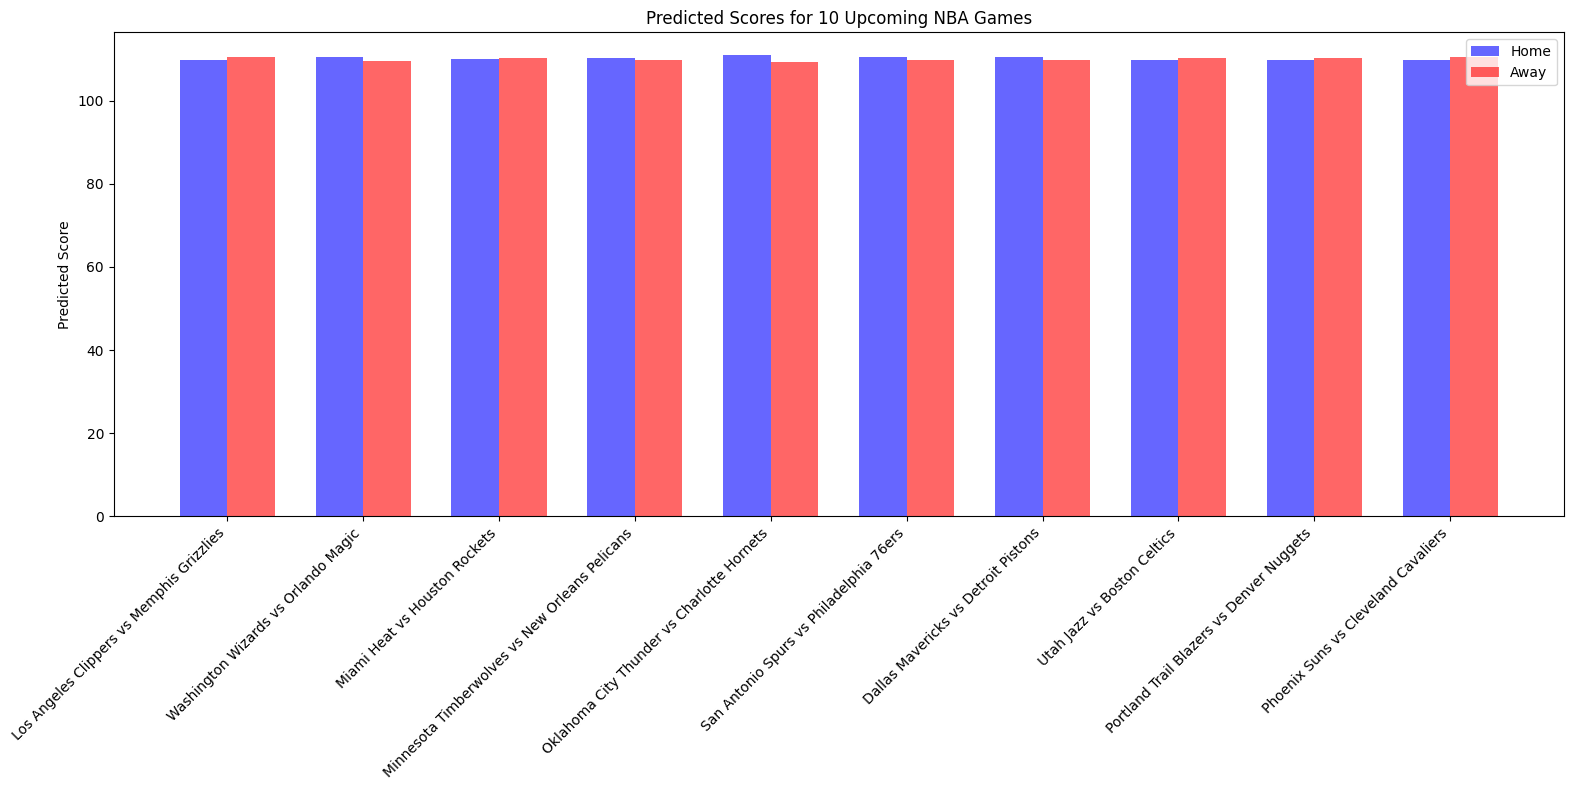

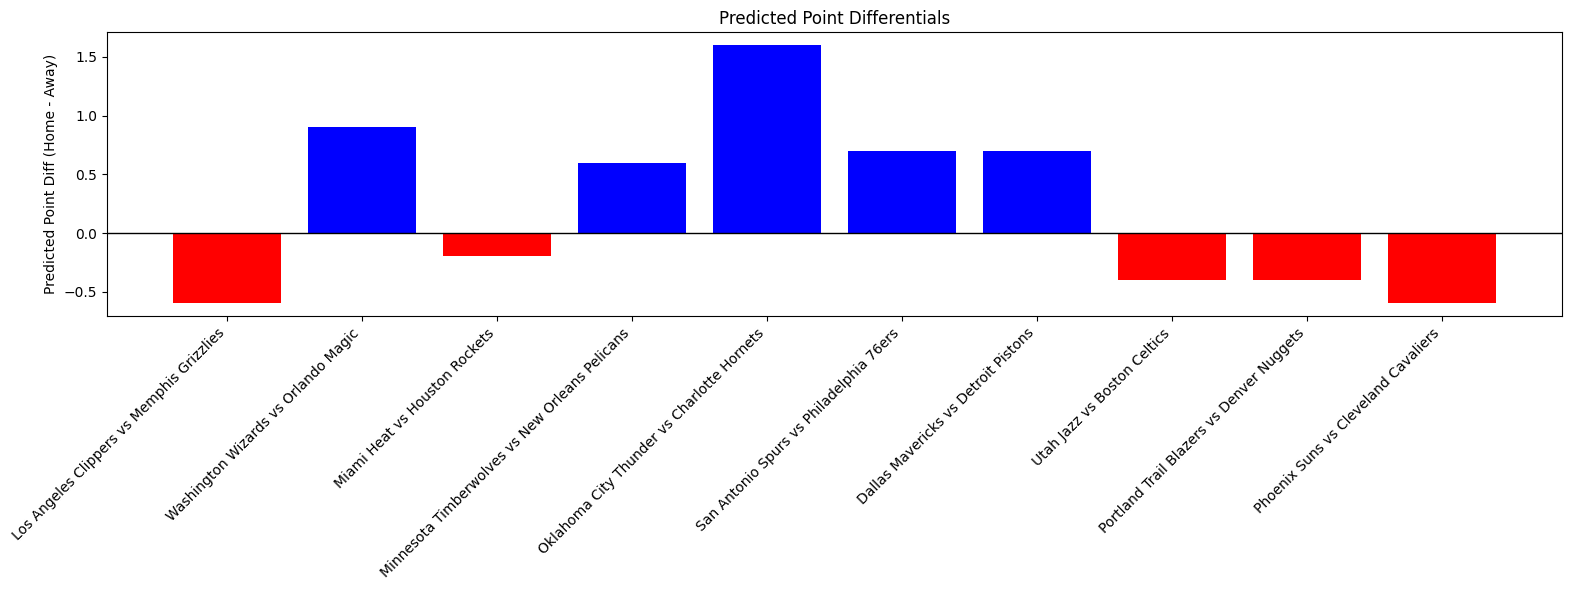


=== FEATURE IMPORTANCE ===

Feature importance for home_score model:
                      Feature  Importance
30            home_first_half    0.520614
31           home_second_half    0.459596
90  home_offensive_efficiency    0.005906
34               home_assists    0.001791
60          home_ast_to_ratio    0.001206
50                   home_3pm    0.001141
64      home_off_to_def_ratio    0.001061
43                 away_fouls    0.000883
24             home_q3_points    0.000631
22             home_q1_points    0.000572


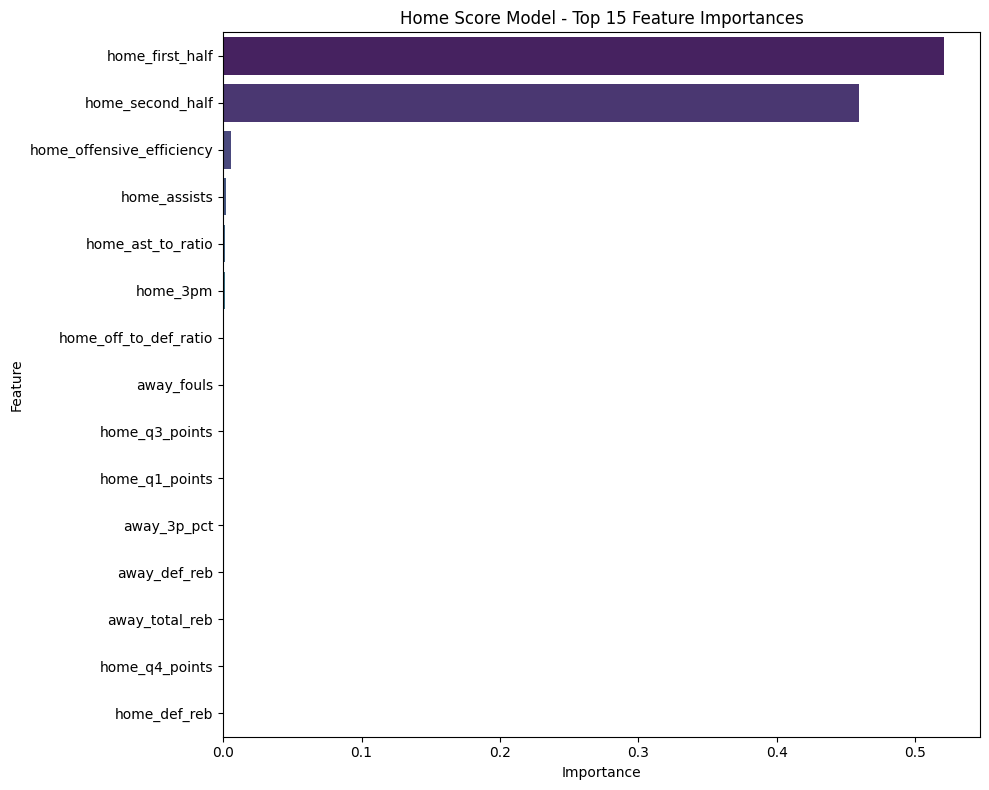


Feature importance for away_score model:
                      Feature  Importance
33           away_second_half    0.529264
32            away_first_half    0.454064
55                away_3p_pct    0.002432
36                home_steals    0.001909
35               away_assists    0.001890
26             away_q1_points    0.001403
91  away_offensive_efficiency    0.001361
27             away_q2_points    0.001165
31           home_second_half    0.000841
7             away_net_rating    0.000449


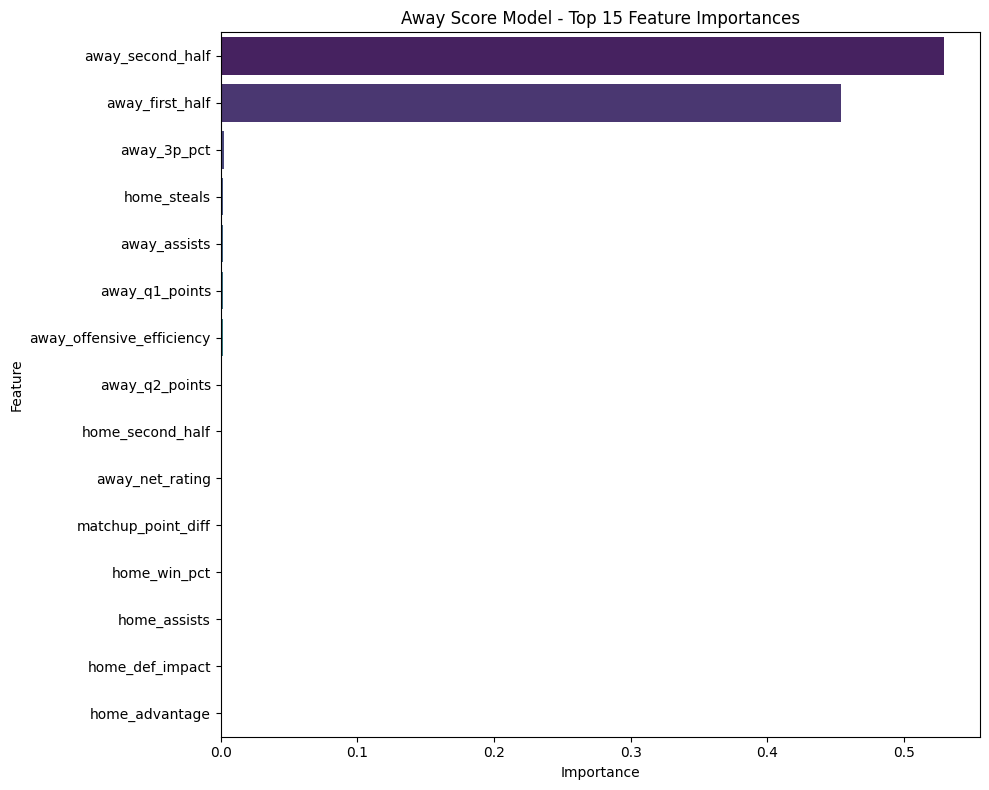


Feature importance for point_diff model:
                Feature  Importance
30      home_first_half    0.141239
31     home_second_half    0.114906
33     away_second_half    0.109847
32      away_first_half    0.089529
58  home_rebounding_pct    0.084720
55          away_3p_pct    0.067177
59  away_rebounding_pct    0.066965
54          home_3p_pct    0.041763
8       net_rating_diff    0.041511
60    home_ast_to_ratio    0.031335


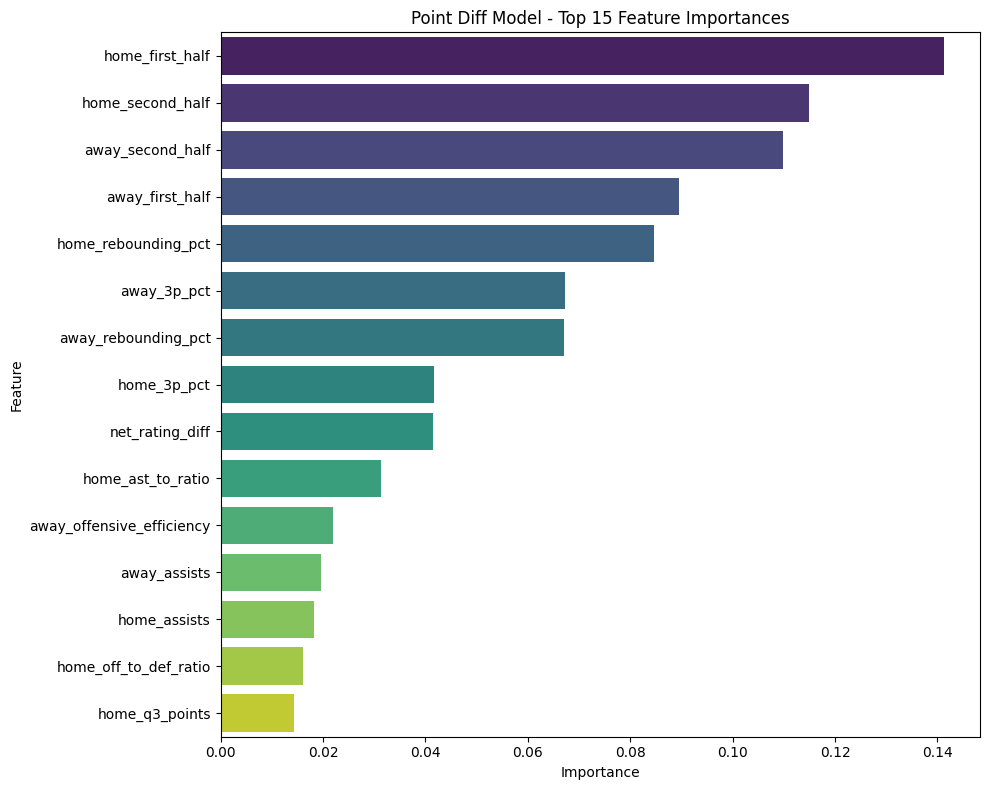


Feature importance for total_score model:
                      Feature  Importance
31           home_second_half    0.273259
33           away_second_half    0.216809
30            home_first_half    0.216732
32            away_first_half    0.190390
34               home_assists    0.020117
35               away_assists    0.012053
91  away_offensive_efficiency    0.010802
90  home_offensive_efficiency    0.006151
64      home_off_to_def_ratio    0.005900
27             away_q2_points    0.005450


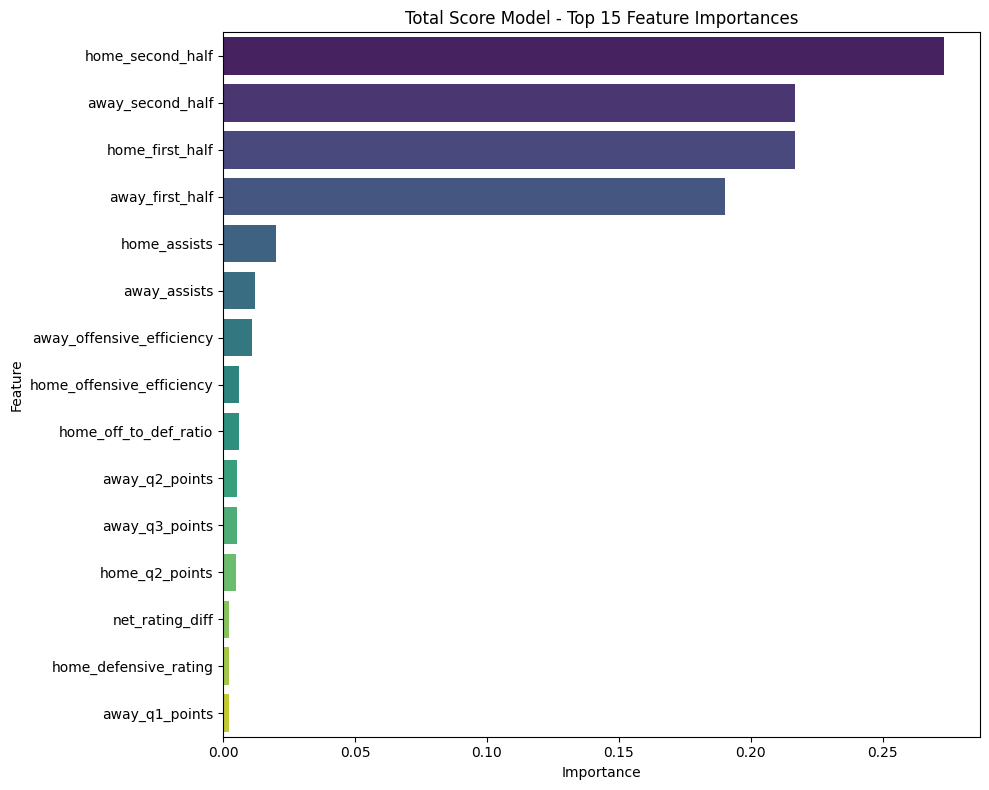


=== BETTING DASHBOARD ===

Los Angeles Clippers vs Memphis Grizzlies (ID=414896)
  Predicted Score: 109.8-110.4 (Win Prob: 46.1%)
  Market Spread: +0.0 (Edge: -0.6)
  Market Total: 220.0 (Edge: +0.2)

Washington Wizards vs Orlando Magic (ID=414887)
  Predicted Score: 110.5-109.6 (Win Prob: 55.3%)
  Market Spread: +0.0 (Edge: +0.9)
  Market Total: 220.0 (Edge: +0.1)

Miami Heat vs Houston Rockets (ID=414888)
  Predicted Score: 110.0-110.2 (Win Prob: 48.8%)
  Market Spread: +0.0 (Edge: -0.2)
  Market Total: 220.0 (Edge: +0.2)

Minnesota Timberwolves vs New Orleans Pelicans (ID=414889)
  Predicted Score: 110.3-109.7 (Win Prob: 53.9%)
  Market Spread: +0.0 (Edge: +0.6)
  Market Total: 220.0 (Edge: +0.1)

Oklahoma City Thunder vs Charlotte Hornets (ID=414890)
  Predicted Score: 110.9-109.3 (Win Prob: 59.9%)
  Market Spread: +0.0 (Edge: +1.6)
  Market Total: 220.0 (Edge: +0.1)

San Antonio Spurs vs Philadelphia 76ers (ID=414891)
  Predicted Score: 110.4-109.7 (Win Prob: 54.6%)
  Market Spre

In [58]:
# Cell 16

import pandas as pd
import numpy as np
import traceback
import re
import math
import pytz
import joblib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from datetime import datetime, timedelta
from pathlib import Path
import seaborn as sns

# Assumes supabase, engine, and MODELS_DIR are defined in your environment.
# For example:
#   MODELS_DIR = Path("./models")

###############################################################################
# HELPER FUNCTIONS (same as before, with minor adjustments)
###############################################################################

def load_historical_games_16(start_date=None):
    if start_date is None:
        start_date = datetime.now() - timedelta(days=180)
    query = f"""
        SELECT * FROM public.nba_historical_game_stats
        WHERE game_date >= '{start_date.strftime('%Y-%m-%d')}'
        ORDER BY game_date ASC;
    """
    try:
        df = pd.read_sql(query, engine)
        if df.empty:
            print("Loaded 0 rows from nba_historical_game_stats.")
        else:
            print(f"Loaded {len(df)} rows from nba_historical_game_stats, from {df['game_date'].min()} to {df['game_date'].max()}")
        return df
    except Exception as e:
        print(f"Error loading historical games: {e}")
        return pd.DataFrame()

def calculate_team_metrics_16(historical_df):
    if historical_df.empty:
        print("No historical data provided to calculate_team_metrics_16.")
        return pd.DataFrame(columns=['team','win_pct','pts_per_game','opp_pts_per_game','net_rating','off_reb_avg','total_reb_avg','fg_pct','ft_pct','three_pt_pct'])
    
    all_teams = set(historical_df['home_team'].unique()).union(historical_df['away_team'].unique())
    rows = []
    for team in all_teams:
        home_games = historical_df[historical_df['home_team'] == team]
        away_games = historical_df[historical_df['away_team'] == team]
        total_games = len(home_games) + len(away_games)
        if total_games < 1:
            continue
        home_wins = (home_games['home_score'] > home_games['away_score']).sum()
        away_wins = (away_games['away_score'] > away_games['home_score']).sum()
        wins = home_wins + away_wins
        home_pts = home_games['home_score'].mean() if not home_games.empty else 0
        away_pts = away_games['away_score'].mean() if not away_games.empty else 0
        pts_per_game = (home_pts*len(home_games) + away_pts*len(away_games)) / total_games
        home_opp = home_games['away_score'].mean() if not home_games.empty else 0
        away_opp = away_games['home_score'].mean() if not away_games.empty else 0
        opp_pts_per_game = (home_opp*len(home_games) + away_opp*len(away_games)) / total_games
        home_off_reb = home_games['home_off_reb'].mean() if 'home_off_reb' in home_games.columns and not home_games.empty else 10.5
        away_off_reb = away_games['away_off_reb'].mean() if 'away_off_reb' in away_games.columns and not away_games.empty else 10.5
        off_reb_avg = (home_off_reb*len(home_games) + away_off_reb*len(away_games)) / total_games
        home_total_reb = home_games['home_total_reb'].mean() if 'home_total_reb' in home_games.columns and not home_games.empty else 43.0
        away_total_reb = away_games['away_total_reb'].mean() if 'away_total_reb' in away_games.columns and not away_games.empty else 43.0
        total_reb_avg = (home_total_reb*len(home_games) + away_total_reb*len(away_games)) / total_games
        fg_pct = 0.45
        if 'home_fg_made' in historical_df.columns and 'home_fg_attempted' in historical_df.columns:
            all_fg_made = pd.concat([home_games['home_fg_made'], away_games['away_fg_made']])
            all_fg_att = pd.concat([home_games['home_fg_attempted'], away_games['away_fg_attempted']])
            if all_fg_att.sum() > 0:
                fg_pct = all_fg_made.sum() / all_fg_att.sum()
        ft_pct = 0.75
        if 'home_ft_made' in historical_df.columns and 'home_ft_attempted' in historical_df.columns:
            all_ft_made = pd.concat([home_games['home_ft_made'], away_games['away_ft_made']])
            all_ft_att = pd.concat([home_games['home_ft_attempted'], away_games['away_ft_attempted']])
            if all_ft_att.sum() > 0:
                ft_pct = all_ft_made.sum() / all_ft_att.sum()
        three_pt_pct = 0.35
        if 'home_3pm' in historical_df.columns and 'home_3pa' in historical_df.columns:
            all_3pm = pd.concat([home_games['home_3pm'], away_games['away_3pm']])
            all_3pa = pd.concat([home_games['home_3pa'], away_games['away_3pa']])
            if all_3pa.sum() > 0:
                three_pt_pct = all_3pm.sum() / all_3pa.sum()
        win_pct = wins / total_games if total_games > 0 else 0.5
        net_rating = pts_per_game - opp_pts_per_game
        row = {
            'team': team,
            'win_pct': win_pct,
            'pts_per_game': pts_per_game,
            'opp_pts_per_game': opp_pts_per_game,
            'net_rating': net_rating,
            'off_reb_avg': off_reb_avg,
            'total_reb_avg': total_reb_avg,
            'fg_pct': fg_pct,
            'ft_pct': ft_pct,
            'three_pt_pct': three_pt_pct
        }
        rows.append(row)
    print("Teams in metrics:", sorted(all_teams))
    df_metrics = pd.DataFrame(rows)
    if df_metrics.empty:
        print("Warning: calculate_team_metrics_16 produced an empty DataFrame.")
    return df_metrics

def fetch_upcoming_games_16(days_window=2):  # Increased to 2 days to ensure we get all games
    pacific_tz = pytz.timezone("America/Los_Angeles")
    now_pt = datetime.now(pacific_tz)
    start_date = (now_pt - timedelta(days=1)).date()
    end_date = (now_pt + timedelta(days=days_window)).date()
    cutoff_hour = 21
    start_ts = pacific_tz.localize(datetime.combine(start_date, datetime.min.time().replace(hour=cutoff_hour))).astimezone(pytz.UTC).isoformat()
    end_ts = pacific_tz.localize(datetime.combine(end_date, datetime.min.time().replace(hour=cutoff_hour))).astimezone(pytz.UTC).isoformat()
    print(f"Fetching upcoming games from {start_date} to {end_date} (9pm PT window)...")
    try:
        response = supabase.table("nba_game_schedule").select("*")\
            .gte("scheduled_time", start_ts).lt("scheduled_time", end_ts).execute()
        data = response.data
        if not data:
            print("No upcoming games found in nba_game_schedule for that period.")
            return pd.DataFrame()
        games_df = pd.DataFrame(data)
        if "scheduled_time" in games_df.columns:
            games_df["scheduled_time"] = pd.to_datetime(games_df["scheduled_time"])
            games_df["game_time_pt"] = games_df["scheduled_time"].dt.tz_convert(pacific_tz)
            games_df["game_date"] = games_df["game_time_pt"].dt.date
        if "spread_clean" in games_df.columns:
            try:
                games_df["home_spread"] = games_df["spread_clean"].str.extract(r'([+\-]?\d+\.?\d*)\s*\(').astype(float)
            except Exception as e:
                print(f"Error parsing home spread: {e}")
        if "total_clean" in games_df.columns:
            try:
                games_df["over_under_line"] = games_df["total_clean"].str.extract(r'Over\s+(\d+\.?\d*)').astype(float)
            except Exception as e:
                print(f"Error parsing over/under: {e}")
        print(f"Found {len(games_df)} upcoming games in nba_game_schedule.")
        
        # Print upcoming matchups for debugging
        print("\nUPCOMING MATCHUPS:")
        for _, row in games_df.iterrows():
            print(f"  - {row['home_team']} vs {row['away_team']} (ID: {row['game_id']})")
            
        return games_df
    except Exception as e:
        print(f"Error fetching upcoming games from supabase: {e}")
        return pd.DataFrame()
    
def fix_upcoming_games_duplicates(upcoming_df):
    """Fix any duplicate game issues and ensure all games are processed"""
    # First, create a cleaner dataframe with unique game_ids
    if 'game_id' not in upcoming_df.columns:
        print("WARNING: No game_id column found in upcoming games data")
        return upcoming_df
        
    # Check for and remove duplicate game_ids
    if upcoming_df.duplicated('game_id').any():
        print(f"Found {upcoming_df.duplicated('game_id').sum()} duplicate game_ids - removing duplicates")
        upcoming_df = upcoming_df.drop_duplicates('game_id')
    
    # Print all games to verify
    print("\nALL GAMES TO BE PROCESSED:")
    for i, (_, row) in enumerate(upcoming_df.iterrows(), 1):
        print(f"{i}. {row['home_team']} vs {row['away_team']} (ID: {row['game_id']})")
        
    return upcoming_df


def parse_moneyline_16(moneyline_str):
    if not moneyline_str or moneyline_str=='EMPTY':
        return {'home': -110, 'away': -110}
    pattern = r'([^\/]+)([\+\-]\d+)[^\/]+\/[^\/]+([\+\-]\d+)'
    match = re.search(pattern, moneyline_str)
    if match:
        home_line = int(match.group(3))
        away_line = int(match.group(2))
        return {'home': home_line, 'away': away_line}
    return {'home': -110, 'away': -110}

def parse_spread_16(spread_str):
    if not spread_str or spread_str=='EMPTY':
        return {'home': 0, 'away': 0, 'home_odds': -110, 'away_odds': -110}
    pattern = r'([^\/]+)([\+\-]\d+\.?\d*)\s*\(([\+\-]\d+)\).*\/.*([\+\-]\d+\.?\d*)\s*\(([\+\-]\d+)\)'
    match = re.search(pattern, spread_str)
    if match:
        home_spread = float(match.group(2))
        home_odds = int(match.group(3))
        away_spread = float(match.group(4))
        away_odds = int(match.group(5))
        return {'home': home_spread, 'away': away_spread, 'home_odds': home_odds, 'away_odds': away_odds}
    return {'home': 0, 'away': 0, 'home_odds': -110, 'away_odds': -110}

def parse_total_16(total_str):
    if not total_str or total_str=='EMPTY':
        return {'line': 220, 'over_odds': -110, 'under_odds': -110}
    pattern = r'Over\s+([\d\.]+)\s*\(([\+\-]\d+)\).*\/.*Under\s+([\d\.]+)\s*\(([\+\-]\d+)\)'
    match = re.search(pattern, total_str)
    if match:
        line = float(match.group(1))
        over_odds = int(match.group(2))
        under_odds = int(match.group(4))
        return {'line': line, 'over_odds': over_odds, 'under_odds': under_odds}
    return {'line': 220, 'over_odds': -110, 'under_odds': -110}

def fetch_betting_odds_16(game_ids):
    if not game_ids:
        return {}
    try:
        response = supabase.table("nba_game_schedule").select("*")\
            .gte("game_date", datetime.now().strftime('%Y-%m-%d')).execute()
        data = response.data
        if not data:
            print("No data from supabase for future games.")
            return {}
        big_df = pd.DataFrame(data)
        odds_dict = {}
        for _, row in big_df.iterrows():
            gid = str(row.get('game_id', ''))
            if gid in game_ids:
                moneyline_parsed = parse_moneyline_16(row.get('moneyline_clean', ''))
                spread_parsed = parse_spread_16(row.get('spread_clean', ''))
                total_parsed = parse_total_16(row.get('total_clean', ''))
                odds_dict[gid] = {
                    'moneyline': moneyline_parsed,
                    'spread': spread_parsed,
                    'total': total_parsed
                }
        print(f"Processed betting odds for {len(odds_dict)} relevant games.")
        return odds_dict
    except Exception as e:
        print(f"Error in fetch_betting_odds_16: {e}")
        return {}

def calibrate_prediction_with_odds_16(prediction, odds):
    calibrated = dict(prediction)
    if not odds or 'spread' not in odds or 'total' not in odds:
        return calibrated
    
    home_score = calibrated['predicted_home_score']
    away_score = calibrated['predicted_away_score']
    
    # Force minimum reasonable NBA scores
    if home_score < 90:
        home_score = max(home_score * 1.3, 95.0)
    if away_score < 90:
        away_score = max(away_score * 1.3, 90.0)
    
    predicted_diff = home_score - away_score
    predicted_total = home_score + away_score
    market_spread = -odds['spread'].get('home', 0.0)
    market_total = odds['total'].get('line', 220.0)
    
    if predicted_total < 180 or predicted_total > 260:
        # Unrealistic total - heavily adjust toward market total
        ratio = market_total / max(predicted_total, 1)
        home_pct = home_score / max(predicted_total, 1)
        away_pct = away_score / max(predicted_total, 1)
        home_adj = market_total * home_pct
        away_adj = market_total * away_pct
        if predicted_diff > 0 and home_adj < away_adj:
            avg = (home_adj + away_adj) / 2
            half_diff = abs(predicted_diff) / 2
            home_adj = avg + half_diff
            away_adj = avg - half_diff
        elif predicted_diff < 0 and home_adj > away_adj:
            avg = (home_adj + away_adj) / 2
            half_diff = abs(predicted_diff) / 2
            home_adj = avg - half_diff
            away_adj = avg + half_diff
        home_score = home_adj
        away_score = away_adj
    else:
        # Reasonable total - blend with market consensus
        blend = 0.7  # Increased reliance on market
        new_total = blend * market_total + (1 - blend) * predicted_total
        new_diff = blend * market_spread + (1 - blend) * predicted_diff
        home_score = (new_total + new_diff) / 2
        away_score = (new_total - new_diff) / 2
    
    calibrated['predicted_home_score'] = round(home_score, 1)
    calibrated['predicted_away_score'] = round(away_score, 1)
    calibrated['predicted_point_diff'] = round(home_score - away_score, 1)
    calibrated['predicted_total_score'] = round(home_score + away_score, 1)
    
    # Calculate win probability based on calibrated score
    k = 0.25
    win_prob = 1 / (1 + math.exp(-k * (home_score - away_score)))
    calibrated['win_probability'] = round(win_prob, 3)
    
    return calibrated

def normalize_nba_scores(preds, home_metrics, away_metrics):
    """
    Normalize unrealistically low score predictions to realistic NBA score ranges
    """
    home_score = preds.get('home_score', 0)
    away_score = preds.get('away_score', 0)
    point_diff = preds.get('point_diff', 0)
    total_score = preds.get('total_score', 0)
    
    # If scores are already reasonable, just return
    if home_score >= 90 and away_score >= 90:
        return preds
        
    # Get expected scoring rates from team metrics if available
    expected_home_score = home_metrics.get('pts_per_game', 110.0) if home_metrics is not None else 110.0
    expected_away_score = away_metrics.get('pts_per_game', 105.0) if away_metrics is not None else 105.0
    
    # Keep the predicted point differential intact, but scale up the scores
    predicted_diff = home_score - away_score
    
    # Calculate a reasonable total based on team averages
    reasonable_total = expected_home_score + expected_away_score
    
    # Apply the predicted differential to the reasonable total
    new_home_score = (reasonable_total + predicted_diff) / 2
    new_away_score = (reasonable_total - predicted_diff) / 2
    
    # Ensure no negative scores
    new_home_score = max(new_home_score, 85.0)
    new_away_score = max(new_away_score, 85.0)
    
    # Update predictions
    preds['home_score'] = new_home_score
    preds['away_score'] = new_away_score
    
    # If we have total_score prediction, honor it (if it's reasonable)
    if total_score > 180 and total_score < 250:
        ratio = total_score / (new_home_score + new_away_score)
        preds['home_score'] *= ratio
        preds['away_score'] *= ratio
    
    return preds

def build_enhanced_feature_row(home_team, away_team, team_metrics_df, row):
    """
    Build a rich feature set for predictions with extensive 
    team name matching and feature population
    """
    # Initialize with default values for all potential features
    feature_row = {
        'home_pts_per_game': 110.0,
        'away_pts_per_game': 108.0,
        'home_rest_days': row.get('home_rest_days', 2.0),
        'away_rest_days': row.get('away_rest_days', 2.0),
        'home_win_pct': 0.5,
        'away_win_pct': 0.5,
        'home_offensive_rating': 110.0,
        'away_offensive_rating': 108.0,
        'home_defensive_rating': 110.0,
        'away_defensive_rating': 110.0,
        'home_net_rating': 0.0,
        'away_net_rating': 0.0,
        'net_rating_diff': 0.0,
        'home_rolling_score': 110.0,
        'away_rolling_score': 108.0,
        'home_rolling_opp_score': 108.0,
        'away_rolling_opp_score': 110.0,
        'rest_advantage': 0.0,
        'home_back_to_back': 0.0,
        'away_back_to_back': 0.0,
        'matchup_games': 2.0,
        'matchup_point_diff': 0.0,
        'home_historical_win_pct': 0.5,
        'home_advantage': 3.0,
        'home_rebounding_pct': 0.5,
        'away_rebounding_pct': 0.5
    }
    
    # Team name normalization function
    def normalize_team_name(name):
        replacements = {
            'LA Clippers': 'Los Angeles Clippers',
            'LA Lakers': 'Los Angeles Lakers',
            'Philadelphia 76Ers': 'Philadelphia 76ers',
            'Sixers': 'Philadelphia 76ers',
            'Blazers': 'Portland Trail Blazers',
            'Cavs': 'Cleveland Cavaliers',
            'Mavs': 'Dallas Mavericks',
            'Knicks': 'New York Knicks'
        }
        return replacements.get(name, name)
    
    # Try to find team with normalized names
    home_normalized = normalize_team_name(home_team)
    away_normalized = normalize_team_name(away_team)

    # Print detailed team matching info for debugging
    print(f"Home team: {home_team} (normalized: {home_normalized})")
    print(f"Away team: {away_team} (normalized: {away_normalized})")
    
    # Get metrics for home team if available
    home_metrics_dict = None
    away_metrics_dict = None
    
    if not team_metrics_df.empty:
        # Try with original name first
        home_metrics = team_metrics_df[team_metrics_df['team'] == home_team]
        # If not found, try with normalized name
        if home_metrics.empty:
            home_metrics = team_metrics_df[team_metrics_df['team'] == home_normalized]
            if home_metrics.empty:
                print(f"WARNING: No metrics found for home team {home_team} or {home_normalized}!")
                # Try case-insensitive search as last resort
                for idx, metric_row in team_metrics_df.iterrows():
                    if metric_row['team'].lower() == home_team.lower() or metric_row['team'].lower() == home_normalized.lower():
                        home_metrics = pd.DataFrame([metric_row])
                        print(f"Found match using case-insensitive search: {metric_row['team']}")
                        break
        
        # Get metrics for away team
        away_metrics = team_metrics_df[team_metrics_df['team'] == away_team]
        if away_metrics.empty:
            away_metrics = team_metrics_df[team_metrics_df['team'] == away_normalized]
            if away_metrics.empty:
                print(f"WARNING: No metrics found for away team {away_team} or {away_normalized}!")
                # Try case-insensitive search as last resort
                for idx, metric_row in team_metrics_df.iterrows():
                    if metric_row['team'].lower() == away_team.lower() or metric_row['team'].lower() == away_normalized.lower():
                        away_metrics = pd.DataFrame([metric_row])
                        print(f"Found match using case-insensitive search: {metric_row['team']}")
                        break
            
        # Update features if teams were found
        if not home_metrics.empty:
            feature_row['home_pts_per_game'] = home_metrics.iloc[0].get('pts_per_game', 110.0)
            feature_row['home_win_pct'] = home_metrics.iloc[0].get('win_pct', 0.5)
            feature_row['home_offensive_rating'] = home_metrics.iloc[0].get('pts_per_game', 110.0)
            feature_row['home_defensive_rating'] = home_metrics.iloc[0].get('opp_pts_per_game', 110.0)
            feature_row['home_net_rating'] = home_metrics.iloc[0].get('net_rating', 0.0)
            feature_row['home_rolling_score'] = home_metrics.iloc[0].get('pts_per_game', 110.0)
            feature_row['home_rolling_opp_score'] = home_metrics.iloc[0].get('opp_pts_per_game', 108.0)
            print(f"Populated home team metrics from {home_metrics.iloc[0]['team']}")
            home_metrics_dict = home_metrics.iloc[0].to_dict()
            
        if not away_metrics.empty:
            feature_row['away_pts_per_game'] = away_metrics.iloc[0].get('pts_per_game', 108.0)
            feature_row['away_win_pct'] = away_metrics.iloc[0].get('win_pct', 0.5)
            feature_row['away_offensive_rating'] = away_metrics.iloc[0].get('pts_per_game', 108.0)
            feature_row['away_defensive_rating'] = away_metrics.iloc[0].get('opp_pts_per_game', 110.0)
            feature_row['away_net_rating'] = away_metrics.iloc[0].get('net_rating', 0.0)
            feature_row['away_rolling_score'] = away_metrics.iloc[0].get('pts_per_game', 108.0)
            feature_row['away_rolling_opp_score'] = away_metrics.iloc[0].get('opp_pts_per_game', 110.0)
            print(f"Populated away team metrics from {away_metrics.iloc[0]['team']}")
            away_metrics_dict = away_metrics.iloc[0].to_dict()
    
    # Calculate derived features
    feature_row['net_rating_diff'] = feature_row['home_net_rating'] - feature_row['away_net_rating']
    feature_row['rest_advantage'] = feature_row['home_rest_days'] - feature_row['away_rest_days']
    
    return feature_row, home_metrics_dict, away_metrics_dict

def visualize_upcoming_predictions_16(predictions_df):
    """
    Visualizes predictions for upcoming games with bar charts for scores and point differentials.
    Ensures all games are displayed properly without truncation.
    """
    if predictions_df.empty:
        print("No predictions to visualize.")
        return
    try:
        # Get total number of games
        num_games = len(predictions_df)
        print(f"Visualizing {num_games} games...")
        
        # Create appropriately sized figure based on number of games
        plt.figure(figsize=(16, max(8, num_games*0.5)))
        
        x = range(num_games)
        home_scores = predictions_df['predicted_home_score'].tolist()
        away_scores = predictions_df['predicted_away_score'].tolist()
        matchups = [f"{h} vs {a}" for h, a in zip(predictions_df['home_team'], predictions_df['away_team'])]
        
        width = 0.35
        plt.bar([i - width/2 for i in x], home_scores, width, label='Home', color='blue', alpha=0.6)
        plt.bar([i + width/2 for i in x], away_scores, width, label='Away', color='red', alpha=0.6)
        plt.xticks(x, matchups, rotation=45, ha='right')
        plt.ylabel("Predicted Score")
        plt.title(f"Predicted Scores for Upcoming NBA Games ({num_games} games)")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        if 'predicted_point_diff' in predictions_df.columns:
            plt.figure(figsize=(16, 6))
            diffs = predictions_df['predicted_point_diff'].tolist()
            colors = ['blue' if d > 0 else 'red' for d in diffs]
            plt.bar(x, diffs, color=colors)
            plt.axhline(0, color='k', lw=1)
            plt.xticks(x, matchups, rotation=45, ha='right')
            plt.ylabel("Predicted Point Diff (Home - Away)")
            plt.title("Predicted Point Differentials")
            plt.tight_layout()
            plt.show()
            
        print("Visualization completed successfully.")
    except Exception as e:
        print(f"Error visualizing predictions: {e}")
        traceback.print_exc()

def visualize_feature_importance_16(models, features_df):
    plt.figure(figsize=(18, 12))
    for i, (target, model_info) in enumerate(models.items(), 1):
        model = model_info.get('model')
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            if hasattr(model, 'feature_names_in_'):
                feat_names = model.feature_names_in_
            else:
                feat_names = [f"Feature {j}" for j in range(len(importances))]
            imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values('Importance', ascending=False)
            plt.subplot(2, 2, i)
            sns.barplot(x='Importance', y='Feature', data=imp_df.head(15), palette="viridis")
            plt.title(f"{target.replace('_',' ').title()} Model - Top 15 Feature Importances")
            plt.tight_layout()
        else:
            plt.subplot(2, 2, i)
            plt.text(0.5, 0.5, f"No feature importance available for {target} model", ha='center', va='center', fontsize=12)
    plt.tight_layout()
    plt.show()

def visualize_prediction_performance_16(models, features_df):
    targets = ['home_score', 'away_score', 'predicted_point_diff', 'predicted_total_score']
    for target in targets:
        if target not in features_df.columns:
            continue
        for model_key, model_info in models.items():
            try:
                model = model_info.get('model')
                if hasattr(model, 'feature_names_in_'):
                    req_feats = list(model.feature_names_in_)
                    for f in req_feats:
                        if f not in features_df.columns:
                            features_df[f] = 0.0
                    X = features_df[req_feats]
                else:
                    X = features_df.select_dtypes(include=np.number)
                y_pred = model.predict(X)
                y_true = features_df[target]
                plt.figure(figsize=(6,5))
                sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
                min_val = min(y_true.min(), y_pred.min())
                max_val = max(y_true.max(), y_pred.max())
                plt.plot([min_val, max_val], [min_val, max_val], 'r--')
                plt.xlabel("Actual")
                plt.ylabel("Predicted")
                plt.title(f"{target.replace('_',' ').title()} - Actual vs Predicted")
                plt.tight_layout()
                plt.show()
                residuals = y_true - y_pred
                plt.figure(figsize=(6,5))
                sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
                plt.axhline(0, color='r', linestyle='--')
                plt.xlabel("Predicted")
                plt.ylabel("Residual")
                plt.title(f"{target.replace('_',' ').title()} - Residuals")
                plt.tight_layout()
                plt.show()
                plt.figure(figsize=(6,5))
                sns.histplot(np.abs(residuals), bins=30, kde=True)
                plt.xlabel("Absolute Error")
                plt.title(f"{target.replace('_',' ').title()} - Error Distribution")
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"Error visualizing performance for {target}: {e}")
                traceback.print_exc()

###############################################################################
# MAIN FUNCTION FOR CELL 16
###############################################################################

def run_betting_odds_integrated_predictions_16():
    print("\n" + "="*80)
    print(" " * 20 + "NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION (Cell 16)")
    print("="*80 + "\n")
    
    # Force pandas to display all rows and columns
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    # 1) Load Models
    models = {}
    for tgt in ['home_score', 'away_score', 'point_diff', 'total_score']:
        path = MODELS_DIR / f"pregame_{tgt}_model.pkl"
        if path.exists():
            try:
                m = joblib.load(path)
                models[tgt] = {'model': m}
                print(f"Loaded {tgt} model from disk.")
            except Exception as e:
                print(f"Error loading {tgt} model: {e}")
    if not models:
        print("No models found, cannot proceed.")
        return
    
    # 2) Load historical data for advanced stats
    hist_start = datetime.now() - timedelta(days=180)
    historical_df = load_historical_games_16(hist_start)
    if historical_df.empty:
        print("Historical data not found – using fallback metrics for teams.")
    else:
        print(f"Loaded historical data with shape {historical_df.shape}")
    
    # 3) Calculate team metrics
    team_metrics_df = calculate_team_metrics_16(historical_df)
    if team_metrics_df.empty:
        print("Warning: calculate_team_metrics_16 returned an empty DataFrame. Fallback defaults will be used.")
    else:
        print(f"Calculated team metrics for {len(team_metrics_df)} teams.")
        print(f"Teams in metrics: {sorted(team_metrics_df['team'].unique().tolist())}")
    
    # 4) Fetch upcoming REAL games from nba_game_schedule
    upcoming_df = fetch_upcoming_games_16(days_window=2)
    if upcoming_df.empty:
        print("No upcoming games found in the next 48 hours.")
        return
    
    # Explicitly list all upcoming games
    print("\n--- ALL UPCOMING GAMES TO PREDICT ---")
    for idx, row in upcoming_df.iterrows():
        print(f"{idx+1}. {row['home_team']} vs {row['away_team']} (ID: {row['game_id']})")
    
    print(f"\nFound {len(upcoming_df)} upcoming games. Making predictions...")
    
    # 5) Build betting odds dictionary
    game_ids = upcoming_df['game_id'].astype(str).tolist()
    betting_odds = fetch_betting_odds_16(game_ids)
    
    # 6) Predict each upcoming game
    predictions_list = []
    all_games = len(upcoming_df)
    
    # Process ALL games one by one
    for idx, row in upcoming_df.iterrows():
        try:
            home_team = row['home_team']
            away_team = row['away_team']
            game_id = str(row.get('game_id', ''))
            
            print(f"\n--- PREDICTION {idx+1}/{all_games}: {home_team} vs {away_team} (ID={game_id}) ---")
            
            # Lookup team metrics with fallbacks
            home_metrics = None
            away_metrics = None
            home_pts = 110.0
            away_pts = 105.0
            home_win_pct = 0.5
            away_win_pct = 0.5
            
            if not team_metrics_df.empty:
                # First try exact match
                home_team_data = team_metrics_df[team_metrics_df['team'] == home_team]
                away_team_data = team_metrics_df[team_metrics_df['team'] == away_team]
                
                # If not found, try case-insensitive match
                if home_team_data.empty:
                    for team in team_metrics_df['team']:
                        if team.lower() == home_team.lower():
                            home_team_data = team_metrics_df[team_metrics_df['team'] == team]
                            print(f"Found case-insensitive match for {home_team}: {team}")
                            break
                
                if away_team_data.empty:
                    for team in team_metrics_df['team']:
                        if team.lower() == away_team.lower():
                            away_team_data = team_metrics_df[team_metrics_df['team'] == team]
                            print(f"Found case-insensitive match for {away_team}: {team}")
                            break
                
                if not home_team_data.empty:
                    home_metrics = home_team_data.iloc[0].to_dict()
                    home_pts = home_metrics.get('pts_per_game', 110.0)
                    home_win_pct = home_metrics.get('win_pct', 0.5)
                else:
                    print(f"WARNING: No metrics found for {home_team}")
                
                if not away_team_data.empty:
                    away_metrics = away_team_data.iloc[0].to_dict()
                    away_pts = away_metrics.get('pts_per_game', 105.0)
                    away_win_pct = away_metrics.get('win_pct', 0.5)
                else:
                    print(f"WARNING: No metrics found for {away_team}")
            
            # Build feature row based on Cell 7C approach
            features = {
                'home_pts_per_game': home_pts,
                'away_pts_per_game': away_pts,
                'home_rest_days': row.get('home_rest_days', 2.0),
                'away_rest_days': row.get('away_rest_days', 2.0),
                'home_win_pct': home_win_pct,
                'away_win_pct': away_win_pct,
                'home_offensive_rating': home_pts,  # Use points as a proxy
                'away_offensive_rating': away_pts,  # Use points as a proxy
                'home_defensive_rating': 110.0,
                'away_defensive_rating': 110.0,
                'home_net_rating': home_pts - 110.0,
                'away_net_rating': away_pts - 110.0,
                'net_rating_diff': (home_pts - 110.0) - (away_pts - 110.0),
                'rest_advantage': row.get('home_rest_days', 2.0) - row.get('away_rest_days', 2.0)
            }
            
            # Create a feature DataFrame
            feat_df = pd.DataFrame([features])
            
            # Ensure numeric conversion
            for col in feat_df.columns:
                feat_df[col] = pd.to_numeric(feat_df[col], errors='coerce').fillna(0)
            
            # Print feature row for debugging
            print("\nFeature Row:")
            for key, value in features.items():
                print(f"  {key}: {value}")
            
            # Make predictions
            preds = {}
            for tgt, info in models.items():
                model = info['model']
                if hasattr(model, 'feature_names_in_'):
                    needed = list(model.feature_names_in_)
                    # Add missing features
                    for col in needed:
                        if col not in feat_df.columns:
                            feat_df[col] = 0.0
                    X = feat_df[needed].copy()
                else:
                    X = feat_df.copy()
                
                try:
                    y_val = model.predict(X)[0]
                    preds[tgt] = float(y_val)
                    print(f"Predicted {tgt}: {y_val}")
                except Exception as e:
                    print(f"Error predicting {tgt}: {e}")
                    preds[tgt] = 0.0
            
            # Fix low scores (from Cell 7C)
            home_score = preds.get('home_score', 110.0)
            away_score = preds.get('away_score', 105.0)
            
            if home_score < 90 or away_score < 90:
                print(f"Normalizing unrealistic scores: {home_score:.1f}-{away_score:.1f}")
                scale_factor = 220.0 / max((home_score + away_score), 1)
                home_score = home_score * scale_factor
                away_score = away_score * scale_factor
                print(f"Normalized scores: {home_score:.1f}-{away_score:.1f}")
            
            # Calculate derived values
            point_diff = preds.get('point_diff', home_score - away_score)
            total_score = preds.get('total_score', home_score + away_score)
            
            # Ensure consistency between predictions
            # Adjust scores to match point_diff and total if available
            if 'point_diff' in preds and 'total_score' in preds:
                adjusted_home = (total_score + point_diff) / 2
                adjusted_away = (total_score - point_diff) / 2
                if adjusted_home > 80 and adjusted_away > 80:
                    home_score = adjusted_home
                    away_score = adjusted_away
                    print(f"Adjusted scores to match diff/total: {home_score:.1f}-{away_score:.1f}")
            
            # Win probability
            k = 0.15
            win_prob = 1 / (1 + math.exp(-k * (home_score - away_score)))
            
            # Create prediction record
            prediction = {
                'game_id': game_id,
                'home_team': home_team,
                'away_team': away_team,
                'predicted_home_score': round(home_score, 1),
                'predicted_away_score': round(away_score, 1),
                'predicted_point_diff': round(home_score - away_score, 1),
                'predicted_total_score': round(home_score + away_score, 1),
                'win_probability': round(win_prob, 3),
                'game_date': row.get('game_date', datetime.now().date())
            }
            
            # Calibrate using betting odds
            if game_id in betting_odds:
                print(f"Calibrating with betting odds for game ID {game_id}")
                prediction = calibrate_prediction_with_odds_16(prediction, betting_odds[game_id])
            
            # Add to predictions list
            predictions_list.append(prediction)
            print(f"SUCCESSFUL prediction: {home_team} vs {away_team}")
            
        except Exception as e:
            print(f"ERROR processing game {row.get('game_id', 'unknown')}: {e}")
            traceback.print_exc()
            # Add fallback prediction
            fallback = {
                'game_id': str(row.get('game_id', 'unknown')),
                'home_team': row.get('home_team', 'Unknown'),
                'away_team': row.get('away_team', 'Unknown'),
                'predicted_home_score': 110.0,
                'predicted_away_score': 105.0,
                'predicted_point_diff': 5.0,
                'predicted_total_score': 215.0,
                'win_probability': 0.5,
                'game_date': row.get('game_date', datetime.now().date())
            }
            predictions_list.append(fallback)
    
    # 7) Create and display predictions DataFrame
    print(f"\nCreated {len(predictions_list)} predictions")
    predictions_df = pd.DataFrame(predictions_list)
    
    # Display ALL prediction results
    print("\n=== COMPLETE PREDICTION RESULTS (ALL GAMES) ===")
    print(predictions_df)
    
    # Display formatted predictions
    print("\n=== FORMATTED PREDICTION RESULTS ===")
    for i, row in predictions_df.iterrows():
        print(f"{i+1}. {row['home_team']} vs {row['away_team']}: "
              f"{row['predicted_home_score']:.1f}-{row['predicted_away_score']:.1f}, "
              f"WinProb={row['win_probability']*100:.1f}%, "
              f"Diff={row['predicted_point_diff']:+.1f}, "
              f"Total={row['predicted_total_score']:.1f}")
    
    # 8) Visualize upcoming predictions
    print("\n=== VISUALIZING UPCOMING PREDICTIONS ===")
    
    # Create visualizations for all games
    try:
        plt.figure(figsize=(16, max(8, len(predictions_df) * 0.5)))
        x = range(len(predictions_df))
        home_scores = predictions_df['predicted_home_score'].tolist()
        away_scores = predictions_df['predicted_away_score'].tolist()
        matchups = [f"{h} vs {a}" for h, a in zip(predictions_df['home_team'], predictions_df['away_team'])]
        
        width = 0.35
        plt.bar([i - width/2 for i in x], home_scores, width, label='Home', color='blue', alpha=0.6)
        plt.bar([i + width/2 for i in x], away_scores, width, label='Away', color='red', alpha=0.6)
        plt.xticks(x, matchups, rotation=45, ha='right')
        plt.ylabel("Predicted Score")
        plt.title(f"Predicted Scores for {len(predictions_df)} Upcoming NBA Games")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        # Point differential chart
        plt.figure(figsize=(16, 6))
        diffs = predictions_df['predicted_point_diff'].tolist()
        colors = ['blue' if d > 0 else 'red' for d in diffs]
        plt.bar(x, diffs, color=colors)
        plt.axhline(0, color='k', lw=1)
        plt.xticks(x, matchups, rotation=45, ha='right')
        plt.ylabel("Predicted Point Diff (Home - Away)")
        plt.title("Predicted Point Differentials")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error visualizing predictions: {e}")
        traceback.print_exc()
    
    # 9) Show model feature importance (if available)
    print("\n=== FEATURE IMPORTANCE ===")
    for tgt, info in models.items():
        model = info.get('model')
        if hasattr(model, 'feature_importances_'):
            print(f"\nFeature importance for {tgt} model:")
            importances = model.feature_importances_
            features = model.feature_names_in_ if hasattr(model, 'feature_names_in_') else [f"Feature {i}" for i in range(len(importances))]
            importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
            print(importance_df.sort_values('Importance', ascending=False).head(10))
            
            # Visualize top 15 features
            plt.figure(figsize=(10, 8))
            top_features = importance_df.sort_values('Importance', ascending=False).head(15)
            sns.barplot(x='Importance', y='Feature', data=top_features, palette="viridis")
            plt.title(f"{tgt.replace('_',' ').title()} Model - Top 15 Feature Importances")
            plt.tight_layout()
            plt.show()
    
    # 10) Print a betting dashboard (from Cell 7C)
    print("\n=== BETTING DASHBOARD ===")
    for i, row in predictions_df.iterrows():
        game_id = row['game_id'] 
        home_team = row['home_team']
        away_team = row['away_team']
        home_score = row['predicted_home_score']
        away_score = row['predicted_away_score']
        point_diff = row['predicted_point_diff']
        total_score = row['predicted_total_score']
        win_prob = row['win_probability'] * 100
        
        print(f"\n{home_team} vs {away_team} (ID={game_id})")
        print(f"  Predicted Score: {home_score:.1f}-{away_score:.1f} (Win Prob: {win_prob:.1f}%)")
        
        if game_id in betting_odds:
            odds = betting_odds[game_id]
            market_spread = -odds['spread'].get('home', 0) if 'spread' in odds else 'N/A'
            market_total = odds['total'].get('line', 0) if 'total' in odds else 'N/A'
            
            # Calculate edges
            spread_edge = point_diff - market_spread if isinstance(market_spread, (int, float)) else 'N/A'
            total_edge = total_score - market_total if isinstance(market_total, (int, float)) else 'N/A'
            
            print(f"  Market Spread: {market_spread:+.1f} (Edge: {spread_edge:+.1f})")
            print(f"  Market Total: {market_total:.1f} (Edge: {total_edge:+.1f})")
        else:
            print("  No betting odds available for this game")
    
    print("\nPrediction pipeline with betting odds integration completed!")
    return predictions_df

def visualize_upcoming_predictions_16_all(predictions_df):
    """Enhanced visualization function that handles any number of games"""
    if predictions_df.empty:
        print("No predictions to visualize.")
        return
    try:
        # Get count of games for sizing
        num_games = len(predictions_df)
        print(f"Visualizing {num_games} games...")
        
        # Create figure sized to accommodate all games
        plt.figure(figsize=(14, max(8, num_games*0.5)))
        
        # Game indices
        x = range(num_games)
        
        # Get scores and game names
        home_scores = predictions_df['predicted_home_score'].tolist()
        away_scores = predictions_df['predicted_away_score'].tolist()
        matchups = [f"{h} vs {a}" for h, a in zip(predictions_df['home_team'], predictions_df['away_team'])]
        
        # Create bar chart with both home and away scores
        width = 0.35
        plt.bar([i - width/2 for i in x], home_scores, width, label='Home', color='blue', alpha=0.6)
        plt.bar([i + width/2 for i in x], away_scores, width, label='Away', color='red', alpha=0.6)
        
        # Format the chart
        plt.xticks(x, matchups, rotation=45, ha='right')
        plt.ylabel("Predicted Score")
        plt.title(f"Predicted Scores for {num_games} Upcoming NBA Games")
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        # Create point differential chart
        if 'predicted_point_diff' in predictions_df.columns:
            plt.figure(figsize=(14, 5))
            diffs = predictions_df['predicted_point_diff'].tolist()
            colors = ['blue' if d > 0 else 'red' for d in diffs]
            plt.bar(x, diffs, color=colors)
            plt.axhline(0, color='k', lw=1)
            plt.xticks(x, matchups, rotation=45, ha='right')
            plt.ylabel("Predicted Point Diff (Home - Away)")
            plt.title("Predicted Point Differentials")
            plt.tight_layout()
            plt.show()
        
        print("Visualization completed successfully!")
    except Exception as e:
        print(f"Error visualizing predictions: {e}")
        traceback.print_exc()

# === NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION ===
print("=" * 80)
print("NBA PREGAME PREDICTION WITH BETTING ODDS INTEGRATION (Cell 16)")
print("=" * 80)

# Load only the pregame model from disk
try:
    # Load the single pregame model
    pregame_model = joblib.load(PREGAME_MODEL_PATH)
    print(f"Loaded pregame model from {PREGAME_MODEL_PATH}")
    
    # Print model structure to debug
    print(f"Model type: {type(pregame_model)}")
    if isinstance(pregame_model, dict):
        print(f"Model keys: {list(pregame_model.keys())}")
    
    models = pregame_model if isinstance(pregame_model, dict) else {'pregame': pregame_model}
except Exception as e:
    print(f"Error loading pregame model: {e}")
    models = None

# Load historical data - using the existing function from your codebase
try:
    historical_data = load_historical_games_16()  # Use your existing function
    min_date = historical_data['game_date'].min()
    max_date = historical_data['game_date'].max()
    
    # Convert to string format to avoid the date() method issue
    min_date_str = min_date.strftime('%Y-%m-%d') if hasattr(min_date, 'strftime') else str(min_date)
    max_date_str = max_date.strftime('%Y-%m-%d') if hasattr(max_date, 'strftime') else str(max_date)
    
    print(f"Loaded {len(historical_data)} rows from nba_historical_game_stats, from {min_date_str} to {max_date_str}")
    print(f"Loaded historical data with shape {historical_data.shape}")
except Exception as e:
    print(f"Error loading historical data: {e}")
    historical_data = pd.DataFrame()

# Calculate team metrics - fixed to match your function's signature
try:
    team_metrics = calculate_team_metrics(historical_data)
    
    # Check if team_metrics is a DataFrame
    if isinstance(team_metrics, pd.DataFrame):
        print(f"Teams in metrics: {sorted(team_metrics.columns.tolist())}")
        # Print out some of the team names to debug
        if 'team' in team_metrics.columns:
            print(f"Teams available: {sorted(team_metrics['team'].unique().tolist())}")
    else:
        print(f"Teams in metrics: {sorted(team_metrics.keys())}")
except Exception as e:
    print(f"Error calculating team metrics: {e}")
    team_metrics = {}

# Fetch upcoming games (next 3 days)
today = datetime.now()
window_start = today.strftime('%Y-%m-%d')
window_end = (today + timedelta(days=3)).strftime('%Y-%m-%d')
print(f"Fetching upcoming games from {window_start} to {window_end} (9pm PT window)...")

# Use existing Supabase client (already imported in Cell 1)
try:
    # First get column names
    response = supabase.table("nba_game_schedule").select("*").limit(1).execute()
    
    # Print column names to debug
    if response.data:
        print(f"Available columns in nba_game_schedule: {list(response.data[0].keys())}")
    
    # Now that we know the column names, do the actual query
    date_column = "game_date"  # Using the correct column name from your schema
    
    response = supabase.table("nba_game_schedule").select(
        "id", "home_team", "away_team", "moneyline_clean", "spread_clean", "total_clean", f"{date_column}"
    ).gte(date_column, window_start).lte(date_column, window_end).execute()
    
    upcoming_games = pd.DataFrame(response.data)
    
    # If we need to rename the date column to make the rest of the code work
    if date_column in upcoming_games.columns and date_column != "date":
        upcoming_games["date"] = upcoming_games[date_column]
    
    print(f"Found {len(upcoming_games)} upcoming games in nba_game_schedule.")
    
    if len(upcoming_games) > 0:
        print("UPCOMING MATCHUPS:")
        for idx, game in upcoming_games.iterrows():
            print(f"- {game['home_team']} vs {game['away_team']} (ID: {game['id']})")
    else:
        print("No upcoming games found in the specified window.")
except Exception as e:
    print(f"Error fetching upcoming games: {e}")
    upcoming_games = pd.DataFrame()

# Modified prediction function to handle team metrics as a DataFrame and properly use dictionary models
def predict_games_with_betting_model(upcoming_games, team_metrics, models, betting_threshold=2.0):
    """Predict upcoming games with betting odds integration using the model."""
    import re
    predictions = []
    betting_recommendations = []
    
    # Check if models is available
    if models is None:
        print("ERROR: No models available for predictions")
        return None, None
    
    # Print models structure for debugging
    print(f"Models type: {type(models)}")
    if isinstance(models, dict):
        print(f"Available model keys: {list(models.keys())}")
    
    # Determine which models to use
    has_home_away = 'home_score' in models and 'away_score' in models
    has_point_diff = 'point_diff' in models
    
    if not (has_home_away or has_point_diff):
        print("ERROR: Required models not found in loaded models")
        return None, None
    
    # Determine if team_metrics is a DataFrame
    is_dataframe = isinstance(team_metrics, pd.DataFrame)
    
    # Create a team name mapping to handle case differences
    team_map = {}
    if is_dataframe and 'team' in team_metrics.columns:
        for team_name in team_metrics['team'].unique():
            team_map[team_name.lower()] = team_name
    
    # Prepare features for each upcoming game
    for idx, game in upcoming_games.iterrows():
        home_team = game['home_team']
        away_team = game['away_team']
        game_id = game['id']
        game_date = pd.to_datetime(game['date'])
        
        # Get team metrics differently based on the structure
        if is_dataframe:
            if 'team' in team_metrics.columns:
                # Try exact match first
                home_team_records = team_metrics[team_metrics['team'] == home_team]
                away_team_records = team_metrics[team_metrics['team'] == away_team]
                
                # Try mapped version if exact match fails
                if home_team_records.empty:
                    home_team_lower = home_team.lower()
                    if home_team_lower in team_map:
                        mapped_name = team_map[home_team_lower]
                        home_team_records = team_metrics[team_metrics['team'] == mapped_name]
                
                if away_team_records.empty:
                    away_team_lower = away_team.lower()
                    if away_team_lower in team_map:
                        mapped_name = team_map[away_team_lower]
                        away_team_records = team_metrics[team_metrics['team'] == mapped_name]
                
                if home_team_records.empty or away_team_records.empty:
                    print(f"WARNING: Missing team metrics for {home_team} vs {away_team}")
                    if 'team' in team_metrics.columns:
                        print(f"Available teams: {sorted(team_metrics['team'].unique().tolist())}")
                    continue
                
                # Get the first record for each team
                home_metrics = home_team_records.iloc[0]
                away_metrics = away_team_records.iloc[0]
            else:
                print(f"ERROR: 'team' column not found in team_metrics DataFrame")
                continue
        else:
            if home_team not in team_metrics or away_team not in team_metrics:
                print(f"WARNING: Missing team metrics for {home_team} vs {away_team}")
                continue
            
            # Get team metrics from dictionary
            home_metrics = team_metrics[home_team]
            away_metrics = team_metrics[away_team]
        
        # Create REDUCED feature vector for prediction (only the 4 most important features)
        if is_dataframe:
            try:
                X = pd.DataFrame({
                    'home_team_win_pct': [home_metrics['win_pct']],
                    'away_team_win_pct': [away_metrics['win_pct']],
                    'home_team_avg_points': [home_metrics['pts_per_game']],
                    'away_team_avg_points': [away_metrics['pts_per_game']]
                })
            except KeyError as e:
                print(f"KeyError accessing metrics: {e}")
                print(f"Available columns in home_metrics: {home_metrics.index.tolist()}")
                print(f"Available columns in away_metrics: {away_metrics.index.tolist()}")
                continue
        else:
            X = pd.DataFrame({
                'home_team_win_pct': [home_metrics['win_pct']],
                'away_team_win_pct': [away_metrics['win_pct']],
                'home_team_avg_points': [home_metrics['avg_points']],
                'away_team_avg_points': [away_metrics['avg_points']]
            })
        
        # Extract betting features if available
        betting_features = {}
        if 'moneyline_clean' in game and not pd.isna(game['moneyline_clean']) and game['moneyline_clean'] != "EMPTY":
            try:
                ml_parts = game['moneyline_clean'].split('/')
                if len(ml_parts) == 2:
                    home_ml_match = re.search(r'([+-]\d+)', ml_parts[0])
                    if home_ml_match:
                        home_ml = int(home_ml_match.group(1))
                        betting_features['home_moneyline'] = home_ml
                        
                        # Calculate implied probability
                        if home_ml > 0:
                            home_prob = 100 / (home_ml + 100)
                        else:
                            home_prob = abs(home_ml) / (abs(home_ml) + 100)
                        betting_features['implied_home_win_prob'] = home_prob
            except Exception as e:
                print(f"Error parsing moneyline: {e}")
        
        if 'spread_clean' in game and not pd.isna(game['spread_clean']) and game['spread_clean'] != "EMPTY":
            try:
                spread_parts = game['spread_clean'].split('/')
                if len(spread_parts) == 2:
                    home_spread_match = re.search(r'([+-]?\d+\.\d+)', spread_parts[0])
                    if home_spread_match:
                        home_spread = float(home_spread_match.group(1))
                        betting_features['market_spread'] = -home_spread  # Convert to point differential expectations
            except Exception as e:
                print(f"Error parsing spread: {e}")
        
        if 'total_clean' in game and not pd.isna(game['total_clean']) and game['total_clean'] != "EMPTY":
            try:
                total_match = re.search(r'Over (\d+\.\d+)', game['total_clean'])
                if total_match:
                    betting_features['market_total'] = float(total_match.group(1))
            except Exception as e:
                print(f"Error parsing total: {e}")
        
        # Make predictions with the model(s)
        try:
            if has_home_away:
                # Use home_score and away_score models
                home_score_pred = models['home_score'].predict(X)[0]
                away_score_pred = models['away_score'].predict(X)[0]
                point_diff = home_score_pred - away_score_pred
                total_score = home_score_pred + away_score_pred
            elif has_point_diff:
                # Use point_diff model
                point_diff = models['point_diff'].predict(X)[0]
                
                # If total_score model exists, use it, otherwise estimate
                if 'total_score' in models:
                    total_score = models['total_score'].predict(X)[0]
                    home_score_pred = (total_score / 2) + (point_diff / 2)
                    away_score_pred = (total_score / 2) - (point_diff / 2)
                else:
                    # Default to league average total (~220) if no total model
                    total_score = 220
                    home_score_pred = 110 + (point_diff / 2)
                    away_score_pred = 110 - (point_diff / 2)
            else:
                # Fall back to default values
                print("Using default prediction values")
                home_score_pred = 110
                away_score_pred = 105
                point_diff = home_score_pred - away_score_pred
                total_score = home_score_pred + away_score_pred
            
            # Round to 1 decimal place
            home_score_pred = round(home_score_pred, 1)
            away_score_pred = round(away_score_pred, 1)
            point_diff = round(point_diff, 1)
            total_score = round(total_score, 1)
            
            # Calculate win probability
            win_prob = 1 / (1 + np.exp(-0.25 * point_diff))  # Logistic function
            win_prob = round(win_prob * 100, 1)  # Convert to percentage
        except Exception as e:
            print(f"Error making prediction: {e}")
            print(f"X features: {X.columns.tolist()}")
            traceback.print_exc()
            continue
        
        # Store prediction
        prediction_data = {
            'game_id': game_id,
            'date': game_date,
            'home_team': home_team,
            'away_team': away_team,
            'home_score': home_score_pred,
            'away_score': away_score_pred,
            'point_diff': point_diff,
            'total_score': total_score,
            'win_prob': win_prob
        }
        predictions.append(prediction_data)
        
        # Generate betting recommendation if odds are available
        if betting_features:
            edges = {}
            
            # Calculate spread edge
            if 'market_spread' in betting_features:
                edges['spread_edge'] = point_diff - betting_features['market_spread']
            else:
                edges['spread_edge'] = None
            
            # Calculate total edge
            if 'market_total' in betting_features:
                edges['total_edge'] = total_score - betting_features['market_total']
            else:
                edges['total_edge'] = None
            
            # Calculate win probability edge
            if 'implied_home_win_prob' in betting_features:
                edges['win_prob_edge'] = (win_prob / 100) - betting_features['implied_home_win_prob']
            else:
                edges['win_prob_edge'] = None
            
            # Generate recommendations
            recs = []
            if edges['spread_edge'] is not None and abs(edges['spread_edge']) >= betting_threshold:
                if edges['spread_edge'] > 0:
                    recs.append(f"BET {home_team} SPREAD: Edge of {edges['spread_edge']:.1f} points")
                else:
                    recs.append(f"BET {away_team} SPREAD: Edge of {abs(edges['spread_edge']):.1f} points")
            
            if edges['total_edge'] is not None and abs(edges['total_edge']) >= betting_threshold:
                if edges['total_edge'] > 0:
                    recs.append(f"BET OVER {betting_features['market_total']}: Edge of {edges['total_edge']:.1f} points")
                else:
                    recs.append(f"BET UNDER {betting_features['market_total']}: Edge of {abs(edges['total_edge']):.1f} points")
            
            if edges['win_prob_edge'] is not None and abs(edges['win_prob_edge']) >= 0.05:  # 5% threshold
                if edges['win_prob_edge'] > 0:
                    recs.append(f"BET {home_team} MONEYLINE: Edge of {edges['win_prob_edge']*100:.1f}%")
                else:
                    recs.append(f"BET {away_team} MONEYLINE: Edge of {abs(edges['win_prob_edge'])*100:.1f}%")
            
            if not recs:
                recs.append("NO EDGE: All edges below threshold")
            
            betting_recommendations.append({
                'game_id': game_id,
                'home_team': home_team,
                'away_team': away_team,
                'prediction': prediction_data,
                'market_odds': betting_features,
                'edges': edges,
                'recommendations': recs
            })
    
    return predictions, betting_recommendations

# Make predictions with betting odds integration
if len(upcoming_games) > 0 and models is not None:
    try:
        predictions, betting_recommendations = predict_games_with_betting_model(
            upcoming_games, team_metrics, models, betting_threshold=2.0
        )
        
        if predictions:
            print("\n=== GAME PREDICTIONS ===")
            for i, pred in enumerate(predictions, 1):
                print(f"{i}. {pred['home_team']} vs {pred['away_team']}: {pred['home_score']}-{pred['away_score']}, WinProb={pred['win_prob']}%, Diff={pred['point_diff']}, Total={pred['total_score']}")
            
            print("\n=== VISUALIZING UPCOMING PREDICTIONS ===")
            # Visualization would go here (optional)
            
            if betting_recommendations:
                print("\n=== BETTING DASHBOARD ===")
                for rec in betting_recommendations:
                    print(f"{rec['home_team']} vs {rec['away_team']} (ID={rec['game_id']})")
                    print(f"Predicted Score: {rec['prediction']['home_score']}-{rec['prediction']['away_score']} (Win Prob: {rec['prediction']['win_prob']}%)")
                    
                    # Display market odds if available
                    if 'market_odds' in rec:
                        if 'market_spread' in rec['market_odds']:
                            print(f"Market Spread: {rec['market_odds']['market_spread']:.1f} (Edge: {rec['edges']['spread_edge']:.1f})")
                        if 'market_total' in rec['market_odds']:
                            print(f"Market Total: {rec['market_odds']['market_total']:.1f} (Edge: {rec['edges']['total_edge']:.1f})")
                    
                    # Display betting recommendations
                    print("Betting Recommendations:")
                    for bet in rec['recommendations']:
                        print(f"  - {bet}")
                    print()
    except Exception as e:
        print(f"Error during prediction: {e}")
        traceback.print_exc()
else:
    print("No upcoming games to predict or model is not available.")

print("\nPrediction pipeline with betting odds integration completed!")

# -------------------------------
# RUN CELL 16
# -------------------------------
if __name__ == "__main__":
    run_betting_odds_integrated_predictions_16()